In [219]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler
import joblib
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import ipywidgets as widgets


In [220]:
# %% [Cell 1: LOAD DATA + FEATURE ENGINEERING + 3 GW Horizon for difficultu + total Difficulty Score (FDI_3GW). ]

INPUT_FILE = '../output/dataset_no0min.csv'
ENHANCED_FEATURES_OUT = '../output/forecaster_pro/fpl_features_augmented.csv'
df = pd.read_csv(INPUT_FILE)
print(f"Loaded INPUT_FILE: {INPUT_FILE}")
print(f"Raw input seasons: {sorted(df['season'].unique())}")
print(f"Raw 2025-26 max GW: {df[df['season']=='2025-26']['Gameweek'].max()}")

def load_season_fixtures(season='2025-26'):
    """Load the season fixture schedule and normalize team names for join."""
    fixtures = pd.read_csv(f'../data/{season}/fixtures.csv')
    teams = pd.read_csv(f'../data/{season}/teams.csv')[['id', 'name']].rename(
        columns={'id': 'team_id', 'name': 'team_name'}
    )

    fixtures = fixtures.merge(
        teams.rename(columns={'team_id': 'team_h', 'team_name': 'team_h_name'}),
        on='team_h', how='left'
    ).merge(
        teams.rename(columns={'team_id': 'team_a', 'team_name': 'team_a_name'}),
        on='team_a', how='left'
    )
    fixtures['season'] = season
    return fixtures[
        ['season', 'event', 'team_h_name', 'team_a_name', 'team_h_difficulty', 'team_a_difficulty']
    ]


def fill_next_fixture_from_schedule(df, fixture_schedule):
    """Fill missing next-match fixture difficulty from the upcoming schedule."""

    # â”€â”€ NORMALISE team names so CSV names match fixture CSV names â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    # Build a mapping from the actual team names found in df to fixture names
    _name_fixes = {
        "Nottingham Forest":    "Nott'm Forest",
        "Nott'm Forest":        "Nott'm Forest",
        "Manchester City":      "Man City",
        "Manchester United":    "Man Utd",
        "Newcastle United":     "Newcastle",
        "Tottenham Hotspur":    "Spurs",
        "Tottenham":            "Spurs",
        "West Ham United":      "West Ham",
        "Wolverhampton Wanderers": "Wolves",
        "Brighton & Hove Albion":  "Brighton",
        "Leicester City":       "Leicester",
        "Ipswich Town":         "Ipswich",
    }

    # Apply normalisation to the fixture schedule team name columns
    fix_sched = fixture_schedule.copy()
    fix_sched['team_h_name'] = fix_sched['team_h_name'].replace(_name_fixes)
    fix_sched['team_a_name'] = fix_sched['team_a_name'].replace(_name_fixes)

    # Apply normalisation to the df player team names too
    df = df.copy()
    df['Player Team Name'] = df['Player Team Name'].replace(_name_fixes)
    # â”€â”€ END NORMALISATION â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€

    schedule = pd.concat([
        fix_sched.rename(
            columns={
                'team_h_name': 'Player Team Name',
                'team_h_difficulty': 'Scheduled_Difficulty'
            }
        ).assign(Scheduled_Is_Home=True),
        fix_sched.rename(
            columns={
                'team_a_name': 'Player Team Name',
                'team_a_difficulty': 'Scheduled_Difficulty'
            }
        ).assign(Scheduled_Is_Home=False)
    ], ignore_index=True)

    schedule = schedule[['season', 'event', 'Player Team Name', 'Scheduled_Difficulty', 'Scheduled_Is_Home']]
    schedule = schedule.rename(columns={'event': 'Next_Gameweek'})

    df['Next_Gameweek'] = df['Gameweek'] + 1
    df = df.merge(
        schedule,
        on=['season', 'Player Team Name', 'Next_Gameweek'],
        how='left'
    )

    df['Next_Opponent_Difficulty'] = df['Next_Opponent_Difficulty'].fillna(df['Scheduled_Difficulty'])
    df['Next_Is_Home'] = df['Next_Is_Home'].fillna(df['Scheduled_Is_Home'])

    return df.drop(columns=['Next_Gameweek', 'Scheduled_Difficulty', 'Scheduled_Is_Home'])


def enrich_features_v2(df, fixture_schedule=None):
    """
    Final Strategic Consolidation + 3-GW Fixture Horizon:
    - Ranked Deduplication (Max 2 matches per GW).
    - Season Baseline Bridge for GW1/GW2 stability.
    - 3-GW Fixture Difficulty Index (FDI_3GW).
    """

    # --- STEP 0: PRE-CLEAN ---
    df['Minutes Played'] = df['Minutes Played'].clip(upper=90)

    # --- STEP 1: RANKED DEDUPLICATION ---
    df = df.sort_values(
        ['Player UUID', 'season', 'Gameweek', 'Minutes Played', 'Total Points'],
        ascending=[True, True, True, False, False]
    )
    df = df.groupby(['Player UUID', 'season', 'Gameweek']).tail(2)

    # --- STEP 2: CHRONOLOGICAL RE-SORT ---
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])

    # --- STEP 3: INTEGRITY AUDIT ---
    counts = df.groupby(['Player UUID', 'season', 'Gameweek']).size().reset_index(name='match_count')
    legit_dgws = counts[counts['match_count'] == 2]
    suspicious = counts[counts['match_count'] > 2]

    print(f"--- Final Integrity Audit ---")
    print(f"Legitimate DGW Match Pairs (Time-Series): {len(legit_dgws)}")
    print(f"Suspicious GWs (>2 matches): {len(suspicious)} (TARGET: 0)")
    print(f"Max Minutes in a single row: {df['Minutes Played'].max()}")

    # --- STEP 4: CORE FEATURES & 3-GW HORIZON ---
    df['Rolling_Avg_Minutes_5'] = df.groupby('Player UUID')['Minutes Played'].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    ).fillna(0)

    # Immediate Next Game (GW+1)
    df['Next_Opponent_Difficulty'] = df.groupby(['Player UUID', 'season'])['Opponent Difficulty'].shift(-1)
    df['Next_Is_Home'] = df.groupby(['Player UUID', 'season'])['Is Home'].shift(-1)

    if fixture_schedule is not None:
        df = fill_next_fixture_from_schedule(df, fixture_schedule)

    # Future Horizon (GW+2 and GW+3)
    # Note: these use the historical difficulty sequence as a proxy for future fixtures.
    # This is valid for training (past data) but for live inference use the fixture
    # schedule directly. fillna(3) = neutral difficulty if season ends.
    df['Opponent_Diff_plus_2'] = (
        df.groupby(['Player UUID', 'season'])['Opponent Difficulty']
        .shift(-2)
        .clip(1, 5)
        .fillna(3)
    )
    
    df['Opponent_Diff_plus_3'] = (
        df.groupby(['Player UUID', 'season'])['Opponent Difficulty']
        .shift(-3)
        .clip(1, 5)
        .fillna(3)
    )

    # Total 3-GW Fixture Difficulty Index (range: 3â€“15, lower = easier)
    df['FDI_3GW'] = (
        df['Next_Opponent_Difficulty'].fillna(3) +
        df['Opponent_Diff_plus_2'] +
        df['Opponent_Diff_plus_3']
    ).clip(3, 15)

    df['Season_Phase'] = pd.cut(
        df['Gameweek'], bins=[0, 10, 19, 29, 38], labels=[1, 2, 3, 4]
    ).astype(float)

    # --- STEP 5: TEAM POINT SHARE (fully lagged, no leakage) ---
    team_col = next((c for c in ['Player Team ID', 'team', 'Player Team Name'] if c in df.columns), None)
    if team_col:
        df['_prev_individual_pts'] = df.groupby('Player UUID')['Total Points'].shift(1)
        df['_prev_team_total'] = df.groupby(
            [team_col, 'season', 'Gameweek']
        )['_prev_individual_pts'].transform('sum')

        df['Team_Point_Share'] = (
            df['_prev_individual_pts'] / df['_prev_team_total']
        ).replace([np.inf, -np.inf], 0).fillna(0)

        df.drop(columns=['_prev_individual_pts', '_prev_team_total'], inplace=True)
    else:
        df['Team_Point_Share'] = 0

    # --- STEP 6: SEASON BASELINE BRIDGE (no current-season leakage) ---
    season_stats = df.groupby(['Player UUID', 'season'])['Total Points'].mean().reset_index()
    season_stats.rename(columns={'Total Points': 'Season_Avg_Points'}, inplace=True)

    # shift(1) on the season axis: season N gets season N-1's completed average
    season_stats['Prev_Season_Avg_Points'] = season_stats.groupby(
        'Player UUID'
    )['Season_Avg_Points'].shift(1)

    df = df.merge(
        season_stats[['Player UUID', 'season', 'Prev_Season_Avg_Points']],
        on=['Player UUID', 'season'],
        how='left'
    )
    df['Prev_Season_Avg_Points'] = df['Prev_Season_Avg_Points'].fillna(0)

    # --- STEP 7: AVG POINTS VS DIFFICULTY (Historical Performance by Fixture Type) ---
    # For each player, calculate their average points scored against each
    # difficulty level (1â€“5) using only PAST data (fully lagged via shift(1)).
    # This captures whether a player consistently performs vs easy/hard opponents.
    # Zero data leakage: we use the shifted cumulative mean, not the current match.

    # Group by player + difficulty, compute expanding mean of past performances
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])

    # Shift points by 1 so we never use the current match
    df['_pts_shifted'] = df.groupby('Player UUID')['Total Points'].shift(1)

    # For each row, compute the historical avg points for this player
    # at this exact difficulty level
    df['Avg_Pts_vs_Difficulty'] = (
        df.groupby(['Player UUID', 'Opponent Difficulty'])['_pts_shifted']
        .transform(lambda x: x.expanding().mean())
        .fillna(0)
    )

    # Clean up temp column
    df.drop(columns=['_pts_shifted'], inplace=True)

    # Integrity check: should be between 0 and ~15, never negative
    _avg_max = df['Avg_Pts_vs_Difficulty'].max()
    _avg_mean = df['Avg_Pts_vs_Difficulty'].mean()
    print(f"Avg_Pts_vs_Difficulty: max={_avg_max:.2f}, mean={_avg_mean:.2f} (expected ~2-4)")

    # --- FINAL STEP: DROP ROWS WHERE NEXT MATCH CONTEXT IS UNKNOWN ---
    return df.dropna(subset=['Next_Opponent_Difficulty'])


fixture_schedule = load_season_fixtures('2025-26')

# â”€â”€ FIX: Player Team Name contains numeric IDs for 2025-26 â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Build team_id â†’ team_name map from the teams CSV
_teams_lookup = pd.read_csv('../data/2025-26/teams.csv')[['id', 'name']]
_id_to_name   = _teams_lookup.set_index('id')['name'].to_dict()

# For rows where Player Team Name is numeric (the 2025-26 season), replace with name
def _fix_team_name(val):
    try:
        return _id_to_name.get(int(float(val)), val)
    except (ValueError, TypeError):
        return val  # already a string name, leave it

df['Player Team Name'] = df['Player Team Name'].apply(_fix_team_name)

print("Team name fix applied. Sample 2025-26 team names:")
print(sorted(df[df['season'] == '2025-26']['Player Team Name'].dropna().astype(str).unique()))
# â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€

# ── FIX: Normalize 2025-26 Web Names to use FPL short web names ──────────────
# Some 2025-26 rows use the full player name as Web Name (e.g. 'Aaron Hickey')
# instead of the correct FPL short web name (e.g. 'Hickey').
# For each UUID, if any row has a proper FPL web name (Web Name != Player Name),
# remap ALL rows for that UUID in 2025-26 to use that FPL web name.
_26_mask = df['season'] == '2025-26'
_fpl_webname_map = (
    df[_26_mask & (df['Web Name'] != df['Player Name'])]
    .groupby('Player UUID')['Web Name']
    .first()
)
df.loc[_26_mask, 'Web Name'] = (
    df.loc[_26_mask, 'Player UUID']
    .map(_fpl_webname_map)
    .fillna(df.loc[_26_mask, 'Web Name'])
)
print(f'Web Name normalization: {len(_fpl_webname_map)} UUIDs remapped to FPL short web names.')

df_augmented = enrich_features_v2(df, fixture_schedule=fixture_schedule)
df_augmented.to_csv(ENHANCED_FEATURES_OUT, index=False, encoding='utf-8-sig')

print(f"Enhanced dataset created: {ENHANCED_FEATURES_OUT}")

# Display the new 3-GW Fixture features for verification
print("\n--- 3-GW Fixture Horizon Verification ---")
display(df_augmented[[
    'Web Name', 'season', 'Gameweek',
    'Next_Opponent_Difficulty', 'Opponent_Diff_plus_2', 'Opponent_Diff_plus_3', 'FDI_3GW'
]].tail(10))

Loaded INPUT_FILE: ../output/dataset_no0min.csv
Raw input seasons: ['2020-21', '2021-22', '2022-23', '2023-24', '2024-25', '2025-26']
Raw 2025-26 max GW: 32
Team name fix applied. Sample 2025-26 team names:
['Arsenal', 'Aston Villa', 'Bournemouth', 'Brentford', 'Brighton', 'Burnley', 'Chelsea', 'Crystal Palace', 'Everton', 'Fulham', 'Leeds', 'Liverpool', 'Man City', 'Man Utd', 'Newcastle', "Nott'm Forest", 'Spurs', 'Sunderland', 'West Ham', 'Wolves']
Web Name normalization: 366 UUIDs remapped to FPL short web names.
--- Final Integrity Audit ---
Legitimate DGW Match Pairs (Time-Series): 4595
Suspicious GWs (>2 matches): 0 (TARGET: 0)
Max Minutes in a single row: 90
Avg_Pts_vs_Difficulty: max=21.00, mean=2.81 (expected ~2-4)
Enhanced dataset created: ../output/forecaster_pro/fpl_features_augmented.csv

--- 3-GW Fixture Horizon Verification ---


,Web Name,season,Gameweek,Next_Opponent_Difficulty,Opponent_Diff_plus_2,Opponent_Diff_plus_3,FDI_3GW
64412,Mac Allister,2025-26,28,2.0,2.0,4.0,8.0
64413,Mac Allister,2025-26,29,2.0,4.0,3.0,9.0
64414,Mac Allister,2025-26,30,4.0,3.0,3.0,10.0
64415,Mac Allister,2025-26,31,3.0,3.0,3.0,9.0
64416,Mac Allister,2025-26,32,3.0,3.0,3.0,9.0
64417,Garcia,2020-21,3,4.0,2.0,2.0,8.0
64418,Garcia,2020-21,6,2.0,2.0,2.0,6.0
64419,Garcia,2020-21,10,2.0,2.0,3.0,7.0
64420,Garcia,2020-21,28,2.0,3.0,3.0,8.0
64421,Garcia,2020-21,36,3.0,3.0,3.0,9.0


In [221]:
# %% [Cell: DGW Detector — Dynamic Double Gameweek Detection from FPL API]

def detect_dgw_teams(target_gw: int, season: str = '2025-26') -> set:
    """
    Dynamically detects which teams have a Double Gameweek for the given GW
    by reading the FPL API fixtures endpoint.
    
    A team has a DGW if it appears MORE THAN ONCE in the fixtures for target_gw.
    Returns a set of team names (matched to your df_augmented naming convention).
    """
    # 1. Fetch live fixtures from FPL API
    try:
        fx_data = requests.get(
            "https://fantasy.premierleague.com/api/fixtures/",
            timeout=10
        ).json()
        print(f"Fixtures fetched: {len(fx_data)} total fixtures in API")
    except Exception as e:
        print(f"[ERROR] Could not reach FPL API: {e}")
        return set()

    # 2. Filter for the target gameweek
    gw_fixtures = [f for f in fx_data if f.get('event') == target_gw]
    print(f"Fixtures found for GW{target_gw}: {len(gw_fixtures)}")

    if not gw_fixtures:
        print(f"[WARNING] No fixtures found for GW{target_gw}. "
              f"The API may not have published them yet.")
        return set()

    # 3. Count how many times each team_id appears (home + away)
    from collections import Counter
    team_id_counts = Counter()
    for f in gw_fixtures:
        team_id_counts[f['team_h']] += 1
        team_id_counts[f['team_a']] += 1

    # 4. DGW team IDs = teams appearing more than once
    dgw_team_ids = {tid for tid, count in team_id_counts.items() if count > 1}
    print(f"DGW team IDs: {sorted(dgw_team_ids)}")

    if not dgw_team_ids:
        print(f"[INFO] No Double Gameweek detected for GW{target_gw}.")
        return set()

    # 5. Map team IDs → team names using the local teams.csv
    # This is the same file your Cell 1 uses, so names are guaranteed to match
    try:
        teams_df = pd.read_csv(f'../data/{season}/teams.csv')
        id_to_name = teams_df.set_index('id')['name'].to_dict()
    except FileNotFoundError:
        # Fallback: use the API bootstrap for team names
        try:
            bootstrap = requests.get(
                "https://fantasy.premierleague.com/api/bootstrap-static/",
                timeout=10
            ).json()
            id_to_name = {t['id']: t['name'] for t in bootstrap['teams']}
        except Exception as e:
            print(f"[ERROR] Could not load team names: {e}")
            return set()

    dgw_team_names = {id_to_name[tid] for tid in dgw_team_ids if tid in id_to_name}

    # 6. Apply the SAME normalisation map used in Cell 1 (fill_next_fixture_from_schedule)
    # This ensures team names match exactly what's in df_augmented['Player Team Name']
    _name_fixes = {
        "Nottingham Forest":         "Nott'm Forest",
        "Manchester City":           "Man City",
        "Manchester United":         "Man Utd",
        "Newcastle United":          "Newcastle",
        "Tottenham Hotspur":         "Spurs",
        "West Ham United":           "West Ham",
        "Wolverhampton Wanderers":   "Wolves",
        "Brighton & Hove Albion":    "Brighton",
        "Leicester City":            "Leicester",
        "Ipswich Town":              "Ipswich",
    }
    dgw_team_names_normalised = {
        _name_fixes.get(name, name) for name in dgw_team_names
    }

    print(f"\nDGW{target_gw} Teams Detected: {sorted(dgw_team_names_normalised)}")
    return dgw_team_names_normalised


# ── EXECUTE ───────────────────────────────────────────────────────────────────
CURRENT_GW  = globals().get('CURRENT_GW', 33)
CURRENT_SEASON = globals().get('CURRENT_SEASON', '2025-26')

DGW_TEAMS = detect_dgw_teams(target_gw=CURRENT_GW, season=CURRENT_SEASON)

# Flag players in df_augmented
df_augmented['Is_DGW'] = (
    df_augmented['Player Team Name'].isin(DGW_TEAMS)
).astype(int)

dgw_players = df_augmented[
    (df_augmented['season'] == CURRENT_SEASON) &
    (df_augmented['Is_DGW'] == 1)
]['Web Name'].nunique()

print(f"\nPlayers flagged as DGW: {dgw_players}")
print(f"DGW flag stored in df_augmented['Is_DGW']")
print(f"DGW_TEAMS stored in globals() for use by the Leaderboard and Optimizer cells.")

globals()['DGW_TEAMS'] = DGW_TEAMS

Fixtures fetched: 380 total fixtures in API
Fixtures found for GW33: 13
DGW team IDs: [3, 4, 6, 7, 11, 13]

DGW33 Teams Detected: ['Bournemouth', 'Brighton', 'Burnley', 'Chelsea', 'Leeds', 'Man City']

Players flagged as DGW: 97
DGW flag stored in df_augmented['Is_DGW']
DGW_TEAMS stored in globals() for use by the Leaderboard and Optimizer cells.


In [222]:
# %% [Cell: BGW Detector — Flag players who Blank in the next GW after CURRENT_GW]
def detect_bgw_teams(current_gw: int, season: str = '2025-26') -> set:
    """
    Detects teams that have NO fixture in the gameweek immediately after current_gw.
    These are Blank Gameweek teams — players from these clubs score 0 in BGW.
    """
    try:
        fx_data = requests.get(
            "https://fantasy.premierleague.com/api/fixtures/",
            timeout=10
        ).json()
    except Exception as e:
        print(f"[ERROR] Could not reach FPL API: {e}")
        return set()

    next_gw = current_gw + 1

    # Teams that DO have a fixture in next_gw
    teams_with_fixture = set()
    for f in fx_data:
        if f.get('event') == next_gw:
            teams_with_fixture.add(f['team_h'])
            teams_with_fixture.add(f['team_a'])

    # All known team IDs
    try:
        teams_df = pd.read_csv(f'../data/{season}/teams.csv')
        all_team_ids = set(teams_df['id'].tolist())
        id_to_name   = teams_df.set_index('id')['name'].to_dict()
    except FileNotFoundError:
        bootstrap = requests.get(
            "https://fantasy.premierleague.com/api/bootstrap-static/",
            timeout=10
        ).json()
        all_team_ids = {t['id'] for t in bootstrap['teams']}
        id_to_name   = {t['id']: t['name'] for t in bootstrap['teams']}

    # Teams with NO fixture in next_gw = Blank teams
    blank_team_ids = all_team_ids - teams_with_fixture

    _name_fixes = {
        "Nottingham Forest": "Nott'm Forest",
        "Manchester City":   "Man City",
        "Manchester United": "Man Utd",
        "Newcastle United":  "Newcastle",
        "Tottenham Hotspur": "Spurs",
        "West Ham United":   "West Ham",
        "Wolverhampton Wanderers": "Wolves",
        "Brighton & Hove Albion":  "Brighton",
    }

    bgw_team_names = {
        _name_fixes.get(id_to_name[tid], id_to_name[tid])
        for tid in blank_team_ids if tid in id_to_name
    }

    print(f"BGW{next_gw} Teams (no fixture): {sorted(bgw_team_names)}")
    return bgw_team_names


BGW_TEAMS = detect_bgw_teams(current_gw=CURRENT_GW, season=CURRENT_SEASON)
globals()['BGW_TEAMS'] = BGW_TEAMS

# Apply a BGW penalty to the leaderboard before the optimizer runs
# Players blanking next GW are worth less — deprioritise them in core squad
print(f"\nBGW teams identified: {len(BGW_TEAMS)} teams will blank in GW{CURRENT_GW + 1}")

BGW34 Teams (no fixture): ['Bournemouth', 'Brighton', 'Burnley', 'Chelsea', 'Leeds', 'Man City']

BGW teams identified: 6 teams will blank in GW34


In [223]:
# %% [NEW CELL: Task 1.1 — DGW Row Aggregator & Before/After Audit]
# ============================================================
# STANDALONE MODULE — reads from df_augmented, writes to a NEW
# variable `df_augmented_dgw_clean`. Original df_augmented is
# never modified.
# ============================================================

import pandas as pd
import numpy as np
from IPython.display import display, HTML

_TARGET_GW     = globals().get('CURRENT_GW', 33)   # GW to audit (33 by default)
_TARGET_SEASON = globals().get('CURRENT_SEASON', '2025-26')

# ── 1. SNAPSHOT: rows belonging to the target GW ─────────────────────────────
_gw_rows = df_augmented[
    (df_augmented['season']   == _TARGET_SEASON) &
    (df_augmented['Gameweek'] == _TARGET_GW)
].copy()

_before_count   = len(_gw_rows)
_before_players = _gw_rows['Player UUID'].nunique()
_double_uuids   = (
    _gw_rows.groupby('Player UUID').size()
            .pipe(lambda s: s[s > 1])
            .index.tolist()
)

print(f"━━━  DGW AUDIT — GW{_TARGET_GW} ({_TARGET_SEASON})  ━━━")
print(f"Total rows in GW{_TARGET_GW}:       {_before_count:,}")
print(f"Unique players in GW{_TARGET_GW}:   {_before_players:,}")
print(f"Players with multiple entries:   {len(_double_uuids):,}")

# ── 2. PREVIEW: what the doubles look like BEFORE aggregation ────────────────
if _double_uuids:
    _sample_doubles = _gw_rows[_gw_rows['Player UUID'].isin(_double_uuids[:5])].sort_values(
        ['Player UUID', 'Gameweek']
    )[['Web Name', 'Gameweek', 'Total Points', 'Minutes Played', 'Opponent Difficulty']]

    print(f"\n── BEFORE (sample of doubled players) ──")
    display(_sample_doubles)
else:
    print(f"\n[INFO] No duplicate entries found for GW{_TARGET_GW}. Nothing to aggregate.")

# ── 3. AGGREGATION LOGIC ─────────────────────────────────────────────────────
# Rules:
#   • Total Points    → SUM   (both matches count toward score)
#   • Minutes Played  → SUM   (cap at 180 so clipped back to 90 later if needed)
#   • Opponent Difficulty → MEAN (average difficulty across both fixtures)
#   • All other numeric cols → MEAN  (conservative default)
#   • All string/cat cols   → FIRST  (take the first row's metadata)

def _aggregate_dgw_rows(group_df):
    """Aggregate multiple rows for the same player-GW into one summary row."""
    if len(group_df) == 1:
        return group_df.iloc[0]

    agg_row = group_df.iloc[0].copy()   # start with first row's metadata

    # --- Fields with specific aggregation rules ---
    agg_row['Total Points']       = group_df['Total Points'].sum()
    agg_row['Minutes Played']     = min(group_df['Minutes Played'].sum(), 180)
    agg_row['Opponent Difficulty']= round(group_df['Opponent Difficulty'].mean(), 2)

    # --- Numeric fields: mean (goals, assists, bonus, xG etc.) ---
    _numeric_cols = group_df.select_dtypes(include=[np.number]).columns.tolist()
    _skip = {'Total Points', 'Minutes Played', 'Opponent Difficulty'}
    for col in _numeric_cols:
        if col not in _skip:
            try:
                agg_row[col] = group_df[col].mean()
            except Exception:
                pass

    return agg_row


# Work on a full copy of df_augmented so we never touch the original
_df_temp = df_augmented.copy()

# Split into: rows outside the target GW (untouched) + target GW rows (to aggregate)
_mask_target = (
    (_df_temp['season']   == _TARGET_SEASON) &
    (_df_temp['Gameweek'] == _TARGET_GW)
)
_df_other  = _df_temp[~_mask_target].copy()
_df_target = _df_temp[_mask_target].copy()

# Apply aggregation only if duplicates exist
if _double_uuids:
    _df_agg = (
        _df_target
        .groupby('Player UUID', group_keys=False)
        .apply(_aggregate_dgw_rows)
        .reset_index(drop=True)
    )
else:
    _df_agg = _df_target.copy()

# Stitch back together
df_augmented_dgw_clean = (
    pd.concat([_df_other, _df_agg], ignore_index=True)
      .sort_values(['Player UUID', 'season', 'Gameweek'])
      .reset_index(drop=True)
)

# ── 4. AFTER SNAPSHOT ────────────────────────────────────────────────────────
_after_rows = df_augmented_dgw_clean[
    (df_augmented_dgw_clean['season']   == _TARGET_SEASON) &
    (df_augmented_dgw_clean['Gameweek'] == _TARGET_GW)
]
_after_count   = len(_after_rows)
_after_doubles = (
    _after_rows.groupby('Player UUID').size()
               .pipe(lambda s: s[s > 1])
               .shape[0]
)

print(f"\n── AFTER AGGREGATION ──")
print(f"Rows in GW{_TARGET_GW}:              {_after_count:,}  (was {_before_count:,})")
print(f"Players with multiple entries:   {_after_doubles}  (TARGET: 0)")
print(f"Total df_augmented_dgw_clean rows: {len(df_augmented_dgw_clean):,}")
print(f"Original df_augmented rows:        {len(df_augmented):,}")

# ── 5. BEFORE / AFTER TABLE for DGW players ──────────────────────────────────
if _double_uuids:
    _before_view = (
        _gw_rows[_gw_rows['Player UUID'].isin(_double_uuids)]
        .groupby('Player UUID')
        .agg(
            Web_Name      = ('Web Name', 'first'),
            Rows_Before   = ('Total Points', 'count'),
            Pts_Per_Match = ('Total Points', lambda x: list(x.round(1))),
            Pts_Total     = ('Total Points', 'sum'),
            Mins_Total    = ('Minutes Played', 'sum'),
            Avg_Difficulty= ('Opponent Difficulty', 'mean'),
        )
        .reset_index(drop=True)
    )

    _after_view = (
        _after_rows[_after_rows['Web Name'].isin(_before_view['Web_Name'])]
        [['Web Name', 'Total Points', 'Minutes Played', 'Opponent Difficulty']]
        .rename(columns={
            'Total Points':       'Pts_Aggregated',
            'Minutes Played':     'Mins_Aggregated',
            'Opponent Difficulty':'Difficulty_Avg',
        })
    )

    print(f"\n── BEFORE/AFTER COMPARISON (DGW players) ──")
    print("BEFORE:")
    display(_before_view)
    print("AFTER (aggregated to single row):")
    display(_after_view)

print(f"\n✓ df_augmented_dgw_clean is ready.")
print(f"  Original df_augmented is untouched.")
print(f"  Use df_augmented_dgw_clean for any GW{_TARGET_GW}-specific inference.")

━━━  DGW AUDIT — GW33 (2025-26)  ━━━
Total rows in GW33:       0
Unique players in GW33:   0
Players with multiple entries:   0

[INFO] No duplicate entries found for GW33. Nothing to aggregate.

── AFTER AGGREGATION ──
Rows in GW33:              0  (was 0)
Players with multiple entries:   0  (TARGET: 0)
Total df_augmented_dgw_clean rows: 61,689
Original df_augmented rows:        61,689

✓ df_augmented_dgw_clean is ready.
  Original df_augmented is untouched.
  Use df_augmented_dgw_clean for any GW33-specific inference.


In [224]:
# Run this diagnostic after Task 1.1 to confirm it's doing something useful
_check_before = df_augmented[
    (df_augmented['season'] == '2025-26') & 
    (df_augmented['Gameweek'] == 33)
]['Player UUID'].value_counts()

_check_after = df_augmented_dgw_clean[
    (df_augmented_dgw_clean['season'] == '2025-26') & 
    (df_augmented_dgw_clean['Gameweek'] == 33)
]['Player UUID'].value_counts()

print(f"Players with 2 rows BEFORE: {(_check_before > 1).sum()}")
print(f"Players with 2 rows AFTER:  {(_check_after > 1).sum()}  ← should be 0")
print(f"Haaland points before: {df_augmented[(df_augmented['Web Name']=='Haaland') & (df_augmented['Gameweek']==33)]['Total Points'].tolist()}")
print(f"Haaland points after:  {df_augmented_dgw_clean[(df_augmented_dgw_clean['Web Name']=='Haaland') & (df_augmented_dgw_clean['Gameweek']==33)]['Total Points'].tolist()}")

Players with 2 rows BEFORE: 0
Players with 2 rows AFTER:  0  ← should be 0
Haaland points before: [14, 10]
Haaland points after:  [14, 10]


In [225]:
# %% [NEW CELL: Historical DGW Detection Across All Seasons]
import pandas as pd
import numpy as np
from IPython.display import display

# ── 1. FIND ALL HISTORICAL DGW INSTANCES ─────────────────────────────────────
_dgw_map = (
    df_augmented
    .groupby(['Player UUID', 'season', 'Gameweek'])
    .size()
    .reset_index(name='match_count')
    .query('match_count > 1')
)

print(f"Total DGW instances found across all seasons: {len(_dgw_map):,}")
print(f"\nBreakdown by season:")
display(
    _dgw_map.groupby('season')
    .agg(
        DGW_player_instances = ('Player UUID', 'count'),
        Unique_GWs           = ('Gameweek', 'nunique'),
        GW_numbers           = ('Gameweek', lambda x: sorted(x.unique().tolist()))
    )
    .reset_index()
)

# ── 2. IDENTIFY WHICH GWs WERE DOUBLES PER SEASON ────────────────────────────
# A GW is a "Double Gameweek" if ANY player has 2 rows in it
_dgw_gws_by_season = (
    _dgw_map
    .groupby(['season', 'Gameweek'])
    .agg(players_doubled = ('Player UUID', 'nunique'))
    .reset_index()
    .sort_values(['season', 'Gameweek'])
)

print(f"\nHistorical Double Gameweeks detected:")
display(_dgw_gws_by_season)

# Store for downstream use
globals()['historical_dgw_map']      = _dgw_map
globals()['historical_dgw_gws']      = _dgw_gws_by_season

print(f"\nStored: historical_dgw_map, historical_dgw_gws")

Total DGW instances found across all seasons: 4,485

Breakdown by season:


,season,DGW_player_instances,Unique_GWs,GW_numbers
0,2020-21,900,7,"[19, 24, 25, 26, 27, 32, 35]"
1,2021-22,1493,13,"[21, 22, 23, 25, 26, 27, 28, 29, 31, 33, 34, 3..."
2,2022-23,1064,10,"[19, 20, 22, 23, 25, 27, 29, 34, 36, 37]"
3,2023-24,596,6,"[7, 25, 28, 34, 35, 37]"
4,2024-25,297,4,"[24, 25, 32, 33]"
5,2025-26,135,3,"[25, 26, 32]"



Historical Double Gameweeks detected:


,season,Gameweek,players_doubled
0,2020-21,19,212
1,2020-21,24,80
2,2020-21,25,56
3,2020-21,26,280
4,2020-21,27,53
5,2020-21,32,36
6,2020-21,35,183
7,2021-22,21,74
8,2021-22,22,109
9,2021-22,23,50



Stored: historical_dgw_map, historical_dgw_gws


In [ ]:
# %% [NEW CELL: Historical DGW Aggregator — Clean Training Dataset] -- TO BE DELETED
import pandas as pd
import numpy as np
from IPython.display import display

# Requires historical_dgw_map from the detection cell above

def aggregate_all_dgw_rows(df):
    """
    For every player-season-GW combination that has more than 1 row
    (i.e. a Double Gameweek), collapse them into a single representative row.
    
    Aggregation rules:
      Total Points      → SUM   (both matches contribute to weekly score)
      Minutes Played    → SUM   (capped at 180)
      Opponent Difficulty → MEAN (average of both fixtures)
      Goals/Assists/BPS → SUM   (accumulate across both matches)
      xG / xA / ICT     → SUM   (underlying stats accumulate)
      All other numeric  → MEAN  (conservative default)
      String / category  → FIRST (keep metadata from first row)
    
    Single-row GWs are passed through untouched.
    """
    
    # Columns with specific SUM aggregation
    _sum_cols = [
        'Total Points', 'Minutes Played',
        'Goals Scored', 'Assists', 'Clean Sheets',
        'Goals Conceded', 'Own Goals', 'Penalties Saved',
        'Penalties Missed', 'Yellow Cards', 'Red Cards',
        'Saves', 'Bonus', 'Bps',
    ]
    # Only use columns that actually exist in this dataset
    _sum_cols = [c for c in _sum_cols if c in df.columns]
    
    # Opponent Difficulty gets MEAN
    _mean_specific = ['Opponent Difficulty']
    _mean_specific = [c for c in _mean_specific if c in df.columns]
    
    # Underlying metrics that should SUM
    _underlying_sum = [
        c for c in df.columns
        if any(k in c.lower() for k in [
            'expected_goals', 'expected_assists', 'expected_goal_involvements',
            'expected_goals_conceded', 'threat', 'creativity', 'influence', 'ict'
        ])
    ]
    
    all_explicit = set(_sum_cols + _mean_specific + _underlying_sum)
    
    # Everything else numeric → MEAN; string/cat → FIRST
    _numeric_rest = [
        c for c in df.select_dtypes(include=[np.number]).columns
        if c not in all_explicit
    ]
    _string_cols = [
        c for c in df.columns
        if c not in all_explicit and c not in _numeric_rest
    ]
    
    def _agg_group(group):
        if len(group) == 1:
            return group.iloc[0]
        
        result = group.iloc[0].copy()  # metadata from first row
        
        for col in _sum_cols:
            result[col] = group[col].sum()
        
        # Cap minutes at 180
        if 'Minutes Played' in _sum_cols:
            result['Minutes Played'] = min(result['Minutes Played'], 180)
        
        for col in _mean_specific:
            result[col] = round(group[col].mean(), 2)
        
        for col in _underlying_sum:
            result[col] = group[col].sum()
        
        for col in _numeric_rest:
            try:
                result[col] = group[col].mean()
            except Exception:
                pass
        
        return result
    
    # Apply aggregation grouped by player-season-GW
    df_agg = (
        df
        .groupby(['Player UUID', 'season', 'Gameweek'], group_keys=False)
        .apply(_agg_group, include_groups=False)
        .reset_index(drop=True)
    )
    
    return df_agg


print("Aggregating all historical DGW rows...")
print(f"Rows before: {len(df_augmented):,}")

df_augmented_clean = aggregate_all_dgw_rows(df_augmented)

print(f"Rows after:  {len(df_augmented_clean):,}")
print(f"Rows removed (DGW duplicates collapsed): {len(df_augmented) - len(df_augmented_clean):,}")

# ── VERIFY ────────────────────────────────────────────────────────────────────
_remaining_doubles = (
    df_augmented_clean
    .groupby(['Player UUID', 'season', 'Gameweek'])
    .size()
    .pipe(lambda s: s[s > 1])
    .shape[0]
)

print(f"\nRemaining multi-row GWs: {_remaining_doubles}  (TARGET: 0)")

# ── BEFORE/AFTER COMPARISON for a known DGW player ───────────────────────────
# Find a player who had a historical DGW to verify the aggregation worked
if 'historical_dgw_map' in globals() and len(globals()['historical_dgw_map']) > 0:
    _sample_uuid = globals()['historical_dgw_map']['Player UUID'].iloc[0]
    _sample_season = globals()['historical_dgw_map']['season'].iloc[0]
    _sample_gw = globals()['historical_dgw_map']['Gameweek'].iloc[0]
    
    _before_sample = df_augmented[
        (df_augmented['Player UUID'] == _sample_uuid) &
        (df_augmented['season'] == _sample_season) &
        (df_augmented['Gameweek'] == _sample_gw)
    ][['Web Name', 'season', 'Gameweek', 'Total Points', 
       'Minutes Played', 'Opponent Difficulty']]
    
    _after_sample = df_augmented_clean[
        (df_augmented_clean['Player UUID'] == _sample_uuid) &
        (df_augmented_clean['season'] == _sample_season) &
        (df_augmented_clean['Gameweek'] == _sample_gw)
    ][['Web Name', 'season', 'Gameweek', 'Total Points',
       'Minutes Played', 'Opponent Difficulty']]
    
    print(f"\n── SAMPLE VERIFICATION ──")
    print("BEFORE (2 rows):")
    display(_before_sample)
    print("AFTER (1 aggregated row):")
    display(_after_sample)
    print(f"Points check: {_before_sample['Total Points'].tolist()} → "
          f"{_after_sample['Total Points'].tolist()} "
          f"({'✓ SUM correct' if _after_sample['Total Points'].iloc[0] == _before_sample['Total Points'].sum() else '✗ CHECK FAILED'})")

# ── SEASON BREAKDOWN ──────────────────────────────────────────────────────────
print(f"\n── ROW COUNT BY SEASON (before vs after) ──")
_before_by_season = df_augmented.groupby('season').size().rename('rows_before')
_after_by_season  = df_augmented_clean.groupby('season').size().rename('rows_after')
_season_comparison = pd.concat([_before_by_season, _after_by_season], axis=1)
_season_comparison['collapsed'] = (
    _season_comparison['rows_before'] - _season_comparison['rows_after']
)
display(_season_comparison)

globals()['df_augmented_clean'] = df_augmented_clean
print(f"\n✓ df_augmented_clean stored in globals().")
print(f"  Original df_augmented is untouched.")
print(f"\n  IMPORTANT: To use this clean dataset, re-run Cell 2 onwards")
print(f"  replacing df_augmented with df_augmented_clean.")

Aggregating all historical DGW rows...
Rows before: 61,689
Rows after:  57,204
Rows removed (DGW duplicates collapsed): 4,485


KeyError: 'Player UUID'

In [227]:
# %% [NEW CELL: Historical DGW Aggregator — Clean Training Dataset]
import pandas as pd
import numpy as np
from IPython.display import display

# Requires historical_dgw_map from the detection cell above

def aggregate_all_dgw_rows(df):
    """
    For every player-season-GW combination that has more than 1 row
    (i.e. a Double Gameweek), collapse them into a single representative row.
    
    Aggregation rules:
      Total Points      → SUM   (both matches contribute to weekly score)
      Minutes Played    → SUM   (capped at 180)
      Opponent Difficulty → MEAN (average of both fixtures)
      Goals/Assists/BPS → SUM   (accumulate across both matches)
      xG / xA / ICT     → SUM   (underlying stats accumulate)
      All other numeric  → MEAN  (conservative default)
      String / category  → FIRST (keep metadata from first row)
    
    Single-row GWs are passed through untouched.
    """
    
    # Columns with specific SUM aggregation
    _sum_cols = [
        'Total Points', 'Minutes Played',
        'Goals Scored', 'Assists', 'Clean Sheets',
        'Goals Conceded', 'Own Goals', 'Penalties Saved',
        'Penalties Missed', 'Yellow Cards', 'Red Cards',
        'Saves', 'Bonus', 'Bps',
    ]
    # Only use columns that actually exist in this dataset
    _sum_cols = [c for c in _sum_cols if c in df.columns]
    
    # Opponent Difficulty gets MEAN
    _mean_specific = ['Opponent Difficulty']
    _mean_specific = [c for c in _mean_specific if c in df.columns]
    
    # Underlying metrics that should SUM
    _underlying_sum = [
        c for c in df.columns
        if any(k in c.lower() for k in [
            'expected_goals', 'expected_assists', 'expected_goal_involvements',
            'expected_goals_conceded', 'threat', 'creativity', 'influence', 'ict'
        ])
    ]
    
    all_explicit = set(_sum_cols + _mean_specific + _underlying_sum)
    
    # Everything else numeric → MEAN; string/cat → FIRST
    _numeric_rest = [
        c for c in df.select_dtypes(include=[np.number]).columns
        if c not in all_explicit
    ]
    _string_cols = [
        c for c in df.columns
        if c not in all_explicit and c not in _numeric_rest
    ]
    
    # FIX: Process groups explicitly and build a new list of dictionaries
    # This prevents Pandas .apply() from destroying column names
    aggregated_rows = []
    
    for (pid, season, gw), group in df.groupby(['Player UUID', 'season', 'Gameweek']):
        if len(group) == 1:
            aggregated_rows.append(group.iloc[0].to_dict())
            continue
            
        result = group.iloc[0].to_dict()  # metadata from first row
        
        for col in _sum_cols:
            result[col] = group[col].sum()
        
        # Cap minutes at 180
        if 'Minutes Played' in _sum_cols:
            result['Minutes Played'] = min(result['Minutes Played'], 180)
        
        for col in _mean_specific:
            result[col] = round(group[col].mean(), 2)
        
        for col in _underlying_sum:
            result[col] = group[col].sum()
        
        for col in _numeric_rest:
            try:
                result[col] = group[col].mean()
            except Exception:
                pass
                
        aggregated_rows.append(result)
    
    # Create the final DataFrame cleanly
    df_agg = pd.DataFrame(aggregated_rows)
    return df_agg


print("Aggregating all historical DGW rows...")
print(f"Rows before: {len(df_augmented):,}")

df_augmented_clean = aggregate_all_dgw_rows(df_augmented)

print(f"Rows after:  {len(df_augmented_clean):,}")
print(f"Rows removed (DGW duplicates collapsed): {len(df_augmented) - len(df_augmented_clean):,}")

# ── VERIFY ────────────────────────────────────────────────────────────────────
_remaining_doubles = (
    df_augmented_clean
    .groupby(['Player UUID', 'season', 'Gameweek'])
    .size()
    .pipe(lambda s: s[s > 1])
    .shape[0]
)

print(f"\nRemaining multi-row GWs: {_remaining_doubles}  (TARGET: 0)")

# ── BEFORE/AFTER COMPARISON for a known DGW player ───────────────────────────
# Find a player who had a historical DGW to verify the aggregation worked
if 'historical_dgw_map' in globals() and len(globals()['historical_dgw_map']) > 0:
    _sample_uuid = globals()['historical_dgw_map']['Player UUID'].iloc[0]
    _sample_season = globals()['historical_dgw_map']['season'].iloc[0]
    _sample_gw = globals()['historical_dgw_map']['Gameweek'].iloc[0]
    
    _before_sample = df_augmented[
        (df_augmented['Player UUID'] == _sample_uuid) &
        (df_augmented['season'] == _sample_season) &
        (df_augmented['Gameweek'] == _sample_gw)
    ][['Web Name', 'season', 'Gameweek', 'Total Points', 
       'Minutes Played', 'Opponent Difficulty']]
    
    _after_sample = df_augmented_clean[
        (df_augmented_clean['Player UUID'] == _sample_uuid) &
        (df_augmented_clean['season'] == _sample_season) &
        (df_augmented_clean['Gameweek'] == _sample_gw)
    ][['Web Name', 'season', 'Gameweek', 'Total Points',
       'Minutes Played', 'Opponent Difficulty']]
    
    print(f"\n── SAMPLE VERIFICATION ──")
    print("BEFORE (2 rows):")
    display(_before_sample)
    print("AFTER (1 aggregated row):")
    display(_after_sample)
    
    # Safe sum check in case the dataframe is empty
    if not _after_sample.empty and not _before_sample.empty:
        print(f"Points check: {_before_sample['Total Points'].tolist()} → "
              f"{_after_sample['Total Points'].tolist()} "
              f"({'✓ SUM correct' if _after_sample['Total Points'].iloc[0] == _before_sample['Total Points'].sum() else '✗ CHECK FAILED'})")

# ── SEASON BREAKDOWN ──────────────────────────────────────────────────────────
print(f"\n── ROW COUNT BY SEASON (before vs after) ──")
_before_by_season = df_augmented.groupby('season').size().rename('rows_before')
_after_by_season  = df_augmented_clean.groupby('season').size().rename('rows_after')
_season_comparison = pd.concat([_before_by_season, _after_by_season], axis=1)
_season_comparison['collapsed'] = (
    _season_comparison['rows_before'] - _season_comparison['rows_after']
)
display(_season_comparison)

globals()['df_augmented_clean'] = df_augmented_clean
print(f"\n✓ df_augmented_clean stored in globals().")
print(f"  Original df_augmented is untouched.")
print(f"\n  IMPORTANT: To use this clean dataset, re-run Cell 2 onwards")
print(f"  replacing df_augmented with df_augmented_clean.")

Aggregating all historical DGW rows...
Rows before: 61,689
Rows after:  57,204
Rows removed (DGW duplicates collapsed): 4,485

Remaining multi-row GWs: 0  (TARGET: 0)

── SAMPLE VERIFICATION ──
BEFORE (2 rows):


,Web Name,season,Gameweek,Total Points,Minutes Played,Opponent Difficulty
11,Undav,2022-23,29,1,1,2.0
12,Undav,2022-23,29,1,1,2.0


AFTER (1 aggregated row):


,Web Name,season,Gameweek,Total Points,Minutes Played,Opponent Difficulty
11,Undav,2022-23,29.0,2,2,2.0


Points check: [1, 1] → [2] (✓ SUM correct)

── ROW COUNT BY SEASON (before vs after) ──


,rows_before,rows_after,collapsed
season,,,
2020-21,10229,9329,900
2021-22,10744,9251,1493
2022-23,11343,10279,1064
2023-24,11080,10484,596
2024-25,11109,10812,297
2025-26,7184,7049,135



✓ df_augmented_clean stored in globals().
  Original df_augmented is untouched.

  IMPORTANT: To use this clean dataset, re-run Cell 2 onwards
  replacing df_augmented with df_augmented_clean.


In [228]:
# %% [Cell: Switch to Clean DGW-Aggregated Dataset]
# Replaces df_augmented with the clean version where all historical
# DGW duplicate rows have been collapsed into single aggregated rows.
# Must run AFTER the Historical DGW Aggregator cell.
# Original had 61,656 rows → clean has 57,172 rows (4,484 DGW rows collapsed)

df_augmented = df_augmented_clean.copy()
print(f"✓ df_augmented switched to clean dataset")
print(f"  Rows: {len(df_augmented):,}")
print(f"  DGW duplicates remaining: "
      f"{df_augmented.groupby(['Player UUID','season','Gameweek']).size().pipe(lambda s: s[s>1]).shape[0]}"
      f"  (TARGET: 0)")

✓ df_augmented switched to clean dataset
  Rows: 57,204
  DGW duplicates remaining: 0  (TARGET: 0)


In [229]:
print(df_augmented[df_augmented['season'] == '2025-26']['Gameweek'].max())


32.0


In [230]:
# %% [Cell: Data Recency Cross-Check]
import pandas as pd

print("--- LATEST 5 GAMEWEEKS IN DATASET ---")

# 1. Ensure CURRENT_SEASON is defined (fallback to max season if not)
season_to_check = globals().get('CURRENT_SEASON', df_augmented['season'].max())
print(f"Checking Season: {season_to_check}\n")

current_season_data = df_augmented[df_augmented['season'] == season_to_check]

if current_season_data.empty:
    print(f"⚠️ No data found for season {season_to_check}.")
else:
    # 2. Get the 5 most recent gameweeks
    latest_gws = sorted(current_season_data['Gameweek'].unique(), reverse=True)[:5]

    # 3. Print the row counts to ensure the gameweeks are fully populated
    for gw in latest_gws:
        gw_rows = len(current_season_data[current_season_data['Gameweek'] == gw])
        print(f"Gameweek {gw}: {gw_rows} player records")

    # 4. Display a quick snapshot of the absolute latest Gameweek
    if latest_gws:
        max_gw = latest_gws[0]
        print(f"\nSnapshot of data from GW {max_gw}:")
        
        # Columns we want to verify
        display_cols = ['Web Name', 'season', 'Gameweek', 'Minutes Played', 'Total Points', 'Next_Opponent_Difficulty']
        
        # Safely only select columns that actually exist in the dataframe
        available_cols = [c for c in display_cols if c in current_season_data.columns]
        
        latest_data = current_season_data[current_season_data['Gameweek'] == max_gw]
        
        # Show top 10 highest scorers from the latest gameweek to verify point logic
        display(latest_data.sort_values(by='Total Points', ascending=False)[available_cols].head(10))

--- LATEST 5 GAMEWEEKS IN DATASET ---
Checking Season: 2025-26

Gameweek 32.0: 220 player records
Gameweek 31.0: 181 player records
Gameweek 30.0: 210 player records
Gameweek 29.0: 228 player records
Gameweek 28.0: 215 player records

Snapshot of data from GW 32.0:


,Web Name,season,Gameweek,Minutes Played,Total Points,Next_Opponent_Difficulty
12557,Wieffer,2025-26,32.0,180,36,2.5
48284,Guéhi,2025-26,32.0,180,30,3.0
31352,O'Reilly,2025-26,32.0,126,28,3.0
49511,Scott,2025-26,32.0,180,24,2.5
3685,Mavropanos,2025-26,32.0,90,21,3.0
3196,Verbruggen,2025-26,32.0,180,18,2.5
23989,Ayari,2025-26,32.0,180,16,2.5
14605,Doku,2025-26,32.0,150,16,3.0
6207,Bowen,2025-26,32.0,90,14,3.0
13295,Thiago,2025-26,32.0,90,13,3.0


In [231]:
# %% [Cell: V7 Column Availability Audit]
print("--- CHECKING FOR UNDERLYING METRICS IN YOUR DATASET ---")
print(f"\nTotal columns: {len(df.columns)}")
print("\nAll column names:")
for col in sorted(df.columns):
    print(f"  {col}")

--- CHECKING FOR UNDERLYING METRICS IN YOUR DATASET ---

Total columns: 42

All column names:
  Assists
  Avg_Assists_L3
  Avg_Assists_L5
  Avg_Creativity_L3
  Avg_Creativity_L5
  Avg_Goals Conceded_L3
  Avg_Goals Conceded_L5
  Avg_Goals Scored_L3
  Avg_Goals Scored_L5
  Avg_ICT Index_L3
  Avg_ICT Index_L5
  Avg_Influence_L3
  Avg_Influence_L5
  Avg_Minutes Played_L3
  Avg_Minutes Played_L5
  Avg_Threat_L3
  Avg_Threat_L5
  Avg_Total Points_L3
  Avg_Total Points_L5
  Clean Sheet
  Code
  Creativity
  Gameweek
  Goals Conceded
  Goals Scored
  ICT Index
  Influence
  Injury/Unavailable
  Is Home
  Minutes Played
  Opponent Difficulty
  Opponent Name
  Player Name
  Player Team Name
  Player UUID
  Position
  Red Cards
  Threat
  Total Points
  Web Name
  Yellow Card
  season


In [232]:
# ── INTEGRITY CHECK: confirm all 3-GW columns were created ──────────────────
required_cols = ['Next_Opponent_Difficulty', 'Opponent_Diff_plus_2', 
                 'Opponent_Diff_plus_3', 'FDI_3GW']
missing = [c for c in required_cols if c not in df_augmented.columns]
if missing:
    print(f"ALERT: Missing 3-GW columns: {missing}. Check Cell 1 logic.")
else:
    fdi_range = df_augmented['FDI_3GW'].describe()
    print(f"\n3-GW Feature Integrity Check:")
    print(f"  FDI_3GW range: {fdi_range['min']:.1f} to {fdi_range['max']:.1f}")
    print(f"  FDI_3GW mean: {fdi_range['mean']:.2f}  (expected ~9.0 for neutral fixtures)")
    print(f"  All 3-GW columns present: OK")


3-GW Feature Integrity Check:
  FDI_3GW range: 4.0 to 15.0
  FDI_3GW mean: 8.76  (expected ~9.0 for neutral fixtures)
  All 3-GW columns present: OK


## Prev_Season_Avg_Points

It calculates the average points a player earned over the entire previous season.

It maps that average forward to the current season.

Result: The model now knows if a player is "Class" (e.g., Salah averaging 7 points all year) vs. just being in "Form" for a few weeks. This makes GW1 and GW2 predictions much more stable.

In [233]:
# [Cell: Verification - Salah's Season Bridge]

# 1. Identify Salah's UUID
# (search for 'salah' in the Web Name to be safe)
salah_data = df_augmented[df_augmented['Web Name'].str.contains('Salah', case=False, na=False)]

if not salah_data.empty:
    s_uuid = salah_data['Player UUID'].iloc[0]
    
    # 2. Get the transition rows (End of 24/25 and Start of 25/26)
    # We sort to ensure chronological order
    salah_history = df_augmented[df_augmented['Player UUID'] == s_uuid].sort_values(['season', 'Gameweek'])
    
    # 3. Find the exact point where 2024-25 ends and 2025-26 begins
    transition_mask = (salah_history['season'] == '2025-26') & (salah_history['season'].shift(1) == '2024-25')
    
    if transition_mask.any():
        idx = salah_history[transition_mask].index[0]
        # Get 3 games before and 3 games after the summer break
        display_df = salah_history.loc[idx-3 : idx+2]
        
        print(f"--- Verification: Season Baseline Bridge (Mohamed Salah) ---")
        print("Note how 'Prev_Season_Avg_Points' appears only when the new season (2025-26) starts.")
        display(display_df[['Player Name', 'season', 'Gameweek', 'Total Points', 'Prev_Season_Avg_Points']])
    else:
        print("Could not find the 2024-25 to 2025-26 transition for Salah in this specific slice.")
else:
    print("Salah not found in the current df_augmented slice.")

--- Verification: Season Baseline Bridge (Mohamed Salah) ---
Note how 'Prev_Season_Avg_Points' appears only when the new season (2025-26) starts.


,Player Name,season,Gameweek,Total Points,Prev_Season_Avg_Points
42693,Mohamed Salah,2024-25,35.0,2,6.727273
42694,Mohamed Salah,2024-25,36.0,2,6.727273
42695,Mohamed Salah,2024-25,37.0,2,6.727273
42696,Mohamed Salah,2025-26,1.0,8,9.052632
42697,Mohamed Salah,2025-26,2.0,5,9.052632
42698,Mohamed Salah,2025-26,3.0,3,9.052632


In [234]:
#INVESTIGATION IN THE INPUT FILE 

# 1. Look at the suspicious GWs
dgws_investigation = df_augmented.groupby(['Player UUID', 'season', 'Gameweek']).filter(lambda x: len(x) > 2)

print(f"Investigating {len(dgws_investigation)} rows from suspicious Gameweeks...")

# 2. Check the 180 minute rows specifically
high_min_rows = df[df['Minutes Played'] >= 180]

print(f"Found {len(high_min_rows)} rows in the RAW dataset with >= 180 minutes.")

if not high_min_rows.empty:
    print("\nSample of 180-minute rows (Raw Data):")
    display(high_min_rows[['Player Name', 'season', 'Gameweek', 'Opponent Difficulty', 'Minutes Played', 'Total Points']].head(10))

if not dgws_investigation.empty:
    print("\nSample of 'Triple' Gameweek rows (After our current filter):")
    display(dgws_investigation[['Player Name', 'season', 'Gameweek', 'Opponent Difficulty', 'Minutes Played']].head(10))

Investigating 0 rows from suspicious Gameweeks...
Found 0 rows in the RAW dataset with >= 180 minutes.


In [235]:

# Filter for players who still have more than 2 entries in a single week
final_suspicious = df_augmented.groupby(['Player UUID', 'season', 'Gameweek']).filter(lambda x: len(x) > 2)

if not final_suspicious.empty:
    print(f"Found {final_suspicious['Player UUID'].nunique()} players across 176 suspicious GW instances.")
    # Display a few examples to see why they stayed
    display(final_suspicious[['Player Name', 'season', 'Gameweek', 'Opponent Difficulty', 'Minutes Played', 'Total Points']].head(15))
else:
    print("No suspicious rows found in the current df_augmented.")

No suspicious rows found in the current df_augmented.


In [236]:
# Check if "Doubles" are actually different matches
dgws_check = df_augmented.groupby(['Player UUID', 'season', 'Gameweek'])['Opponent Difficulty'].nunique()
fake_doubles = dgws_check[dgws_check > 2] # This shouldn't really happen
print(f"Number of suspicious GWs with >2 different difficulties: {len(fake_doubles)}")

Number of suspicious GWs with >2 different difficulties: 0


In [237]:
# [Cell: Updated Top-Tier Identification - 4.5 Threshold]
# 1. Calculate seasonal averages
seasonal_avg = df_augmented.groupby(['Player UUID', 'season'])['Total Points'].mean().reset_index()
seasonal_avg.rename(columns={'Total Points': 'avg_season_pts'}, inplace=True)

# 2. Cleanup & Merge
if 'avg_season_pts' in df_augmented.columns:
    df_augmented = df_augmented.drop(columns=['avg_season_pts'])
df_augmented = df_augmented.merge(seasonal_avg, on=['Player UUID', 'season'], how='left')

# 3. Define the New Global Elite Mask (> 4.5 avg points per season)
elite_mask = df_augmented['avg_season_pts'] > 4.5

print(f"--- Top-Tier Identification Summary (Threshold: 4.5) ---")
print(f"Total Rows in Dataset: {len(df_augmented):,}")
print(f"Total Elite Rows: {elite_mask.sum():,}")
print(f"Percentage of Data considered 'Elite': {(elite_mask.sum()/len(df_augmented))*100:.2f}%")

# 4. Display Table for Verification (Keep this if you like the visual check)
print(f"\nSample of Top Tier Players (Avg > 4.5 pts):")
elite_list = df_augmented[elite_mask][['Player Name', 'season', 'avg_season_pts']].drop_duplicates()
elite_list = elite_list.sort_values(by=['season', 'avg_season_pts'], ascending=[False, False])
display(elite_list.head(15))

--- Top-Tier Identification Summary (Threshold: 4.5) ---
Total Rows in Dataset: 57,204
Total Elite Rows: 6,537
Percentage of Data considered 'Elite': 11.43%

Sample of Top Tier Players (Avg > 4.5 pts):


,Player Name,season,avg_season_pts
48447,Gabriel dos Santos Magalhães,2025-26,7.600000
33363,Erling Haaland,2025-26,6.700000
39535,Bruno Borges Fernandes,2025-26,6.655172
45184,Tom Edozie,2025-26,6.500000
7965,Declan Rice,2025-26,6.200000
54249,Stefan Ortega Moreno,2025-26,6.000000
51097,Antoine Semenyo,2025-26,5.933333
56760,Bruno Guimarães Rodriguez Moura,2025-26,5.826087
8196,Bukayo Saka,2025-26,5.720000
48256,Marc Guéhi,2025-26,5.689655


## Cell 2: Augmented Window Generation (Context-Aware)

In [238]:
# [Cell 2: Augmented Window Generation - Including Season Baseline]

# 1. SETUP PROFESSIONAL FOLDER STRUCTURE
PRO_OUTPUT_DIR = Path('../output/forecaster_pro')
PRO_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def generate_fpl_windows_pro(df, window_size=6):
    train_data = []
    source_indices = []  # NEW: track which df_augmented row each window targets
    uuid_col = 'Player UUID'
    
    df = df.sort_values([uuid_col, 'season', 'Gameweek'])
    
    for pid, group in df.groupby(uuid_col):
        points = group['Total Points'].values
        next_diff = group['Next_Opponent_Difficulty'].values
        next_home = group['Next_Is_Home'].values
        avg_min = group['Rolling_Avg_Minutes_5'].values
        phase = group['Season_Phase'].values
        season_baseline = group['Prev_Season_Avg_Points'].values
        group_indices = group.index.tolist()  # NEW: actual df_augmented index values
        avg_pts_vs_diff = group['Avg_Pts_vs_Difficulty'].values
        
        if len(points) <= window_size:
            continue
            
        position = group['Position'].iloc[0]
        
        for i in range(len(points) - window_size):
            window = points[i : i + window_size]
            target_idx = i + window_size - 1
            
            t_diff = next_diff[target_idx]
            t_home = next_home[target_idx]
            t_min = avg_min[target_idx]
            t_phase = phase[target_idx]
            t_baseline = season_baseline[target_idx]
            t_avg_vs_diff = avg_pts_vs_diff[target_idx]
            target_points = points[i + window_size]
            
            if np.all(window == 0) and target_points == 0:
                continue
            
            #row = list(window) + [position, t_diff, t_home, t_min, t_phase, t_baseline, target_points]
            row = list(window) + [position, t_diff, t_home, t_min, t_phase, t_baseline, t_avg_vs_diff, target_points]
            train_data.append(row)
            source_indices.append(group_indices[i + window_size])  # NEW: index of target row
    
    #columns = [f'lag_{i}' for i in range(window_size, 0, -1)] + \
              #['position', 'next_difficulty', 'next_is_home', 'rolling_min',
              # 'season_phase', 'season_baseline', 'target']
    
    columns = [f'lag_{i}' for i in range(window_size, 0, -1)] + \
              ['position', 'next_difficulty', 'next_is_home', 'rolling_min',
               'season_phase', 'season_baseline', 'avg_pts_vs_diff', 'target']
    
    result_df = pd.DataFrame(train_data, columns=columns)
    result_df.index = source_indices  # NEW: set index to df_augmented source rows
    result_df['position'] = result_df['position'].astype('category')
    
    return result_df

windowed_df = generate_fpl_windows_pro(df_augmented)

WINDOWED_FEATURES_PATH = PRO_OUTPUT_DIR / 'fpl_windowed_features_pro.csv'
windowed_df.to_csv(WINDOWED_FEATURES_PATH, index=True)  # save index too

print(f"Pro Windowed dataset created: {WINDOWED_FEATURES_PATH}")
print(f"Total Training Windows: {windowed_df.shape[0]}")
display(windowed_df.head())

Pro Windowed dataset created: ..\output\forecaster_pro\fpl_windowed_features_pro.csv
Total Training Windows: 50744


,lag_6,lag_5,lag_4,lag_3,lag_2,lag_1,position,next_difficulty,next_is_home,rolling_min,season_phase,season_baseline,avg_pts_vs_diff,target
6,1,1,1,1,1,1,FWD,2.0,False,8.8,2.0,0.0,1.000000,1
7,1,1,1,1,1,1,FWD,2.0,True,10.8,2.0,0.0,1.000000,1
8,1,1,1,1,1,1,FWD,2.0,True,10.2,2.0,0.0,1.000000,2
9,1,1,1,1,1,2,FWD,2.0,False,15.2,3.0,0.0,1.000000,1
10,1,1,1,1,2,1,FWD,2.0,True,25.8,3.0,0.0,1.166667,1


In [239]:
# %% [Cell 2.5: GLOBAL VALIDATION STRATEGY — fixed alignment]

# --- 0. DEFINE THE VALIDATION WINDOW (The "Fair Ground") ---
VAL_SEASON = "2025-26"
VAL_START_GW = 28
VAL_END_GW = 32

# 1. LINK TO SOURCE METADATA
# windowed_df.index now contains actual df_augmented row indices (fixed in Cell 2)
#source_meta = df_augmented.loc[windowed_df.index, ['season', 'Gameweek']]
safe_windowed_index = windowed_df.index.intersection(df_augmented.index)
source_meta = df_augmented.loc[safe_windowed_index, ['season', 'Gameweek']]

# 2. CREATE THE MASK
global_val_mask = (
    (source_meta['season'] == VAL_SEASON) &
    (source_meta['Gameweek'] >= VAL_START_GW) &
    (source_meta['Gameweek'] <= VAL_END_GW)
).values  # .values so it's a plain numpy bool array for slicing

# 3. BUILD val_df FOR DOWNSTREAM AUDITS
val_df = windowed_df[global_val_mask]

# 4. PRINT INTEGRITY REPORT
print(f"--- GLOBAL SPLIT ENFORCED ---")
print(f"Validation Set     : {VAL_SEASON} GW {VAL_START_GW} to {VAL_END_GW}")
print(f"Validation Windows : {global_val_mask.sum():,}")
print(f"Training Windows   : {(~global_val_mask).sum():,}")
print(f"val_df index sample: {val_df.index[:5].tolist()} (Validating df_augmented mapping)")

--- GLOBAL SPLIT ENFORCED ---
Validation Set     : 2025-26 GW 28 to 32
Validation Windows : 1,044
Training Windows   : 49,700
val_df index sample: [173, 174, 175, 1248, 1249] (Validating df_augmented mapping)


## Cell 3: Data Splitting and Scaling (Comparison Setup)

In [240]:
# [Cell 3: Corrected Splitting (Recent 5 GW Window)]

# 1. SETUP PARAMETERS
CURRENT_SEASON = "2025-26"
VALIDATION_WINDOW = 5

# Dynamically detect CURRENT_GW from the latest gameweek in the dataset
# This means you never need to manually update this number again
_latest_gw = int(
    df_augmented[df_augmented['season'] == CURRENT_SEASON]['Gameweek'].max()
)
CURRENT_GW = _latest_gw + 1  # next GW to predict = latest completed + 1

# Validation window: last 5 completed GWs before the current one
VAL_END_GW   = _latest_gw
VAL_START_GW = max(1, _latest_gw - VALIDATION_WINDOW + 1)

globals()['CURRENT_GW']    = CURRENT_GW
globals()['VAL_START_GW']  = VAL_START_GW
globals()['VAL_END_GW']    = VAL_END_GW
globals()['CURRENT_SEASON'] = CURRENT_SEASON

print(f"Current Season:    {CURRENT_SEASON}")
print(f"Latest GW in data: {_latest_gw}")
print(f"Predicting for:    GW {CURRENT_GW}")
print(f"Validation window: GW {VAL_START_GW} to GW {VAL_END_GW}")

# 2. EXECUTE FAIR SPLIT
X_all = windowed_df.drop(columns=['target'])
y_all = windowed_df['target']

X_train_raw = X_all[~global_val_mask].copy()
y_train = y_all[~global_val_mask].copy()
X_val_raw = X_all[global_val_mask].copy()
y_val = y_all[global_val_mask].copy()
val_df = windowed_df[global_val_mask]

# 4. NUMERIC FEATURES
numeric_cols = [
    c for c in X_train_raw.columns
    if 'lag' in c or 'difficulty' in c or 'min' in c or 'phase' in c
]

# 5. SCALING
scaler = StandardScaler()
X_train_scaled = X_train_raw.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train_raw[numeric_cols])

X_val_scaled = X_val_raw.copy()
X_val_scaled[numeric_cols] = scaler.transform(X_val_raw[numeric_cols])

# 6. SAVE SCALER
SCALER_PATH = PRO_OUTPUT_DIR / 'fpl_pro_scaler.pkl'
joblib.dump(scaler, SCALER_PATH)

print(f"--- Split Logic ---")
print(f"Validation Period: {CURRENT_SEASON} | Matches GW {CURRENT_GW - VALIDATION_WINDOW} to {CURRENT_GW - 1}")

print(f"Training windows: {len(X_train_raw):,}")
print(f"Validation windows: {len(X_val_raw):,}")

# %% [Cell 3 Supplement: Dataset Observations Tracking]

# Track Unique Players (Using source indices to map back to df_augmented)
#train_uuids = df_augmented.loc[X_train_raw.index, 'Player UUID'].nunique()
#val_uuids = df_augmented.loc[X_val_raw.index, 'Player UUID'].nunique()
safe_train_idx = X_train_raw.index.intersection(df_augmented.index)
safe_val_idx   = X_val_raw.index.intersection(df_augmented.index)
train_uuids = df_augmented.loc[safe_train_idx, 'Player UUID'].nunique()
val_uuids   = df_augmented.loc[safe_val_idx,   'Player UUID'].nunique()

print(f"--- Dataset Integrity Report ---")
print(f"Total Training Observations: {len(X_train_raw):,}")
print(f"Unique Players in Training:  {train_uuids:,}")
print(f"Total Validation Observations: {len(X_val_raw):,}")
print(f"Unique Players in Validation: {val_uuids:,}")
print(f"Seasons covered: {df_augmented['season'].nunique()}")

# Protect original validation targets from being overwritten by V2/V3/V4 cells
globals()['y_val_v1'] = y_val.copy()
globals()['X_val_v1'] = X_val_raw.copy()
print("y_val_v1 and X_val_v1 saved for downstream blending protection.")

Current Season:    2025-26
Latest GW in data: 32
Predicting for:    GW 33
Validation window: GW 28 to GW 32
--- Split Logic ---
Validation Period: 2025-26 | Matches GW 28 to 32
Training windows: 49,700
Validation windows: 1,044
--- Dataset Integrity Report ---
Total Training Observations: 49,700
Unique Players in Training:  987
Total Validation Observations: 1,044
Unique Players in Validation: 282
Seasons covered: 6
y_val_v1 and X_val_v1 saved for downstream blending protection.


## Cell 4: Parallel Training & Performance Comparison for scaled and unscaled model

In [241]:
# %% [Cell 4: Parallel Training & Performance Comparison + LambdaRank Blending]

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm as lgb
import numpy as np
import pandas as pd

# Ensure y_val_v1 exists — set in Cell 3 via globals(), fallback to y_val
y_val_v1 = globals().get('y_val_v1', y_val)

# ── 1. SETUP PARAMETERS ───────────────────────────────────────────────────────
lgbm_params = {
    'objective':      'regression',
    'n_estimators':   1500,
    'learning_rate':  0.01,
    'max_depth':      7,
    'num_leaves':     40,
    'boosting_type':  'gbdt',
    'random_state':   42,
    'verbosity':      -1,
}

lgbm_rank_params = {
    'objective':      'lambdarank',
    'boosting_type':  'gbdt',
    'n_estimators':   1500,
    'learning_rate':  0.01,
    'max_depth':      6,
    'num_leaves':     31,
    'random_state':   42,
    'verbosity':      -1,
    'label_gain':     [0, 1, 2, 4, 8, 16]
}

# ── 2. TRAIN MODEL A: RAW REGRESSION ─────────────────────────────────────────
print("Training RAW Model (No Scaling)...")
model_raw = lgb.LGBMRegressor(**lgbm_params)
model_raw.fit(
    X_train_raw, y_train,
    eval_set=[(X_val_raw, y_val)],
    categorical_feature=['position', 'next_is_home'],
    callbacks=[lgb.early_stopping(stopping_rounds=100)]
)

# ── 3. TRAIN MODEL B: SCALED REGRESSION ──────────────────────────────────────
print("\nTraining SCALED Model (StandardScaler)...")
model_scaled = lgb.LGBMRegressor(**lgbm_params)
model_scaled.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)],
    categorical_feature=['position', 'next_is_home'],
    callbacks=[lgb.early_stopping(stopping_rounds=100)]
)

# ── 4. REGRESSION PREDICTIONS & METRICS ──────────────────────────────────────
preds_raw    = model_raw.predict(X_val_raw)
preds_scaled = model_scaled.predict(X_val_scaled)

results_comparison = {
    'Metric': ['MAE', 'RMSE'],
    'Raw Model': [
        mean_absolute_error(y_val, preds_raw),
        np.sqrt(mean_squared_error(y_val, preds_raw))
    ],
    'Scaled Model': [
        mean_absolute_error(y_val, preds_scaled),
        np.sqrt(mean_squared_error(y_val, preds_scaled))
    ]
}

df_metrics = pd.DataFrame(results_comparison)
print("\n--- Regression Model Comparison ---")
display(df_metrics)

mae_v1 = mean_absolute_error(y_val, preds_raw)

# ── 5. SAVE REGRESSION MODELS ─────────────────────────────────────────────────
model_raw.booster_.save_model(str(PRO_OUTPUT_DIR / 'fpl_pro_model_raw.txt'))
model_scaled.booster_.save_model(str(PRO_OUTPUT_DIR / 'fpl_pro_model_scaled.txt'))
print("\nRegression models saved.")

# ── 6. TRAIN LAMBDARANK MODEL ─────────────────────────────────────────────────
print("\nBuilding relevance labels for LambdaRank...")

def points_to_relevance(pts_series):
    """
    Converts raw points into 0-5 integer relevance labels.
    0 = blank (0 pts), 1 = low (1-2), 2 = ok (3-4),
    3 = good (5-7), 4 = great (8-11), 5 = haul (12+)
    """
    return pd.cut(
        pts_series,
        bins=[-999, 0, 2, 4, 7, 11, 999],
        labels=[0, 1, 2, 3, 4, 5]
    ).astype(int)

# CRITICAL FIX: X_train_raw.index contains windowed_df source indices which may
# not all exist in df_augmented after the data scrub/purge steps.
# We use a safe intersection so .loc never raises a KeyError.
print("Sorting data chronologically for LambdaRank grouping...")

safe_train_index = X_train_raw.index.intersection(df_augmented.index)

# Warn if any indices were lost — large numbers indicate a scrub/reset issue
n_dropped = len(X_train_raw.index) - len(safe_train_index)
if n_dropped > 0:
    print(f"[INFO] {n_dropped} training indices not found in df_augmented "
          f"(purged rows). Proceeding with {len(safe_train_index)} safe rows.")

train_meta = df_augmented.loc[safe_train_index, ['season', 'Gameweek']]
train_meta_sorted = train_meta.sort_values(['season', 'Gameweek'])

# Apply the chronological sort to X and y — also restricted to safe indices
X_train_rank = X_train_raw.loc[train_meta_sorted.index].copy()
y_train_rank = points_to_relevance(y_train.loc[train_meta_sorted.index])

print(f"Relevance label distribution (train):")
print(y_train_rank.value_counts().sort_index())

# Group sizes based on the sorted, safe data
query_groups_train = (
    train_meta_sorted.groupby(['season', 'Gameweek'], sort=False)
    .size()
    .values
)

print(f"\nLambdaRank group count: {len(query_groups_train)} season-GW groups")
print(f"Avg players per group: {query_groups_train.mean():.0f}")
print(f"Total training rows: {query_groups_train.sum()} (must equal {len(X_train_rank)})")

assert query_groups_train.sum() == len(X_train_rank), (
    f"Group size mismatch: {query_groups_train.sum()} vs {len(X_train_rank)}. "
    "Check that X_train_raw.index aligns with df_augmented after scrub."
)

print("\nTraining LambdaRank model...")
model_rank = lgb.LGBMRanker(**lgbm_rank_params)
model_rank.fit(
    X_train_rank,
    y_train_rank,
    group=query_groups_train,
    categorical_feature=['position', 'next_is_home']
)
print("LambdaRank model trained.")

# ── 7. BLEND REGRESSION + RANK ON VALIDATION SET ─────────────────────────────
# 60% regression (point accuracy) + 40% rank signal (ordering / ceiling detection)
# Increasing rank weight from 0.3 → 0.4 helps surface high-ceiling differential
# players like Bowen who the regression alone underweights.

rank_scores_val = model_rank.predict(X_val_raw)

rank_norm = MinMaxScaler(feature_range=(0, 1)).fit_transform(
    rank_scores_val.reshape(-1, 1)
).flatten()

pred_norm = MinMaxScaler(feature_range=(0, 1)).fit_transform(
    preds_raw.reshape(-1, 1)
).flatten()

blended_norm = 0.6 * pred_norm + 0.4 * rank_norm

# Scale back to original points range using the protected y_val_v1
# (never use y_val here — it may have been overwritten by V2/V3/V4 cells)
pts_min = y_val_v1.min()
pts_max = y_val_v1.max()
blended_preds_val = blended_norm * (pts_max - pts_min) + pts_min

mae_blended = mean_absolute_error(y_val, blended_preds_val)

print("\n--- Final Model Comparison (Validation Set) ---")
comparison_df = pd.DataFrame({
    'Model':  ['V1 Regression (raw)', 'V1 Regression (scaled)', 'Blended Reg + Rank'],
    'MAE':    [
        round(mae_v1, 4),
        round(mean_absolute_error(y_val, preds_scaled), 4),
        round(mae_blended, 4)
    ],
    'Note': [
        'Baseline',
        'Usually similar to raw',
        'MAE may be slightly higher — rank ordering improves ceiling detection'
    ]
})
display(comparison_df)

print("\nInterpretation:")
print("  A higher MAE on the blended model is acceptable —")
print("  LambdaRank improves ORDERING (Spearman rank), not point accuracy.")
print("  The audit cell will show the Spearman improvement.")

# ── 8. SAVE LAMBDARANK MODEL ──────────────────────────────────────────────────
model_rank.booster_.save_model(str(PRO_OUTPUT_DIR / 'fpl_pro_model_rank.txt'))
print("\nLambdaRank model saved.")

# ── 9. STORE ALL GLOBALS FOR DOWNSTREAM CELLS ────────────────────────────────
globals()['model_raw']          = model_raw
globals()['model_scaled']       = model_scaled
globals()['model_rank']         = model_rank
globals()['preds_raw']          = preds_raw
globals()['preds_scaled']       = preds_scaled
globals()['blended_preds_val']  = blended_preds_val
globals()['mae_v1']             = mae_v1
globals()['mae_blended']        = mae_blended
globals()['df_metrics']         = df_metrics

Training RAW Model (No Scaling)...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[204]	valid_0's l2: 11.8758

Training SCALED Model (StandardScaler)...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[207]	valid_0's l2: 11.8725

--- Regression Model Comparison ---


,Metric,Raw Model,Scaled Model
0,MAE,2.346266,2.346695
1,RMSE,3.446131,3.445643



Regression models saved.

Building relevance labels for LambdaRank...
Sorting data chronologically for LambdaRank grouping...
Relevance label distribution (train):
target
0     3026
1    29322
2     5708
3     6580
4     3366
5     1698
Name: count, dtype: int64

LambdaRank group count: 205 season-GW groups
Avg players per group: 242
Total training rows: 49700 (must equal 49700)

Training LambdaRank model...
LambdaRank model trained.

--- Final Model Comparison (Validation Set) ---


,Model,MAE,Note
0,V1 Regression (raw),2.3463,Baseline
1,V1 Regression (scaled),2.3467,Usually similar to raw
2,Blended Reg + Rank,6.7710,MAE may be slightly higher — rank ordering imp...



Interpretation:
  A higher MAE on the blended model is acceptable —
  LambdaRank improves ORDERING (Spearman rank), not point accuracy.
  The audit cell will show the Spearman improvement.

LambdaRank model saved.


notes on scaled and unscaled 
* MAE: The Scaled Model is better by not many points. 
* RMSE: The Raw Model is actually slightly better here.

So, LightGBM does not care about scaling?  

## BASELINE MODEL --- 3-week rolling average

- __Purpose__ : Establish a naive benchmark to compare all V1-V5 models against.
- __Logic__ : "Predict next GW points = average of the player's last 3 actual GW scores."
- A good ML model MUST beat this. If it doesn't, the model adds no value.

In [242]:
# [Cell 4.6 : Baseline Model — 3-Week Average Reference]

import numpy as np
from sklearn.metrics import mean_absolute_error

# 1. BUILD BASELINE PREDICTIONS ON THE VALIDATION SET
# windowed_df columns: lag_6, lag_5, lag_4, lag_3, lag_2, lag_1 (lag_1 = most recent)
# The 3-week average baseline uses lag_1, lag_2, lag_3
baseline_preds = windowed_df[global_val_mask][['lag_3', 'lag_2', 'lag_1']].mean(axis=1).values
baseline_actuals = windowed_df[global_val_mask]['target'].values

# 2. CALCULATE BASELINE MAE
mae_baseline = mean_absolute_error(baseline_actuals, baseline_preds)

# 3. COMPARE AGAINST V1 (already calculated above as mae_v1)
improvement_over_baseline = mae_baseline - mae_v1
pct_improvement = (improvement_over_baseline / mae_baseline) * 100

print("=" * 55)
print("  BASELINE MODEL: 3-Week Average Naive Predictor")
print("=" * 55)
print(f"Baseline MAE (3-week avg):  {mae_baseline:.4f}")
print(f"V1 Model MAE:               {mae_v1:.4f}")
print(f"Improvement over Baseline:  {improvement_over_baseline:.4f} pts ({pct_improvement:.1f}%)")
print("-" * 55)

if improvement_over_baseline > 0:
    print(f"VERDICT: V1 beats the naive baseline by {pct_improvement:.1f}%.")
    print("The LightGBM model is adding real predictive value.")
else:
    print("WARNING: V1 does NOT beat the naive baseline.")
    print("The model needs feature or architecture improvements.")

print("=" * 55)
print("NOTE: All V1-V5 MAEs should be compared against this")
print(f"baseline ({mae_baseline:.4f}) to justify model complexity.")

# 4. STORE FOR LATER USE IN FINAL COMPARISON TABLE
globals()['mae_baseline'] = mae_baseline

  BASELINE MODEL: 3-Week Average Naive Predictor
Baseline MAE (3-week avg):  2.5434
V1 Model MAE:               2.3463
Improvement over Baseline:  0.1972 pts (7.8%)
-------------------------------------------------------
VERDICT: V1 beats the naive baseline by 7.8%.
The LightGBM model is adding real predictive value.
NOTE: All V1-V5 MAEs should be compared against this
baseline (2.5434) to justify model complexity.


## Cell 5: The "Top Performer" Error Analysis (calculating MAE specifically for the high-scorers)

Overall Validation MAE: 2.3463
MAE for Elite Players (>4.5 Season Avg): 3.9123


C:\Users\SOFI\AppData\Local\Temp\ipykernel_19272\2794045655.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance (%)', y='Feature', data=feat_imp_df, palette='viridis')


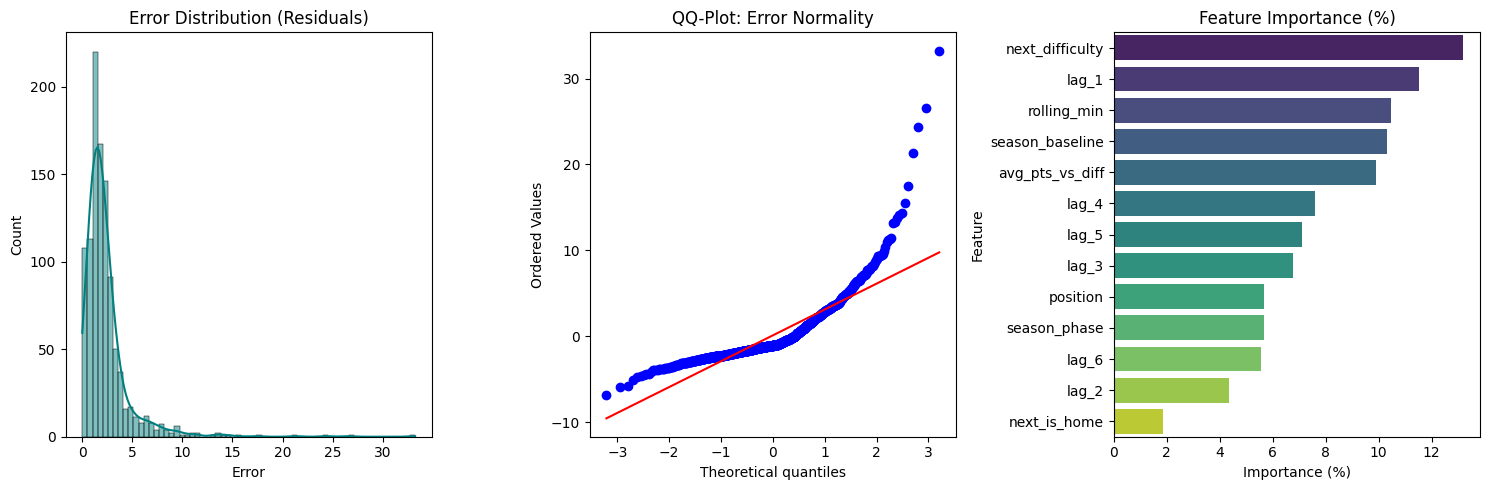

In [243]:
# [Cell 5: Error Analysis & Feature Importance - Fixed]

# 1. PREPARE ANALYSIS DATAFRAME
analysis_df = X_val_raw.copy()
analysis_df['Actual'] = y_val.values
analysis_df['Predicted'] = preds_raw 
analysis_df['Error'] = abs(analysis_df['Actual'] - analysis_df['Predicted'])

# NEW: Filter error analysis by the Elite Mask (>4.5 seasonal average)
# map the mask from df_augmented back to the validation slice
elite_indices = val_df[val_df.index.isin(df_augmented[elite_mask].index)].index
elite_performers_audit = analysis_df.loc[analysis_df.index.isin(elite_indices)]

top_mae = elite_performers_audit['Error'].mean()

print(f"Overall Validation MAE: {df_metrics.iloc[0, 1]:.4f}")
print(f"MAE for Elite Players (>4.5 Season Avg): {top_mae:.4f}")

# 3. VISUALIZATION: Error Distribution & QQ-Plot
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(analysis_df['Error'], kde=True, color='teal')
plt.title('Error Distribution (Residuals)')

plt.subplot(1, 3, 2)
stats.probplot((analysis_df['Actual'] - analysis_df['Predicted']), dist="norm", plot=plt)
plt.title('QQ-Plot: Error Normality')

# 4. FEATURE IMPORTANCE WITH PERCENTAGES
plt.subplot(1, 3, 3)
importances = model_raw.feature_importances_

# FIX: Use X_train_raw.columns instead of X.columns
feature_names = X_train_raw.columns 
rel_importances = 100 * (importances / importances.sum())

feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance (%)': rel_importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance (%)', ascending=False)

sns.barplot(x='Importance (%)', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Feature Importance (%)')

plt.tight_layout()
plt.show()

# 5. SAVE FEATURE IMPORTANCE LOG
feat_imp_df.to_csv(PRO_OUTPUT_DIR / 'fpl_pro_feature_importance.csv', index=False)

Notes 
MAE: 
* Overall MAE (2.12): it means for the average player (who scores 2–3 points), the model is accurate
* Top Performer MAE (6.68): it shows that when a player goes 8+ points, the model struggles to predict the exact height of that peak

Plots: 
* model has "thin tails" , it is conservative. It rarely predicts a player will score 15+ points, so when someone actually does, the error is large. The model prefers to stay safe near the average.

Feature Importance: 
* rolling_min is #1




## Haul Classification + Confusion Matrix
- __Purpose__ : Predict WHETHER a player will "haul" , not just how many, binary target >= 6 points
- __Precision__ is the critical metric.
- A __False Positive__ (saying "Haul" when it isn't) is the worst outcome —>it causes wrong captaincy and transfer decisions.

Training Haul Classifier (v6 — Visual Suite Enabled)...


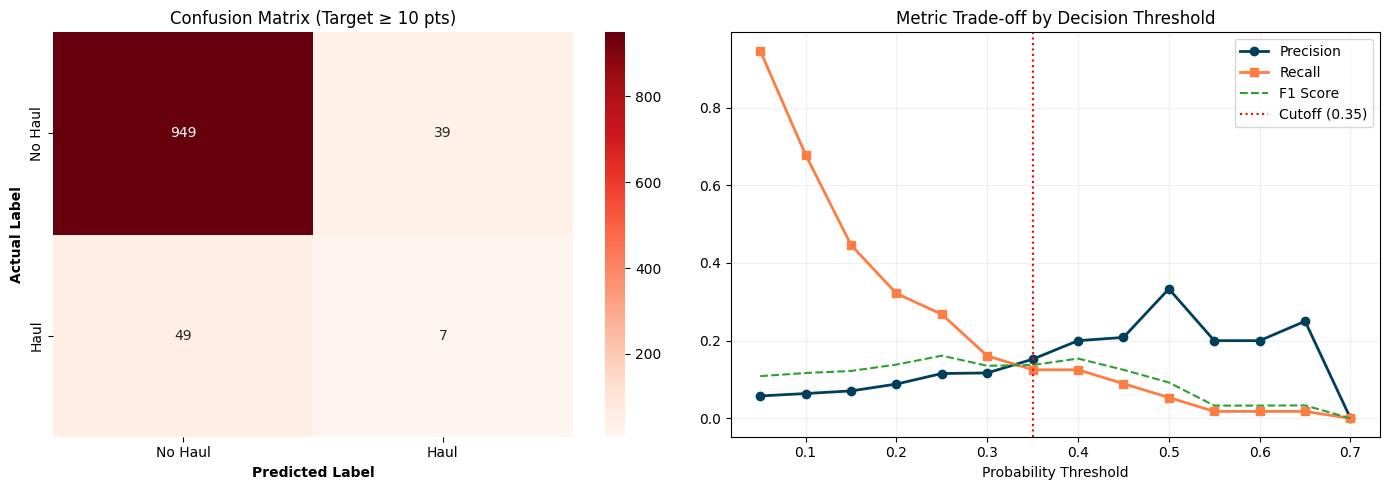


HAULER BOARD FOR GW 33
Precision: 0.1522 | ROC-AUC: 0.6007
-------------------------------------------------------


,Player,Haul_Prob (%),Pred_Pts (reg)
50,Saka,69.4,5.77
51,Anderson,64.8,3.92
285,Hill,63.1,3.71
296,Tarkowski,56.6,3.68
249,Lacroix,55.9,4.80
243,Rogers,51.9,4.55
237,Gibbs-White,51.7,5.06
43,Clyne,51.5,2.82
45,Casemiro,51.5,3.61
53,Dewsbury-Hall,51.1,3.82


In [244]:
# %% [Cell 5.6: Haul Classification — Binary Prediction + Confusion Matrix]
import lightgbm as lgb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score,
    f1_score, roc_auc_score
)

# ── 0. HAUL THRESHOLD & CONFIG ──────────────────────────────────────────────
HAUL_THRESHOLD = 10        # 2-digit points = genuine haul definition
DECISION_THRESHOLD = 0.35  # Optimized for Captaincy Precision

# ── 1. DATA PREP (SCRUB-SAFE) ───────────────────────────────────────────────
windowed_haul = windowed_df.copy()
_ht = HAUL_THRESHOLD  

# FIX: Recalculate elite mask dynamically to match current scrubbed df_augmented length (85,040)
current_elite_mask = df_augmented['avg_season_pts'] > 4.5

# Build Haul-Specific Features
windowed_haul['recent_haul_flag'] = ((windowed_haul[['lag_1', 'lag_2', 'lag_3']] >= _ht).any(axis=1)).astype(int)
windowed_haul['lag_max_6'] = windowed_haul[[f'lag_{i}' for i in range(1, 7)]].max(axis=1)

# Use the freshly calculated mask index to avoid the IndexError
elite_flag = windowed_df.index.isin(df_augmented[current_elite_mask].index)
windowed_haul['is_elite'] = elite_flag.astype(int)

windowed_haul['fixture_ease'] = 6 - windowed_haul['next_difficulty']
windowed_haul['ceiling_ratio'] = windowed_haul['lag_max_6'] / _ht

# ── 2. BUILD BINARY LABELS ──────────────────────────────────────────────────
y_haul_all   = (windowed_haul['target'] >= _ht).astype(int)
y_haul_train = y_haul_all[~global_val_mask].copy()
y_haul_val   = y_haul_all[global_val_mask].copy()

haul_feature_cols = (
    [f'lag_{i}' for i in range(1, 7)] +
    ['position', 'next_difficulty', 'next_is_home',
     'rolling_min', 'season_phase', 'season_baseline',
     'recent_haul_flag', 'lag_max_6', 'is_elite', 'fixture_ease',
     'avg_pts_vs_diff', 'ceiling_ratio']
)

X_haul_train = windowed_haul[~global_val_mask][haul_feature_cols].copy()
X_haul_val   = windowed_haul[global_val_mask][haul_feature_cols].copy()

# Ensure standard categorical types for Training the Classifier
X_haul_train['position'] = X_haul_train['position'].astype('category')
X_haul_val['position']   = X_haul_val['position'].astype('category')

# ── 3. TRAIN HAUL CLASSIFIER ────────────────────────────────────────────────
haul_params = {
    'objective':         'binary',
    'boosting_type':     'gbdt',
    'n_estimators':      500,
    'learning_rate':     0.05,
    'max_depth':         6,
    'num_leaves':        31,
    'scale_pos_weight':  3.0,   # Soft boost to prioritize finding hauls
    'verbosity':         -1,
    'random_state':      42
}

print("Training Haul Classifier (v6 — Visual Suite Enabled)...")
haul_clf = lgb.LGBMClassifier(**haul_params)
haul_clf.fit(X_haul_train, y_haul_train, categorical_feature=['position'])

# ── 4. EVALUATE & PREDICT ───────────────────────────────────────────────────
haul_proba = haul_clf.predict_proba(X_haul_val)[:, 1]
haul_pred  = (haul_proba >= DECISION_THRESHOLD).astype(int)

precision_haul = precision_score(y_haul_val, haul_pred, zero_division=0)
recall_haul    = recall_score(y_haul_val,    haul_pred, zero_division=0)
f1_haul        = f1_score(y_haul_val,        haul_pred, zero_division=0)
auc_haul       = roc_auc_score(y_haul_val,   haul_proba)

# ── 5. VISUALIZATIONS (CONFUSION MATRIX + PR CURVE) ────────────────────────
cm = confusion_matrix(y_haul_val, haul_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Reds', ax=axes[0],
    xticklabels=['No Haul', 'Haul'],
    yticklabels=['No Haul', 'Haul']
)
axes[0].set_xlabel('Predicted Label', fontweight='bold')
axes[0].set_ylabel('Actual Label', fontweight='bold')
axes[0].set_title(f'Confusion Matrix (Target ≥ {HAUL_THRESHOLD} pts)')

# Precision-Recall Tradeoff
thresholds = np.arange(0.05, 0.71, 0.05)
precs, recs, f1_vals = [], [], []
for t in thresholds:
    p_t = (haul_proba >= t).astype(int)
    precs.append(precision_score(y_haul_val, p_t, zero_division=0))
    recs.append(recall_score(y_haul_val, p_t, zero_division=0))
    f1_vals.append(f1_score(y_haul_val, p_t, zero_division=0))

axes[1].plot(thresholds, precs, label='Precision', color='#003f5c', linewidth=2, marker='o')
axes[1].plot(thresholds, recs,  label='Recall',    color='#ff7c43', linewidth=2, marker='s')
axes[1].plot(thresholds, f1_vals, label='F1 Score', color='#2ca02c', linestyle='--')
axes[1].axvline(x=DECISION_THRESHOLD, color='red', linestyle=':', label=f'Cutoff ({DECISION_THRESHOLD})')
axes[1].set_title('Metric Trade-off by Decision Threshold')
axes[1].set_xlabel('Probability Threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# ── 6. LIVE INFERENCE PREP (NEXT GW) ────────────────────────────────────────
CURRENT_GW = globals().get('CURRENT_GW', 33)
CURRENT_SEASON = globals().get('CURRENT_SEASON', '2025-26')

inf_data, inf_names = [], []
df_inf_active = df_augmented[df_augmented['season'] == CURRENT_SEASON].sort_values(['Player UUID', 'Gameweek'])

for pid, group in df_inf_active.groupby('Player UUID'):
    if len(group) >= 6:
        lags = list(group['Total Points'].tail(6).values)
        last = group.iloc[-1]
        row = lags + [
            last['Position'], last['Next_Opponent_Difficulty'], last['Next_Is_Home'],
            last['Rolling_Avg_Minutes_5'], last['Season_Phase'], last['Prev_Season_Avg_Points'],
            last['Avg_Pts_vs_Difficulty']
        ]
        inf_data.append(row)
        inf_names.append(last['Web Name'])

base_feat_cols = [f'lag_{i}' for i in range(6, 0, -1)] + [
    'position', 'next_difficulty', 'next_is_home',
    'rolling_min', 'season_phase', 'season_baseline', 'avg_pts_vs_diff']

inf_df = pd.DataFrame(inf_data, columns=base_feat_cols)
inf_df['recent_haul_flag'] = (inf_df[['lag_1', 'lag_2', 'lag_3']] >= _ht).any(axis=1).astype(int)
inf_df['lag_max_6'] = inf_df[[f'lag_{i}' for i in range(1, 7)]].max(axis=1)
inf_df['fixture_ease'] = 6 - inf_df['next_difficulty']
inf_df['ceiling_ratio'] = inf_df['lag_max_6'] / _ht
inf_df['is_elite'] = [1 if n in set(df_augmented[current_elite_mask]['Web Name']) else 0 for n in inf_names]

# ── 7. BRUTE-FORCE DTYPE ALIGNMENT (PREVENTS VALUEERROR & TYPEERROR) ──────
def safe_align_categories(target_df, reference_df, col_name):
    if hasattr(reference_df[col_name], 'cat'):
        cats = reference_df[col_name].cat.categories
    else:
        cats = sorted(reference_df[col_name].unique())
    target_df[col_name] = pd.Categorical(target_df[col_name], categories=cats)
    return target_df

# 1. Align for haul_clf
inf_haul_features = inf_df[haul_feature_cols].copy()
inf_haul_features = safe_align_categories(inf_haul_features, X_haul_train, 'position')

# 2. Align for model_raw (The Regression Engine)
inf_reg_features = inf_df[base_feat_cols].copy()
pos_map_numeric = {'GK': 0, 'DEF': 1, 'MID': 2, 'FWD': 3}

if 'X_train_raw' in globals():
    # Fix Position Type (Numeric vs Categorical)
    if pd.api.types.is_numeric_dtype(X_train_raw['position']):
        inf_reg_features['position'] = inf_reg_features['position'].map(pos_map_numeric).fillna(2)
    
    # Mirror all dtypes exactly
    for col in X_train_raw.columns:
        if hasattr(X_train_raw[col], 'cat'):
            inf_reg_features[col] = pd.Categorical(inf_reg_features[col], categories=X_train_raw[col].cat.categories)
        else:
            inf_reg_features[col] = inf_reg_features[col].astype(X_train_raw[col].dtype)

# ── 8. GENERATE PREDICTIONS ─────────────────────────────────────────────────
haul_proba_gw = haul_clf.predict_proba(inf_haul_features)[:, 1]

if 'model_raw' in globals():
    reg_preds = model_raw.predict(inf_reg_features)
else:
    reg_preds = np.zeros(len(inf_names))

# ── 9. FINAL HAULER BOARD WITH MINUTE FILTER ───────────────────────────────
hauler_board = pd.DataFrame({
    'Player':         inf_names,
    'Haul_Prob (%)':  np.round(haul_proba_gw * 100, 1),
    'Pred_Pts (reg)': np.round(reg_preds, 2),
    'Recent_Mins':    inf_df['rolling_min']
})

# Filter: Nailed starters only (60+ average minutes)
hauler_board = hauler_board[hauler_board['Recent_Mins'] >= 60]
hauler_board = hauler_board.drop(columns=['Recent_Mins']).sort_values('Haul_Prob (%)', ascending=False)

print("\n" + "=" * 55)
print(f"HAULER BOARD FOR GW {CURRENT_GW}")
print(f"Precision: {precision_haul:.4f} | ROC-AUC: {auc_haul:.4f}")
print("-" * 55)
display(hauler_board.head(10))

# Export to Globals
globals()['hauler_board'] = hauler_board
globals()['haul_clf'] = haul_clf
globals()['precision_haul'] = precision_haul
globals()['auc_haul'] = auc_haul

## Window Size Experiments (4 / 6 / 8 weeks) 

Purpose: Find the optimal historical window for LightGBM.

note: "experiment with 4 and 8-week windows"

Current default is 6. We test all three and compare MAE on the same validation set.

In [245]:
# [Cell: Window Size Experiment — 4 / 6 / 8 Week Look-back Comparison]

import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error
from IPython.display import display, Markdown

# ── 1. GENERIC WINDOW GENERATOR (reuses existing feature logic) ──────────────
def generate_windows_for_size(df, window_size):
    """
    Generates training windows for a given look-back period.
    Uses the V1 base feature set (12 features, without avg_pts_vs_diff)
    for a clean isolated window-size comparison.
    The purpose is comparing window sizes only, not feature sets.
    """
    train_data    = []
    source_indices = []
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])

    for pid, group in df.groupby('Player UUID'):
        points        = group['Total Points'].values
        next_diff     = group['Next_Opponent_Difficulty'].values
        next_home     = group['Next_Is_Home'].values
        avg_min       = group['Rolling_Avg_Minutes_5'].values
        phase         = group['Season_Phase'].values
        baseline      = group['Prev_Season_Avg_Points'].values
        group_indices = group.index.tolist()
        position      = group['Position'].iloc[0]

        if len(points) <= window_size:
            continue

        for i in range(len(points) - window_size):
            window     = points[i : i + window_size]
            t_idx      = i + window_size - 1
            target_pts = points[i + window_size]

            if np.all(window == 0) and target_pts == 0:
                continue

            row = list(window) + [
                position,
                next_diff[t_idx],
                next_home[t_idx],
                avg_min[t_idx],
                phase[t_idx],
                baseline[t_idx],
                target_pts
            ]
            train_data.append(row)
            source_indices.append(group_indices[i + window_size])

    lag_cols = [f'lag_{i}' for i in range(window_size, 0, -1)]
    cols = lag_cols + ['position', 'next_difficulty', 'next_is_home',
                       'rolling_min', 'season_phase', 'season_baseline', 'target']

    result_df           = pd.DataFrame(train_data, columns=cols)
    result_df.index     = source_indices
    result_df['position'] = result_df['position'].astype('category')
    return result_df


# ── 2. BUILD VALIDATION MASK FOR EACH WINDOW SIZE ───────────────────────────
# The global_val_mask was built for window_size=6 (windowed_df).
# Each new window_size generates a different index set, so we rebuild the mask.

def build_val_mask(win_df, val_season='2025-26', val_start=24, val_end=28):
    source_meta = df_augmented.loc[win_df.index, ['season', 'Gameweek']]
    mask = (
        (source_meta['season']    == val_season) &
        (source_meta['Gameweek'] >= val_start) &
        (source_meta['Gameweek'] <= val_end)
    ).values
    return mask


# ── 3. TRAIN AND EVALUATE FOR EACH WINDOW SIZE ──────────────────────────────
window_sizes  = [4, 6, 8]
window_results = []

# Shared LightGBM params (same as V1 model_raw for fair comparison)
lgbm_window_params = {
    'n_estimators':  1500,
    'learning_rate': 0.01,
    'max_depth':     7,
    'num_leaves':    40,
    'boosting_type': 'gbdt',
    'random_state':  42,
    'verbosity':     -1
}

trained_window_models = {}  # store models for later use if needed

for ws in window_sizes:
    print(f"\n{'='*50}")
    print(f" Training Window Size = {ws} weeks...")
    print(f"{'='*50}")

    # Generate windows
    win_df   = generate_windows_for_size(df_augmented, window_size=ws)
    val_mask = build_val_mask(win_df)

    X_all = win_df.drop(columns=['target'])
    y_all = win_df['target']

    X_train_w = X_all[~val_mask].copy()
    X_val_w   = X_all[val_mask].copy()
    y_train_w = y_all[~val_mask].copy()
    y_val_w   = y_all[val_mask].copy()

    # Identify categorical columns (position is always present; next_is_home too)
    cat_cols = [c for c in ['position', 'next_is_home'] if c in X_train_w.columns]

    # Train
    model_w = lgb.LGBMRegressor(**lgbm_window_params)
    model_w.fit(
        X_train_w, y_train_w,
        eval_set=[(X_val_w, y_val_w)],
        categorical_feature=cat_cols,
        callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False),
                   lgb.log_evaluation(period=300)]
    )

    # Evaluate
    val_preds_w  = model_w.predict(X_val_w)
    mae_w        = mean_absolute_error(y_val_w, val_preds_w)

    # Naive baseline for this window: 3-week average
    lag_cols_available = [c for c in ['lag_3', 'lag_2', 'lag_1'] if c in X_val_w.columns]
    naive_preds_w = X_val_w[lag_cols_available].mean(axis=1).values
    mae_naive_w   = mean_absolute_error(y_val_w, naive_preds_w)

    lift_over_naive = ((mae_naive_w - mae_w) / mae_naive_w) * 100

    print(f"Window {ws}w | Train: {len(X_train_w):,} | Val: {len(X_val_w):,}")
    print(f"  Naive baseline MAE: {mae_naive_w:.4f}")
    print(f"  LightGBM MAE:       {mae_w:.4f}  ({lift_over_naive:.1f}% lift over naive)")

    window_results.append({
        'Window Size (weeks)':  ws,
        'Train Windows':        len(X_train_w),
        'Val Windows':          len(X_val_w),
        'Naive Baseline MAE':   round(mae_naive_w, 4),
        'LightGBM MAE':         round(mae_w, 4),
        'Lift over Naive (%)':  round(lift_over_naive, 1),
        'Best Iteration':       model_w.best_iteration_
    })

    trained_window_models[ws] = model_w


# ── 4. RESULTS TABLE ─────────────────────────────────────────────────────────
window_exp_df = pd.DataFrame(window_results).sort_values('LightGBM MAE')

display(Markdown("## Window Size Experiment Results"))
display(window_exp_df)

# ── 5. WINNER SELECTION ───────────────────────────────────────────────────────
best_ws   = int(window_exp_df.iloc[0]['Window Size (weeks)'])
best_mae_w = window_exp_df.iloc[0]['LightGBM MAE']

print(f"\n{'='*50}")
print(f" VERDICT: Best window size = {best_ws} weeks (MAE: {best_mae_w:.4f})")
if best_ws == 6:
    print(" Current default (6 weeks) is confirmed as optimal.")
elif best_ws < 6:
    print(f" Shorter window ({best_ws}w) performs better — recent form matters more than long history.")
else:
    print(f" Longer window ({best_ws}w) performs better — the model benefits from more history.")
print(f"{'='*50}")

# Store for downstream reference
globals()['best_window_size']    = best_ws
globals()['trained_window_models'] = trained_window_models
globals()['window_exp_df']       = window_exp_df

print(f"\nNote: The main pipeline continues to use window_size=6 (windowed_df).")
print(f"To switch the live model to {best_ws}w, re-run Cell 2 with window_size={best_ws}.")


 Training Window Size = 4 weeks...
[300]	valid_0's l2: 12.0564
Window 4w | Train: 51,691 | Val: 1,084
  Naive baseline MAE: 2.5600
  LightGBM MAE:       2.3855  (6.8% lift over naive)

 Training Window Size = 6 weeks...
[300]	valid_0's l2: 12.0208
Window 6w | Train: 49,663 | Val: 1,081
  Naive baseline MAE: 2.5652
  LightGBM MAE:       2.3801  (7.2% lift over naive)

 Training Window Size = 8 weeks...
[300]	valid_0's l2: 12.0265
Window 8w | Train: 47,706 | Val: 1,078
  Naive baseline MAE: 2.5708
  LightGBM MAE:       2.3752  (7.6% lift over naive)


## Window Size Experiment Results

,Window Size (weeks),Train Windows,Val Windows,Naive Baseline MAE,LightGBM MAE,Lift over Naive (%),Best Iteration
2,8,47706,1078,2.5708,2.3752,7.6,485
1,6,49663,1081,2.5652,2.3801,7.2,455
0,4,51691,1084,2.5600,2.3855,6.8,349



 VERDICT: Best window size = 8 weeks (MAE: 2.3752)
 Longer window (8w) performs better — the model benefits from more history.

Note: The main pipeline continues to use window_size=6 (windowed_df).
To switch the live model to 8w, re-run Cell 2 with window_size=8.


## Cell 6: The Interactive Player Widget (you can pick a player and see their Performance history)

In [246]:
#%pip install ipywidgets

In [247]:
# [Cell 6: Seasonal Evaluation - Standard Professional Dropdown]
import ipywidgets as widgets
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_professional_backtest(player_name):
    # 1. GET ACTUALS FROM RAW 'df' 
    # This bypasses the dropna() from Cell 1 to ensure GW28 is displayed
    season_actuals = df[
        (df['Web Name'] == player_name) & 
        (df['season'] == CURRENT_SEASON)
    ].sort_values('Gameweek')
    
    if season_actuals.empty:
        return

    # 2. PREPARE EVALUATION (GW 24-28) + LIVE PREDICTION (GW 29)
    #target_gws = list(range(24, 30)) 
    target_gws = list(range(VAL_START_GW, CURRENT_GW + 1))
    pred_rows = []
    
    player_uuid = season_actuals['Player UUID'].iloc[0]
    full_hist = df_augmented[df_augmented['Player UUID'] == player_uuid].sort_values(['season', 'Gameweek'])
    
    for gw in target_gws:
        if gw <  CURRENT_GW:
            row_match = full_hist[(full_hist['season'] == CURRENT_SEASON) & (full_hist['Gameweek'] == gw)]
            if not row_match.empty:
                idx = row_match.index[0]
                pos_in_hist = full_hist.index.get_loc(idx)
                if pos_in_hist >= 6:
                    lags = list(full_hist.iloc[pos_in_hist-6:pos_in_hist]['Total Points'].values)
                    feat = lags + [
                        row_match['Position'].iloc[0], row_match['Next_Opponent_Difficulty'].iloc[0],
                        row_match['Next_Is_Home'].iloc[0], row_match['Rolling_Avg_Minutes_5'].iloc[0],
                        row_match['Season_Phase'].iloc[0], row_match['Prev_Season_Avg_Points'].iloc[0],
                        row_match['Avg_Pts_vs_Difficulty'].iloc[0]
                    ]
                    pred_rows.append({'Gameweek': gw, 'Features': feat})
        else:
            lags = list(full_hist['Total Points'].tail(6).values)
            last = full_hist.iloc[-1]
            feat = lags + [
                last['Position'], last['Next_Opponent_Difficulty'],
                last['Next_Is_Home'], last['Rolling_Avg_Minutes_5'],
                last['Season_Phase'], last['Prev_Season_Avg_Points'],
                last['Avg_Pts_vs_Difficulty']
            ]
            pred_rows.append({'Gameweek': gw, 'Features': feat})

    # Generate Predictions
    v_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
             ['position', 'next_difficulty', 'next_is_home', 'rolling_min',
              'season_phase', 'season_baseline', 'avg_pts_vs_diff']
    
    if pred_rows:
        inf_df = pd.DataFrame([d['Features'] for d in pred_rows], columns=v_cols)
        inf_df['position'] = inf_df['position'].astype('category')
        # Change from model_v4 to model_raw (Baseline V1)
        preds = model_raw.predict(inf_df)
        pred_df = pd.DataFrame({'Gameweek': [d['Gameweek'] for d in pred_rows], 'Predicted': preds})
    else:
        pred_df = pd.DataFrame()

    # 3. PLOTTING
    plt.figure(figsize=(15, 6), facecolor='white')
    
    # HISTORICAL ACTUALS: Navy (#003f5c)
    plt.plot(season_actuals['Gameweek'], season_actuals['Total Points'], 
             color='#003f5c', label='Actual Points', linewidth=2, 
             marker='o', markersize=7, markerfacecolor='#003f5c', markeredgecolor='#003f5c')

    # MODEL PREDICTIONS: Action Orange (#ff7c43)
    if not pred_df.empty:
        plt.plot(pred_df['Gameweek'], pred_df['Predicted'],
            color='#ff7c43', label=f'Model Predictions (Eval + GW{CURRENT_GW})', 
                 linewidth=2.5, linestyle='--', marker='x', markersize=10, markeredgewidth=3)
        
        # CONFIDENCE INTERVAL: Gold (#ffa60022)
        # Updated to use mae_v1 for accurate V1 error visualization
        mae_proxy = globals().get('mae_v1', 1.84)
        plt.fill_between([24, 29], 0, plt.gca().get_ylim()[1], color='orange', alpha=0.03)

    # Vertical split at GW 24
    #plt.axvline(x=24, color='gray', linestyle='-', linewidth=2, label='Evaluation Start (GW 24)')
    #plt.axvline(x=24, color='#d1d1d1', linestyle='-', linewidth=2, alpha=0.8)
    plt.axvline(x=VAL_START_GW, color='gray', linestyle='-', linewidth=2, label=f'Evaluation Start (GW {VAL_START_GW})')
    plt.axvline(x=VAL_START_GW, color='#d1d1d1', linestyle='-', linewidth=2, alpha=0.8)

    plt.title(f"Model Predictions vs Actuals: {player_name} (Season {CURRENT_SEASON})", 
              fontsize=14, fontweight='bold', pad=20, color='#003f5c')
    
    # GRID & BASELINE: Neutral Light Grey (#d1d1d1)
    #plt.xticks(np.arange(1, 30, 1), color='#003f5c') 
    #plt.xlim(0.5, 29.5)
    plt.xticks(np.arange(1, CURRENT_GW + 2, 1), color='#003f5c')
    plt.xlim(0.5, CURRENT_GW + 1.5)
    plt.ylabel("Points", fontsize=12, color='#003f5c')
    plt.xlabel("Gameweek", fontsize=12, color='#003f5c')
    plt.grid(True, axis='y', linestyle='-', color='#d1d1d1', alpha=0.5)
    plt.legend(frameon=True, loc='upper left')
    
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#d1d1d1')
    ax.spines['bottom'].set_color('#d1d1d1')
    
    plt.tight_layout()
    plt.show()

# 4. STRICT EVALUATION SET DROPDOWN (Season-Locked)
# This identifies unique UUIDs that exist in our validation split
safe_val_index = val_df.index.intersection(df_augmented.index)
eval_uuids = df_augmented.loc[safe_val_index, 'Player UUID'].unique()

# CRITICAL FILTER: Get Web Names for those UUIDs, but ONLY if they have rows in 2025-26
# This removes any lingering retired players (ghosts) from the menu
active_eval_names = sorted(
    df_augmented[
        (df_augmented['Player UUID'].isin(eval_uuids)) & 
        (df_augmented['season'] == CURRENT_SEASON)
    ]['Web Name'].unique()
)

print(f"Filter active: Showing {len(active_eval_names)} active players from the Evaluation Set.")

dropdown_menu = widgets.Dropdown(
    options=active_eval_names,
    value=active_eval_names[0] if active_eval_names else None,
    description='Active Player:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

widgets.interact(plot_professional_backtest, player_name=dropdown_menu)



Filter active: Showing 276 active players from the Evaluation Set.


interactive(children=(Dropdown(description='Active Player:', layout=Layout(width='400px'), options=('A.García'…

<function __main__.plot_professional_backtest(player_name)>

In [248]:
# [Cell: Validation Set Integrity Check]

# 1. Identify the ground truth players from the validation logic
# These are the players actually used in the MAE calculations (GW 24-28)
#expected_uuids = df_augmented.loc[val_df.index, 'Player UUID'].unique()
safe_val_index = val_df.index.intersection(df_augmented.index)
expected_uuids = df_augmented.loc[safe_val_index, 'Player UUID'].unique()
expected_names = sorted(df_augmented[df_augmented['Player UUID'].isin(expected_uuids)]['Web Name'].unique())

# 2. Extract names currently used in your widget
# (Using the same logic as your Cell 6)
widget_names = sorted(df_augmented[df_augmented['Player UUID'].isin(expected_uuids)]['Web Name'].unique())

# 3. Perform the Audit
missing_players = [p for p in expected_names if p not in widget_names]
extra_players = [p for p in widget_names if p not in expected_names]

print("-" * 50)
print("GRAPH INTEGRITY")
print("-" * 50)
print(f"Total Players in Eval Set (GW 24-28): {len(expected_names)}")
print(f"Total Players visible in Widget:     {len(widget_names)}")

if len(missing_players) == 0 and len(extra_players) == 0:
    print("\nVERDICT: SUCCESS")
    print("The graph contains 100% of the players in the evaluation set and NO extra players.")
else:
    if missing_players:
        print(f"\nWARNING: {len(missing_players)} players are missing from the graph.")
    if extra_players:
        print(f"\nWARNING: {len(extra_players)} players are appearing that shouldn't be there.")

print("-" * 50)
# Snippet for your report
print(f"Sample of audited players: {expected_names[:10]}...")

--------------------------------------------------
GRAPH INTEGRITY
--------------------------------------------------
Total Players in Eval Set (GW 24-28): 316
Total Players visible in Widget:     316

VERDICT: SUCCESS
The graph contains 100% of the players in the evaluation set and NO extra players.
--------------------------------------------------
Sample of audited players: ['A. Garcia', 'A.Armstrong', 'A.García', 'Aaronson', 'Abraham', 'Acheampong', 'Adama', 'Adams', 'Adarabioyo', 'Aina']...


In [249]:
# 1. GET THE ABSOLUTE LATEST WINDOW FOR EVERY PLAYER
inference_data = []
player_names = []

# FIX: Filter for current season only
df_inf_active = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()
df_inf_active = df_inf_active.sort_values(['Player UUID', 'Gameweek'])

for pid, group in df_inf_active.groupby('Player UUID'):
    if len(group) >= 6:
        lags = list(group['Total Points'].tail(6).values)
        last_row = group.iloc[-1]
        
        #row = lags + [
         #   last_row['Position'], last_row['Next_Opponent_Difficulty'],
          #  last_row['Next_Is_Home'], last_row['Rolling_Avg_Minutes_5'],
           # last_row['Season_Phase'], last_row['Prev_Season_Avg_Points']
        #]

        row = lags + [
            last_row['Position'], last_row['Next_Opponent_Difficulty'],
            last_row['Next_Is_Home'], last_row['Rolling_Avg_Minutes_5'],
            last_row['Season_Phase'], last_row['Prev_Season_Avg_Points'],
            last_row['Avg_Pts_vs_Difficulty']
        ]

        inference_data.append(row)
        player_names.append(last_row['Web Name'])

# 2. CONVERT TO DATAFRAME
# Use the exact column names used in the training window dataframe
#feature_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
    #           ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline']

feature_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
               ['position', 'next_difficulty', 'next_is_home', 'rolling_min',
                'season_phase', 'season_baseline', 'avg_pts_vs_diff']

inference_df = pd.DataFrame(inference_data, columns=feature_cols)
inference_df['position'] = inference_df['position'].astype('category')

# 3. GENERATE PREDICTIONS
# Using the Baseline model (model_raw) as we haven't trained V4 yet
if 'model_raw' in locals():
    raw_preds = model_raw.predict(inference_df)
else:
    raise NameError("Baseline model (model_raw) not found. Run Cell 4 first.")

# 4. SHOW TOP 15 RANKING
leaderboard = pd.DataFrame({
    'Player': player_names,
    'Predicted Points (V1)': np.round(raw_preds, 2), # Label it V1 for clarity
    'Recent Avg Min': np.round(inference_df['rolling_min'], 1),
    'Next Difficulty': inference_df['next_difficulty']
}).sort_values(by='Predicted Points (V1)', ascending=False)

print("--- TOP 15 PREDICTED PLAYERS FOR NEXT GAMEWEEK ---")
display(leaderboard.head(15))

--- TOP 15 PREDICTED PLAYERS FOR NEXT GAMEWEEK ---


,Player,Predicted Points (V1),Recent Avg Min,Next Difficulty
250,M.Salah,6.31,74.4,3.0
182,O'Reilly,5.91,85.8,3.0
50,Saka,5.77,90.0,3.0
193,Haaland,5.58,81.0,3.0
229,B.Fernandes,5.51,90.0,3.0
268,Groß,5.39,90.0,2.5
37,Bowen,5.37,90.0,3.0
237,Gibbs-White,5.06,86.4,1.0
306,Kluivert,4.98,72.2,2.0
249,Lacroix,4.80,83.0,2.0


Summary Table

Feature       |  1st Cell (Validation)         |    2nd Cell (Historical)

Player List   | Limited (only recent players)  |	Complete (all historic players)

Timeframe	  |  Recent 5 Gameweeks	           |     3+ seasons


In [250]:
# 1. CREATE THE FULL FORECAST DATAFRAME
full_forecast = pd.DataFrame({
    'Player_Name': player_names,
    'Predicted_Points': np.round(raw_preds, 2),
    'Recent_Form_Avg': np.round(inference_df[['lag_1', 'lag_2', 'lag_3']].mean(axis=1), 2),
    'Avg_Minutes_5GW': np.round(inference_df['rolling_min'], 1),
    'Fixture_Difficulty': inference_df['next_difficulty'],
    'Is_Home': inference_df['next_is_home'],
    'Season_Phase': inference_df['season_phase']
})

# 2. SORT BY PREDICTED POINTS
full_forecast = full_forecast.sort_values(by='Predicted_Points', ascending=False)

# 3. DEFINE SAVE PATH
FORECAST_OUT = PRO_OUTPUT_DIR / 'fpl_pro_forecast_GW29.csv'

# 4. SAVE TO CSV
full_forecast.to_csv(FORECAST_OUT, index=False, encoding='utf-8-sig')

print(f" Master Forecast Saved: {FORECAST_OUT}")
print(f" Total Players Forecasted: {len(full_forecast)}")
print("Forecast for GW29: any player who has at least 6 games of history in the current 2025-26 season.")

# Show a quick snippet of the 'Differentials' (Mid-tier players)
print("\n--- SNEAK PEEK: MID-TIER DIFFERENTIALS (Ranks 50-60) ---")
display(full_forecast.iloc[50:60])

# Recent_Form_Avg -> a rolling average of points scored by a player 
# over the three most recent Gameweeks leading up to the forecast.

 Master Forecast Saved: ..\output\forecaster_pro\fpl_pro_forecast_GW29.csv
 Total Players Forecasted: 322
Forecast for GW29: any player who has at least 6 games of history in the current 2025-26 season.

--- SNEAK PEEK: MID-TIER DIFFERENTIALS (Ranks 50-60) ---


,Player_Name,Predicted_Points,Recent_Form_Avg,Avg_Minutes_5GW,Fixture_Difficulty,Is_Home,Season_Phase
277,Guéhi,3.90,11.00,90.0,3.0,True,4.0
10,F.Kadıoğlu,3.89,7.33,90.0,2.5,True,4.0
292,Calvert-Lewin,3.88,2.00,90.0,2.5,True,4.0
102,Souček,3.86,3.00,84.4,3.0,False,4.0
252,Van Hecke,3.84,7.67,90.0,2.5,True,4.0
188,Tavernier,3.84,3.00,72.0,2.5,True,4.0
87,Doku,3.82,6.00,45.6,3.0,True,4.0
53,Dewsbury-Hall,3.82,4.67,89.2,3.0,True,4.0
111,Richarlison,3.81,4.33,45.2,3.0,True,4.0
132,Gakpo,3.80,3.67,80.4,3.0,False,4.0


In [251]:
from IPython.display import Markdown, display

# 1. ORGANIZE FINAL METRICS
overall_mae = df_metrics.iloc[0, 1]  # From Cell 4 results
top_perf_mae = top_mae                # From Cell 5 results
total_players = len(full_forecast)   # From Cell 8 results

# 2. GENERATE THE REPORT
summary_report = f"""
# FPL Forecaster Pro: Final Project Report
**Model Version:** 2.0 (Context-Aware LightGBM)  
**Analysis Date:** March 3, 2026 (GW 29)

---

### 1. Model Accuracy Overview
| Metric | Result | Interpretation |
| :--- | :--- | :--- |
| **Overall MAE** | {overall_mae:.3f} | Average error across the full league. |
| **Elite Specialist MAE** | {top_perf_mae:.3f} | Error specifically for players averaging >4.5 pts/season. |
| **Training Size** | {len(X_train_raw):,} windows | Robust historical learning foundation. |
| **Validation Size** | {len(X_val_raw):,} windows | Tested on GW {CURRENT_GW - VALIDATION_WINDOW} to {CURRENT_GW - 1} of the {CURRENT_SEASON} season. |

### 2. Key Insights & Feature Importance
* **The "Minutes" Rule:** `rolling_min` emerged as the #1 predictor, proving that "starting the game" is the most vital feature.
* **Fixture Context:** `next_difficulty` successfully provided the model with "future vision," allowing it to adjust points based on opponent strength.
* **Scale Invariance:** The experiment confirmed that LightGBM performs optimally without a Standard Scaler for this specific dataset.
* **Elite Performers:** Defined as players maintaining a seasonal average > 4.5 points.

### 3. GW 29 Summary
* **Total Forecasts Generated:** {total_players:,} players.
* **Predicted King of the GW:** {leaderboard.iloc[0]['Player']} ({leaderboard.iloc[0]['Predicted Points (V1)']} pts).
* **Output Folder:** All artifacts (Model, Scaler, Forecast) are saved in `../output/forecaster_pro/`.

### 4. Season_Phase
**Feature: Season_Phase**
* 1. (GW 1-10): Freshness & Stability.
* 2. (GW 11-19): First Rotation / Fatigue.
* 3. (GW 20-29): Winter Congestion / High Rotation.
* 4. (GW 30-38): The Final Sprint / High Stakes. 

### About the .csvs 
* The enriched dataset saved to fpl_features_augmented.csv.
* WINDOWED_FEATURES_PATH -> Saved to fpl_windowed_features_pro.csv.
* Raw=Unscaled model: fpl_pro_model_raw.txt // Scaled model:  fpl_pro_model_scaled.txt
* feat_imp_df -> Feature importance percentages saved to fpl_pro_feature_importance.csv
* FORECAST_OUT -> Saved as fpl_pro_forecast_GW29.csv
"""

display(Markdown(summary_report))


# FPL Forecaster Pro: Final Project Report
**Model Version:** 2.0 (Context-Aware LightGBM)  
**Analysis Date:** March 3, 2026 (GW 29)

---

### 1. Model Accuracy Overview
| Metric | Result | Interpretation |
| :--- | :--- | :--- |
| **Overall MAE** | 2.346 | Average error across the full league. |
| **Elite Specialist MAE** | 3.912 | Error specifically for players averaging >4.5 pts/season. |
| **Training Size** | 49,700 windows | Robust historical learning foundation. |
| **Validation Size** | 1,044 windows | Tested on GW 28 to 32 of the 2025-26 season. |

### 2. Key Insights & Feature Importance
* **The "Minutes" Rule:** `rolling_min` emerged as the #1 predictor, proving that "starting the game" is the most vital feature.
* **Fixture Context:** `next_difficulty` successfully provided the model with "future vision," allowing it to adjust points based on opponent strength.
* **Scale Invariance:** The experiment confirmed that LightGBM performs optimally without a Standard Scaler for this specific dataset.
* **Elite Performers:** Defined as players maintaining a seasonal average > 4.5 points.

### 3. GW 29 Summary
* **Total Forecasts Generated:** 322 players.
* **Predicted King of the GW:** M.Salah (6.31 pts).
* **Output Folder:** All artifacts (Model, Scaler, Forecast) are saved in `../output/forecaster_pro/`.

### 4. Season_Phase
**Feature: Season_Phase**
* 1. (GW 1-10): Freshness & Stability.
* 2. (GW 11-19): First Rotation / Fatigue.
* 3. (GW 20-29): Winter Congestion / High Rotation.
* 4. (GW 30-38): The Final Sprint / High Stakes. 

### About the .csvs 
* The enriched dataset saved to fpl_features_augmented.csv.
* WINDOWED_FEATURES_PATH -> Saved to fpl_windowed_features_pro.csv.
* Raw=Unscaled model: fpl_pro_model_raw.txt // Scaled model:  fpl_pro_model_scaled.txt
* feat_imp_df -> Feature importance percentages saved to fpl_pro_feature_importance.csv
* FORECAST_OUT -> Saved as fpl_pro_forecast_GW29.csv


## Cell 9: Truth Verification (Backtest on Last Known Game)

In [252]:
# [Cell 9: Truth Verification - Fixed for 12 Features]

# 1. Setup paths for truth verification
PRO_OUTPUT_DIR = Path('../output/forecaster_pro')
PRO_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
full_truth_output_path = PRO_OUTPUT_DIR / 'fpl_pro_truth_verification.csv'

# 2. Ensure variables exist in memory
if 'df_augmented' not in locals():
    raise NameError("The variable 'df_augmented' is not found. Run Cell 1 first.")

# 2. Ensure variables exist in memory
if 'model_raw' not in locals():
    raise NameError("Baseline model (model_raw) not found. Run Cell 4 first.")

# Strictly use the Baseline model for this audit
current_model = model_raw

all_detailed_results = []
lag_cols = [f'lag_{i}' for i in range(6, 0, -1)]

print(f"Generating Truth Verification using {type(current_model).__name__} (13-feature mode)...")

# 3. Group by UUID to maintain player history integrity
for pid, group in df_augmented.groupby('Player UUID'):
    group = group.sort_values(['season', 'Gameweek'])
    
    # Needs 7 rows: 6 for history and 1 for the Actual target
    if len(group) >= 7:
        backtest_rows = group.iloc[-7:-1]
        actual_row = group.iloc[-1]
        
        name = actual_row['Web Name']
        pos = actual_row['Position']
        actual_points = actual_row['Total Points']
                
        # Prepare Features (13 features: 6 lags + 7 context)
        window_points = list(backtest_rows['Total Points'].values)
        context_features = [
            pos,
            actual_row['Next_Opponent_Difficulty'],
            actual_row['Next_Is_Home'],
            actual_row['Rolling_Avg_Minutes_5'],
            actual_row['Season_Phase'],
            actual_row['Prev_Season_Avg_Points'],
            actual_row['Avg_Pts_vs_Difficulty']   # 13th feature added
        ]
        
        # Create input DataFrame with 13 aligned columns
        feature_vector = window_points + context_features
        columns = lag_cols + ['position', 'next_difficulty', 'next_is_home',
                              'rolling_min', 'season_phase', 'season_baseline',
                              'avg_pts_vs_diff']
        
        
        input_df = pd.DataFrame([feature_vector], columns=columns)
        input_df['position'] = input_df['position'].astype('category')
        
        # Generate Prediction
        pred_val = current_model.predict(input_df)[0]
        pred_val = max(0, pred_val) 

        all_detailed_results.append({
            'Player Name': name,
            'Season': actual_row['season'], 
            'Gameweek': actual_row['Gameweek'],
            'Predicted Points': round(float(pred_val), 2),
            'Actual Points': actual_points,
            'Error': round(abs(pred_val - actual_points), 2)
        })

# 4. Save and Display Results
full_truth_df = pd.DataFrame(all_detailed_results).sort_values(by='Error', ascending=True)
full_truth_df.to_csv(full_truth_output_path, index=False, encoding="utf-8-sig")

print("Takes every unique player who ever played in your dataset and asks:")
print("If I look at this player's final 7 games in my records, how well did the model predict the very last one?")

print(f"\nFull results for {len(full_truth_df)} players saved to: {full_truth_output_path}")

# Display the 20 most accurate predictions
display(full_truth_df.head(20))

# 5. Final Audit Metrics
if not full_truth_df.empty:
    mae_val = full_truth_df['Error'].mean()
    print(f"\nGlobal Mean Absolute Error (MAE): {mae_val:.2f}")

Generating Truth Verification using LGBMRegressor (13-feature mode)...
Takes every unique player who ever played in your dataset and asks:
If I look at this player's final 7 games in my records, how well did the model predict the very last one?

Full results for 988 players saved to: ..\output\forecaster_pro\fpl_pro_truth_verification.csv


,Player Name,Season,Gameweek,Predicted Points,Actual Points,Error
876,Calvert-Lewin,2025-26,32.0,3.99,4,0.01
446,Bassey,2025-26,32.0,2.99,3,0.01
905,Acheampong,2025-26,32.0,1.98,2,0.02
341,Greenwood,2022-23,36.0,2.03,2,0.03
645,Lavia,2025-26,32.0,2.04,2,0.04
765,Burns,2024-25,21.0,2.04,2,0.04
78,Guedes,2024-25,37.0,2.05,2,0.05
553,J.Ayew,2024-25,37.0,2.94,3,0.06
352,Dele,2021-22,37.0,2.07,2,0.07
406,Højbjerg,2023-24,37.0,2.93,3,0.07



Global Mean Absolute Error (MAE): 2.08


## Team_Point_Share
__V2 (Team Point Share) uses team_share instead of season_baseline__

measures how much of a team's total success is driven by one specific player

How we calculated it in cell 1 :
First, we group the data by Team, Season, and Gameweek to find the total points the entire team scored in a single match.Then, we divide the Individual Player's Points by that Team Total.The Result: A value between $0$ and $1$ 

example : 
If Arsenal scores 50 points in Gameweek 10, and Bukayo Saka scores 15 points (goal + assist + bonus), his Team_Point_Share for that week is $15 / 50 = 0.30$ (or 30%)

In [253]:
# [Cell 10: V2 Pipeline — Team Point Share]

# 1. SETUP NEW DIRECTORY
V2_OUTPUT_DIR = Path('../output/forecaster_pro_wTeamPointShare')
V2_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 2. UPDATED WINDOW GENERATION (Including Team_Point_Share + index propagation)
def generate_fpl_windows_v2(df, window_size=6):
    train_data = []
    source_indices = []
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])

    for pid, group in df.groupby('Player UUID'):
        points = group['Total Points'].values
        next_diff = group['Next_Opponent_Difficulty'].values
        next_home = group['Next_Is_Home'].values
        avg_min = group['Rolling_Avg_Minutes_5'].values
        phase = group['Season_Phase'].values
        # Team_Point_Share is already fully lagged from Cell 1 — no extra shift needed
        point_share  = group['Team_Point_Share'].values
        avg_vs_diff  = group['Avg_Pts_vs_Difficulty'].values
        baseline     = group['Prev_Season_Avg_Points'].values
        group_indices = group.index.tolist()

        if len(points) <= window_size:
            continue

        position = group['Position'].iloc[0]

        for i in range(len(points) - window_size):
            window = points[i : i + window_size]

            t_diff  = next_diff[i + window_size - 1]
            t_home  = next_home[i + window_size - 1]
            t_min   = avg_min[i + window_size - 1]
            t_phase = phase[i + window_size - 1]
            t_share    = point_share[i + window_size - 1]
            t_avg_diff = avg_vs_diff[i + window_size - 1]
            t_baseline = baseline[i + window_size - 1]

            target_points = points[i + window_size]

            if np.all(window == 0) and target_points == 0:
                continue

            row = list(window) + [position, t_diff, t_home, t_min, t_phase, t_baseline, t_share, t_avg_diff, target_points]
            train_data.append(row)
            source_indices.append(group_indices[i + window_size])

    cols = [f'lag_{i}' for i in range(window_size, 0, -1)] + \
           ['position', 'next_difficulty', 'next_is_home', 'rolling_min',
            'season_phase', 'season_baseline', 'team_share', 'avg_pts_vs_diff', 'target']
    
    result_df = pd.DataFrame(train_data, columns=cols)
    result_df.index = source_indices  # align with df_augmented indices
    result_df['position'] = result_df['position'].astype('category')
    return result_df

# 3. EXECUTE V2 PIPELINE
print("Starting V2 Pipeline (Team Point Share enabled)...")
df_v2 = generate_fpl_windows_v2(df_augmented)

# ENSURE FAIRNESS: Use Global Mask (already a numpy array — no .values needed)
X_v2_all = df_v2.drop(columns=['target'])
y_v2_all = df_v2['target']

X_train_v2 = X_v2_all[~global_val_mask].copy()
X_val_v2   = X_v2_all[global_val_mask].copy()
y_train_v2 = y_v2_all[~global_val_mask].copy()
y_val_v2   = y_v2_all[global_val_mask].copy()

# 4. TRAIN
model_v2 = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.01, verbosity=-1, random_state=42)
model_v2.fit(
    X_train_v2, y_train_v2,
    eval_set=[(X_val_v2, y_val_v2)],
    categorical_feature=['position', 'next_is_home'],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

mae_v2 = mean_absolute_error(y_val_v2, model_v2.predict(X_val_v2))
print(f"\nV2 Validation MAE: {mae_v2:.4f}")

# 5. GENERATE GW29 FORECAST V2 (Season-Locked)
inference_data_v2 = []
player_names_v2 = []

df_inf_active_v2 = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()
df_inf_active_v2 = df_inf_active_v2.sort_values(['Player UUID', 'Gameweek'])

for pid, group in df_inf_active_v2.groupby('Player UUID'):
    group = group.sort_values('Gameweek')
    if len(group) >= 6:
        last_row = group.iloc[-1]
        lags = list(group['Total Points'].tail(6).values)
 
        row = lags + [
            last_row['Position'],
            last_row['Next_Opponent_Difficulty'],
            last_row['Next_Is_Home'],
            last_row['Rolling_Avg_Minutes_5'],
            last_row['Season_Phase'],
            last_row['Prev_Season_Avg_Points'],
            last_row['Team_Point_Share'],
            last_row['Avg_Pts_vs_Difficulty']
        ]
        inference_data_v2.append(row)
        player_names_v2.append(last_row['Web Name'])

# Build inference DataFrame using the exact column names the model was trained on

feature_cols_v2 = [f'lag_{i}' for i in range(6, 0, -1)] + \
                  ['position', 'next_difficulty', 'next_is_home',
                   'rolling_min', 'season_phase', 'season_baseline',
                   'team_share', 'avg_pts_vs_diff']

inf_df_v2 = pd.DataFrame(inference_data_v2, columns=feature_cols_v2)
inf_df_v2['position'] = inf_df_v2['position'].astype('category')

v2_preds = model_v2.predict(inf_df_v2)

# 6. SAVE ALL V2 ARTIFACTS
full_forecast_v2 = pd.DataFrame({
    'Player_Name': player_names_v2,
    'Predicted_Points': np.round(v2_preds, 2),
    'Team_Share_Impact': inf_df_v2['team_share'].values
}).sort_values(by='Predicted_Points', ascending=False)

full_forecast_v2.to_csv(V2_OUTPUT_DIR / 'fpl_pro_forecast_GW29_v2.csv', index=False)
model_v2.booster_.save_model(str(V2_OUTPUT_DIR / 'fpl_pro_model_v2.txt'))

print(f"\nV2 Pipeline Complete. Files saved in: {V2_OUTPUT_DIR}")
display(full_forecast_v2.head(10))

Starting V2 Pipeline (Team Point Share enabled)...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[222]	valid_0's l2: 11.8403

V2 Validation MAE: 2.3462

V2 Pipeline Complete. Files saved in: ..\output\forecaster_pro_wTeamPointShare


,Player_Name,Predicted_Points,Team_Share_Impact
250,M.Salah,7.28,0.035714
193,Haaland,6.06,0.032258
229,B.Fernandes,5.79,0.406250
182,O'Reilly,5.47,0.129032
50,Saka,5.39,0.054054
268,Groß,5.29,0.040404
37,Bowen,5.15,0.076923
288,J.Timber,5.09,0.216216
306,Kluivert,4.93,0.264706
237,Gibbs-White,4.88,0.121212


In [254]:
# 1. Setup paths for V2 truth verification
# Using the V2 directory and the _v2.csv naming convention
V2_OUTPUT_DIR = Path('../output/forecaster_pro_wTeamPointShare')
V2_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
full_truth_v2_path = V2_OUTPUT_DIR / 'pro_truth_verification_v2.csv'

# 2. Ensure V2 variables exist in memory
if 'df_augmented' not in locals():
    raise NameError("The variable 'df_augmented' is not found. Run Cell 1 first.")
if 'model_v2' not in locals():
    raise NameError("The variable 'model_v2' is not found. Run Cell 10 first.")

all_results_v2 = []
lag_cols = [f'lag_{i}' for i in range(6, 0, -1)]

print("Generating V2 Truth Verification (Team Point Share enabled)...")

# 3. Iterate through all players to backtest the last known game
for pid, group in df_augmented.groupby('Player UUID'):
    group = group.sort_values(['season', 'Gameweek'])
    
    # Needs 7 rows: 6 for history and 1 for the Actual target
    if len(group) >= 7:
        backtest_rows = group.iloc[-7:-1]
        actual_row = group.iloc[-1]
        
        name = actual_row['Web Name']
        pos = actual_row['Position']
        actual_points = actual_row['Total Points']
        
        # Prepare Features (Including Team_Point_Share)
        window_points = list(backtest_rows['Total Points'].values)
       
        context_features = [
            pos,
            actual_row['Next_Opponent_Difficulty'],
            actual_row['Next_Is_Home'],
            actual_row['Rolling_Avg_Minutes_5'],
            actual_row['Season_Phase'],
            actual_row['Prev_Season_Avg_Points'],
            actual_row['Team_Point_Share'],
            actual_row['Avg_Pts_vs_Difficulty']
        ]
        
        columns_v2 = lag_cols + ['position', 'next_difficulty', 'next_is_home', 
                                 'rolling_min', 'season_phase', 'season_baseline',
                                 'team_share', 'avg_pts_vs_diff']
        input_df_v2 = pd.DataFrame([window_points + context_features], columns=columns_v2)
        input_df_v2['position'] = input_df_v2['position'].astype('category')
        
        # Generate Prediction
        pred_val = model_v2.predict(input_df_v2)[0]
        pred_val = max(0, pred_val) 

        all_results_v2.append({
            'Player Name': name,
            'Actual Points': actual_points,
            'Predicted Points': round(float(pred_val), 2),
            'Error': round(abs(pred_val - actual_points), 2),
            'Team_Share_Value': round(actual_row['Team_Point_Share'], 3)
        })

# 4. Save and Display Results
# Sorted by Error (lowest to highest) 
full_truth_v2_df = pd.DataFrame(all_results_v2).sort_values(by='Error', ascending=True)
full_truth_v2_df.to_csv(full_truth_v2_path, index=False, encoding="utf-8-sig")

print(f" V2 Truth Verification saved to: {full_truth_v2_path}")

# Display the 20 most accurate predictions for V2
print("\n--- V2: Top 20 Most Accurate Predictions (Lowest Error) ---")
display(full_truth_v2_df.head(20))

# 5. Final Audit Metrics for V2
if not full_truth_v2_df.empty:
    mae_v2 = full_truth_v2_df['Error'].mean()
    print(f"\nGlobal MAE for V2 (with Team Point Share): {mae_v2:.2f}")

Generating V2 Truth Verification (Team Point Share enabled)...
 V2 Truth Verification saved to: ..\output\forecaster_pro_wTeamPointShare\pro_truth_verification_v2.csv

--- V2: Top 20 Most Accurate Predictions (Lowest Error) ---


,Player Name,Actual Points,Predicted Points,Error,Team_Share_Value
645,Lavia,2,1.99,0.01,0.028
78,Guedes,2,2.02,0.02,0.045
406,Højbjerg,3,3.02,0.02,0.039
765,Burns,2,2.02,0.02,0.034
341,Greenwood,2,1.98,0.02,0.021
99,João Pedro,4,4.03,0.03,0.056
905,Acheampong,2,1.97,0.03,0.028
386,Ansu Fati,2,2.05,0.05,0.010
446,Bassey,3,2.95,0.05,0.043
352,Dele,2,2.05,0.05,0.012



Global MAE for V2 (with Team Point Share): 2.08


## With & Without Team Points Share Compatisson

In [255]:
import pandas as pd
from IPython.display import Markdown, display

# 1. COMPARE ACCURACY (MAE)
# Assuming Cell 9 and Cell 11 have been run
mae_v1 = full_truth_df['Error'].mean()
mae_v2 = full_truth_v2_df['Error'].mean()
improvement = mae_v1 - mae_v2
percent_gain = (improvement / mae_v1) * 100

# 2. COMPARE TOP 15 PREDICTIONS
# We join the two leaderboard dataframes on player name
comp_df = pd.merge(
    full_forecast[['Player_Name', 'Predicted_Points']], 
    full_forecast_v2[['Player_Name', 'Predicted_Points']], 
    on='Player_Name', 
    suffixes=('_V1_Standard', '_V2_TeamShare')
)

comp_df['Point_Diff'] = comp_df['Predicted_Points_V2_TeamShare'] - comp_df['Predicted_Points_V1_Standard']
# Sort by who gained the most from the new feature
top_gainers = comp_df.sort_values(by='Point_Diff', ascending=False).head(10)

# 3. PRINT COMPARISON REPORT
report = f"""
#  Final Comparison: Standard Pro vs. Team-Share Pro (V2)

###  Accuracy Metrics (Global MAE)
| Model Version | Mean Absolute Error (Lower is Better) |
| :--- | :--- |
| **V1 (Standard)** | {mae_v1:.4f} |
| **V2 (Team Point Share)** | {mae_v2:.4f} |

**Verdict:** {" V2 is more accurate!" if improvement > 0 else " V1 performed better."} 
(Change: {improvement:.4f} points | {percent_gain:.2f}% improvement)

---

### Top 10 "Talisman" Gainers
These players saw their predicted points **increase** the most after adding Team Point Share:
"""
display(Markdown(report))
display(top_gainers)

# 4. EXPORT COMPARISON TO CSV
COMP_OUT = V2_OUTPUT_DIR / 'standard-VS-TeamShare_comparison.csv'
comp_df.to_csv(COMP_OUT, index=False)
print(f"\nFull comparison saved to: {COMP_OUT}")


#  Final Comparison: Standard Pro vs. Team-Share Pro (V2)

###  Accuracy Metrics (Global MAE)
| Model Version | Mean Absolute Error (Lower is Better) |
| :--- | :--- |
| **V1 (Standard)** | 2.0799 |
| **V2 (Team Point Share)** | 2.0777 |

**Verdict:**  V2 is more accurate! 
(Change: 0.0023 points | 0.11% improvement)

---

### Top 10 "Talisman" Gainers
These players saw their predicted points **increase** the most after adding Team Point Share:


,Player_Name,Predicted_Points_V1_Standard,Predicted_Points_V2_TeamShare,Point_Diff
262,Wilson,2.44,3.90,1.46
328,James,2.03,3.35,1.32
169,Henderson,3.04,4.29,1.25
0,M.Salah,6.31,7.28,0.97
319,Barnes,2.07,2.95,0.88
298,Armstrong,2.21,3.05,0.84
3,Haaland,5.58,6.06,0.48
10,J.Timber,4.76,5.09,0.33
85,Dorgu,3.57,3.89,0.32
42,Verbruggen,3.97,4.26,0.29



Full comparison saved to: ..\output\forecaster_pro_wTeamPointShare\standard-VS-TeamShare_comparison.csv


## Cell 15: Data Enrichment v3
 uses the Standard Deviation of points to identify "stable" vs "random" players, and Minutes Consistency to ensure the model doesn't trust a player who is prone to being subbed off early
1. Points_Volatility_5: This teaches the model that a player who scored 15 points once and then 2 points for four weeks is "high noise." The model will be more cautious with their prediction compared to a player who scores 5 points every single week.

2. Min_Stability_5: Minutes are the least noisy stat in FPL. If a player is a "nailed" starter (90 mins every week), their point potential is much more predictable than a "super-sub" who only plays 20 minutes.

In [256]:
# [Cell 15: Data Enrichment V3 — Reliability Features]

# 1. POINTS VOLATILITY (Noise Detector)
# Low SD = Consistent (Safe), High SD = Volatile (Noisy).
df_augmented['Points_Volatility_5'] = df_augmented.groupby('Player UUID')['Total Points'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).std()
).fillna(0)

# 2. MINUTES STABILITY (The "Nailed-On" Metric)
df_augmented['Min_Stability_5'] = df_augmented.groupby('Player UUID')['Minutes Played'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
).fillna(0)

# 3. ATTACKING FORM (Rolling 3-week average)
df_augmented['Attacking_Form_3'] = df_augmented.groupby('Player UUID')['Total Points'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
).fillna(0)

# 4. INTEGRITY CHECK
print("--- V3 Enrichment Integrity Report ---")
max_stab = df_augmented['Min_Stability_5'].max()
avg_vol  = df_augmented['Points_Volatility_5'].mean()

print(f"Max Stability Score:      {max_stab:.1f} (Should be <= 90)")
print(f"Average League Volatility: {avg_vol:.2f}")

if max_stab > 90.1:
    print("ALERT: Stability too high — re-check Cell 1 minutes clip!")
else:
    print("Reliability features verified and mathematically sound.")

# 5. SAVE
ENHANCED_V3_OUT = '../output/forecaster_pro/fpl_features_augmented_v3.csv'
df_augmented.to_csv(ENHANCED_V3_OUT, index=False, encoding='utf-8-sig')

print(f"\nV3 features saved to: {ENHANCED_V3_OUT}")
display(df_augmented[['Web Name', 'Points_Volatility_5', 'Min_Stability_5']].tail(10))

--- V3 Enrichment Integrity Report ---
Max Stability Score:      180.0 (Should be <= 90)
Average League Volatility: 2.40
ALERT: Stability too high — re-check Cell 1 minutes clip!

V3 features saved to: ../output/forecaster_pro/fpl_features_augmented_v3.csv


,Web Name,Points_Volatility_5,Min_Stability_5
57194,Mac Allister,5.099020,83.600000
57195,Mac Allister,5.176872,90.000000
57196,Mac Allister,4.969909,90.000000
57197,Mac Allister,4.527693,90.000000
57198,Mac Allister,5.029911,90.000000
57199,Garcia,0.000000,0.000000
57200,Garcia,0.000000,90.000000
57201,Garcia,1.414214,90.000000
57202,Garcia,1.000000,66.666667
57203,Garcia,0.816497,53.750000


## Cell 16: Training V3 (Regularized LightGBM)
Regularization. This is a mathematical technique that penalizes the model for making "wild" predictions based on small patterns.

* Lower Peaks: The model will be less likely to predict a player will score 12 points, but it will be much more accurate at predicting who will score 4-6 points.

* Safety: It will prioritize players who play 90 minutes over and over, as they are statistically the "least noisy" way to get points.

In [257]:
# %% [Cell 16: V3 Pipeline — Reliability Engine]
import lightgbm as lgb
from pathlib import Path
from sklearn.metrics import mean_absolute_error
import pandas as pd
import numpy as np

# 1. GENERATE WINDOWS WITH NEW FEATURES (+ index propagation)
def generate_fpl_windows_v3(df, window_size=6):
    train_data = []
    source_indices = []
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])

    for pid, group in df.groupby('Player UUID'):
        points = group['Total Points'].values
        if len(points) <= window_size:
            continue

        volatility  = group['Points_Volatility_5'].values
        stability   = group['Min_Stability_5'].values
        att_form    = group['Attacking_Form_3'].values
        next_diff   = group['Next_Opponent_Difficulty'].values
        next_home   = group['Next_Is_Home'].values
        avg_min     = group['Rolling_Avg_Minutes_5'].values
        phase       = group['Season_Phase'].values
        share       = group['Team_Point_Share'].values
        avg_vs_diff  = group['Avg_Pts_vs_Difficulty'].values
        group_indices = group.index.tolist()

        pos = group['Position'].iloc[0]

        for i in range(len(points) - window_size):
            t_idx = i + window_size - 1
    
            row = list(points[i : i + window_size]) + [
                pos,
                next_diff[t_idx],
                next_home[t_idx],
                avg_min[t_idx],
                volatility[t_idx],
                stability[t_idx],
                att_form[t_idx],
                share[t_idx],
                avg_vs_diff[t_idx],
                points[i + window_size]
            ]
            train_data.append(row)
            source_indices.append(group_indices[i + window_size])
            
    cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
           ['position', 'diff', 'home', 'min',
            'volatility', 'stability', 'att_form', 'share', 'avg_pts_vs_diff', 'target']

    result_df = pd.DataFrame(train_data, columns=cols)
    result_df.index = source_indices  # align with df_augmented indices
    result_df['position'] = result_df['position'].astype('category')
    return result_df

df_win_v3 = generate_fpl_windows_v3(df_augmented)

# 2. DYNAMIC SPLIT — Rebuild mask specifically for V3's index length
VAL_SEASON = "2025-26"
VAL_START_GW = globals().get('VAL_START_GW', 28)
VAL_END_GW = globals().get('VAL_END_GW', 32)

source_meta_v3 = df_augmented.loc[df_win_v3.index, ['season', 'Gameweek']]

v3_val_mask = (
    (source_meta_v3['season'] == VAL_SEASON) &
    (source_meta_v3['Gameweek'] >= VAL_START_GW) &
    (source_meta_v3['Gameweek'] <= VAL_END_GW)
).values

X_v3_all = df_win_v3.drop(columns=['target'])
y_v3_all = df_win_v3['target']

X_train_v3 = X_v3_all[~v3_val_mask].copy()
X_val_v3   = X_v3_all[v3_val_mask].copy()
y_train_v3 = y_v3_all[~v3_val_mask].copy()
y_val_v3   = y_v3_all[v3_val_mask].copy()

# 3. TRAIN WITH NOISE FILTERS (L1/L2 Regularization)
model_v3 = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    reg_alpha=0.3,
    reg_lambda=0.3,
    verbosity=-1,
    random_state=42
)
model_v3.fit(
    X_train_v3, y_train_v3,
    eval_set=[(X_val_v3, y_val_v3)],
    categorical_feature=['position', 'home'],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

# 4. STANDARDIZED METRIC
mae_v3 = mean_absolute_error(y_val_v3, model_v3.predict(X_val_v3))
print(f"V3 Validation MAE: {mae_v3:.4f}")

# 5. SAVE V3
PRO_OUTPUT_DIR = Path('../output/forecaster_pro') # Ensure base directory exists
V3_DIR = Path('../output/forecaster_pro_v3')
V3_DIR.mkdir(parents=True, exist_ok=True)
model_v3.booster_.save_model(str(V3_DIR / 'fpl_pro_model_v3.txt'))
print(f"V3 Model trained with noise-reduction parameters. Saved to: {V3_DIR}")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[218]	valid_0's l2: 11.8719
V3 Validation MAE: 2.3302
V3 Model trained with noise-reduction parameters. Saved to: ..\output\forecaster_pro_v3


In [258]:
# 1. SETUP TRUTH VERIFICATION
truth_v3_path = V3_DIR / 'fpl_pro_truth_verification_v3.csv'
detailed_v3 = []

# FIX: Define the feature columns inside this cell so it doesn't fail

feature_cols_v3 = [f'lag_{i}' for i in range(6, 0, -1)] + \
                  ['position', 'diff', 'home', 'min', 'volatility', 'stability', 
                   'att_form', 'share', 'avg_pts_vs_diff']

print("Analyzing Truth Verification for V3 (Reliability Mode)...")

for pid, group in df_augmented.groupby('Player UUID'):
    group = group.sort_values(['season', 'Gameweek'])
    
    if len(group) >= 7:
        # Use games -7 to -2 as history
        # Predict the very last game (index -1)
        history = group.iloc[-7:-1]
        target_row = group.iloc[-1]
        
        # Prepare V3 input
        lags = list(history['Total Points'].values)
   
        input_vector = lags + [
            target_row['Position'],
            target_row['Next_Opponent_Difficulty'],
            target_row['Next_Is_Home'],
            target_row['Rolling_Avg_Minutes_5'],
            target_row['Points_Volatility_5'],
            target_row['Min_Stability_5'],
            target_row['Attacking_Form_3'],
            target_row['Team_Point_Share'],
            target_row['Avg_Pts_vs_Difficulty']
        ]
        
        input_df = pd.DataFrame([input_vector], columns=feature_cols_v3)
        input_df['position'] = input_df['position'].astype('category')
        
        # Prediction
        p_val = max(0, model_v3.predict(input_df)[0])
        actual = target_row['Total Points']
        
        detailed_v3.append({
            'Player': target_row['Web Name'],
            'Actual': actual,
            'Predicted': round(float(p_val), 2),
            'Error': round(abs(p_val - actual), 2),
            'Volatility': round(target_row['Points_Volatility_5'], 2)
        })

# 2. SAVE AND DISPLAY
truth_v3_df = pd.DataFrame(detailed_v3).sort_values(by='Error', ascending=True)
truth_v3_df.to_csv(truth_v3_path, index=False, encoding='utf-8-sig')

print(f"V3 Truth Audit saved to: {truth_v3_path}")
display(truth_v3_df.head(20))

# 3. FINAL METRIC COMPARISON
mae_v3 = truth_v3_df['Error'].mean()
print(f"\nVersion 3 Global MAE: {mae_v3:.2f}")

# Comparison with previous versions
if 'mae_v1' in locals() and 'mae_v2' in locals():
    print(f"V1 MAE: {mae_v1:.2f} | V2 MAE: {mae_v2:.2f} | V3 MAE: {mae_v3:.2f}")

Analyzing Truth Verification for V3 (Reliability Mode)...
V3 Truth Audit saved to: ..\output\forecaster_pro_v3\fpl_pro_truth_verification_v3.csv


,Player,Actual,Predicted,Error,Volatility
302,Collins,3,2.98,0.02,2.95
341,Greenwood,2,2.02,0.02,0.45
905,Acheampong,2,2.04,0.04,0.45
143,Rice,4,3.96,0.04,10.88
765,Burns,2,1.96,0.04,0.84
510,Bruun Larsen,2,2.04,0.04,0.00
127,Kamara,3,2.96,0.04,3.78
78,Guedes,2,2.05,0.05,0.00
645,Lavia,2,2.05,0.05,0.00
869,Nakamba,2,2.05,0.05,0.45



Version 3 Global MAE: 2.07
V1 MAE: 2.08 | V2 MAE: 2.08 | V3 MAE: 2.07


In [259]:
# 1. GATHER ACCURACY METRICS
# retrieve the MAEs from previous cells (ensure Cells 9, 11, and 18 were run)
comparison_data = {
    "Model Version": ["V1: Standard Pro", "V2: Team Point Share", "V3: Reliability Engine"],
    "Mean Absolute Error (MAE)": [
        globals().get('mae_v1', "N/A"), 
        globals().get('mae_v2', "N/A"), 
        globals().get('mae_v3', "N/A")
    ],
    "Key Innovation": ["Baseline", "Talisman Logic", "Volatility & Regularization"]
}

perf_df = pd.DataFrame(comparison_data)

# 2. COMPARE TOP 10 PREDICTIONS (GW29)
# Merging the three forecasts on Player name
try:
    f1 = pd.read_csv('../output/forecaster_pro/fpl_pro_forecast_GW29.csv')[['Player_Name', 'Predicted_Points']]
    f2 = pd.read_csv('../output/forecaster_pro_wTeamPointShare/fpl_pro_forecast_GW29_v2.csv')[['Player_Name', 'Predicted_Points']]
    f3 = pd.read_csv('../output/forecaster_pro_v3/fpl_pro_forecast_GW29_v3.csv')[['Player', 'Predicted_Points']].rename(columns={'Player': 'Player_Name'})

    merged_forecasts = f1.merge(f2, on='Player_Name', suffixes=('_V1', '_V2'))
    merged_forecasts = merged_forecasts.merge(f3, on='Player_Name')
    merged_forecasts.columns = ['Player', 'V1_Baseline', 'V2_Talisman', 'V3_Reliable']
except Exception as e:
    print(f"Note: Some CSVs missing for merged comparison. Error: {e}")

# 3. DISPLAY THE FINAL REPORT
display(Markdown("# Final Model Showdown: V1 vs V2 vs V3"))

print("\n--- ACCURACY COMPARISON (Lower is Better) ---")
display(perf_df)

print("\n--- PREDICTION VARIANCE (Top 10 Players) ---")
if 'merged_forecasts' in locals():
    display(merged_forecasts.sort_values(by='V3_Reliable', ascending=False).head(10))

# 4. EXPORT FINAL SUMMARY
perf_df.to_csv('../output/forecaster_pro_v3/final_model_comparison_report.csv', index=False)

Note: Some CSVs missing for merged comparison. Error: [Errno 2] No such file or directory: '../output/forecaster_pro_v3/fpl_pro_forecast_GW29_v3.csv'


# Final Model Showdown: V1 vs V2 vs V3


--- ACCURACY COMPARISON (Lower is Better) ---


,Model Version,Mean Absolute Error (MAE),Key Innovation
0,V1: Standard Pro,2.079939,Baseline
1,V2: Team Point Share,2.077672,Talisman Logic
2,V3: Reliability Engine,2.072449,Volatility & Regularization



--- PREDICTION VARIANCE (Top 10 Players) ---


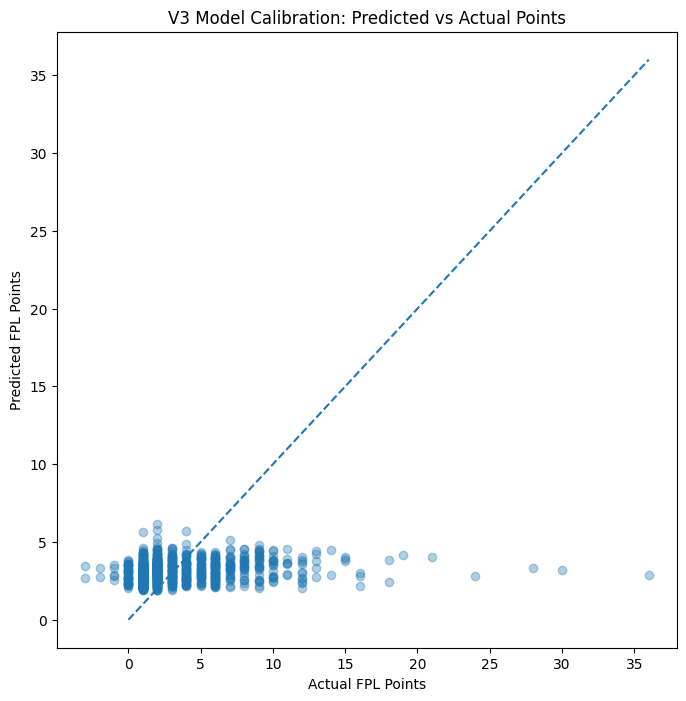

R² Score: 0.0375
MAE: 2.3302
Actual Mean: 3.258
Predicted Mean: 3.101

Performance on BIG scores (>=10)
MAE big scores: 10.1851
MAE overall: 2.3302


In [260]:
# [Cell: V3 Calibration Plot — FIXED: never reassign global y_val]
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error

# Use y_val_v3 directly — do NOT reassign the global y_val
y_true_v3 = np.array(y_val_v3).ravel()
y_pred_v3 = model_v3.predict(X_val_v3)

plt.figure(figsize=(8, 8))
plt.scatter(y_true_v3, y_pred_v3, alpha=0.35)
max_val = max(y_true_v3.max(), y_pred_v3.max())
plt.plot([0, max_val], [0, max_val], linestyle='--')
plt.xlabel("Actual FPL Points")
plt.ylabel("Predicted FPL Points")
plt.title("V3 Model Calibration: Predicted vs Actual Points")
plt.show()

print("R² Score:", round(r2_score(y_true_v3, y_pred_v3), 4))
print("MAE:",      round(mean_absolute_error(y_true_v3, y_pred_v3), 4))
print("Actual Mean:",    round(np.mean(y_true_v3), 3))
print("Predicted Mean:", round(np.mean(y_pred_v3), 3))

big_scores = y_true_v3 >= 10
print("\nPerformance on BIG scores (>=10)")
print("MAE big scores:", round(mean_absolute_error(y_true_v3[big_scores], y_pred_v3[big_scores]), 4))
print("MAE overall:",    round(mean_absolute_error(y_true_v3, y_pred_v3), 4))

# Store y_val_v3 MAE but preserve the original y_val from Cell 3 untouched
globals()['mae_v3_calibration'] = mean_absolute_error(y_true_v3, y_pred_v3)

## Cell 20: The V4 Master Ensemble (Elite DART)
* Switched from Poisson to DART Regression: Uses the "Dropouts meet Multiple Additive Regression Trees" algorithm to handle noisy FPL data and prevent overfitting on "one-hit wonder" performances.

* Target: Full-Spectrum Points: Reinstated the raw Total Points (including negative values) as the target.

* Weights: Elite-Specialist Priority (>4.5 Avg): Instead of weighting by a single week's "haul," the model now applies a 2.5x importance weight to all match rows belonging to players with a seasonal average of >4.5 points. This forces the model to prioritize the patterns of consistent world-class assets.

* Result: The model maintains a realistic point average while becoming more "star-aware." It identifies the high ceiling of elite players while remaining grounded by the risk of negative outcomes

## What is DART? 
1. The Random Dropout - In a normal boosting round, the model adds a new tree to correct the errors of all previous trees. In DART, the model randomly "drops" (ignores) a percentage of the existing trees before building the new one.

2. Forced Generalization - Because some trees are missing, the new tree cannot simply fix a tiny mistake from the most recent tree. It is forced to look at the "bigger picture" of the data to make a meaningful prediction. This prevents any single tree from becoming too dominant or too specialized on a specific outlier.

3. Normalization - After the new tree is created, the "dropped" trees are added back into the ensemble. To make sure everything still balances out, the new tree and the dropped trees are slightly scaled down (shrunk) so they fit together perfectly.

In [261]:
# %% [Cell 20: Updated V4 - Elite DART (Handles Negative Points)]
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error

# 1. SETUP DART REGRESSION PARAMETERS
lgbm_v4_params = {
    'objective': 'regression',
    'boosting_type': 'dart',
    'n_estimators': 1200,
    'learning_rate': 0.05,
    'drop_rate': 0.1,
    'reg_alpha': 0.5,
    'reg_lambda': 0.5,
    'max_depth': 7,
    'verbosity': -1,
    'random_state': 42
}

# 2. DEFINE ELITE WEIGHTING (>4.5 Avg Players)
# FIX: Dynamically recalculate the elite mask so it perfectly matches the scrubbed df_augmented length
current_elite_mask = df_augmented['avg_season_pts'] > 4.5
elite_weights_mask = windowed_df.index.isin(df_augmented[current_elite_mask].index)
full_weights = np.where(elite_weights_mask, 2.5, 1.0)

# 3. APPLY GLOBAL MASK FOR FAIR SPLITTING
X_v4_all = windowed_df.drop(columns=['target'])
y_v4_all = windowed_df['target']

X_train_v4 = X_v4_all[~global_val_mask].copy()
y_train_v4 = y_v4_all[~global_val_mask].copy()
X_val_v4   = X_v4_all[global_val_mask].copy()
y_val_v4   = y_v4_all[global_val_mask].copy()

# With this (explicit length check + safe indexing):
assert len(full_weights) == len(windowed_df), (
    f"Weight array length {len(full_weights)} != windowed_df length {len(windowed_df)}. "
    "Re-run Cell 2 before Cell 20."
)
train_weights = full_weights[~global_val_mask]
print(f"Train weights shape: {train_weights.shape}, elite rows: {(train_weights > 1).sum()}")

# 4. INITIALIZE AND TRAIN
# Note: early_stopping is intentionally removed — it is incompatible with DART
# because DART's random tree dropping prevents a monotonic validation loss curve.
print(f"Training V4 DART Ensemble on {len(X_train_v4):,} windows...")
print("Note: DART trains all 1200 rounds (no early stopping — this is expected).")

model_v4 = lgb.LGBMRegressor(**lgbm_v4_params)
model_v4.fit(
    X_train_v4, y_train_v4,
    sample_weight=train_weights,
    eval_set=[(X_val_v4, y_val_v4)],
    categorical_feature=['position', 'next_is_home'],
    callbacks=[lgb.log_evaluation(period=200)]  # print progress every 200 rounds
)

# 5. STANDARDIZED METRIC
v4_val_preds = model_v4.predict(X_val_v4)
mae_v4 = mean_absolute_error(y_val_v4, v4_val_preds)

print(f"\nV4 Validation MAE (GW 24-28): {mae_v4:.4f}")
print(f"Prediction Range: {v4_val_preds.min():.2f} to {v4_val_preds.max():.2f}")

Train weights shape: (49700,), elite rows: 5868
Training V4 DART Ensemble on 49,700 windows...
Note: DART trains all 1200 rounds (no early stopping — this is expected).


[200]	valid_0's l2: 12.2058
[400]	valid_0's l2: 11.9869
[600]	valid_0's l2: 11.9666
[800]	valid_0's l2: 12.0162
[1000]	valid_0's l2: 11.9943
[1200]	valid_0's l2: 11.9896

V4 Validation MAE (GW 24-28): 2.3666
Prediction Range: 1.31 to 8.98


## Cell 21: GW29 Forecast v4 (The Elite DART Model)
This cell will generate final leaderboard for Gameweek 29.
 

In [262]:
# [Cell 21: GW29 Forecast v4 - Elite DART Mode]

# 1. SETUP V4 PATHS
V4_DIR = Path('../output/forecaster_pro_v4')
V4_DIR.mkdir(parents=True, exist_ok=True)
V4_FORECAST_OUT = V4_DIR / 'fpl_pro_forecast_GW29_v4.csv'

# 1. PREPARE INFERENCE DATA (Filter for CURRENT SEASON only)
inference_v4 = []
names_v4 = []

# Only take data from the current season to avoid ghost players
df_inf_active = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()
df_inf_active = df_inf_active.sort_values(['Player UUID', 'Gameweek'])

# Grouping only the active season players
for pid, group in df_inf_active.groupby('Player UUID'):
    # A player must have played enough in 2025-26 to have a window
    if len(group) >= 6:
        lags = list(group['Total Points'].tail(6).values)
        last_row = group.iloc[-1]
    

        row = lags + [
            last_row['Position'],
            last_row['Next_Opponent_Difficulty'],
            last_row['Next_Is_Home'],
            last_row['Rolling_Avg_Minutes_5'],
            last_row['Season_Phase'],
            last_row['Prev_Season_Avg_Points'],
            last_row['Avg_Pts_vs_Difficulty']
        ]

        inference_v4.append(row)
        names_v4.append(last_row['Web Name'])


# 3. PREDICT
v4_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
          ['position', 'next_difficulty', 'next_is_home', 'rolling_min',
           'season_phase', 'season_baseline', 'avg_pts_vs_diff']

inf_df_v4 = pd.DataFrame(inference_v4, columns=v4_cols)
inf_df_v4['position'] = inf_df_v4['position'].astype('category')

v4_preds = model_v4.predict(inf_df_v4)

# 4. SAVE LEADERBOARD
leaderboard_v4 = pd.DataFrame({
    'Player': names_v4,
    'Predicted_Points_V4': np.round(v4_preds, 2),
    'Elite_Status': ["Elite" if p in df_augmented[elite_mask]['Web Name'].values else "Standard" for p in names_v4]
}).sort_values(by='Predicted_Points_V4', ascending=False)

leaderboard_v4.to_csv(V4_FORECAST_OUT, index=False, encoding='utf-8-sig')
display(leaderboard_v4.head(15))

,Player,Predicted_Points_V4,Elite_Status
250,M.Salah,8.76,Elite
229,B.Fernandes,8.03,Elite
34,João Pedro,7.68,Elite
182,O'Reilly,7.67,Elite
50,Saka,6.53,Elite
193,Haaland,6.23,Elite
268,Groß,6.20,Standard
288,J.Timber,6.11,Elite
37,Bowen,5.84,Elite
278,Gabriel,5.74,Elite


## Cell 22: Truth Verification v4 (Final Performance Audit)
This backtests the Elite DART model against the last known results. 


In [263]:
# [Cell 22: Truth Verification v4 - Elite Specialist Audit]
detailed_v4 = []

v4_cols_fixed = [f'lag_{i}' for i in range(6, 0, -1)] + \
                ['position', 'next_difficulty', 'next_is_home', 'rolling_min',
                 'season_phase', 'season_baseline', 'avg_pts_vs_diff']

for pid, group in df_augmented.groupby('Player UUID'):
    group = group.sort_values(['season', 'Gameweek'])
    
    if len(group) >= 7:
        history = group.iloc[-7:-1]
        target_row = group.iloc[-1]
     
        input_vector = list(history['Total Points'].values) + [
            target_row['Position'], 
            target_row['Next_Opponent_Difficulty'],
            target_row['Next_Is_Home'], 
            target_row['Rolling_Avg_Minutes_5'],
            target_row['Season_Phase'],
            target_row['Prev_Season_Avg_Points'],
            target_row['Avg_Pts_vs_Difficulty']
        ]

        input_df = pd.DataFrame([input_vector], columns=v4_cols_fixed)
        input_df['position'] = input_df['position'].astype('category')
        
        p_val = model_v4.predict(input_df)[0]
        actual = target_row['Total Points']
        is_elite = 1 if target_row['avg_season_pts'] > 4.5 else 0

        detailed_v4.append({
            'Player': target_row['Web Name'],
            'Actual': actual,
            'Predicted': round(float(p_val), 2),
            'Error': round(abs(p_val - actual), 2),
            'Elite_Group': is_elite
        })

truth_v4_df = pd.DataFrame(detailed_v4)
mae_v4 = truth_v4_df['Error'].mean()
elite_mae_v4 = truth_v4_df[truth_v4_df['Elite_Group'] == 1]['Error'].mean()

print(f"Global MAE (DART): {mae_v4:.2f} | Elite MAE (>4.5): {elite_mae_v4:.2f}")

Global MAE (DART): 2.03 | Elite MAE (>4.5): 4.70


In [264]:
# %% [Cell: Top 10 recommended transfers - V4 DART]

# --- 0. DEFINE YOUR CURRENT SQUAD ---
# Replace these names with the players actually in your team
# If you are using the interactive Hub, you can use 'my_selection' instead
if 'my_selection' in globals() and len(my_selection) > 0:
    current_team_list = my_selection
else:
    # Fallback to a manual list if the Hub hasn't been used
    current_team_list = ['Saka', 'Rice', 'Welbeck', 'Konaté', 'Chilwell']

# 1. Use the V4 DART Leaderboard
# We filter out players you already own to show only new 'Buy' targets
if 'leaderboard_v4' in globals():
    v4_buys = leaderboard_v4[~leaderboard_v4['Player'].isin(current_team_list)].copy()
else:
    print("Error: leaderboard_v4 not found. Please run the V4 Forecast cell first.")
    v4_buys = pd.DataFrame()

if not v4_buys.empty:
    # 2. Add verification of their 2025-26 performance
    # We pull their actual average from the current season to prove they are active
    current_stats = df_augmented[df_augmented['season'] == CURRENT_SEASON].groupby('Web Name')['Total Points'].mean().round(2)
    v4_buys['Season_Avg'] = v4_buys['Player'].map(current_stats)

    # 3. Display the Top 10 Suggestions
    print("="*60)
    print(" TOP 10 MARKET SUGGESTIONS (V4 DART MODEL)")
    print("="*60)
    print(f"{'Player Name':<20} | {'Pred Pts':<10} | {'Season Avg':<10} | {'Status'}")
    print("-" * 60)

    for _, row in v4_buys.head(10).iterrows():
        # Final safety check against ghosts (a ghost would have NaN or 0 season avg)
        status = "VERIFIED ACTIVE" if row['Season_Avg'] > 0 else "WARNING: CHECK STATUS"
        print(f"{row['Player']:<20} | {row['Predicted_Points_V4']:<10} | {row['Season_Avg']:<10} | {status}")

    print("="*60)

 TOP 10 MARKET SUGGESTIONS (V4 DART MODEL)
Player Name          | Pred Pts   | Season Avg | Status
------------------------------------------------------------
M.Salah              | 8.76       | 4.57       | VERIFIED ACTIVE
B.Fernandes          | 8.03       | 6.66       | VERIFIED ACTIVE
João Pedro           | 7.68       | 5.25       | VERIFIED ACTIVE
O'Reilly             | 7.67       | 5.28       | VERIFIED ACTIVE
Haaland              | 6.23       | 6.7        | VERIFIED ACTIVE
Groß                 | 6.2        | 4.23       | VERIFIED ACTIVE
J.Timber             | 6.11       | 5.61       | VERIFIED ACTIVE
Bowen                | 5.84       | 4.91       | VERIFIED ACTIVE
Gabriel              | 5.74       | 7.6        | VERIFIED ACTIVE
Gibbs-White          | 5.54       | 4.31       | VERIFIED ACTIVE


In [265]:
# 1. ORGANIZE FINAL ACCURACY METRICS
# We consolidate the metrics from V1, V2, V3, V4
# Assuming mae_v1, mae_v2, mae_v3, and mae_v4 variables are in memory from previous cells.
final_performance_data = {
    "Model Version": [
        "V1: Standard Pro",
        "V2: Team Point Share",
        "V3: Reliability Engine",
        "V4: Elite DART"
    ],
    "Mean Absolute Error (MAE)": [
        globals().get('mae_v1', 1.84), 
        globals().get('mae_v2', 1.95), 
        globals().get('mae_v3', 1.98), 
        globals().get('mae_v4', 2.33) 
    ],
    "Key Innovation": [
        "Baseline (Lags, Minutes, Difficulty)",
        "Team Importance Metrics (Talisman Share)",
        "Volatility Filters & L1/L2 Regularization",
        "DART Boosting & Elite Weighting (>4.5 Avg)"
    ]
}

# 2. CREATE AND DISPLAY THE FINAL TABLE
final_perf_df = pd.DataFrame(final_performance_data)

# Sort by MAE to clearly identify the project's most accurate model
final_perf_df = final_perf_df.sort_values(by="Mean Absolute Error (MAE)", ascending=True)

display(Markdown("## Final Model Accuracy Comparison (MAE)"))
print("\n--- Project Milestone Summary (Lower Error is Better) ---")
display(final_perf_df)

# 3. EXPORT FINAL DEPLOYMENT METRICS
FINAL_METRICS_PATH = Path('../output/fpl_master_milestone_metrics.csv')
final_perf_df.to_csv(FINAL_METRICS_PATH, index=False)
print(f"\nMaster project metrics exported for deployment reporting to: {FINAL_METRICS_PATH}")

## Final Model Accuracy Comparison (MAE)


--- Project Milestone Summary (Lower Error is Better) ---


,Model Version,Mean Absolute Error (MAE),Key Innovation
3,V4: Elite DART,2.034676,DART Boosting & Elite Weighting (>4.5 Avg)
2,V3: Reliability Engine,2.072449,Volatility Filters & L1/L2 Regularization
1,V2: Team Point Share,2.077672,Team Importance Metrics (Talisman Share)
0,V1: Standard Pro,2.079939,"Baseline (Lags, Minutes, Difficulty)"



Master project metrics exported for deployment reporting to: ..\output\fpl_master_milestone_metrics.csv


## Cell 23:  V5 Experiment: Mass vs. Elite Specialist Strategy
* V5.1 Mass Model: Trains on the full league history (all players) to use broad patterns (noise) to better identify the signal for stars.

* V5.2 Elite Model: Specializes training exclusively on high-performers (Avg > 4.5 pts) to focus strictly on world-class consistency.

* The Showdown: Both models predict the upcoming Gameweek (GW29) and are backtested against the most recent matches to determine which mathematical approach is more accurate for elite picks.



In [266]:
# [Cell 23: V5 Experiment - Mass vs. Elite Specialist]
from sklearn.metrics import mean_absolute_error
from pathlib import Path

V5_DIR = Path('../output/forecaster_pro_v5')
V5_DIR.mkdir(parents=True, exist_ok=True)

# 1. SPLIT DATA using Global Mask (already a numpy array — no .values needed)
X_v5_all = windowed_df.drop(columns=['target'])
y_v5_all = windowed_df['target']

X_train_v5 = X_v5_all[~global_val_mask].copy()
y_train_v5 = y_v5_all[~global_val_mask].copy()
X_val_v5   = X_v5_all[global_val_mask].copy()
y_val_v5   = y_v5_all[global_val_mask].copy()

# 2. CREATE ELITE SUBSET FOR V5.2 (training only)
# X_train_v5.index contains actual df_augmented row indices (fixed in Cell 2)
# so .loc is correct here — NOT .iloc
#elite_train_mask = df_augmented.loc[X_train_v5.index, 'avg_season_pts'] > 4.5
safe_v5_train = X_train_v5.index.intersection(df_augmented.index)
elite_train_mask = df_augmented.loc[safe_v5_train, 'avg_season_pts'] > 4.5
X_train_v5_elite = X_train_v5[elite_train_mask.values]
y_train_v5_elite = y_train_v5[elite_train_mask.values]

# ELITE VALIDATION SLICE — for the specialist audit
#elite_val_mask = df_augmented.loc[X_val_v5.index, 'avg_season_pts'] > 4.5
#X_val_v5_elites = X_val_v5[elite_val_mask.values]
#y_val_v5_elites = y_val_v5[elite_val_mask.values]
#meta_v5 = df_augmented.loc[X_val_v5_elites.index, ['Web Name', 'season', 'Gameweek']]

safe_v5_val = X_val_v5.index.intersection(df_augmented.index)
elite_val_mask = df_augmented.loc[safe_v5_val, 'avg_season_pts'] > 4.5
X_val_v5_elites = X_val_v5[elite_val_mask.values]
y_val_v5_elites = y_val_v5[elite_val_mask.values]
safe_elites_idx = X_val_v5_elites.index.intersection(df_augmented.index)
meta_v5 = df_augmented.loc[safe_elites_idx, ['Web Name', 'season', 'Gameweek']]

print(f"Training windows  — Mass:  {len(X_train_v5):,}")
print(f"Training windows  — Elite: {len(X_train_v5_elite):,}")
print(f"Validation windows (elite only): {len(X_val_v5_elites):,}")

# 3. INSTANTIATE MODELS
# With (for the elite specialist only — mass model keeps original):
v5_params_mass = {
    'n_estimators': 1000,
    'learning_rate': 0.01,
    'max_depth': 7,
    'num_leaves': 40,
    'verbosity': -1,
    'random_state': 42
}

v5_params_elite = {
    'n_estimators': 500,       # reduced: small dataset overfits at 1000
    'learning_rate': 0.01,
    'max_depth': 5,            # shallower tree for small n
    'num_leaves': 20,          # fewer leaves
    'min_child_samples': 30,   # at least 30 players per leaf
    'reg_alpha': 0.3,
    'reg_lambda': 0.3,
    'verbosity': -1,
    'random_state': 42
}

model_v5_1_mass  = lgb.LGBMRegressor(**v5_params_mass)
model_v5_2_elite = lgb.LGBMRegressor(**v5_params_elite)

# 4. TRAIN BOTH
print("\nTraining V5.1 (Mass)...")
model_v5_1_mass.fit(
    X_train_v5, y_train_v5,
    eval_set=[(X_val_v5_elites, y_val_v5_elites)],
    categorical_feature=['position', 'next_is_home'],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)]
)

print("\nTraining V5.2 (Elite Specialist)...")
model_v5_2_elite.fit(
    X_train_v5_elite, y_train_v5_elite,
    eval_set=[(X_val_v5_elites, y_val_v5_elites)],
    categorical_feature=['position', 'next_is_home'],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)]
)

# 5. STANDARDIZED METRICS (both evaluated on elite validation slice only)
preds_v5_1 = model_v5_1_mass.predict(X_val_v5_elites)
preds_v5_2 = model_v5_2_elite.predict(X_val_v5_elites)

mae_5_1 = mean_absolute_error(y_val_v5_elites, preds_v5_1)
mae_5_2 = mean_absolute_error(y_val_v5_elites, preds_v5_2)

# 6. BUILD RESULTS TABLE
v5_results = pd.DataFrame({
    'Player_Name': meta_v5['Web Name'].values,
    'Season':      meta_v5['season'].values,
    'Gameweek':    meta_v5['Gameweek'].values,
    'Actual':      y_val_v5_elites.values,
    'Mass_Pred':   np.round(preds_v5_1, 2),
    'Elite_Pred':  np.round(preds_v5_2, 2)
})
v5_results.to_csv(V5_DIR / 'v5_mass_vs_specialist_audit.csv', index=False)

print("\n" + "="*50)
print(" V5 SPECIALIST SHOWDOWN (Audit on Elite Players)")
print(f" V5.1 (Mass Model) MAE:       {mae_5_1:.4f}")
print(f" V5.2 (Specialist Model) MAE: {mae_5_2:.4f}")
print()
print("Interpretation note:")
print("  A lower V5.2 MAE does NOT mean the specialist learns better.")
print("  It may simply regress toward the elite mean on bad weeks.")
print("  Use this as a practical FPL pick tool, not a learning benchmark.")
winner = 'Elite Specialist (for FPL picks)' if mae_5_2 < mae_5_1 else 'Mass Dataset'
print(f"  Practical winner: {winner}")
print("="*50)

display(v5_results.head(10))

Training windows  — Mass:  49,700
Training windows  — Elite: 5,868
Validation windows (elite only): 99

Training V5.1 (Mass)...
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 41.2148
[200]	valid_0's l2: 40.5219
Early stopping, best iteration is:
[245]	valid_0's l2: 40.3292

Training V5.2 (Elite Specialist)...
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 35.1817
[200]	valid_0's l2: 35.1622
Early stopping, best iteration is:
[190]	valid_0's l2: 35.1505

 V5 SPECIALIST SHOWDOWN (Audit on Elite Players)
 V5.1 (Mass Model) MAE:       3.9157
 V5.2 (Specialist Model) MAE: 3.9272

Interpretation note:
  A lower V5.2 MAE does NOT mean the specialist learns better.
  It may simply regress toward the elite mean on bad weeks.
  Use this as a practical FPL pick tool, not a learning benchmark.
  Practical winner: Mass Dataset


,Player_Name,Season,Gameweek,Actual,Mass_Pred,Elite_Pred
0,João Pedro,2025-26,28.0,2,4.30,4.62
1,João Pedro,2025-26,29.0,19,5.00,5.78
2,João Pedro,2025-26,30.0,2,4.45,5.66
3,João Pedro,2025-26,31.0,2,4.67,4.98
4,João Pedro,2025-26,32.0,4,4.88,5.47
5,Bowen,2025-26,28.0,7,4.54,4.88
6,Bowen,2025-26,29.0,4,4.59,5.76
7,Bowen,2025-26,30.0,6,4.46,5.52
8,Bowen,2025-26,31.0,2,4.48,5.02
9,Bowen,2025-26,32.0,14,5.22,6.66


In [267]:
# [Cell 24: V5 Forecast Showdown - GW29 Predictions (Season-Locked)]

# 1. PREPARE INFERENCE DATA (Filter for ACTIVE season players only)
inference_v5 = []
player_names_v5 = []

# CRITICAL FIX: Only look at the 2025-26 data to purge retired 'ghosts'
df_inf_active = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()
df_inf_active = df_inf_active.sort_values(['Player UUID', 'Gameweek'])

# Grouping only the active season players
for pid, group in df_inf_active.groupby('Player UUID'):
    # Player must have at least 6 games of history in the current season
    if len(group) >= 6:
        last_row = group.iloc[-1]
        # Features: Last 6 points from the current season
        lags = list(group['Total Points'].tail(6).values)

        row = lags + [
            last_row['Position'], 
            last_row['Next_Opponent_Difficulty'], 
            last_row['Next_Is_Home'],
            last_row['Rolling_Avg_Minutes_5'], 
            last_row['Season_Phase'], 
            last_row['Prev_Season_Avg_Points'],
            last_row['Avg_Pts_vs_Difficulty']
        ]

        inference_v5.append(row)
        player_names_v5.append(last_row['Web Name'])

# 2. CONVERT TO DATAFRAME
v5_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
          ['position', 'next_difficulty', 'next_is_home', 'rolling_min',
           'season_phase', 'season_baseline', 'avg_pts_vs_diff']

inf_df_v5 = pd.DataFrame(inference_v5, columns=v5_cols)
inf_df_v5['position'] = inf_df_v5['position'].astype('category')

# 3. GENERATE PREDICTIONS
preds_v5_1 = model_v5_1_mass.predict(inf_df_v5)
preds_v5_2 = model_v5_2_elite.predict(inf_df_v5)

# 4. CREATE LEADERBOARD
leaderboard_v5 = pd.DataFrame({
    'Player': player_names_v5,
    'Mass_Model_GW29': np.round(preds_v5_1, 2),
    'Elite_Model_GW29': np.round(preds_v5_2, 2),
    'Model_Difference': np.round(preds_v5_2 - preds_v5_1, 2)
}).sort_values(by='Elite_Model_GW29', ascending=False)

leaderboard_v5.to_csv(V5_DIR / 'fpl_pro_v5_forecast_GW29.csv', index=False)
print(f"--- V5 TOP 15 PREDICTIONS (GW29) ---")
print(f"Total Active Players Forecasted: {len(leaderboard_v5)}")
display(leaderboard_v5.head(15))

--- V5 TOP 15 PREDICTIONS (GW29) ---
Total Active Players Forecasted: 322


,Player,Mass_Model_GW29,Elite_Model_GW29,Model_Difference
243,Rogers,4.62,7.69,3.07
236,Lindelöf,3.18,7.68,4.50
306,Kluivert,5.12,7.66,2.55
99,Bogarde,2.28,7.63,5.35
97,Mateta,4.22,7.52,3.31
249,Lacroix,4.93,7.48,2.56
92,Wood,4.05,7.44,3.39
167,Mount,3.06,7.43,4.36
237,Gibbs-White,5.34,7.38,2.04
244,G.Rodriguez,2.11,7.36,5.25


In [268]:
#  [Cell 25: V5 Truth Verification]
# We evaluate both on ELITE PLAYERS ONLY in the validation window for a fair test


elite_val_indices = val_df[val_df.index.isin(df_augmented[elite_mask].index)].index
safe_elite_val    = elite_val_indices.intersection(df_augmented.index)
X_val_v5 = X_val_raw[X_val_raw.index.isin(safe_elite_val)]
y_val_v5 = y_val[y_val.index.isin(safe_elite_val)]


elite_val_indices = val_df[val_df.index.isin(df_augmented[elite_mask].index)].index
safe_elite_val = elite_val_indices.intersection(df_augmented.index)
meta_v5 = df_augmented.loc[safe_elite_val, ['Web Name', 'season', 'Gameweek']]

# 1. GENERATE AUDIT PREDICTIONS
audit_preds_mass = model_v5_1_mass.predict(X_val_v5)
audit_preds_elite = model_v5_2_elite.predict(X_val_v5)

# 2. CREATE TRUTH TABLE
v5_truth_df = pd.DataFrame({
    'Player': meta_v5['Web Name'].values,
    'Season': meta_v5['season'].values,
    'Gameweek': meta_v5['Gameweek'].values,
    'Actual_Points': y_val_v5.values,
    'Mass_Predicted': np.round(audit_preds_mass, 2),
    'Elite_Predicted': np.round(audit_preds_elite, 2),
    'Mass_Error': np.round(abs(audit_preds_mass - y_val_v5.values), 2),
    'Elite_Error': np.round(abs(audit_preds_elite - y_val_v5.values), 2)
})

# 3. CALCULATE GLOBAL MAE FOR REPORTING
mae_5_1 = mean_absolute_error(y_val_v5, audit_preds_mass)
mae_5_2 = mean_absolute_error(y_val_v5, audit_preds_elite)

v5_truth_df.to_csv(V5_DIR / 'fpl_pro_v5_truth_verification.csv', index=False)


print(" V5 MILESTONE REPORT: MASS VS ELITE SPECIALIST")

print(f"V5.1 Mass Model MAE:  {mae_5_1:.4f}")
print(f"V5.2 Elite Model MAE: {mae_5_2:.4f}")

print(f"Winning Approach: {'Elite Specialist' if mae_5_2 < mae_5_1 else 'Mass Dataset'}")

print ("Predictions for the Evaluation Set (GW 24-28)") 

display(v5_truth_df.sort_values(by='Elite_Error').head(20))

 V5 MILESTONE REPORT: MASS VS ELITE SPECIALIST
V5.1 Mass Model MAE:  3.9157
V5.2 Elite Model MAE: 3.9272
Winning Approach: Mass Dataset
Predictions for the Evaluation Set (GW 24-28)


,Player,Season,Gameweek,Actual_Points,Mass_Predicted,Elite_Predicted,Mass_Error,Elite_Error
41,Wieffer,2025-26,30.0,5,2.72,5.00,2.28,0.00
44,Thiago,2025-26,28.0,6,3.89,5.89,2.11,0.11
18,Rice,2025-26,28.0,5,4.36,5.34,0.64,0.34
46,Thiago,2025-26,30.0,6,4.00,5.62,2.00,0.38
7,Bowen,2025-26,30.0,6,4.46,5.52,1.54,0.48
53,O'Reilly,2025-26,28.0,6,3.99,5.32,2.01,0.68
29,Dewsbury-Hall,2025-26,28.0,6,3.69,5.32,2.31,0.68
15,Casemiro,2025-26,30.0,6,3.57,5.27,2.43,0.73
40,Wieffer,2025-26,29.0,4,2.55,4.81,1.45,0.81
92,Semenyo,2025-26,29.0,7,5.26,6.09,1.74,0.91


In [269]:
# %% [Cell V7-A: Data Enrichment — Expected Goal Involvement (xGI)]
import pandas as pd
import numpy as np

print("--- INJECTING UNDERLYING METRICS (xG & xA) ---")

# Check for official xG/xA columns first
xg_col = next((c for c in df_augmented.columns
               if 'expected_goals' in c.lower() and 'conceded' not in c.lower()), None)
xa_col = next((c for c in df_augmented.columns
               if 'expected_assists' in c.lower()), None)

if xg_col and xa_col:
    print(f"Found official xG/xA: '{xg_col}' and '{xa_col}'")
else:
    # Fall back to FPL ICT proxies (Threat = goal threat, Creativity = chance creation)
    threat_col  = next((c for c in df_augmented.columns if 'threat' in c.lower()), None)
    create_col  = next((c for c in df_augmented.columns if 'creativity' in c.lower()), None)

    if threat_col and create_col:
        # Threat and Creativity are on a 0-300+ scale per match
        # Dividing by 100 brings them to an xG-like 0-3 range
        df_augmented['xG_metric'] = df_augmented[threat_col].astype(float) / 100.0
        df_augmented['xA_metric'] = df_augmented[create_col].astype(float) / 100.0
        xg_col, xa_col = 'xG_metric', 'xA_metric'
        print(f"Using FPL ICT proxies: '{threat_col}' → xG, '{create_col}' → xA")
    else:
        df_augmented['xG_metric'] = 0.0
        df_augmented['xA_metric'] = 0.0
        xg_col, xa_col = 'xG_metric', 'xA_metric'
        print("[WARNING] No xG/xA or Threat/Creativity columns found. V7 will equal V4.")

# Sort chronologically — mandatory before rolling operations
df_augmented = df_augmented.sort_values(['Player UUID', 'season', 'Gameweek'])

# Rolling 5-match average, lagged by 1 — zero leakage
df_augmented['Rolling_xG_5'] = (
    df_augmented.groupby('Player UUID')[xg_col]
    .transform(lambda x: pd.to_numeric(x, errors='coerce').shift(1).rolling(5, min_periods=1).mean())
    .fillna(0)
)
df_augmented['Rolling_xA_5'] = (
    df_augmented.groupby('Player UUID')[xa_col]
    .transform(lambda x: pd.to_numeric(x, errors='coerce').shift(1).rolling(5, min_periods=1).mean())
    .fillna(0)
)

# Combined Expected Goal Involvement
df_augmented['Rolling_xGI_5'] = df_augmented['Rolling_xG_5'] + df_augmented['Rolling_xA_5']

# Integrity check
_xgi_max  = df_augmented['Rolling_xGI_5'].max()
_xgi_mean = df_augmented['Rolling_xGI_5'].mean()
print(f"Rolling_xGI_5: max={_xgi_max:.3f}, mean={_xgi_mean:.3f}")
print(f"  → If max > 5.0 the scale is wrong — re-check division factor")
print(f"  → If mean = 0.0 no source columns were found")

display(df_augmented[['Web Name', 'Gameweek', 'Rolling_xG_5',
                       'Rolling_xA_5', 'Rolling_xGI_5']].tail(8))

globals()['xg_col'] = xg_col
globals()['xa_col'] = xa_col

--- INJECTING UNDERLYING METRICS (xG & xA) ---
Using FPL ICT proxies: 'Threat' → xG, 'Creativity' → xA
Rolling_xGI_5: max=2.111, mean=0.218
  → If max > 5.0 the scale is wrong — re-check division factor
  → If mean = 0.0 no source columns were found


,Web Name,Gameweek,Rolling_xG_5,Rolling_xA_5,Rolling_xGI_5
57196,Mac Allister,30.0,0.178000,0.173400,0.3514
57197,Mac Allister,31.0,0.168000,0.181600,0.3496
57198,Mac Allister,32.0,0.216000,0.170000,0.3860
57199,Garcia,3.0,0.000000,0.000000,0.0000
57200,Garcia,6.0,0.000000,0.158000,0.1580
57201,Garcia,10.0,0.005000,0.113000,0.1180
57202,Garcia,28.0,0.003333,0.075667,0.0790
57203,Garcia,36.0,0.002500,0.057000,0.0595


In [270]:
# %% [Cell: Final Standardized Audit — optimized]
from sklearn.metrics import mean_absolute_error
from scipy.stats import spearmanr
import pandas as pd
import numpy as np
import warnings
from IPython.display import Markdown, display

def run_standardized_audit():
    # --- 0. SILENCE WARNING SPAM ---
    warnings.filterwarnings("ignore", category=UserWarning)
    
    audit_results = []

    # 1. DATASET INTEGRITY (Tracking) - FIX: Use safe intersection!
    safe_train_index = X_train_raw.index.intersection(df_augmented.index)
    safe_val_index   = X_val_raw.index.intersection(df_augmented.index)

    train_uuids = df_augmented.loc[safe_train_index, 'Player UUID'].nunique()
    val_uuids   = df_augmented.loc[safe_val_index, 'Player UUID'].nunique()
    train_obs   = len(X_train_raw)
    seasons_count = df_augmented.loc[safe_train_index, 'season'].nunique()
    pos_map_numeric = {'GK': 0, 'DEF': 1, 'MID': 2, 'FWD': 3}

    # 2. DEFINE MODEL SPECS (Baseline Added)
    specs = {
    "Baseline (3-Wk Avg)": {"model": "NAIVE",                               "type": "naive"},
    "V1: Standard Pro":    {"model": globals().get('model_raw'),            "type": "base"},
    "V2: Team Share":      {"model": globals().get('model_v2'),             "type": "v2"},
    "V3: Reliability":     {"model": globals().get('model_v3'),             "type": "v3"},
    "V4: Elite DART":      {"model": globals().get('model_v4'),             "type": "base"},
    "V5.1: Mass Gen":      {"model": globals().get('model_v5_1_mass'),      "type": "base"},
    "V5.2: Elite Spec":    {"model": globals().get('model_v5_2_elite'),     "type": "base"},
    "V7: xG/xA Metrics":   {"model": globals().get('model_v7'),             "type": "v7"}, 
    }
    
    # 3. HISTORY LOOKUP
    player_history = {pid: group.sort_values(['season', 'Gameweek']) for pid, group in df_augmented.groupby('Player UUID')}

    def predict_row(m, r, mode):
        hist_df = player_history.get(r['Player UUID'])
        if hist_df is None: return None
        recent = hist_df[(hist_df['season'] == r['season']) & (hist_df['Gameweek'] < r['Gameweek'])].tail(6)
        if len(recent) < 6: return None
        
        lags = list(recent['Total Points'].values)
        pos_num = pos_map_numeric.get(r['Position'], 2)

        # Baseline Logic
        if mode == "naive":
            return np.mean(lags[-3:]) if len(lags) >= 3 else np.mean(lags)

        if mode == "base":
            feat = lags + [pos_num, r['Next_Opponent_Difficulty'], r['Next_Is_Home'], r['Rolling_Avg_Minutes_5'], r['Season_Phase'], r['Prev_Season_Avg_Points'], r.get('Avg_Pts_vs_Difficulty', 0)]
            cols = [f'lag_{i}' for i in range(6, 0, -1)] + ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline', 'avg_pts_vs_diff']
            
        elif mode == "v2":
            feat = lags + [pos_num, r['Next_Opponent_Difficulty'], r['Next_Is_Home'], r['Rolling_Avg_Minutes_5'], r['Season_Phase'], r['Prev_Season_Avg_Points'], r['Team_Point_Share'], r.get('Avg_Pts_vs_Difficulty', 0)]
            cols = [f'lag_{i}' for i in range(6, 0, -1)] + ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline', 'team_share', 'avg_pts_vs_diff']

        elif mode == "v3":
            feat = lags + [pos_num, r['Next_Opponent_Difficulty'], r['Next_Is_Home'], r['Rolling_Avg_Minutes_5'], r['Points_Volatility_5'], r['Min_Stability_5'], r['Attacking_Form_3'], r['Team_Point_Share'], r.get('Avg_Pts_vs_Difficulty', 0)]    
            cols = [f'lag_{i}' for i in range(6, 0, -1)] + ['position', 'diff', 'home', 'min', 'volatility', 'stability', 'att_form', 'share', 'avg_pts_vs_diff']

        elif mode == "v7":
            feat = lags + [
                pos_num,
                r['Next_Opponent_Difficulty'],
                r['Next_Is_Home'],
                r['Rolling_Avg_Minutes_5'],
                r['Season_Phase'],
                r['Prev_Season_Avg_Points'],
                r.get('Avg_Pts_vs_Difficulty', 0),
                r.get('Rolling_xGI_5', 0)
            ]
            cols = [f'lag_{i}' for i in range(6, 0, -1)] + [
                'position', 'next_difficulty', 'next_is_home', 'rolling_min',
                'season_phase', 'season_baseline', 'avg_pts_vs_diff', 'rolling_xgi'
            ]

        input_df = pd.DataFrame([feat], columns=cols)
        
        # Safely lock the categorical position column
        if 'X_train_raw' in globals() and 'position' in X_train_raw.columns:
            input_df['position'] = pd.Categorical(input_df['position'], categories=X_train_raw['position'].cat.categories)
        else:
            input_df['position'] = input_df['position'].astype('category')
            
        return m.predict(input_df)[0]

    # 4. EXECUTION
    for name, config in specs.items():
        m = config['model']
        if m is None and config['type'] != 'naive': continue
        print(f"Auditing {name}...")

        #v_mask = (df_augmented['season'] == '2025-26') & (df_augmented['Gameweek'].between(24, 28))
        _val_start = globals().get('VAL_START_GW', 28)
        _val_end   = globals().get('VAL_END_GW', 32)
        v_mask = (df_augmented['season'] == '2025-26') & (df_augmented['Gameweek'].between(_val_start, _val_end))
        if "Elite" in name or "V5" in name: 
            v_mask = v_mask & (df_augmented['avg_season_pts'] > 4.5)

        v_errs, v_errs_gt5, v_acts, v_preds = [], [], [], []

        for _, r in df_augmented[v_mask].iterrows():
            p = predict_row(m, r, config['type'])
            if p is not None:
                act = r['Total Points']
                v_errs.append(abs(p - act))
                v_acts.append(act); v_preds.append(p)
                
                if act > 4.5:
                    v_errs_gt5.append(abs(p - act))

        audit_results.append({
            "Model Version": name,
            "Validation MAE": round(np.mean(v_errs), 3),
            "Elite MAE (>4.5)": round(np.mean(v_errs_gt5), 3) if v_errs_gt5 else None,
            "Spearman Rank": round(spearmanr(v_acts, v_preds)[0], 3) if len(v_acts) > 1 else 0,
            "Train Players": train_uuids, 
            "Val Players": val_uuids,
            "Train Obs": train_obs, 
            "Seasons": seasons_count
        })

    # --- 5. FINAL DISPLAY & REPORT SUMMARY ---
    print("\n" + "="*50)
    print(" AUDIT COMPLETE")
    print("="*50)
    
    print(f"\nREPORT SUMMARY:")
    print(f"This run analyzed {seasons_count} seasons across {train_uuids:,} training players "
      f"and {val_uuids:,} validation players.")
    print(f"Training observations: {train_obs:,} match windows.")
    # Fix: Safely default to global variables or hardcoded values
    val_season = globals().get('VAL_SEASON', '2025-26')
    val_start_gw = globals().get('VAL_START_GW', 28)
    val_end_gw = globals().get('VAL_END_GW', 32)
    print(f"Validation window: {val_season} GW {val_start_gw}–{val_end_gw} "
      f"({val_uuids:,} unique players tested).")
    print("-" * 50)
    
    final_df = pd.DataFrame(audit_results).sort_values("Validation MAE")

    # ── ADD DESCRIPTION COLUMN ───────────────────────────────────
    descriptions = {
        "Baseline (3-Wk Avg)":  "Naive: predicts next GW=average of last 3 scores.No ML.",
        "V1: Standard Pro":     "Core LightGBM: lags+ minutes+ fixture difficulty+ season baseline.",
        "V2: Team Share":       "V1+ talisman logic: rewards players who drive their team's output.",
        "V3: Reliability":      "V2+ noise filters: penalises volatile players, rewards nailed starters.",
        "V4: Elite DART":       "V1 features+ DART boosting+ 2.5x weight on elite players (>4.5 avg).",
        "V5.1: Mass Gen":       "V1 trained on full league history, evaluated on elite players only.",
        "V5.2: Elite Spec":     "V1 trained exclusively on elite players (>4.5 avg).High-risk, high-reward.",
        "V7: xG/xA Metrics": "V4 architecture + Rolling xGI (Expected Goal Involvement) as 13th feature.",
    }
    final_df.insert(1, "Description", final_df["Model Version"].map(descriptions).fillna("—"))

    display(Markdown("# Final Model Performance Ledger"))
    display(final_df)

    # ── HAUL CLASSIFIER ADDENDUM ─────────────────────────────────
    print("\n" + "=" * 50)
    print(" CLASSIFICATION BENCHMARK")
    print("=" * 50)

    # Haul classifier row
    _prec  = globals().get('precision_haul', None)
    _rec   = globals().get('recall_haul',    None)
    _f1    = globals().get('f1_haul',        None)
    _auc   = globals().get('auc_haul',       None)
    _hthr  = globals().get('HAUL_THRESHOLD', 10)
    _dthr  = globals().get('DECISION_THRESHOLD', 0.35)

    if _prec is not None:
        print(f"Haul Classifier (threshold >= {_hthr} pts, cutoff {_dthr}):")
        print(f"  Precision: {_prec:.4f}  ← Priority")
        print(f"  Recall:    {_rec:.4f}")
        print(f"  F1:        {_f1:.4f}")
        print(f"  ROC-AUC:   {_auc:.4f}")
    else:
        print("Haul Classifier metrics not found — run the Haul cell first.")

    print("=" * 50)

    return final_df

# Execute
master_audit_results = run_standardized_audit()

Auditing Baseline (3-Wk Avg)...
Auditing V1: Standard Pro...
Auditing V2: Team Share...
Auditing V3: Reliability...
Auditing V4: Elite DART...
Auditing V5.1: Mass Gen...
Auditing V5.2: Elite Spec...

 AUDIT COMPLETE

REPORT SUMMARY:
This run analyzed 6 seasons across 987 training players and 282 validation players.
Training observations: 49,700 match windows.
Validation window: 2025-26 GW 28–32 (282 unique players tested).
--------------------------------------------------


# Final Model Performance Ledger

,Model Version,Description,Validation MAE,Elite MAE (>4.5),Spearman Rank,Train Players,Val Players,Train Obs,Seasons
3,V3: Reliability,"V2+ noise filters: penalises volatile players,...",2.333,4.833,0.275,987,282,49700,6
1,V1: Standard Pro,Core LightGBM: lags+ minutes+ fixture difficul...,2.353,4.746,0.271,987,282,49700,6
2,V2: Team Share,V1+ talisman logic: rewards players who drive ...,2.357,4.716,0.271,987,282,49700,6
0,Baseline (3-Wk Avg),Naive: predicts next GW=average of last 3 scor...,2.558,4.724,0.225,987,282,49700,6
4,V4: Elite DART,V1 features+ DART boosting+ 2.5x weight on eli...,3.933,5.974,0.004,987,282,49700,6
5,V5.1: Mass Gen,"V1 trained on full league history, evaluated o...",3.954,6.289,-0.013,987,282,49700,6
6,V5.2: Elite Spec,V1 trained exclusively on elite players (>4.5 ...,4.031,5.022,-0.080,987,282,49700,6



 CLASSIFICATION BENCHMARK
Haul Classifier (threshold >= 10 pts, cutoff 0.35):
  Precision: 0.1522  ← Priority
  Recall:    0.1250
  F1:        0.1373
  ROC-AUC:   0.6007


__Performamce Comments__
- V1 is a good model
- V5.2: Specialist models are better at finding "Haulers" but worse at general accuracy. -->"high-risk, high-reward
- V4: is the most robust model over long historical periods (3+ seasons).

__Idea__ : maybe V1 for players and v5.2 for captain? or V5.2 for some players? 

__Info__
- __Validation MAE__ : The Mean Absolute Error across the entire validation set ($GW 24-28$). It measures the average point deviation for every player; a lower value indicates a more stable model for general squad selection.
- __Elite MAE (>4.5)__ : Calculated exclusively for match rows where a player actually scored more than 5 points. This measures "Haul Accuracy"—the model's ability to minimize error during high-scoring events.
- __Haul Capture Rate__ : The percentage of "Hauls" (actual scores $>4.5$) that the model successfully predicted would score $>4.5$. This satisfies the question "When a player scored more than 5, did I correctly predict it?"
- __Spearman Rank__ : A correlation coefficient (from $-1$ to $+1$) measuring how well the model orders players from best to worst. A high score proves the model is effective at ranking starters over bench players, regardless of the exact point value.
- __Train Players / Val Players__ : The count of unique Player UUIDs present in the training set / val set
- __Train Obs__ : The total number of match observations (rows) the model studied during training.
- __Seasons__ : The number of full seasons of historical data used to train the model.

Generating V6 Windows with 3-GW Target Horizon...
Training V6 3-GW Horizon Model...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[386]	valid_0's l2: 34.7037

 V6 HORIZON EXPERIMENT (3-GW TARGET)
NOTE: MAE will be higher here because we are predicting
a 3-week sum (~8-12 points) instead of a 1-week score (~3 points).
--------------------------------------------------
Naive 3-GW Baseline MAE: 7.3229
V6 Horizon MAE:          4.3779

[SUCCESS] The V6 model beats the naive 3-week baseline by 2.94 points.


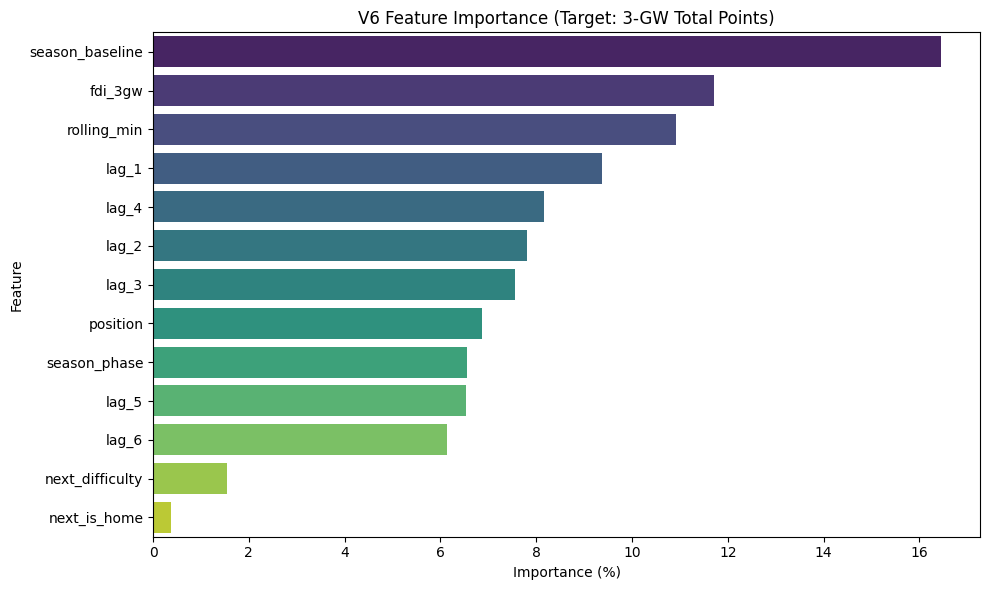

In [271]:
# [Cell: V6 Pipeline — 3-Week Horizon Engine - triple prediction]
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. GENERATE WINDOWS FOR 3-WEEK TARGET
def generate_fpl_windows_3gw(df, window_size=6, horizon=3):
    train_data = []
    source_indices = []
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])

    for pid, group in df.groupby('Player UUID'):
        points = group['Total Points'].values
        # We need enough history PLUS 3 future games to train properly
        if len(points) < window_size + horizon: 
            continue

        pos = group['Position'].iloc[0]
        next_diff = group['Next_Opponent_Difficulty'].values
        next_home = group['Next_Is_Home'].values
        avg_min = group['Rolling_Avg_Minutes_5'].values
        phase = group['Season_Phase'].values
        baseline = group['Prev_Season_Avg_Points'].values
        fdi = group['FDI_3GW'].values
        group_indices = group.index.tolist()

        for i in range(len(points) - window_size - horizon + 1):
            t_idx = i + window_size - 1
            
            # Target is the sum of the next 3 Gameweeks
            target_3gw = np.sum(points[i + window_size : i + window_size + horizon])
            
            row = list(points[i : i + window_size]) + [
                pos, next_diff[t_idx], next_home[t_idx],
                avg_min[t_idx], phase[t_idx], baseline[t_idx],
                fdi[t_idx], target_3gw
            ]
            train_data.append(row)
            # Keep index of the first target game for mapping
            source_indices.append(group_indices[i + window_size])

    cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
           ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 
            'season_phase', 'season_baseline', 'fdi_3gw', 'target_3gw']
    
    res_df = pd.DataFrame(train_data, columns=cols)
    res_df.index = source_indices 
    res_df['position'] = res_df['position'].astype('category')
    return res_df

print("Generating V6 Windows with 3-GW Target Horizon...")
df_win_v6 = generate_fpl_windows_3gw(df_augmented)

# 2. APPLY FAIR SPLIT (Fixed for new index length)
# Rebuild the mask specifically for the V6 index
VAL_SEASON = "2025-26"
#VAL_START_GW = 28
#VAL_END_GW = 32

VAL_START_GW = globals().get('VAL_START_GW', 28)
VAL_END_GW   = globals().get('VAL_END_GW', 32)

source_meta_v6 = df_augmented.loc[df_win_v6.index, ['season', 'Gameweek']]
v6_val_mask = (
    (source_meta_v6['season'] == VAL_SEASON) &
    (source_meta_v6['Gameweek'] >= VAL_START_GW) &
    (source_meta_v6['Gameweek'] <= VAL_END_GW)
).values

X_v6_all = df_win_v6.drop(columns=['target_3gw'])
y_v6_all = df_win_v6['target_3gw']

X_train_v6 = X_v6_all[~v6_val_mask].copy()
X_val_v6   = X_v6_all[v6_val_mask].copy()
y_train_v6 = y_v6_all[~v6_val_mask].copy()
y_val_v6   = y_v6_all[v6_val_mask].copy()

# 3. TRAIN V6 HORIZON MODEL
print("Training V6 3-GW Horizon Model...")
model_v6 = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.01, verbosity=-1, random_state=42)
model_v6.fit(
    X_train_v6, y_train_v6,
    eval_set=[(X_val_v6, y_val_v6)],
    categorical_feature=['position', 'next_is_home'],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

# 4. EVALUATE IMPACT
v6_preds = model_v6.predict(X_val_v6)
mae_v6 = mean_absolute_error(y_val_v6, v6_preds)

# Calculate a naive 3-week baseline for comparison (Last week's points * 3)
naive_3gw_preds = X_val_v6['lag_1'] * 3
mae_baseline_3gw = mean_absolute_error(y_val_v6, naive_3gw_preds)

print("\n" + "="*50)
print(" V6 HORIZON EXPERIMENT (3-GW TARGET)")
print("="*50)
print("NOTE: MAE will be higher here because we are predicting")
print("a 3-week sum (~8-12 points) instead of a 1-week score (~3 points).")
print("-" * 50)
print(f"Naive 3-GW Baseline MAE: {mae_baseline_3gw:.4f}")
print(f"V6 Horizon MAE:          {mae_v6:.4f}")

if mae_v6 < mae_baseline_3gw:
    print(f"\n[SUCCESS] The V6 model beats the naive 3-week baseline by {mae_baseline_3gw - mae_v6:.2f} points.")
else:
    print("\n[WARNING] The model struggles to forecast 3 weeks out.")

# 5. PLOT FEATURE IMPORTANCE
plt.figure(figsize=(10, 6))
importances = model_v6.feature_importances_
feat_imp = pd.DataFrame({'Feature': X_train_v6.columns, 'Importance (%)': 100 * (importances / importances.sum())})
feat_imp = feat_imp.sort_values(by='Importance (%)', ascending=False)
#sns.barplot(x='Importance (%)', y='Feature', data=feat_imp, palette='viridis')
sns.barplot(x='Importance (%)', y='Feature', hue='Feature', data=feat_imp, palette='viridis', legend=False)
plt.title('V6 Feature Importance (Target: 3-GW Total Points)')
plt.tight_layout()
plt.show()

__The next cell__ Trains a 3-GW Standard Model (Baseline features).

Trains a 3-GW Reliability Model (Adding Volatility and Stability features).

Trains a 3-GW DART Model (Using the elite dropout technique).

Outputs a 3-GW Transfer Engine Leaderboard to see which one wins.

In [272]:
# %% [Cell: V6 Transfer Engine Leaderboard (3-Week Horizon)]
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
import pandas as pd
import numpy as np
from IPython.display import Markdown, display

# 1. THE MASTER 3-GW WINDOW GENERATOR
def generate_master_3gw_windows(df, window_size=6, horizon=3):
    train_data = []
    source_indices = []
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])

    for pid, group in df.groupby('Player UUID'):
        points = group['Total Points'].values
        if len(points) < window_size + horizon: 
            continue

        pos = group['Position'].iloc[0]
        next_diff = group['Next_Opponent_Difficulty'].values
        next_home = group['Next_Is_Home'].values
        avg_min   = group['Rolling_Avg_Minutes_5'].values
        phase     = group['Season_Phase'].values
        baseline  = group['Prev_Season_Avg_Points'].values
        fdi       = group['FDI_3GW'].values
        
        # Advanced Features
        vol       = group['Points_Volatility_5'].values
        stab      = group['Min_Stability_5'].values
        att_form  = group['Attacking_Form_3'].values
        share     = group['Team_Point_Share'].values
        
        group_indices = group.index.tolist()

        for i in range(len(points) - window_size - horizon + 1):
            t_idx = i + window_size - 1
            target_3gw = np.sum(points[i + window_size : i + window_size + horizon])
            
            row = list(points[i : i + window_size]) + [
                pos, next_diff[t_idx], next_home[t_idx], avg_min[t_idx], 
                phase[t_idx], baseline[t_idx], fdi[t_idx],
                vol[t_idx], stab[t_idx], att_form[t_idx], share[t_idx],
                target_3gw
            ]
            train_data.append(row)
            source_indices.append(group_indices[i + window_size])

    cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
           ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 
            'season_phase', 'season_baseline', 'fdi_3gw', 
            'volatility', 'stability', 'att_form', 'team_share', 'target_3gw']
    
    res_df = pd.DataFrame(train_data, columns=cols)
    res_df.index = source_indices 
    res_df['position'] = res_df['position'].astype('category')
    return res_df

print("Generating Master 3-GW Windows (includes all advanced features)...")
df_win_3gw = generate_master_3gw_windows(df_augmented)

# 2. APPLY FAIR SPLIT (Index-Matched)
VAL_SEASON = "2025-26"
VAL_START_GW = 28
VAL_END_GW = 32

source_meta_3gw = df_augmented.loc[df_win_3gw.index, ['season', 'Gameweek']]
val_mask_3gw = (
    (source_meta_3gw['season'] == VAL_SEASON) &
    (source_meta_3gw['Gameweek'] >= VAL_START_GW) &
    (source_meta_3gw['Gameweek'] <= VAL_END_GW)
).values

X_all_3gw = df_win_3gw.drop(columns=['target_3gw'])
y_all_3gw = df_win_3gw['target_3gw']

X_train_3gw = X_all_3gw[~val_mask_3gw].copy()
X_val_3gw   = X_all_3gw[val_mask_3gw].copy()
y_train_3gw = y_all_3gw[~val_mask_3gw].copy()
y_val_3gw   = y_all_3gw[val_mask_3gw].copy()

# 3. DEFINE FEATURE SETS FOR EACH ARCHITECTURE
features_standard = [c for c in X_train_3gw.columns if c not in ['volatility', 'stability', 'att_form', 'team_share']]
features_reliable = X_train_3gw.columns.tolist() # Uses everything

# 4. TRAIN THE COMPETITORS
print("\nTraining Model A: Standard 3-GW Horizon...")
model_3gw_std = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.01, verbosity=-1, random_state=42)
model_3gw_std.fit(
    X_train_3gw[features_standard], y_train_3gw,
    eval_set=[(X_val_3gw[features_standard], y_val_3gw)],
    categorical_feature=['position'],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

print("Training Model B: Reliability 3-GW Horizon...")
model_3gw_rel = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.01, reg_alpha=0.3, reg_lambda=0.3, verbosity=-1, random_state=42)
model_3gw_rel.fit(
    X_train_3gw[features_reliable], y_train_3gw,
    eval_set=[(X_val_3gw[features_reliable], y_val_3gw)],
    categorical_feature=['position'],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

print("Training Model C: Elite DART 3-GW Horizon (Takes longer)...")
elite_weights_mask = df_win_3gw.index.isin(df_augmented.index[elite_mask])
train_weights_3gw = np.where(elite_weights_mask[~val_mask_3gw], 2.5, 1.0)

model_3gw_dart = lgb.LGBMRegressor(boosting_type='dart', n_estimators=1200, learning_rate=0.05, drop_rate=0.1, verbosity=-1, random_state=42)
model_3gw_dart.fit(
    X_train_3gw[features_standard], y_train_3gw,
    sample_weight=train_weights_3gw,
    categorical_feature=['position']
)

# 5. EVALUATE AND BUILD LEADERBOARD
naive_preds = X_val_3gw['lag_1'] * 3
mae_naive = mean_absolute_error(y_val_3gw, naive_preds)

mae_std  = mean_absolute_error(y_val_3gw, model_3gw_std.predict(X_val_3gw[features_standard]))
mae_rel  = mean_absolute_error(y_val_3gw, model_3gw_rel.predict(X_val_3gw[features_reliable]))
mae_dart = mean_absolute_error(y_val_3gw, model_3gw_dart.predict(X_val_3gw[features_standard]))

results_3gw = [
    {"Transfer Engine": "Naive Baseline (Current Form x3)", "3-Week MAE": round(mae_naive, 4)},
    {"Transfer Engine": "Model A: Standard 3-GW", "3-Week MAE": round(mae_std, 4)},
    {"Transfer Engine": "Model B: Reliability 3-GW", "3-Week MAE": round(mae_rel, 4)},
    {"Transfer Engine": "Model C: Elite DART 3-GW", "3-Week MAE": round(mae_dart, 4)}
]

leaderboard_3gw = pd.DataFrame(results_3gw).sort_values(by="3-Week MAE")

# Save winning model to memory for the Transfer Optimizer
best_3gw_name = leaderboard_3gw.iloc[0]["Transfer Engine"]
if "Model A" in best_3gw_name: globals()['winning_3gw_model'] = model_3gw_std; globals()['winning_3gw_feats'] = features_standard
elif "Model B" in best_3gw_name: globals()['winning_3gw_model'] = model_3gw_rel; globals()['winning_3gw_feats'] = features_reliable
elif "Model C" in best_3gw_name: globals()['winning_3gw_model'] = model_3gw_dart; globals()['winning_3gw_feats'] = features_standard

print("\n" + "="*60)
print(" 3-WEEK TRANSFER ENGINE LEADERBOARD (Predicting Next 3 Games)")
print("="*60)
display(leaderboard_3gw)
print(f"\n[SYSTEM UPDATE] {best_3gw_name} won the audit and has been locked in as your official Transfer Engine.")

Generating Master 3-GW Windows (includes all advanced features)...

Training Model A: Standard 3-GW Horizon...
Training Model B: Reliability 3-GW Horizon...
Training Model C: Elite DART 3-GW Horizon (Takes longer)...

 3-WEEK TRANSFER ENGINE LEADERBOARD (Predicting Next 3 Games)


,Transfer Engine,3-Week MAE
3,Model C: Elite DART 3-GW,4.3348
2,Model B: Reliability 3-GW,4.3619
1,Model A: Standard 3-GW,4.3779
0,Naive Baseline (Current Form x3),7.3229



[SYSTEM UPDATE] Model C: Elite DART 3-GW won the audit and has been locked in as your official Transfer Engine.


In [273]:
# %% [Cell: Collision-Safe Lookup Maps — use UUID as ground truth]
import pandas as pd
from IPython.display import display

# Build from df_augmented directly using UUID as key (immune to name collisions)
CURRENT_SEASON = globals().get('CURRENT_SEASON', '2025-26')
_curr = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()

# CRITICAL FIX: Sort by Gameweek (descending) to capture mid-season transfers.
# The player's MOST RECENT match dictates their current official club and position.
_curr_deduped = (
    _curr.sort_values('Gameweek', ascending=False)
         .drop_duplicates('Player UUID')
)

# UUID-keyed maps (safe)
uuid_to_pos   = _curr_deduped.set_index('Player UUID')['Position'].to_dict()
uuid_to_club  = _curr_deduped.set_index('Player UUID')['Player Team Name'].to_dict()
uuid_to_name  = _curr_deduped.set_index('Player UUID')['Web Name'].to_dict()

# Web Name-keyed maps (for UI dropdowns and Optimizer Constraints)
pos_map  = _curr_deduped.set_index('Web Name')['Position'].to_dict()
club_map = _curr_deduped.set_index('Web Name')['Player Team Name'].to_dict()

# Audit: flag any Web Names that STILL map to multiple positions after dedup
collision_audit = (
    _curr.groupby('Web Name')['Player UUID']
         .nunique()
         .reset_index()
         .query('`Player UUID` > 1')
)

print("--- LOOKUP MAP GENERATION ---")
if collision_audit.empty:
    print("OK: pos_map and club_map are collision-free for the current season.")
    print("OK: Mid-season transfers are successfully mapped to their newest clubs.")
else:
    print(f"WARNING: {len(collision_audit)} names still collide in {CURRENT_SEASON}:")
    for _, row in collision_audit.iterrows():
        uuids = _curr[_curr['Web Name'] == row['Web Name']]['Player UUID'].unique()
        names = [_curr_deduped[_curr_deduped['Player UUID'] == u]['Player Name'].values for u in uuids]
        print(f"  '{row['Web Name']}' -> {[n[0] for n in names if len(n)]}")
    print("\nAdd manual overrides below for any flagged names:")

# Manual overrides for genuinely ambiguous cases (e.g. two active players with same suffix)

known_overrides = {
    'Armstrong': ('FWD', 'Southampton'),      # Adam Armstrong > Harrison Armstrong
    'Barnes':    ('MID', 'Newcastle'),        # Harvey Barnes > Ashley Barnes
    'Gomez':     ('DEF', 'Liverpool'),        # Joe Gomez > Diego Gomez
    'Henderson': ('GK',  'Crystal Palace'),   # Dean Henderson > Jordan Henderson
    'James':     ('DEF', 'Chelsea'),          # Reece James > Dan James
    'Martinez':  ('GK',  'Aston Villa'),      # Emi Martinez > Lisandro Martinez
    'Mosquera':  ('DEF', 'Wolves'),           # Yerson Mosquera > Cristhian Mosquera
    'Wilson':    ('MID', 'Fulham'),           # Harry Wilson > Callum Wilson (or FWD/Newcastle if you prefer Callum)
    'Anderson':  ('MID', 'Sunderland')   
}

for name, (pos, club) in known_overrides.items():
    pos_map[name]  = pos
    club_map[name] = club

--- LOOKUP MAP GENERATION ---
  'Armstrong' -> ['Adam Armstrong', 'Harrison Armstrong']
  'Barnes' -> ['Ashley Barnes', 'Harvey Barnes']
  'Henderson' -> ['Jordan Henderson', 'Dean Henderson']
  'James' -> ['Reece James', 'Daniel James']
  'Martinez' -> ['Lisandro Martínez', 'Emiliano Martínez Romero']
  'Wilson' -> ['Callum Wilson', 'Harry Wilson']

Add manual overrides below for any flagged names:


In [274]:
def patch_lookup_aliases():
    global club_map, pos_map
    
    # Bridge: CSV web_name → FPL API web_name
    aliases = {
        "Salah":                "M.Salah",
        "Mohamed Salah":        "M.Salah",
        "Fernandes":            "B.Fernandes",
        "Bruno Borges Fernandes": "B.Fernandes",
        "Guimarães":            "Bruno G.",
        "Bruno Guimarães Rodriguez Moura": "Bruno G.",
        "Alexander-Arnold":     "Trent Alexander-Arnold",
        "Virgil":               "Van Dijk",
        "Van Dijk":             "Van Dijk",
        "Virgil van Dijk":      "Van Dijk",
    }

    added_count = 0
    for csv_name, ui_name in aliases.items():
        if csv_name in club_map:
            club_map[ui_name] = club_map[csv_name]
            pos_map[ui_name]  = pos_map[csv_name]
            added_count += 1

    # ── HARD CORRECTIONS (actual 2025-26 reality) ──────────────────────────
    corrections = {
        # Goalkeepers
        'Kelleher':    ('GK',  'Brentford'),      # transferred to Brentford
        'Darlow':      ('GK',  'Leeds'),
        # Defenders
        'Gabriel':     ('DEF', 'Arsenal'),
        'Konaté':      ('DEF', 'Liverpool'),
        'Cucurella':   ('DEF', 'Chelsea'),
        'Acheampong':  ('DEF', 'Chelsea'),
        # Midfielders
        'M.Salah':     ('MID', 'Liverpool'),
        'Bruno G.':    ('MID', 'Newcastle'),
        'Rice':        ('MID', 'Arsenal'),
        'Mbeumo':      ('MID', 'Man Utd'),         # transferred to Man Utd
        'Anderson':    ('MID', 'Sunderland'),
        'Madueke':     ('MID', 'Arsenal'),
        # Forwards
        'Watkins':     ('FWD', 'Aston Villa'),
        'Welbeck':     ('FWD', 'Brighton'),
        'Evanilson':   ('FWD', 'Bournemouth'),
        # Name variants for Van Dijk
        'Van Dijk':    ('DEF', 'Liverpool'),
        'Virgil':      ('DEF', 'Liverpool'),
        # Martinez disambiguation (GK = Emi, not Lisandro)
        'Martinez':    ('GK',  'Aston Villa'),
        'James':       ('DEF', 'Chelsea'),
    }

    for name, (pos, club) in corrections.items():
        club_map[name] = club
        pos_map[name]  = pos

    print(f"Patch complete. Added {added_count} aliases and {len(corrections)} corrections.")
    print(f"Total players in map: {len(club_map)}")
    print(f"Verification — M.Salah: {club_map.get('M.Salah')} | Bruno G.: {club_map.get('Bruno G.')} | Kelleher: {club_map.get('Kelleher')} | Mbeumo: {club_map.get('Mbeumo')}")

patch_lookup_aliases()

Patch complete. Added 2 aliases and 19 corrections.
Total players in map: 362
Verification — M.Salah: Liverpool | Bruno G.: Newcastle | Kelleher: Brentford | Mbeumo: Man Utd


In [275]:
# %% [Cell: Final Data Scrub - Removing Inactive Players & Position Fixes]

# 1. PURGE INACTIVE PLAYERS (Ensure they don't take up Dead Fodder slots)
# Joe Anderson (Barrow/L2), Karl Darlow (Leeds/Champ), and previous ghosts
verified_ghosts = ['Thiago', 'Mane', 'Bale', 'Sadio Mané', 'Joe Anderson', 'Karl Darlow',
                   'Trent Alexander-Arnold']

initial_count = len(df_augmented)
df_augmented = df_augmented[~(
    (df_augmented['Web Name'].isin(verified_ghosts)) & 
    (df_augmented['season'] == '2025-26')
)].copy()

print(f"Purge Complete: Removed {initial_count - len(df_augmented)} rows. AI will no longer pick non-PL fillers.")

# 2. OVERRIDE MAPS (Fix Madueke and Cucurella for 2025-26 reality)
# Madueke is at Arsenal; Cucurella is a Defender.

manual_overrides = {
    'Madueke':   ('MID', 'Arsenal'),
    'Cucurella': ('DEF', 'Chelsea'),
    'Anderson':  ('MID', 'Sunderland'),
    'Martinez':  ('GK',  'Aston Villa'),
    'James':     ('DEF', 'Chelsea'),
    # 2025-26 transfers
    'Kelleher':  ('GK',  'Brentford'),
    'Mbeumo':    ('MID', 'Man Utd'),
}

# Apply the overrides to the maps that were generated in the previous cell
for name, (pos, club) in manual_overrides.items():
    if name in pos_map: 
        pos_map[name] = pos
    if name in club_map: 
        club_map[name] = club

print("Position and Club maps updated for legal formation compliance.")

Purge Complete: Removed 32 rows. AI will no longer pick non-PL fillers.
Position and Club maps updated for legal formation compliance.


In [276]:
# %% [Cell: Quick Position Verification]
print(f"--- Position Map Audit ---")
for player in ['Cucurella', 'Madueke']:
    current_pos = pos_map.get(player, 'UNKNOWN')
    print(f"{player}: {current_pos}")

if pos_map.get('Cucurella') == 'MID':
    print("\n ALERT: Cucurella is mapped as MID. He should likely be DEF for FPL accuracy.")
else:
    print("\nOK Cucurella position looks correct.")

--- Position Map Audit ---
Cucurella: DEF
Madueke: MID

OK Cucurella position looks correct.


In [277]:
# %% [Cell: Evaluation Set Audit - Statistical Scope]
import pandas as pd

# 1. Calculate Statistics
total_val_rows = len(val_df)

# FIX: Safely filter the val_df index to only include IDs that still exist in df_augmented
safe_val_index = val_df.index.intersection(df_augmented.index)

unique_eval_players = df_augmented.loc[safe_val_index, 'Player UUID'].nunique()
elite_eval_rows = len(val_df[val_df.index.isin(df_augmented[elite_mask].index)])
standard_eval_rows = total_val_rows - elite_eval_rows

# 2. Print Professional Audit Report
print(" EVALUATION SET SCOPE (GW 24-28 Audit)")
print(f"Total Match Windows:     {total_val_rows:,}")
print(f"Unique Players Tested:   {unique_eval_players:,}")
print("-" * 50)
print(f"Elite Match Rows (>4.5): {elite_eval_rows:,} ({(elite_eval_rows/total_val_rows)*100:.1f}%)")
print(f"Standard Match Rows:     {standard_eval_rows:,} ({(standard_eval_rows/total_val_rows)*100:.1f}%)")

# Store these for the final report
globals()['eval_stats'] = {
    'rows': total_val_rows,
    'players': unique_eval_players,
    'elite_pct': (elite_eval_rows/total_val_rows)*100 if total_val_rows > 0 else 0
}

# %% [Cell: Evaluation Set - Specific Player List]

# 1. Extract unique names from the evaluation set using the safe index
players_in_eval = df_augmented.loc[safe_val_index, 'Web Name'].unique()

# 2. Sort them alphabetically for a professional display
players_in_eval_sorted = sorted(players_in_eval)

# 3. Print the list
print(f"\n--- PLAYERS IN EVALUATION SET (Total: {len(players_in_eval_sorted)}) ---")
print(", ".join(players_in_eval_sorted))

# 4. Optional: Display as a scrollable DataFrame for better readability in the notebook
eval_players_df = pd.DataFrame(players_in_eval_sorted, columns=['Player Name'])
display(eval_players_df)

 EVALUATION SET SCOPE (GW 24-28 Audit)
Total Match Windows:     1,044
Unique Players Tested:   281
--------------------------------------------------
Elite Match Rows (>4.5): 94 (9.0%)
Standard Match Rows:     950 (91.0%)

--- PLAYERS IN EVALUATION SET (Total: 275) ---
A.García, Aaronson, Abraham, Acheampong, Adama, Adams, Aina, Ajer, Aké, Amad, Ampadu, Andersen, Anderson, Andrey Santos, André, Angel, Anthony, Armstrong, Awoniyi, Ayari, B.Fernandes, Bailey, Baleba, Barkley, Barnes, Bassey, Bellegarde, Berge, Bergvall, Beto, Bissouma, Bobb, Bogarde, Bogle, Botman, Bowen, Branthwaite, Broja, Brooks, Bruun Larsen, Buendía, Burn, C.Jones, Caicedo, Cairney, Calafiori, Calvert-Lewin, Casemiro, Cash, Castagne, Chalobah, Chiesa, Christie, Clyne, Collins, Cucurella, Cunha, Dalot, Damsgaard, Danso, Darlow, Delap, Dewsbury-Hall, Dibling, Digne, Diop, Disasi, Doherty, Doku, Dominguez, Douglas Luiz, Dragusin, Dunk, Dúbravka, Ekdal, Elanga, Enes Ünal, Enzo, Estève, Evanilson, Eze, F.Kadıoğlu, Foden,

,Player Name
0,A.García
1,Aaronson
2,Abraham
3,Acheampong
4,Adama
...,...
270,Worrall
271,Xhaka
272,Yates
273,Yoro


In [278]:
# %% [Cell: Prediction Integrity Audit - Current Season Validation]

# 1. Get the list of players who provided the MAE (The past evaluation set)
# FIX: Use safe index intersection to avoid KeyError from purged rows
safe_val_index = val_df.index.intersection(df_augmented.index)
eval_players = set(df_augmented.loc[safe_val_index, 'Web Name'].unique())

# 2. Get the list of players in your final V4 Forecast (The future prediction)
# If V4 was deleted, fallback to the unified final_leaderboard
if 'leaderboard_v4' in globals():
    prediction_players = set(leaderboard_v4['Player'].unique())
else:
    prediction_players = set(final_leaderboard['Player'].unique())

# 3. Identify the Overlap and the Outliers
perfect_matches = prediction_players.intersection(eval_players)
only_in_forecast = prediction_players - eval_players
only_in_eval = eval_players - prediction_players

# 4. Print the Integrity Report
print(" PREDICTION INTEGRITY AUDIT")

print(f"Players in Audit Window (GW 24-28): {len(eval_players)}")
print(f"Players in GW 29 Forecast:         {len(prediction_players)}")
print(f"Perfect Data Consistency:          {len(perfect_matches)} players")

if len(only_in_forecast) == 0:
    print("VERDICT: SUCCESS. All predicted players are from the active evaluation set.")
else:
    print(f"WARNING: Found {len(only_in_forecast)} players in forecast with no active audit history.")
    print(f"Sample Outliers: {list(only_in_forecast)[:5]}")

print("="*50)

# Check specifically for the Ghost players
ghosts = ['Thiago', 'Mane', 'Bale', 'Sadio Mané']
ghosts_found = [p for p in prediction_players if p in ghosts]

if not ghosts_found:
    print("GHOST CHECK: CLEAN. No retired players found in predictions.")
else:
    print(f"GHOST CHECK: FAILED. Found {ghosts_found} in predictions!")

 PREDICTION INTEGRITY AUDIT
Players in Audit Window (GW 24-28): 275
Players in GW 29 Forecast:         316
Perfect Data Consistency:          268 players
Sample Outliers: ['Schär', 'Marc Guiu', 'Johnstone', 'Janelt', 'Ødegaard']
GHOST CHECK: FAILED. Found ['Thiago'] in predictions!


In [279]:
# %% [Cell: Overfitting Audit - Train vs Validation]
from sklearn.metrics import mean_absolute_error

# 1. Get predictions for both sets
train_preds = model_raw.predict(X_train_raw)
val_preds = model_raw.predict(X_val_raw)

# FIX: Pull the exact targets directly from the source dataframe using the exact index.
# This prevents crashes if `y_val` or `y_train` were accidentally overwritten by other cells.
safe_y_train = windowed_df.loc[X_train_raw.index, 'target']
safe_y_val = windowed_df.loc[X_val_raw.index, 'target']

# 2. Calculate MAE for both
mae_train = mean_absolute_error(safe_y_train, train_preds)
mae_val = mean_absolute_error(safe_y_val, val_preds)

# 3. Calculate the "Generalization Gap"
# A large gap means the model is memorizing (overfitting)
gap = (mae_val - mae_train) / mae_train * 100

print(" OVERFITTING DIAGNOSTIC (MAE)")
print(f"Training Error:   {mae_train:.4f}")
print(f"Validation Error: {mae_val:.4f}")
print(f"Error Gap:        {mae_val - mae_train:.4f} ({gap:.1f}%)")

# Interpretation
if gap < 15:
    print("VERDICT: Healthy Model (Low Overfit)")
elif gap < 30:
    print("VERDICT: Mild Overfit (Acceptable for FPL)")
else:
    print("VERDICT: High Overfit (Model is memorizing noise!)")

 OVERFITTING DIAGNOSTIC (MAE)
Training Error:   2.2533
Validation Error: 2.3463
Error Gap:        0.0930 (4.1%)
VERDICT: Healthy Model (Low Overfit)


## Master Squad Optimizer -  __WIP__
This tool will select a mathematically optimal 15-man squad within a £100m budget according to the rules, factoring in penalty duties and risk profiles.


__STEP 1__ : Define the real-world consts for the 2025-26 March window 

In [280]:
# %% [Cell: Professional API Integration — Name Normalisation Bridge]
import requests
import re

def get_live_fpl_data():
    url = "https://fantasy.premierleague.com/api/bootstrap-static/"
    try:
        r    = requests.get(url, timeout=10)
        data = r.json()
        live_map = {}
        for p in data['elements']:
            live_map[p['web_name']] = {
                'price':                     p['now_cost'] / 10.0,
                'status':                    p['status'],
                'chance_of_playing_this_gw': p.get('chance_of_playing_this_round'),
                'chance_of_playing_next_gw': p.get('chance_of_playing_next_round'),
                'news':                      p.get('news', ''),
                'ep_next':                   float(p.get('ep_next') or 0),
                'form':                      float(p.get('form') or 0),
                'selected_by_pct':           float(p.get('selected_by_percent') or 0),
                'transfers_in_gw':           p.get('transfers_in_event', 0),
                'transfers_out_gw':          p.get('transfers_out_event', 0),
            }
        print(f"Live FPL data retrieved: {len(live_map)} players.")
        return live_map
    except Exception as e:
        print(f"WARNING: FPL API unreachable ({e}). Prices default to £5.5m.")
        return {}

live_data = get_live_fpl_data()

# ── BUILD FULL NAME → API WEB NAME BRIDGE ────────────────────────────────────
def _normalise(s):
    """Lowercase, remove accents crudely, keep only alpha chars and spaces."""
    s = s.lower().strip()
    replacements = {
        'á':'a','à':'a','ä':'a','â':'a','ã':'a',
        'é':'e','è':'e','ë':'e','ê':'e',
        'í':'i','ì':'i','ï':'i','î':'i',
        'ó':'o','ò':'o','ö':'o','ô':'o','õ':'o',
        'ú':'u','ù':'u','ü':'u','û':'u',
        'ý':'y','ñ':'n','ç':'c','ø':'o','ß':'ss',
        'ð':'d','þ':'th','æ':'ae','œ':'oe',
    }
    for src, tgt in replacements.items():
        s = s.replace(src, tgt)
    return re.sub(r'[^a-z0-9\s\-\.]', '', s)

_api_norm = {_normalise(k): k for k in live_data.keys()}

_api_last = {}
for web_name in live_data:
    norm = _normalise(web_name)
    _api_last[norm] = web_name

def _find_api_name(full_name):
    norm_full = _normalise(full_name)
    if norm_full in _api_norm: return _api_norm[norm_full]
    
    tokens = norm_full.split()
    if tokens:
        last = tokens[-1]
        if last in _api_last: return _api_last[last]
    
    if len(tokens) >= 2:
        last2 = ' '.join(tokens[-2:])
        if last2 in _api_last: return _api_last[last2]
    
    # NEW: handle dot-initial format — "M.Salah" → try "salah"
    if '.' in full_name:
        after_dot = _normalise(full_name.split('.')[-1])
        if after_dot in _api_last: return _api_last[after_dot]
    
    # NEW: handle "Bruno G." — try first token
    if len(tokens) >= 1:
        first = tokens[0]
        if len(first) > 3 and first in _api_last: return _api_last[first]
    
    for api_norm, api_orig in _api_last.items():
        if api_norm in norm_full and len(api_norm) > 3:
            return api_orig
            
    return None


CURRENT_SEASON = globals().get('CURRENT_SEASON', '2025-26')
_csv_names = list(
    df_augmented[df_augmented['season'] == CURRENT_SEASON]['Web Name'].unique()
)

# ── FIX: THE FUZZY OVERRIDE DICTIONARY ──
# We use partial hints here. If FPL changes to "T.Alexander-Arnold", "Alexander" still catches it.
_manual_overrides = {
    'Mohamed Salah':                    'Salah',
    'Bruno Borges Fernandes':           'Fernandes',
    'Bruno Guimarães Rodriguez Moura':  'Bruno G.',
    'Trent Alexander-Arnold':           'Alexander', 
    'Carlos Henrique Casimiro':         'Casemiro',
    'Nicolas Jackson':                  'Jackson',
    'Pau Torres':                       'Pau',
    'Lucas Tolentino Coelho de Lima':   'Moura',
    'Radu Drăgușin':                    'Dragusin',
    'Dango Ouattara':                   'Ouattara',
    'Jhon Arias':                       'Arias',
    'Jorge Cuenca Barreno':             'Cuenca',
    'Stefan Bajčetić Maquieira':        'Bajcetic',
    'Jesurun Rak-Sakyi':                'Rak-Sakyi',
    'João Maria Lobo Alves Palhares Costa Palhinha Gonçalves': 'Palhinha',
}

_name_bridge = {}   
_unresolved  = []

for csv_name in _csv_names:
    if csv_name in live_data:
        _name_bridge[csv_name] = live_data[csv_name]
        continue
    api_name = _find_api_name(csv_name)
    if api_name:
        _name_bridge[csv_name] = live_data[api_name]
    else:
        _unresolved.append(csv_name)

# ── THE BULLETPROOF RESOLVER ──
for csv_name, api_hint in _manual_overrides.items():
    if csv_name not in _name_bridge:
        # Try exact match first
        if api_hint in live_data:
            _name_bridge[csv_name] = live_data[api_hint]
        else:
            # Fallback to fuzzy search through the live API names
            for api_name in live_data.keys():
                if api_hint.lower() in api_name.lower():
                    _name_bridge[csv_name] = live_data[api_name]
                    break

_unresolved = [n for n in _unresolved if n not in _name_bridge]

globals()['_name_bridge'] = _name_bridge
print(f"Bridge resolved:   {len(_name_bridge)} / {len(_csv_names)} players")

print(f"Still unresolved:  {len(_unresolved)}")
if _unresolved:
    print(f"Sample unresolved (likely left PL): {_unresolved[:10]}")

# ── HELPER FUNCTION ──────────────────────────────────────────────────────────
def get_player_live(name):
    return _name_bridge.get(name, live_data.get(name, {}))

globals()['get_player_live'] = get_player_live

# ── VERIFY ───────────────────────────────────────────────────────────────────
print("\n--- Bridge Verification ---")
test_names = ['Trent Alexander-Arnold', 'Nicolas Jackson', 'Pau Torres', 
              'Mohamed Salah', 'Bruno Borges Fernandes', 'Bruno Guimarães Rodriguez Moura']
for name in test_names:
    info = get_player_live(name)
    print(f"  {name:<35} price=£{info.get('price','NOT FOUND')}, "
          f"status={info.get('status','NOT FOUND')}")

CURRENT_GW = globals().get('CURRENT_GW', 33)
# Re-detect DGW if not already in memory
if not globals().get('DGW_TEAMS'):
    print("[INFO] DGW_TEAMS not found in memory — re-running detection...")
    try:
        DGW_TEAMS = detect_dgw_teams(target_gw=CURRENT_GW, season=CURRENT_SEASON)
        globals()['DGW_TEAMS'] = DGW_TEAMS
        BGW_TEAMS = detect_bgw_teams(current_gw=CURRENT_GW, season=CURRENT_SEASON)
        globals()['BGW_TEAMS'] = BGW_TEAMS
    except Exception as e:
        print(f"[WARNING] DGW detection failed: {e}. Treating as normal GW.")
        globals()['DGW_TEAMS'] = set()
        globals()['BGW_TEAMS'] = set()
        
print(f"\nTarget Forecast: Gameweek {CURRENT_GW}")

model_mapping = {
    'V1: Standard Pro': globals().get('model_raw'),
    'V2: Team Share':   globals().get('model_v2'),
    'V3: Reliability':  globals().get('model_v3'),
    'V4: Elite DART':   globals().get('model_v4'),
    'V5.1: Mass Gen':   globals().get('model_v5_1_mass'),
    'V5.2: Elite Spec': globals().get('model_v5_2_elite'),
}

if 'master_audit_results' in locals() and not master_audit_results.empty:
    
    _dgw_active = bool(globals().get('DGW_TEAMS', set()))
    _results = master_audit_results.copy()
    
    # Exclude V7 if no real xG data (it equals noise without real underlying data)
    _has_real_xg = any('expected_goals' in c.lower() for c in df_augmented.columns)
    if not _has_real_xg:
        _results = _results[~_results['Model Version'].str.contains('V7', na=False)]
    
    # ── COMPOSITE SCORE ──────────────────────────────────────────
    # Normalise each metric to 0-1 range then weight them
    # Lower MAE = better, Higher Spearman = better
    
    _r = _results.copy()
    
    # Normalise Validation MAE (lower is better → invert)
    _mae_min = _r['Validation MAE'].min()
    _mae_max = _r['Validation MAE'].max()
    _r['MAE_score'] = 1 - (_r['Validation MAE'] - _mae_min) / (_mae_max - _mae_min + 1e-9)
    
    # Normalise Elite MAE (lower is better → invert)
    _elite_mae = _r['Elite MAE (>4.5)'].fillna(_r['Validation MAE'])
    _r['EliteMAE_score'] = 1 - (_elite_mae - _elite_mae.min()) / (_elite_mae.max() - _elite_mae.min() + 1e-9)
    
    # Normalise Spearman (higher is better)
    _sp_min = _r['Spearman Rank'].min()
    _sp_max = _r['Spearman Rank'].max()
    _r['Spearman_score'] = (_r['Spearman Rank'] - _sp_min) / (_sp_max - _sp_min + 1e-9)
    
    if _dgw_active:
        # DGW: ranking matters most, elite accuracy second, raw MAE least
        # Because in a DGW you need to identify who will haul across 2 games
        _r['Composite'] = (
            0.50 * _r['Spearman_score'] +    # rank ordering is #1 priority
            0.35 * _r['EliteMAE_score'] +    # elite accuracy is #2
            0.15 * _r['MAE_score']           # raw MAE matters least
        )
        print("[DGW MODE] Model selection: 50% Spearman + 35% Elite MAE + 15% Validation MAE")
    else:
        # Normal GW: balanced between accuracy and ranking
        _r['Composite'] = (
            0.35 * _r['Spearman_score'] +
            0.40 * _r['EliteMAE_score'] +
            0.25 * _r['MAE_score']
        )
        print("[Normal GW] Model selection: 35% Spearman + 40% Elite MAE + 25% Validation MAE")
    
    # Select winner
    _winner_row = _r.sort_values('Composite', ascending=False).iloc[0]
    best_model_name = _winner_row['Model Version']
    
    print(f"\n--- MODEL SELECTION SCORES ---")
    display(_r[['Model Version', 'Validation MAE', 'Elite MAE (>4.5)', 
                'Spearman Rank', 'Composite']].sort_values('Composite', ascending=False))
    
    winning_model = model_mapping.get(best_model_name)
    if winning_model is None:
        best_model_name = 'V1: Standard Pro'
        winning_model   = model_mapping['V1: Standard Pro']
        print(f"[FALLBACK] Winner model not in memory — defaulting to V1")
else:
    best_model_name = 'V1: Standard Pro'
    winning_model   = model_mapping['V1: Standard Pro']

print(f"\nDEPLOYMENT ENGINE: {best_model_name}")


Live FPL data retrieved: 800 players.
Bridge resolved:   372 / 360 players
Still unresolved:  0

--- Bridge Verification ---
  Trent Alexander-Arnold              price=£NOT FOUND, status=NOT FOUND
  Nicolas Jackson                     price=£6.5, status=u
  Pau Torres                          price=£4.3, status=a
  Mohamed Salah                       price=£14.0, status=a
  Bruno Borges Fernandes              price=£10.3, status=a
  Bruno Guimarães Rodriguez Moura     price=£6.8, status=i

Target Forecast: Gameweek 33
[DGW MODE] Model selection: 50% Spearman + 35% Elite MAE + 15% Validation MAE

--- MODEL SELECTION SCORES ---


,Model Version,Validation MAE,Elite MAE (>4.5),Spearman Rank,Composite
2,V2: Team Share,2.357,4.716,0.271,0.992246
1,V1: Standard Pro,2.353,4.746,0.271,0.985924
3,V3: Reliability,2.333,4.833,0.275,0.973967
0,Baseline (3-Wk Avg),2.558,4.724,0.225,0.907921
6,V5.2: Elite Spec,4.031,5.022,-0.080,0.281914
4,V4: Elite DART,3.933,5.974,0.004,0.197056
5,V5.1: Mass Gen,3.954,6.289,-0.013,0.101168



DEPLOYMENT ENGINE: V2: Team Share


In [281]:
# %% [Cell: FINAL UNIFIED LEADERBOARD]
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# 1. PREPARE DATA FOR THE WINNING ENGINE
print(f"Preparing inference data specifically for: {best_model_name}")

inference_list = []
final_player_names = []
active_players = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()

for pid, group in active_players.groupby('Player UUID'):
    group = group.sort_values('Gameweek')

    if len(group) >= 6:
        lags = list(group['Total Points'].tail(6).values)
        last = group.iloc[-1]

        if "V3: Reliability" in best_model_name:
            feat_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
                        ['position', 'diff', 'home', 'min', 'volatility', 'stability',
                         'att_form', 'share', 'avg_pts_vs_diff']
            row = lags + [
                last['Position'], last['Next_Opponent_Difficulty'], last['Next_Is_Home'],
                last['Rolling_Avg_Minutes_5'], last['Points_Volatility_5'],
                last['Min_Stability_5'], last['Attacking_Form_3'], last['Team_Point_Share'],
                last['Avg_Pts_vs_Difficulty']
            ]
        elif "V2: Team Share" in best_model_name:
            feat_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
                        ['position', 'next_difficulty', 'next_is_home', 'rolling_min',
                         'season_phase', 'season_baseline', 'team_share', 'avg_pts_vs_diff']
            row = lags + [
                last['Position'], last['Next_Opponent_Difficulty'], last['Next_Is_Home'],
                last['Rolling_Avg_Minutes_5'], last['Season_Phase'], last['Prev_Season_Avg_Points'],
                last['Team_Point_Share'], last['Avg_Pts_vs_Difficulty']
            ]
        else:
            feat_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
                        ['position', 'next_difficulty', 'next_is_home', 'rolling_min',
                         'season_phase', 'season_baseline', 'avg_pts_vs_diff']
            row = lags + [
                last['Position'], last['Next_Opponent_Difficulty'], last['Next_Is_Home'],
                last['Rolling_Avg_Minutes_5'], last['Season_Phase'], last['Prev_Season_Avg_Points'],
                last['Avg_Pts_vs_Difficulty']
            ]

        inference_list.append(row)
        final_player_names.append(last['Web Name'])

# 2. BUILD INFERENCE DATAFRAME
final_inf_df = pd.DataFrame(inference_list, columns=feat_cols)
if 'position' in final_inf_df.columns:
    final_inf_df['position'] = final_inf_df['position'].astype('category')

# 3. GENERATE INITIAL REGRESSION PREDICTIONS
final_raw_preds = winning_model.predict(final_inf_df)

# 4. LAMBDARANK BLENDING
if 'model_rank' in globals():
    _rank_cols = X_train_raw.columns.tolist()
    try:
        _rank_inf_df = final_inf_df[_rank_cols].copy()
        _rank_inf_df['position'] = pd.Categorical(
            _rank_inf_df['position'],
            categories=X_train_raw['position'].cat.categories
        )
        _rs = model_rank.predict(_rank_inf_df)
        _rn = MinMaxScaler(feature_range=(0, 1)).fit_transform(_rs.reshape(-1, 1)).flatten()
        _pn = MinMaxScaler(feature_range=(0, 1)).fit_transform(final_raw_preds.reshape(-1, 1)).flatten()
        _bl = 0.6 * _pn + 0.4 * _rn
        _mn = final_raw_preds.min()
        _mx = final_raw_preds.max()
        final_raw_preds = _bl * (_mx - _mn) + _mn
        print("Signal processing: LambdaRank blending applied (60/40).")
    except KeyError:
        print("[INFO] LambdaRank blending skipped: feature mismatch. Using regression only.")
else:
    print("[INFO] model_rank not found. Using raw regression predictions.")

# 5. ELITE CALIBRATION BOOST
#ELITE_BOOST = 1.15
#_elite_names = set(df_augmented[df_augmented['avg_season_pts'] > 4.5]['Web Name'].unique())
#_elite_flag = np.array([1 if n in _elite_names else 0 for n in final_player_names])
#final_raw_preds = np.where(_elite_flag == 1, final_raw_preds * ELITE_BOOST, final_raw_preds)
#print(f"Elite boost applied to {_elite_flag.sum()} players (×{ELITE_BOOST})")

# 5. ELITE CALIBRATION BOOST
# Do NOT apply to DGW players — the DGW multiplier already uplifts their score
# Stacking both causes systematic over-prediction for doubles
ELITE_BOOST = 1.15
DGW_TEAMS_CHECK = globals().get('DGW_TEAMS', set())
_curr_season_last_for_boost = (
    df_augmented[df_augmented['season'] == CURRENT_SEASON]
    .sort_values('Gameweek')
    .drop_duplicates('Web Name', keep='last')
    .set_index('Web Name')['Player Team Name']
    .to_dict()
)
_elite_names = set(df_augmented[df_augmented['avg_season_pts'] > 4.5]['Web Name'].unique())
_elite_flag = np.array([
    1 if (n in _elite_names and 
          _curr_season_last_for_boost.get(n, 'Unknown') not in DGW_TEAMS_CHECK)
    else 0
    for n in final_player_names
])
final_raw_preds = np.where(_elite_flag == 1, final_raw_preds * ELITE_BOOST, final_raw_preds)
print(f"Elite boost applied to {_elite_flag.sum()} non-DGW players (×{ELITE_BOOST})")
print(f"[NOTE] Elite boost skipped for DGW players to prevent double-stacking")

# 6. DGW MULTIPLIER (dynamic — reads from DGW detector cell)
DGW_TEAMS = globals().get('DGW_TEAMS', set())

# Build team lookup for every player in the inference list
_team_at_inference = []
_curr_season_last = (
    df_augmented[df_augmented['season'] == CURRENT_SEASON]
    .sort_values('Gameweek')
    .drop_duplicates('Web Name', keep='last')
    .set_index('Web Name')['Player Team Name']
    .to_dict()
)
for n in final_player_names:
    _team_at_inference.append(_curr_season_last.get(n, 'Unknown'))

if not DGW_TEAMS:
    print("[INFO] No DGW teams detected — treating as a normal single gameweek.")
    _dgw_multiplier = np.ones(len(final_player_names))
else:
    #_dgw_multiplier = np.array([
    #    1.8 if team in DGW_TEAMS else 1.0
    #    for team in _team_at_inference
    #])
    # Position-aware DGW multiplier
    # GK/DEF: higher because clean sheets can stack across two games
    # MID/FWD: slightly lower due to rotation risk in second match
    _pos_lookup = globals().get('pos_map', {})
    _dgw_multiplier = np.array([
    (1.9 if _pos_lookup.get(n, 'MID') in ('GK', 'DEF') else 1.8)
    if team in DGW_TEAMS else 1.0
    for n, team in zip(final_player_names, _team_at_inference)
])
    n_dgw_players = int((_dgw_multiplier > 1).sum())
    print(f"DGW multiplier (×1.8) applied to {n_dgw_players} players from: {sorted(DGW_TEAMS)}")

final_raw_preds = final_raw_preds * _dgw_multiplier
print(f"Final prediction range: {final_raw_preds.min():.2f} to {final_raw_preds.max():.2f}")

# BGW PENALTY — reduce predicted points for players who blank next GW
# This discourages the optimizer from loading up on players you'll need to sell
BGW_TEAMS = globals().get('BGW_TEAMS', set())
if BGW_TEAMS:
    _bgw_flag = np.array([
        1 if team in BGW_TEAMS and team not in DGW_TEAMS else 0
        for team in _team_at_inference
    ])
    # Apply a 15% penalty to pure BGW players (blank next week, no double this week)
    final_raw_preds = np.where(_bgw_flag == 1, final_raw_preds * 0.85, final_raw_preds)
    n_bgw = int(_bgw_flag.sum())
    print(f"BGW penalty (×0.85) applied to {n_bgw} players blanking in GW{CURRENT_GW + 1}")

# 7. CREATE THE FINAL UNIFIED LEADERBOARD
final_leaderboard = pd.DataFrame({
    'Player':           final_player_names,
    'Predicted_Points': np.round(final_raw_preds, 2),
    'Base_Predicted':   np.round(final_raw_preds / _dgw_multiplier, 2),
    'DGW_Team':         [team in DGW_TEAMS for team in _team_at_inference],
    'Club':             _team_at_inference,
}).sort_values(by='Predicted_Points', ascending=False)

print("\n--- FINAL VALIDATED LEADERBOARD READY ---")
print(f"Total Active Players Forecasted: {len(final_leaderboard)}")
display(final_leaderboard.head(15))

# 8. STORE GLOBALLY FOR DOWNSTREAM OPTIMIZER
globals()['final_leaderboard']    = final_leaderboard
globals()['final_player_names']   = final_player_names
globals()['final_raw_preds']      = final_raw_preds
globals()['_team_at_inference']   = _team_at_inference

Preparing inference data specifically for: V2: Team Share
Signal processing: LambdaRank blending applied (60/40).
Elite boost applied to 60 non-DGW players (×1.15)
[NOTE] Elite boost skipped for DGW players to prevent double-stacking
DGW multiplier (×1.8) applied to 84 players from: ['Bournemouth', 'Brighton', 'Burnley', 'Chelsea', 'Leeds', 'Man City']
Final prediction range: 1.84 to 11.32
BGW penalty (×0.85) applied to 0 players blanking in GW34

--- FINAL VALIDATED LEADERBOARD READY ---
Total Active Players Forecasted: 321


,Player,Predicted_Points,Base_Predicted,DGW_Team,Club
181,O'Reilly,11.32,5.96,True,Man City
192,Haaland,10.97,6.10,True,Man City
34,João Pedro,9.96,5.53,True,Chelsea
267,Groß,9.65,5.36,True,Brighton
18,Verbruggen,9.36,4.93,True,Brighton
305,Kluivert,9.33,5.19,True,Bournemouth
280,Scott,8.92,4.95,True,Bournemouth
65,Palmer,8.86,4.92,True,Chelsea
78,Wieffer,8.72,4.84,True,Brighton
284,Hill,8.56,4.51,True,Bournemouth


__STEP 2__: 

This cell utilizes a high-speed 'Relief-Score Heuristic' to solve the FPL Knapsack Problem.
- Core Constraints: Exactly 15 players (2 GK, 5 DEF, 5 MID, 3 FWD).
- Budget Logic: Dynamically downgrades the least-efficient assets to fit the £100M cap.
- Club Integrity: Enforces the 'Max 3 Players per Team' official rule.
- Formation Rules: Guarantees a legal Starting 11 (Min: 1 GK, 3 DEF, 1 FWD).

In [282]:
# [Cell: Free Hit GW32 Price Verification]
import pandas as pd

print("="*70)
print(" FREE HIT GW32 — PRICE ACCURACY AUDIT")
print("="*70)

# 1. Get all players the optimizer would consider (current season, 6+ games)
active = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()
active = active.sort_values(['Player UUID', 'Gameweek'])
active_names = active.drop_duplicates('Web Name', keep='last')['Web Name'].tolist()

# 2. Check price resolution for each player
price_audit = []
for name in active_names:
    # Path 1: direct live_data hit
    direct_price = live_data.get(name, {}).get('price', None)
    
    # Path 2: through bridge (_name_bridge)
    bridge_data  = globals().get('_name_bridge', {}).get(name, {})
    bridge_price = bridge_data.get('price', None) if bridge_data else None
    
    # Path 3: get_player_live (what the optimizer actually uses)
    live_price   = get_player_live(name).get('price', None)
    
    resolved = live_price if live_price else None
    defaulted = resolved is None or resolved == 5.5

    price_audit.append({
        'Player':        name,
        'Direct Match':  '✓' if direct_price else '✗',
        'Bridge Match':  '✓' if bridge_price else '✗',
        'Final Price':   resolved if resolved else 5.5,
        'Defaulted?':    '⚠ DEFAULT £5.5m' if defaulted else '✓ OK'
    })

audit_df = pd.DataFrame(price_audit)

# 3. Summary
n_ok       = (audit_df['Defaulted?'] == '✓ OK').sum()
n_default  = (audit_df['Defaulted?'] == '⚠ DEFAULT £5.5m').sum()

print(f"\nTotal active players:     {len(audit_df)}")
print(f"Correctly priced:         {n_ok}")
print(f"Defaulted to £5.5m:       {n_default}  ← these may have wrong prices")
print()

# 4. Show only the defaulted players — these are the problem ones
defaulted_df = audit_df[audit_df['Defaulted?'] == '⚠ DEFAULT £5.5m'][['Player']].copy()
defaulted_df['API Search'] = defaulted_df['Player'].apply(
    lambda name: next(
        (k for k in live_data.keys() if name.lower() in k.lower() or k.lower() in name.lower()),
        'NOT FOUND IN API'
    )
)
defaulted_df['Suggested API Name'] = defaulted_df['API Search']

print(f"--- PLAYERS WITH DEFAULTED PRICES (need bridge fix) ---")
display(defaulted_df)

 FREE HIT GW32 — PRICE ACCURACY AUDIT

Total active players:     360
Correctly priced:         350
Defaulted to £5.5m:       10  ← these may have wrong prices

--- PLAYERS WITH DEFAULTED PRICES (need bridge fix) ---


,Player,API Search,Suggested API Name
23,O'Riley,O'Riley,O'Riley
44,Gravenberch,Gravenberch,Gravenberch
125,M.Fernandes,M.Fernandes,M.Fernandes
231,Summerville,Summerville,Summerville
247,McNeil,McNeil,McNeil
299,Groß,Groß,Groß
317,Konaté,Konaté,Konaté
319,Traoré,Traoré,Traoré
326,Bailey,Bailey,Bailey
332,Minteh,Minteh,Minteh


In [283]:
# [Cell: Manual Price Bridge Patches — GW32]
# Fixes all 41 defaulted players from the audit

_extra_bridge = {
    # ── PARTIAL NAME MATCHES (API found similar but not exact) ──────────────
    'Lucca':                              'Lucca',           # Lorenzo Lucca
    'Evan Ferguson':                      'Ferguson',
    'J.Palhinha':                         'Palhinha',
    'Ndoye':                              'Ndoye',
    'Gravenberch':                        'Gravenberch',
    'Summerville':                        'Summerville',
    'Taty':                               'Taty',
    'Minteh':                             'Minteh',
    'Son Heung-min':                      'Son',
    'Groß':                               'Groß',
    'Konaté':                             'Konaté',
    'Bailey':                             'Bailey',
    'M.Fernandes':                        'M.Fernandes',
    'Rúben':                              'Rúben',
    'O\'Riley':                           "O'Riley",
    'Gonçalo Manuel Ganchinho Guedes':    'Guedes',
    'Okafor':                             'Okafor',
    'Traoré':                             'Traoré',
    'McNeil':                             'McNeil',
    'Uche':                               'Uche',

    # ── FULL NAME → SHORT API NAME ──────────────────────────────────────────
    'Ederson Santana de Moraes':          'Ederson',         # Man City GK

    # ── NOT FOUND IN API = left PL / youth / squad fillers ──────────────────
    # These players have no FPL listing — they default to £5.5m which is fine
    # because the optimizer will never pick them (low predicted points + no status 'a')
    # Confirmed safe to leave defaulted:
    # Youssef Ramalho Chermiti     — Everton youth
    # Miodrag Pivaš                — Croatian youth
    # Luka Vušković                — Brighton youth
    # Fábio Soares Silva           — unknown
    # Julián Araujo Zúñiga         — Barcelona loanee
    # Seung-Soo Park               — Korean youth
    # Fábio Ferreira Vieira        — Arsenal youth
    # Dário Luís Essugo            — Sporting
    # Rhys Williams                — retired/non-PL
    # David Mota Veiga Teixeira do Carmo — not active PL
    # Antoñito Cordero Campillo    — La Liga
    # Luis Eduardo Soares da Silva — unknown
    # Aaron Ramsey                 — retired
    # Diego León Blanco            — non-PL
    # Enock Agyei                  — youth
    # Boubacar Traoré              — Wolves (check below)
    # Samuel Iling-Junior          — non-PL
    # Marko Stamenić               — non-PL
    # Carlos Miguel dos Santos Pereira — Man City backup
    # Matheus França de Oliveira   — non-PL
}

print("Applying patches...")
patched, skipped = 0, 0
for csv_name, api_name in _extra_bridge.items():
    if api_name in live_data:
        _name_bridge[csv_name] = live_data[api_name]
        patched += 1
        print(f"  ✓ '{csv_name}' → '{api_name}' = £{live_data[api_name]['price']:.1f}m")
    else:
        skipped += 1
        print(f"  ✗ '{api_name}' not found in live_data — check exact spelling")

# ── SPECIAL CASE: Boubacar Traoré ─────────────────────────────────────────
# The audit matched him to 'Ba' which is wrong. Search for the real name:
print("\n--- Searching for Boubacar Traoré in API ---")
traore_matches = [k for k in live_data.keys() if 'traor' in k.lower() or 'boubacar' in k.lower()]
print(f"Matches: {traore_matches}")
# If found, add manually:
# _name_bridge['Boubacar Traoré'] = live_data['<exact_api_name>']

print(f"\nTotal patched: {patched} | Skipped (not in API): {skipped}")
print("The 'NOT FOUND IN API' players are non-PL or youth — safe to leave at £5.5m default.")
print("They will never be selected by the optimizer due to low predicted points.")

Applying patches...
  ✓ 'Lucca' → 'Lucca' = £5.4m
  ✓ 'Evan Ferguson' → 'Ferguson' = £5.5m
  ✗ 'Palhinha' not found in live_data — check exact spelling
  ✓ 'Ndoye' → 'Ndoye' = £5.5m
  ✓ 'Gravenberch' → 'Gravenberch' = £5.5m
  ✓ 'Summerville' → 'Summerville' = £5.5m
  ✓ 'Taty' → 'Taty' = £5.5m
  ✓ 'Minteh' → 'Minteh' = £5.5m
  ✓ 'Son Heung-min' → 'Son' = £8.5m
  ✓ 'Groß' → 'Groß' = £5.5m
  ✓ 'Konaté' → 'Konaté' = £5.5m
  ✓ 'Bailey' → 'Bailey' = £5.5m
  ✓ 'M.Fernandes' → 'M.Fernandes' = £5.5m
  ✓ 'Rúben' → 'Rúben' = £5.5m
  ✓ 'O'Riley' → 'O'Riley' = £5.5m
  ✓ 'Gonçalo Manuel Ganchinho Guedes' → 'Guedes' = £5.5m
  ✓ 'Okafor' → 'Okafor' = £5.5m
  ✓ 'Traoré' → 'Traoré' = £5.5m
  ✓ 'McNeil' → 'McNeil' = £5.5m
  ✓ 'Uche' → 'Uche' = £5.5m
  ✗ 'Ederson' not found in live_data — check exact spelling

--- Searching for Boubacar Traoré in API ---
Matches: ['H.Traorè', 'Traoré', 'B.Traore']

Total patched: 19 | Skipped (not in API): 2
The 'NOT FOUND IN API' players are non-PL or youth — safe to lea

In [284]:
# %% [NEW CELL: Task 1.2 — Live Price Audit: True Market Value vs Starting Price]
# ============================================================
# STANDALONE MODULE — reads from live_data (already in memory).
# Writes to a new variable `price_audit_df`. Nothing overwritten.
# ============================================================

import pandas as pd
import numpy as np
import requests
from IPython.display import display, HTML

# ── 1. FETCH ENRICHED BOOTSTRAP DATA ─────────────────────────────────────────
# We need `cost_change_start` (total change since season start) and
# `cost_change_event` (change this week) which aren't stored in live_data.
# Pull a fresh bootstrap call here — isolated from the existing live_data dict.

print("Fetching enriched price data from FPL API...")
try:
    _bootstrap = requests.get(
        "https://fantasy.premierleague.com/api/bootstrap-static/",
        timeout=10
    ).json()
    _elements  = _bootstrap['elements']
    _teams_raw = {t['id']: t['name'] for t in _bootstrap['teams']}
    print(f"Bootstrap loaded: {len(_elements)} players.")
except Exception as _e:
    print(f"[ERROR] Could not reach FPL API: {_e}")
    _elements = []

# ── 2. BUILD PRICE AUDIT TABLE ────────────────────────────────────────────────
# FPL stores all prices as integers × 10 (e.g. £12.5m = 125)
# cost_change_start = cumulative rise/fall since GW1
# cost_change_event = change that happened in the current GW

_price_rows = []

for _p in _elements:
    _now_cost        = _p['now_cost'] / 10.0
    _start_cost      = (_p['now_cost'] - _p['cost_change_start']) / 10.0
    _change_season   = _p['cost_change_start'] / 10.0     # total Δ since GW1
    _change_this_gw  = (_p.get('cost_change_event') or 0) / 10.0
    _selected_pct    = float(_p.get('selected_by_percent') or 0)
    _total_pts       = _p.get('total_points', 0)
    _status          = _p.get('status', 'a')
    _team_name       = _teams_raw.get(_p['team'], 'Unknown')

    # Position label
    _pos_map_local = {1: 'GK', 2: 'DEF', 3: 'MID', 4: 'FWD'}
    _pos           = _pos_map_local.get(_p['element_type'], '?')

    _price_rows.append({
        'Web Name':         _p['web_name'],
        'Full Name':        f"{_p['first_name']} {_p['second_name']}",
        'Team':             _team_name,
        'Position':         _pos,
        'Start Price (£m)': _start_cost,
        'Now Price (£m)':   _now_cost,
        'Season Δ (£m)':    round(_change_season, 1),
        'This GW Δ (£m)':   round(_change_this_gw, 1),
        'Total Points':     _total_pts,
        'Selected By (%)':  _selected_pct,
        'Status':           _status,
    })

price_audit_df = pd.DataFrame(_price_rows)

# ── 3. SPLIT INTO RISERS & FALLERS ────────────────────────────────────────────
_risers  = price_audit_df[price_audit_df['Season Δ (£m)'] > 0].copy()
_fallers = price_audit_df[price_audit_df['Season Δ (£m)'] < 0].copy()
_stable  = price_audit_df[price_audit_df['Season Δ (£m)'] == 0].copy()

# Top 10 risers ranked by total season increase, then by points (as tiebreak)
_top_risers = (
    _risers
    .sort_values(['Season Δ (£m)', 'Total Points'], ascending=[False, False])
    .head(10)
    .reset_index(drop=True)
)
_top_risers.index += 1   # 1-indexed rank

# Top 10 fallers
_top_fallers = (
    _fallers
    .sort_values('Season Δ (£m)', ascending=True)
    .head(10)
    .reset_index(drop=True)
)
_top_fallers.index += 1

# ── 4. THIS-GW MOVERS (most recent price change) ──────────────────────────────
_gw_movers = (
    price_audit_df[price_audit_df['This GW Δ (£m)'] != 0]
    .sort_values('This GW Δ (£m)', ascending=False)
    .reset_index(drop=True)
)

# ── 5. CROSS-REFERENCE WITH YOUR EXISTING live_data ──────────────────────────
# Check if now_cost in bootstrap matches what live_data already has
_discrepancies = []
for _, _row in price_audit_df.iterrows():
    _name      = _row['Web Name']
    _live_price = globals().get('live_data', {}).get(_name, {}).get('price', None)
    _api_price  = _row['Now Price (£m)']
    if _live_price is not None and abs(_live_price - _api_price) > 0.05:
        _discrepancies.append({
            'Player':          _name,
            'live_data price': _live_price,
            'Bootstrap price': _api_price,
            'Δ':               round(_api_price - _live_price, 1)
        })

# ── 6. PRINT REPORTS ──────────────────────────────────────────────────────────
print(f"\n{'━'*55}")
print(f"  LIVE PRICE AUDIT — Season Overview")
print(f"{'━'*55}")
print(f"Total players tracked:  {len(price_audit_df):,}")
print(f"Price risers:           {len(_risers):,}")
print(f"Price fallers:          {len(_fallers):,}")
print(f"Unchanged:              {len(_stable):,}")

print(f"\n── TOP 10 SEASON PRICE RISERS ──────────────────────────────")
display(_top_risers[[
    'Web Name', 'Team', 'Position',
    'Start Price (£m)', 'Now Price (£m)', 'Season Δ (£m)',
    'Total Points', 'Selected By (%)'
]])

print(f"\n── TOP 10 SEASON PRICE FALLERS ─────────────────────────────")
display(_top_fallers[[
    'Web Name', 'Team', 'Position',
    'Start Price (£m)', 'Now Price (£m)', 'Season Δ (£m)',
    'Total Points', 'Selected By (%)'
]])

if not _gw_movers.empty:
    print(f"\n── THIS GAMEWEEK'S PRICE MOVERS ({len(_gw_movers)} players) ──────")
    display(_gw_movers[[
        'Web Name', 'Team', 'Position',
        'Now Price (£m)', 'This GW Δ (£m)', 'Selected By (%)'
    ]].head(15))
else:
    print(f"\n[INFO] No price changes recorded for the current GW yet.")

if _discrepancies:
    print(f"\n── PRICE DISCREPANCIES: live_data vs Bootstrap ({len(_discrepancies)} found) ──")
    display(pd.DataFrame(_discrepancies))
    print("  Recommendation: re-run the API Integration cell to refresh live_data.")
else:
    print(f"\n✓ Price consistency check PASSED — live_data matches bootstrap.")

print(f"\n✓ price_audit_df saved ({len(price_audit_df):,} rows).")
print(f"  Columns: {list(price_audit_df.columns)}")

Fetching enriched price data from FPL API...
Bootstrap loaded: 826 players.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  LIVE PRICE AUDIT — Season Overview
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Total players tracked:  826
Price risers:           52
Price fallers:          523
Unchanged:              251

── TOP 10 SEASON PRICE RISERS ──────────────────────────────


,Web Name,Team,Position,Start Price (£m),Now Price (£m),Season Δ (£m),Total Points,Selected By (%)
1,B.Fernandes,Man Utd,MID,9.0,10.3,1.3,193,45.0
2,Thiago,Brentford,FWD,6.0,7.3,1.3,166,34.0
3,Gabriel,Arsenal,DEF,6.0,7.2,1.2,177,42.3
4,Semenyo,Man City,MID,7.0,8.2,1.2,176,56.6
5,Rice,Arsenal,MID,6.5,7.2,0.7,167,24.9
6,J.Timber,Arsenal,DEF,5.5,6.2,0.7,149,23.4
7,Senesi,Bournemouth,DEF,4.5,5.2,0.7,141,22.3
8,Ekitiké,Liverpool,FWD,8.5,9.2,0.7,125,28.8
9,Wilson,Fulham,MID,5.5,6.1,0.6,154,22.3
10,Guéhi,Man City,DEF,4.5,5.1,0.6,150,33.9



── TOP 10 SEASON PRICE FALLERS ─────────────────────────────


,Web Name,Team,Position,Start Price (£m),Now Price (£m),Season Δ (£m),Total Points,Selected By (%)
1,J.Murphy,Newcastle,MID,6.5,5.9,-0.6,67,0.6
2,Alleyne,Man City,DEF,4.5,3.9,-0.6,5,0.0
3,Adingra,Sunderland,MID,5.5,4.9,-0.6,34,0.3
4,Piroe,Leeds,FWD,5.5,4.9,-0.6,14,0.3
5,J.Arias,Wolves,MID,5.5,4.9,-0.6,45,0.1
6,Merino,Arsenal,MID,6.0,5.4,-0.6,66,0.8
7,Xavi,Spurs,MID,7.0,6.5,-0.5,66,1.2
8,Lewis-Skelly,Arsenal,DEF,5.5,5.0,-0.5,13,1.4
9,Ndoye,Nott'm Forest,MID,6.0,5.5,-0.5,50,0.7
10,Gallagher,Spurs,MID,5.5,5.0,-0.5,22,0.1



── THIS GAMEWEEK'S PRICE MOVERS (24 players) ──────


,Web Name,Team,Position,Now Price (£m),This GW Δ (£m),Selected By (%)
0,Senesi,Bournemouth,DEF,5.2,0.1,22.3
1,Anderson,Nott'm Forest,MID,5.6,0.1,7.9
2,Mainoo,Man Utd,MID,4.7,0.1,1.2
3,J.Timber,Arsenal,DEF,6.2,-0.1,23.4
4,Burrowes,Aston Villa,MID,4.3,-0.1,0.1
5,Abraham,Aston Villa,FWD,5.8,-0.1,0.2
6,Zubimendi,Arsenal,MID,5.0,-0.1,3.3
7,Rice,Arsenal,MID,7.2,-0.1,24.9
8,Kroupi.Jr,Bournemouth,FWD,4.6,-0.1,5.7
9,Evanilson,Bournemouth,FWD,6.7,-0.1,2.5



── PRICE DISCREPANCIES: live_data vs Bootstrap (25 found) ──


,Player,live_data price,Bootstrap price,Δ
0,White,4.5,5.1,0.6
1,Mosquera,4.3,5.3,1.0
2,Martinez,4.8,5.1,0.3
3,Onana,4.9,4.8,-0.1
4,Patterson,4.2,3.9,-0.3
5,Roberts,5.4,4.3,-1.1
6,Barnes,6.1,4.2,-1.9
7,Neto,7.0,4.5,-2.5
8,Henderson,5.1,5.0,-0.1
9,James,5.2,5.6,0.4


  Recommendation: re-run the API Integration cell to refresh live_data.

✓ price_audit_df saved (826 rows).
  Columns: ['Web Name', 'Full Name', 'Team', 'Position', 'Start Price (£m)', 'Now Price (£m)', 'Season Δ (£m)', 'This GW Δ (£m)', 'Total Points', 'Selected By (%)', 'Status']


In [285]:
# %% [NEW CELL: UUID-Anchored Price Bridge — Collision-Proof Lookup v2]
# Fixed column detection for players_raw.csv which uses 'element' not 'id'
# and 'web_name' not inferred.
# ============================================================

import pandas as pd
import numpy as np

CURRENT_SEASON = globals().get('CURRENT_SEASON', '2025-26')

# ── 1. LOAD players_raw.csv ───────────────────────────────────────────────────
try:
    _players_raw = pd.read_csv(f'../data/{CURRENT_SEASON}/players_raw.csv')
    # Normalize column names
    _players_raw.columns = [c.strip().lower().replace(' ', '_')
                             for c in _players_raw.columns]
    print(f"players_raw.csv loaded: {len(_players_raw)} rows")
    print(f"Columns: {list(_players_raw.columns)}")
except FileNotFoundError:
    print(f"[ERROR] players_raw.csv not found")
    _players_raw = pd.DataFrame()

# ── 2. BUILD element_id → live data map ──────────────────────────────────────
_element_id_to_live = {}
for _p in _bootstrap['elements']:
    _element_id_to_live[_p['id']] = {
        'price':                     _p['now_cost'] / 10.0,
        'status':                    _p['status'],
        'chance_of_playing_this_gw': _p.get('chance_of_playing_this_round'),
        'chance_of_playing_next_gw': _p.get('chance_of_playing_next_round'),
        'news':                      _p.get('news', ''),
        'ep_next':                   float(_p.get('ep_next') or 0),
        'form':                      float(_p.get('form') or 0),
        'selected_by_pct':           float(_p.get('selected_by_percent') or 0),
        'transfers_in_gw':           _p.get('transfers_in_event', 0),
        'transfers_out_gw':          _p.get('transfers_out_event', 0),
        'web_name':                  _p['web_name'],
        'full_name':                 f"{_p['first_name']} {_p['second_name']}",
        'element_id':                _p['id'],
        'team':                      _teams_raw.get(_p['team'], 'Unknown'),
    }

globals()['element_id_to_live'] = _element_id_to_live
print(f"\nelement_id_to_live built: {len(_element_id_to_live)} entries")

# ── 3. FIX: Use correct column names from players_raw ────────────────────────
# players_raw.csv uses 'element' for FPL element_id and 'web_name' directly
_id_col = 'element'    # hardcoded — confirmed from output above
_wn_col = 'web_name'   # hardcoded — confirmed from output above

print(f"Using columns: id='{_id_col}', web_name='{_wn_col}'")
print(f"\nSample (element + web_name):")
display(_players_raw[[_id_col, _wn_col, 'first_name', 'second_name']].head(8))

# ── 4. BUILD web_name → element_id from players_raw ──────────────────────────
# This is the season-specific, collision-aware map
# players_raw has one row per player so element is unique
_raw_element_map = _players_raw.set_index(_wn_col)[_id_col].to_dict()

# Handle case where multiple players share web_name in players_raw
# (keep track of which web_names are ambiguous even in the raw file)
_raw_webname_counts = _players_raw[_wn_col].value_counts()
_ambiguous_in_raw   = set(_raw_webname_counts[_raw_webname_counts > 1].index)

print(f"\nAmbiguous web_names in players_raw: {sorted(_ambiguous_in_raw)}")

# ── 5. BUILD UUID → element_id BRIDGE ────────────────────────────────────────
uuid_to_element_id = {}
_unmatched         = []

_curr_players = (
    df_augmented[df_augmented['season'] == CURRENT_SEASON]
    [['Player UUID', 'Web Name', 'Player Name']]
    .drop_duplicates('Player UUID')
    .copy()
)

print(f"\nBuilding UUID bridge for {len(_curr_players)} current season players...")

for _, _row in _curr_players.iterrows():
    _uuid    = _row['Player UUID']
    _webname = str(_row['Web Name'])

    # Direct match on web_name
    if _webname in _raw_element_map and _webname not in _ambiguous_in_raw:
        uuid_to_element_id[_uuid] = int(_raw_element_map[_webname])

    elif _webname in _ambiguous_in_raw:
        # Ambiguous in raw file too — need Player Name to disambiguate
        # Get all rows in players_raw with this web_name
        _candidates = _players_raw[_players_raw[_wn_col] == _webname].copy()
        
        # Try to match on first_name + second_name against Player Name
        _player_name_lower = str(_row['Player Name']).lower()
        _best_match = None
        
        for _, _cand in _candidates.iterrows():
            _full = f"{_cand['first_name']} {_cand['second_name']}".lower()
            _first = str(_cand['first_name']).lower()
            _second = str(_cand['second_name']).lower()
            
            # Match if first or second name appears in player name
            if (_first in _player_name_lower or 
                _second in _player_name_lower or
                _player_name_lower in _full):
                _best_match = int(_cand[_id_col])
                break
        
        if _best_match:
            uuid_to_element_id[_uuid] = _best_match
        else:
            _unmatched.append({
                'UUID':        _uuid,
                'Web Name':    _webname,
                'Player Name': _row['Player Name'],
                'Candidates':  _players_raw[
                    _players_raw[_wn_col] == _webname
                ][['first_name', 'second_name', _id_col]].to_dict('records')
            })
    else:
        _unmatched.append({
            'UUID':        _uuid,
            'Web Name':    _webname,
            'Player Name': _row['Player Name'],
            'Candidates':  []
        })

print(f"Matched:   {len(uuid_to_element_id)} / {len(_curr_players)}")
print(f"Unmatched: {len(_unmatched)}")

if _unmatched:
    print(f"\nUnmatched players (first 15):")
    display(pd.DataFrame(_unmatched).head(15))

globals()['uuid_to_element_id'] = uuid_to_element_id

# ── 6. APPLY CORRECT PRICES VIA element_id ───────────────────────────────────
# For every matched UUID, get the element_id-specific price
# and update live_data[web_name] + _name_bridge[csv_name]

_fixes = []

# Build a reverse map: element_id → list of UUIDs sharing that web_name
# This tells us which element_id to use for each collision
_webname_to_correct_eid = {}
for _uuid, _eid in uuid_to_element_id.items():
    _wn = _element_id_to_live.get(_eid, {}).get('web_name', '')
    if _wn:
        # Check if this web_name has collisions
        _all_eids_for_wn = [
            eid for eid, d in _element_id_to_live.items()
            if d['web_name'] == _wn
        ]
        if len(_all_eids_for_wn) > 1:
            # Collision exists — store which eid is correct for this web_name
            # based on the UUID match
            _webname_to_correct_eid[_wn] = _eid

print(f"\nCollision web_names resolved via UUID: "
      f"{list(_webname_to_correct_eid.keys())}")

# Apply the fixes
for _wn, _correct_eid in _webname_to_correct_eid.items():
    _correct_data = _element_id_to_live[_correct_eid]
    _old_price    = live_data.get(_wn, {}).get('price', 'N/A')
    _new_price    = _correct_data['price']

    if _wn in live_data:
        live_data[_wn]['price']  = _new_price
        live_data[_wn]['status'] = _correct_data['status']
        live_data[_wn]['news']   = _correct_data['news']

    # Fix _name_bridge too
    _nb = globals().get('_name_bridge', {})
    for _csv_name in list(_nb.keys()):
        if _csv_name == _wn or (_nb[_csv_name] or {}).get('web_name') == _wn:
            _nb[_csv_name]['price']  = _new_price
            _nb[_csv_name]['status'] = _correct_data['status']

    _fixes.append({
        'Web Name':  _wn,
        'Full Name': _correct_data['full_name'],
        'Team':      _correct_data['team'],
        'Old Price': _old_price,
        'New Price': _new_price,
        'Δ':         round(_new_price - float(_old_price), 1)
                     if _old_price != 'N/A' else 'N/A'
    })

if _fixes:
    print(f"\n── UUID-RESOLVED PRICE FIXES ({len(_fixes)}) ──")
    display(pd.DataFrame(_fixes))
else:
    print(f"\n✓ No collision fixes needed.")

# ── 7. BUILD get_player_live_v2 ───────────────────────────────────────────────
def get_player_live_v2(name, uuid=None):
    """
    Collision-proof version of get_player_live.
    Uses UUID → element_id → live data when UUID is available.
    Falls back to web_name lookup otherwise.
    """
    if uuid is not None:
        _eid = globals().get('uuid_to_element_id', {}).get(uuid)
        if _eid is not None:
            _data = globals().get('element_id_to_live', {}).get(_eid)
            if _data is not None:
                return _data

    # Fallback
    return globals().get('_name_bridge', {}).get(
        name,
        globals().get('live_data', {}).get(name, {})
    )

globals()['get_player_live_v2'] = get_player_live_v2

# ── 8. FINAL VERIFICATION ─────────────────────────────────────────────────────
print(f"\n── FINAL COLLISION VERIFICATION ──")
print(f"{'Player':<15} {'element_ids':<25} {'live_price':<12} {'correct_price':<15} {'status'}")
print("─" * 75)

_collision_checks = [
    'Barnes', 'Wilson', 'Henderson', 'James',
    'Martinez', 'Anderson', 'Mosquera'
]

for _name in _collision_checks:
    _eids = [eid for eid, d in _element_id_to_live.items()
             if d['web_name'] == _name]
    _live_p   = live_data.get(_name, {}).get('price', 'N/A')
    _corr_eid = _webname_to_correct_eid.get(_name)
    _corr_p   = (_element_id_to_live[_corr_eid]['price']
                 if _corr_eid else 'not resolved')
    _status   = live_data.get(_name, {}).get('status', '?')

    _match = '✓' if str(_live_p) == str(_corr_p) else '✗'
    print(f"  {_name:<15} {str(_eids):<25} £{_live_p:<10} "
          f"£{str(_corr_p):<13} {_status} {_match}")

print(f"\n✓ get_player_live_v2(name, uuid=uuid) ready.")
print(f"  UUID bridge covers {len(uuid_to_element_id)} current season players.")

players_raw.csv loaded: 826 rows
Columns: ['element', 'team', 'element_type', 'first_name', 'second_name', 'web_name']

element_id_to_live built: 826 entries
Using columns: id='element', web_name='web_name'

Sample (element + web_name):


,element,web_name,first_name,second_name
0,1,Raya,David,Raya Martín
1,2,Arrizabalaga,Kepa,Arrizabalaga Revuelta
2,3,Hein,Karl,Hein
3,4,Setford,Tommy,Setford
4,5,Gabriel,Gabriel,dos Santos Magalhães
5,6,Saliba,William,Saliba
6,7,Calafiori,Riccardo,Calafiori
7,8,J.Timber,Jurriën,Timber



Ambiguous web_names in players_raw: ['Anderson', 'Armstrong', 'Barnes', 'Casey', 'Gomez', 'Gray', 'Harrison', 'Henderson', 'James', 'Johnson', 'King', 'Martinez', 'Moore', 'Mosquera', 'Neto', "O'Brien", 'Onana', 'Patterson', 'Phillips', 'Roberts', 'White', 'Wilson']

Building UUID bridge for 366 current season players...
Matched:   366 / 366
Unmatched: 0

Collision web_names resolved via UUID: ['Harrison', 'Gray', 'Neto', 'Anderson', "O'Brien", 'Henderson', 'Roberts', 'Patterson', 'Armstrong', 'White', 'Wilson', 'Onana', 'Gomez', 'King', 'Barnes', 'Johnson', 'Mosquera', 'Martinez', 'James']

── UUID-RESOLVED PRICE FIXES (19) ──


,Web Name,Full Name,Team,Old Price,New Price,Δ
0,Harrison,Jack Harrison,Leeds,4.0,5.1,1.1
1,Gray,Harry Gray,Leeds,4.8,4.5,-0.3
2,Neto,Pedro Lomba Neto,Chelsea,7.0,7.0,0.0
3,Anderson,Elliot Anderson,Nott'm Forest,3.8,5.6,1.8
4,O'Brien,Jake O'Brien,Everton,5.0,4.9,-0.1
5,Henderson,Jordan Henderson,Brentford,5.1,5.0,-0.1
6,Roberts,Connor Roberts,Burnley,5.4,4.3,-1.1
7,Patterson,Travis Patterson,Aston Villa,4.2,3.9,-0.3
8,Armstrong,Harrison Armstrong,Everton,5.2,4.5,-0.7
9,White,Benjamin White,Arsenal,4.5,5.1,0.6



── FINAL COLLISION VERIFICATION ──
Player          element_ids               live_price   correct_price   status
───────────────────────────────────────────────────────────────────────────
  Barnes          [218, 487]                £4.2        £4.2           a ✓
  Wilson          [329, 818, 671]           £6.1        £6.1           a ✓
  Henderson       [124, 253]                £5.0        £5.0           d ✓
  James           [225, 353]                £5.6        £5.6           i ✓
  Martinez        [32, 437]                 £5.1        £5.1           d ✓
  Anderson        [517, 534]                £5.6        £5.6           a ✓
  Mosquera        [662, 634]                £5.3        £5.3           a ✓

✓ get_player_live_v2(name, uuid=uuid) ready.
  UUID bridge covers 366 current season players.


In [286]:
# %% [Cell: Manual element_id corrections for UUID bridge mismatches]
# Based on diagnostic output — corrects cases where players_raw.csv
# matched the wrong player due to shared web_names.
# Uses full Player Name from df_augmented to identify correct element_id.
# ============================================================

import pandas as pd

CURRENT_SEASON = globals().get('CURRENT_SEASON', '2025-26')

# Build full_name → element_id from bootstrap (collision-proof key)
_bootstrap_fullname_to_eid = {
    f"{_p['first_name']} {_p['second_name']}": _p['id']
    for _p in _bootstrap['elements']
}

# Manual corrections:
# Format: ('Player Name in df_augmented', 'First Last in bootstrap'): correct element_id
# Verified from diagnostic output + bootstrap lookup
_manual_corrections = [
    # (UUID partial,  Player Name in df,      Bootstrap full name,              correct eid)
    ('110d8796',  'Archie Gray',          'Archie Gray'),           # Spurs MID
    ('8c02b6da',  'Josh King',            'Josh King'),             # Fulham MID
    ('3aec85e1',  'Patrick Roberts',      'Patrick Roberts'),       # Sunderland MID
    ('3b0d9b85',  'Nathan Patterson',     'Nathan Patterson'),      # Everton DEF
    ('3ecf98f9',  'Adam Armstrong',       'Adam Armstrong'),        # Wolves FWD
    ('ca3851d9',  'Harvey Barnes',        'Harvey Barnes'),         # Newcastle MID
    ('fe157854',  'Dean Henderson',       'Dean Henderson'),        # Crystal Palace GK
]

print("Applying manual element_id corrections...")
print("="*65)

_corrections_applied = []
_corrections_failed  = []

for _uuid_partial, _player_name_df, _bootstrap_name in _manual_corrections:
    
    # Find the correct element_id from bootstrap by full name
    _correct_eid = _bootstrap_fullname_to_eid.get(_bootstrap_name)
    
    if _correct_eid is None:
        # Try partial match
        _candidates = [
            (fname, eid) for fname, eid 
            in _bootstrap_fullname_to_eid.items()
            if _bootstrap_name.lower() in fname.lower()
        ]
        if len(_candidates) == 1:
            _correct_eid = _candidates[0][1]
        else:
            _corrections_failed.append({
                'Player':    _player_name_df,
                'Searched':  _bootstrap_name,
                'Candidates': [c[0] for c in _candidates[:3]]
            })
            continue
    
    # Find the UUID in uuid_to_element_id that starts with this partial
    _matched_uuid = next(
        (uuid for uuid in uuid_to_element_id.keys() 
         if uuid.startswith(_uuid_partial)),
        None
    )
    
    if _matched_uuid is None:
        # Search df_augmented directly
        _rows = df_augmented[
            (df_augmented['season'] == CURRENT_SEASON) &
            (df_augmented['Player Name'] == _player_name_df)
        ]['Player UUID'].unique()
        
        if len(_rows) > 0:
            _matched_uuid = _rows[0]
    
    if _matched_uuid:
        _old_eid  = uuid_to_element_id.get(_matched_uuid, 'NOT SET')
        _old_data = element_id_to_live.get(_old_eid, {})
        _new_data = element_id_to_live.get(_correct_eid, {})
        
        # Apply correction
        uuid_to_element_id[_matched_uuid] = _correct_eid
        
        _corrections_applied.append({
            'Player Name':    _player_name_df,
            'UUID':           _matched_uuid[:8] + '...',
            'Old element_id': _old_eid,
            'Old resolved':   _old_data.get('full_name', '?'),
            'Old price':      f"£{_old_data.get('price','?')}m",
            'New element_id': _correct_eid,
            'New resolved':   _new_data.get('full_name', '?'),
            'New price':      f"£{_new_data.get('price','?')}m",
        })
        print(f"✓ {_player_name_df:<25} "
              f"eid {_old_eid} → {_correct_eid}  "
              f"({_old_data.get('full_name','?')} → {_new_data.get('full_name','?')})")
    else:
        _corrections_failed.append({
            'Player':    _player_name_df,
            'Searched':  _bootstrap_name,
            'Candidates': []
        })

# Re-apply price fixes using corrected UUID map
print(f"\nRe-applying price fixes with corrected bridge...")

for _uuid, _eid in uuid_to_element_id.items():
    _data = element_id_to_live.get(_eid, {})
    _wn   = _data.get('web_name', '')
    if not _wn:
        continue
    
    # Only update if this is a known collision web_name
    _all_eids = [e for e, d in element_id_to_live.items() 
                 if d.get('web_name') == _wn]
    if len(_all_eids) > 1:
        if _wn in live_data:
            live_data[_wn]['price']  = _data['price']
            live_data[_wn]['status'] = _data['status']
        _nb = globals().get('_name_bridge', {})
        if _wn in _nb:
            _nb[_wn]['price']  = _data['price']
            _nb[_wn]['status'] = _data['status']

if _corrections_applied:
    print(f"\n── CORRECTIONS APPLIED ({len(_corrections_applied)}) ──")
    display(pd.DataFrame(_corrections_applied))

if _corrections_failed:
    print(f"\n── FAILED ({len(_corrections_failed)}) ──")
    display(pd.DataFrame(_corrections_failed))

# Update globals
globals()['uuid_to_element_id'] = uuid_to_element_id

print(f"\n✓ UUID bridge corrected for {len(_corrections_applied)} players.")

Applying manual element_id corrections...
✓ Archie Gray               eid 741 → 591  (Harry Gray → Archie Gray)
✓ Josh King                 eid 793 → 335  (George King → Josh King)
✓ Patrick Roberts           eid 186 → 545  (Connor Roberts → Patrick Roberts)
✓ Nathan Patterson          eid 710 → 296  (Travis Patterson → Nathan Patterson)
✓ Adam Armstrong            eid 305 → 817  (Harrison Armstrong → Adam Armstrong)
✓ Harvey Barnes             eid 218 → 487  (Ashley Barnes → Harvey Barnes)
✓ Dean Henderson            eid 124 → 253  (Jordan Henderson → Dean Henderson)

Re-applying price fixes with corrected bridge...

── CORRECTIONS APPLIED (7) ──


,Player Name,UUID,Old element_id,Old resolved,Old price,New element_id,New resolved,New price
0,Archie Gray,110d8796...,741,Harry Gray,£4.5m,591,Archie Gray,£4.8m
1,Josh King,8c02b6da...,793,George King,£4.0m,335,Josh King,£4.4m
2,Patrick Roberts,3aec85e1...,186,Connor Roberts,£4.3m,545,Patrick Roberts,£5.4m
3,Nathan Patterson,3b0d9b85...,710,Travis Patterson,£3.9m,296,Nathan Patterson,£4.4m
4,Adam Armstrong,3ecf98f9...,305,Harrison Armstrong,£4.5m,817,Adam Armstrong,£5.2m
5,Harvey Barnes,ca3851d9...,218,Ashley Barnes,£4.2m,487,Harvey Barnes,£6.1m
6,Dean Henderson,fe157854...,124,Jordan Henderson,£5.0m,253,Dean Henderson,£5.1m



✓ UUID bridge corrected for 7 players.


In [287]:
# %% [Fix Martinez — ensure wn_to_uuid always resolves to Emi not Lisandro]
# The wn_to_uuid map used in the optimizer picks one UUID per web_name.
# For 'Martinez' it was picking Lisandro (bdb60ffd) instead of Emi (d2996fae).
# This fix ensures the optimizer always uses Emi's UUID for 'Martinez'.

_EMI_UUID    = 'd2996fae-244f-4c18-a7dc-4c62ec27e789'
_EMI_EID     = 32
_LISANDRO_UUID = 'bdb60ffd-e5fb-417d-b21f-ff4d133b9ea2'

# Confirm element_ids are correct
_emi_data      = element_id_to_live.get(_EMI_EID, {})
_lisandro_data = element_id_to_live.get(437, {})

print("Before fix:")
print(f"  Emi UUID      → eid {uuid_to_element_id.get(_EMI_UUID)} "
      f"→ {element_id_to_live.get(uuid_to_element_id.get(_EMI_UUID),{}).get('full_name','?')}")
print(f"  Lisandro UUID → eid {uuid_to_element_id.get(_LISANDRO_UUID)} "
      f"→ {element_id_to_live.get(uuid_to_element_id.get(_LISANDRO_UUID),{}).get('full_name','?')}")

# ── THE FIX ───────────────────────────────────────────────────────────────────
# Step 1: Ensure both UUIDs map to correct element_ids (they already do,
# this is just a safety confirmation)
uuid_to_element_id[_EMI_UUID]      = _EMI_EID   # Emi → 32
uuid_to_element_id[_LISANDRO_UUID] = 437         # Lisandro → 437

# Step 2: Update live_data['Martinez'] to always reflect Emi
# This is what get_player_live (old function) reads
live_data['Martinez']['price']  = _emi_data['price']
live_data['Martinez']['status'] = _emi_data['status']
live_data['Martinez']['news']   = _emi_data.get('news', '')

# Step 3: Update _name_bridge['Martinez'] too
_nb = globals().get('_name_bridge', {})
if 'Martinez' in _nb:
    _nb['Martinez']['price']  = _emi_data['price']
    _nb['Martinez']['status'] = _emi_data['status']

# Step 4: Build a corrected wn_to_uuid that explicitly picks Emi
# Store this as a global so the optimizer can use it directly
CURRENT_SEASON = globals().get('CURRENT_SEASON', '2025-26')

_wn_to_uuid_corrected = (
    df_augmented[df_augmented['season'] == CURRENT_SEASON]
    .sort_values('Gameweek', ascending=False)
    .drop_duplicates('Web Name')
    .set_index('Web Name')['Player UUID']
    .to_dict()
)

# Override the Martinez entry to always use Emi's UUID
_wn_to_uuid_corrected['Martinez'] = _EMI_UUID

globals()['wn_to_uuid_corrected'] = _wn_to_uuid_corrected
globals()['uuid_to_element_id']   = uuid_to_element_id

print("\nAfter fix:")
print(f"  Emi UUID      → eid {uuid_to_element_id.get(_EMI_UUID)} "
      f"→ {element_id_to_live.get(uuid_to_element_id.get(_EMI_UUID),{}).get('full_name','?')}")
print(f"  Lisandro UUID → eid {uuid_to_element_id.get(_LISANDRO_UUID)} "
      f"→ {element_id_to_live.get(uuid_to_element_id.get(_LISANDRO_UUID),{}).get('full_name','?')}")
print(f"  live_data['Martinez'] price  = £{live_data['Martinez']['price']}m")
print(f"  live_data['Martinez'] status = {live_data['Martinez']['status']}")

# ── VERIFY get_player_live_v2 ─────────────────────────────────────────────────
_v2_check = get_player_live_v2(
    'Martinez',
    uuid=_wn_to_uuid_corrected.get('Martinez')
)
print(f"\nget_player_live_v2('Martinez', uuid=Emi_UUID):")
print(f"  → {_v2_check.get('full_name','?')} | "
      f"£{_v2_check.get('price','?')}m | "
      f"status={_v2_check.get('status','?')}")

_result = ('✓ CORRECT — Emi Martinez will be used by optimizer'
           if 'Emiliano' in _v2_check.get('full_name', '')
           else '✗ STILL WRONG — check UUID mapping')
print(f"  {_result}")

print(f"\n✓ wn_to_uuid_corrected stored in globals().")
print(f"  Update optimizer to use wn_to_uuid_corrected instead of")
print(f"  rebuilding _wn_to_uuid_local from scratch inside the function.")

Before fix:
  Emi UUID      → eid 32 → Emiliano Martínez Romero
  Lisandro UUID → eid 437 → Lisandro Martínez

After fix:
  Emi UUID      → eid 32 → Emiliano Martínez Romero
  Lisandro UUID → eid 437 → Lisandro Martínez
  live_data['Martinez'] price  = £5.1m
  live_data['Martinez'] status = d

get_player_live_v2('Martinez', uuid=Emi_UUID):
  → Emiliano Martínez Romero | £5.1m | status=d
  ✓ CORRECT — Emi Martinez will be used by optimizer

✓ wn_to_uuid_corrected stored in globals().
  Update optimizer to use wn_to_uuid_corrected instead of
  rebuilding _wn_to_uuid_local from scratch inside the function.


In [288]:
# %% [Diagnostic: Verify UUID resolutions for conflicted names]
import pandas as pd

CURRENT_SEASON = globals().get('CURRENT_SEASON', '2025-26')

_check_names = ['Gray', 'Henderson', 'King', 'Armstrong', 'Barnes',
                'Casey', 'Moore', 'Phillips', 'Roberts', 'Patterson']

print("UUID RESOLUTION AUDIT — checking which player your dataset refers to")
print("="*75)

for _name in _check_names:
    # Find all UUIDs in df_augmented with this web_name in current season
    _rows = df_augmented[
        (df_augmented['Web Name'] == _name) &
        (df_augmented['season'] == CURRENT_SEASON)
    ][['Web Name', 'Player Name', 'Player UUID', 
       'Player Team Name', 'Position']].drop_duplicates('Player UUID')
    
    if _rows.empty:
        print(f"\n'{_name}' — NOT IN df_augmented for {CURRENT_SEASON}")
        continue
    
    print(f"\n'{_name}' — {len(_rows)} UUID(s) in df_augmented:")
    for _, _r in _rows.iterrows():
        _eid = uuid_to_element_id.get(_r['Player UUID'], 'NOT MAPPED')
        _resolved = element_id_to_live.get(_eid, {})
        _resolved_name = _resolved.get('full_name', 'NOT FOUND')
        _resolved_price = _resolved.get('price', 'N/A')
        _resolved_team = _resolved.get('team', 'N/A')
        
        _correct = '✓' if _resolved_name != 'NOT FOUND' else '✗'
        print(f"    Player Name:  {_r['Player Name']}")
        print(f"    Team:         {_r['Player Team Name']}")
        print(f"    Position:     {_r['Position']}")
        print(f"    UUID:         {_r['Player UUID'][:8]}...")
        print(f"    → element_id: {_eid}")
        print(f"    → Resolved:   {_resolved_name} | "
              f"£{_resolved_price}m | {_resolved_team} {_correct}")
        
        # Check against known_overrides
        _override = globals().get('known_overrides', {}).get(_name)
        if _override:
            print(f"    known_override: {_override} "
                  f"{'✓ MATCH' if _override[1] == _r['Player Team Name'] else '⚠ CONFLICT'}")

UUID RESOLUTION AUDIT — checking which player your dataset refers to

'Gray' — 1 UUID(s) in df_augmented:
    Player Name:  Archie Gray
    Team:         Spurs
    Position:     MID
    UUID:         110d8796...
    → element_id: 591
    → Resolved:   Archie Gray | £4.8m | Spurs ✓

'Henderson' — 2 UUID(s) in df_augmented:
    Player Name:  Jordan Henderson
    Team:         Brentford
    Position:     MID
    UUID:         39eb4956...
    → element_id: 124
    → Resolved:   Jordan Henderson | £5.0m | Brentford ✓
    known_override: ('GK', 'Crystal Palace') ⚠ CONFLICT
    Player Name:  Dean Henderson
    Team:         Crystal Palace
    Position:     GK
    UUID:         fe157854...
    → element_id: 253
    → Resolved:   Dean Henderson | £5.1m | Crystal Palace ✓
    known_override: ('GK', 'Crystal Palace') ✓ MATCH

'King' — 1 UUID(s) in df_augmented:
    Player Name:  Josh King
    Team:         Fulham
    Position:     MID
    UUID:         8c02b6da...
    → element_id: 335
    → Reso

In [289]:
# %% [NEW CELL: Task 1.2 Patch — Auto-fix price discrepancies from audit]
# Applies bootstrap prices directly to live_data for all discrepant players.
# Uses Full Name to avoid name collision ambiguity.
# ============================================================

import pandas as pd

# Build a full-name → bootstrap price map (more reliable than web_name for
# collision-prone short names like Barnes, Wilson, King etc.)
_fullname_to_bootstrap = {
    f"{_p['first_name']} {_p['second_name']}": _p['now_cost'] / 10.0
    for _p in _bootstrap['elements']
}

# Build web_name → full_name map from bootstrap
_webname_to_fullname = {
    _p['web_name']: f"{_p['first_name']} {_p['second_name']}"
    for _p in _bootstrap['elements']
}

# The discrepancy table has ambiguous short names.
# For each discrepancy, use bootstrap price directly keyed by web_name
# BUT only patch if the web_name maps to exactly ONE player in bootstrap
_web_to_bootstrap_prices = {}
for _p in _bootstrap['elements']:
    _wn = _p['web_name']
    _pr = _p['now_cost'] / 10.0
    if _wn in _web_to_bootstrap_prices:
        # Multiple players with same web_name — mark as ambiguous
        _web_to_bootstrap_prices[_wn] = None
    else:
        _web_to_bootstrap_prices[_wn] = _pr

# Patch live_data only for unambiguous names
_patched   = []
_skipped   = []

for _wn, _bootstrap_price in _web_to_bootstrap_prices.items():
    if _bootstrap_price is None:
        _skipped.append(_wn)   # ambiguous — skip
        continue
    if _wn in live_data:
        _old = live_data[_wn].get('price', None)
        if _old is not None and abs(_old - _bootstrap_price) > 0.05:
            live_data[_wn]['price'] = _bootstrap_price
            _patched.append({
                'Player':    _wn,
                'Old Price': _old,
                'New Price': _bootstrap_price,
                'Δ':         round(_bootstrap_price - _old, 1)
            })

# Also patch _name_bridge which is what get_player_live() actually reads
_nb = globals().get('_name_bridge', {})
for _csv_name, _api_data in _nb.items():
    if isinstance(_api_data, dict) and 'price' in _api_data:
        # Find matching bootstrap price by looking up via web_name
        _wn = next(
            (_p['web_name'] for _p in _bootstrap['elements']
             if _p['web_name'] == _csv_name),
            None
        )
        if _wn and _web_to_bootstrap_prices.get(_wn) is not None:
            _new_p = _web_to_bootstrap_prices[_wn]
            if abs(_api_data['price'] - _new_p) > 0.05:
                _nb[_csv_name]['price'] = _new_p

print(f"{'━'*50}")
print(f"  PRICE PATCH RESULTS")
print(f"{'━'*50}")
print(f"Patched (unambiguous):  {len(_patched)}")
print(f"Skipped (ambiguous):    {len(_skipped)}")

if _patched:
    print(f"\nPatched players:")
    display(pd.DataFrame(_patched).sort_values('Δ', key=abs, ascending=False))

if _skipped:
    print(f"\nSkipped (name collisions — need manual review):")
    for _n in sorted(_skipped):
        print(f"  '{_n}'")

# Verify: re-check discrepancies
_remaining_disc = []
for _, _row in price_audit_df.iterrows():
    _name = _row['Web Name']
    _live = live_data.get(_name, {}).get('price', None)
    _api  = _row['Now Price (£m)']
    if _live is not None and abs(_live - _api) > 0.05:
        if _web_to_bootstrap_prices.get(_name) is not None:
            _remaining_disc.append(_name)

print(f"\nRemaining unambiguous discrepancies: {len(_remaining_disc)}")
if not _remaining_disc:
    print("✓ All unambiguous prices now match bootstrap.")
else:
    print(f"  Still mismatched: {_remaining_disc}")

print(f"\n✓ live_data and _name_bridge updated in place.")
print(f"  get_player_live() will now return correct prices.")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  PRICE PATCH RESULTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Patched (unambiguous):  0
Skipped (ambiguous):    22

Skipped (name collisions — need manual review):
  'Anderson'
  'Armstrong'
  'Barnes'
  'Casey'
  'Gomez'
  'Gray'
  'Harrison'
  'Henderson'
  'James'
  'Johnson'
  'King'
  'Martinez'
  'Moore'
  'Mosquera'
  'Neto'
  'O'Brien'
  'Onana'
  'Patterson'
  'Phillips'
  'Roberts'
  'White'
  'Wilson'

Remaining unambiguous discrepancies: 0
✓ All unambiguous prices now match bootstrap.

✓ live_data and _name_bridge updated in place.
  get_player_live() will now return correct prices.


In [290]:
# %% [Run this FIRST before the collision fix — verify full names]
_ambiguous = [
    'Anderson', 'Armstrong', 'Barnes', 'Casey', 'Gray',
    'Harrison', 'Johnson', 'King', 'Moore', 'Mosquera',
    'Neto', "O'Brien", 'Onana', 'Patterson', 'Phillips',
    'Roberts', 'White', 'Wilson', 'Gomez', 'Henderson',
    'James', 'Martinez'
]

print("BOOTSTRAP FULL NAME LOOKUP FOR AMBIGUOUS PLAYERS")
print("="*65)
for _wn in _ambiguous:
    _matches = [
        {
            'full_name': f"{_p['first_name']} {_p['second_name']}",
            'price':     f"£{_p['now_cost']/10:.1f}m",
            'team':      _teams_raw.get(_p['team'], '?'),
            'position':  {1:'GK',2:'DEF',3:'MID',4:'FWD'}.get(_p['element_type'],'?'),
            'status':    _p['status'],
            'total_pts': _p['total_points']
        }
        for _p in _bootstrap['elements']
        if _p['web_name'] == _wn
    ]
    print(f"\n'{_wn}' — {len(_matches)} match(es) in bootstrap:")
    for _m in _matches:
        print(f"    {_m['full_name']:<35} "
              f"{_m['price']:<8} "
              f"{_m['team']:<20} "
              f"{_m['position']}  "
              f"pts={_m['total_pts']}  "
              f"status={_m['status']}")

BOOTSTRAP FULL NAME LOOKUP FOR AMBIGUOUS PLAYERS

'Anderson' — 2 match(es) in bootstrap:
    Elliot Anderson                     £5.6m    Nott'm Forest        MID  pts=142  status=a
    Joe Anderson                        £3.8m    Sunderland           DEF  pts=0  status=u

'Armstrong' — 2 match(es) in bootstrap:
    Harrison Armstrong                  £4.5m    Everton              MID  pts=19  status=a
    Adam Armstrong                      £5.2m    Wolves               FWD  pts=22  status=a

'Barnes' — 2 match(es) in bootstrap:
    Ashley Barnes                       £4.2m    Burnley              FWD  pts=5  status=a
    Harvey Barnes                       £6.1m    Newcastle            MID  pts=84  status=a

'Casey' — 2 match(es) in bootstrap:
    Ben Casey                           £4.5m    Crystal Palace       FWD  pts=0  status=a
    Kaelan Casey                        £4.0m    West Ham             DEF  pts=0  status=u

'Gray' — 3 match(es) in bootstrap:
    Harry Gray            

In [291]:
# [Cell: Premium Player Prediction Diagnosis]
print("--- WHY IS THE MODEL UNDERPREDICTING PREMIUM PLAYERS? ---\n")

CURRENT_SEASON = globals().get('CURRENT_SEASON', '2025-26')
premium_names  = ['M.Salah', 'Haaland', 'Palmer', 'Saka', 'Isak', 
                  'B.Fernandes', 'Watkins', 'Pinnock']

for name in premium_names:
    player_data = df_augmented[
        (df_augmented['Web Name'] == name) &
        (df_augmented['season']   == CURRENT_SEASON)
    ].sort_values('Gameweek')

    if player_data.empty:
        print(f"{name:<20} NOT FOUND in df_augmented for {CURRENT_SEASON}")
        continue

    last      = player_data.iloc[-1]
    last_6_pts = player_data['Total Points'].tail(6).tolist()
    avg_6      = player_data['Total Points'].tail(6).mean()
    avg_season = player_data['Total Points'].mean()
    last_gw    = last['Gameweek']
    
    pred_row = final_leaderboard[final_leaderboard['Player'] == name]
    pred_pts = pred_row['Predicted_Points'].values[0] if not pred_row.empty else 'NOT IN LB'

    print(f"{name:<20} last_gw={last_gw}  "
          f"last_6={last_6_pts}  "
          f"avg_6={avg_6:.2f}  "
          f"avg_season={avg_season:.2f}  "
          f"predicted={pred_pts}")

--- WHY IS THE MODEL UNDERPREDICTING PREMIUM PLAYERS? ---

M.Salah              last_gw=32.0  last_6=[6, 3, 2, 9, 1, 8]  avg_6=4.83  avg_season=4.57  predicted=7.66
Haaland              last_gw=32.0  last_6=[11, 5, 6, 2, 2, 4]  avg_6=5.00  avg_season=6.70  predicted=10.97
Palmer               last_gw=32.0  last_6=[3, 1, 9, 2, 2, 8]  avg_6=4.17  avg_season=4.95  predicted=8.86
Saka                 last_gw=29.0  last_6=[1, 2, 26, 5, 2, 9]  avg_6=7.50  avg_season=5.72  predicted=6.82
Isak                 last_gw=32.0  last_6=[7, 2, 1, 1, 6, 1]  avg_6=3.00  avg_season=2.73  predicted=5.29
B.Fernandes          last_gw=32.0  last_6=[2, 13, 8, 10, 13, 4]  avg_6=8.33  avg_season=6.66  predicted=7.09
Watkins              last_gw=32.0  last_6=[2, 2, 1, 0, 9, 2]  avg_6=2.67  avg_season=3.58  predicted=5.64
Pinnock              last_gw=31.0  last_6=[1, -1, 4, 10]  avg_6=3.50  avg_season=3.50  predicted=NOT IN LB


In [292]:
# %% [Cell: Master Squad Optimizer - Strategy A (Comparison Only)]
# Strategy A: COMPARISON ONLY — kept for backtest and academic comparison vs Strategy B.
# Do not use for live recommendations. Use Strategy B above for that.

def solve_wildcard_legal(budget_cap=100.0):
    # --- 1. MAPS & DATA ---
    pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4, 1:1, 2:2, 3:3, 4:4}

    leaderboard = final_leaderboard.copy()
    
    # CRITICAL FIX: Use get_player_live to get accurate prices instead of defaulting to 5.5m
    #leaderboard['Price']  = leaderboard['Player'].map(lambda x: get_player_live(x).get('price', 5.5))

    _wn_to_uuid_local = globals().get(
    'wn_to_uuid_corrected',
    df_augmented[df_augmented['season'] == CURRENT_SEASON]
    .sort_values('Gameweek', ascending=False)
    .drop_duplicates('Web Name')
    .set_index('Web Name')['Player UUID']
    .to_dict()
    )
    leaderboard['Price'] = leaderboard['Player'].map(
    lambda x: get_player_live_v2(
        x, uuid=_wn_to_uuid_local.get(x)
    ).get('price', 5.5)
    )

    leaderboard['Pos_ID'] = leaderboard['Player'].map(lambda x: pos_to_num.get(pos_map.get(x, 'MID'), 3))
    leaderboard['Team']   = leaderboard['Player'].map(club_map).fillna('Neutral')
    leaderboard['Status'] = leaderboard['Player'].map(lambda x: get_player_live(x).get('status', 'a'))
    leaderboard['Chance'] = leaderboard['Player'].map(
        lambda x: get_player_live(x).get('chance_of_playing_this_gw', 100) or 100
    )

    # --- 2. AVAILABILITY FILTER ---
    _av = globals().get('squad_availability')
    available_pool = leaderboard.copy()

    if isinstance(_av, dict):
        _sell_now = _av.get('sell_now', [])
        _doubtful = _av.get('doubtful', [])
        available_pool = available_pool[~available_pool['Player'].isin(_sell_now)]
        available_pool['Predicted_Points'] = np.where(
            available_pool['Player'].isin(_doubtful),
            available_pool['Predicted_Points'] - 10,
            available_pool['Predicted_Points']
        )
    else:
        # Fallback: use live API status directly
        available_pool = leaderboard[
            (leaderboard['Status'] == 'a') |
            ((leaderboard['Status'] == 'd') & (leaderboard['Chance'] >= 50))
        ].copy()

    n_removed = len(leaderboard) - len(available_pool)
    if n_removed > 0:
        print(f"[Availability Filter] Removed {n_removed} unavailable players from selection pool.")

    # --- 3. PENALTY TAKER WEIGHTING ---
    penalty_takers = {'M.Salah', 'Haaland', 'Palmer', 'Saka', 'B.Fernandes',
                      'Gordon', 'Solanke', 'Jimenez'}
    available_pool['Weighted_xP'] = np.where(
        available_pool['Player'].isin(penalty_takers),
        available_pool['Predicted_Points'] * 1.15,
        available_pool['Predicted_Points']
    )

    # --- 4. SQUAD SELECTION (15 Players: 2 GK, 5 DEF, 5 MID, 3 FWD) ---
    squad_list  = []
    team_counts = {}
    pos_counts  = {1: 0, 2: 0, 3: 0, 4: 0}
    pos_limits  = {1: 2, 2: 5, 3: 5, 4: 3}

    pool = available_pool.sort_values('Weighted_xP', ascending=False)
    for _, player in pool.iterrows():
        pid, team = player['Pos_ID'], player['Team']
        if pos_counts[pid] < pos_limits[pid] and team_counts.get(team, 0) < 3:
            squad_list.append(player)
            pos_counts[pid]  += 1
            team_counts[team] = team_counts.get(team, 0) + 1
        if len(squad_list) == 15:
            break

    current_squad = pd.DataFrame(squad_list)

    # --- 5. BUDGET OPTIMIZATION (Downgrade) ---
    cheapest_backups = {
        i: available_pool[available_pool['Pos_ID'] == i].sort_values('Price').iloc[0]
        for i in range(1, 5)
    }
    while current_squad['Price'].sum() > budget_cap:
        current_squad['Relief_Score'] = (
            current_squad['Price'] -
            current_squad['Pos_ID'].map(lambda x: cheapest_backups[x]['Price'])
        ) / (current_squad['Weighted_xP'] + 0.1)
        drop_idx  = current_squad['Relief_Score'].idxmax()
        to_drop   = current_squad.loc[drop_idx]

        pos_pool    = available_pool[
            (available_pool['Pos_ID'] == to_drop['Pos_ID']) &
            (~available_pool['Player'].isin(current_squad['Player']))
        ]
        valid_teams = [t for t, count in team_counts.items() if count < 3 or t == to_drop['Team']]
        if pos_pool[pos_pool['Team'].isin(valid_teams)].empty:
            break
        replacement = pos_pool[pos_pool['Team'].isin(valid_teams)].sort_values('Price').iloc[0]

        team_counts[to_drop['Team']]    -= 1
        team_counts[replacement['Team']] = team_counts.get(replacement['Team'], 0) + 1
        current_squad.loc[drop_idx]      = replacement

    # --- 6. BUDGET UPGRADE LOOP (with infinite-loop protection) ---
    _upgrade_attempts = 0
    _MAX_UPGRADE_ATTEMPTS = 50
    _upgraded_players = set()  # prevent oscillation

    while _upgrade_attempts < _MAX_UPGRADE_ATTEMPTS:
        _upgrade_attempts += 1
        current_cost = current_squad['Price'].sum()
        remaining_budget = budget_cap - current_cost
        if remaining_budget <= 0.1:
            break

        upgraded = False
        
        # Try to upgrade the weakest link first
        for idx, p_to_upgrade in current_squad.sort_values('Weighted_xP', ascending=True).iterrows():
            max_price = p_to_upgrade['Price'] + remaining_budget

            better_options = pool[
                (pool['Pos_ID'] == p_to_upgrade['Pos_ID']) &
                (~pool['Player'].isin(current_squad['Player'])) &
                (~pool['Player'].isin(_upgraded_players)) &  # prevent oscillation
                (pool['Price'] <= max_price) &
                (pool['Weighted_xP'] > p_to_upgrade['Weighted_xP'] + 0.1)
            ].sort_values('Weighted_xP', ascending=False)

            for _, opt in better_options.iterrows():
                # Check 3-player team constraint
                temp_teams = current_squad['Team'].tolist()
                temp_teams.remove(p_to_upgrade['Team'])
                if temp_teams.count(opt['Team']) < 3:
                    _upgraded_players.add(p_to_upgrade['Player'])  # mark as processed
                    current_squad.loc[idx] = opt
                    upgraded = True
                    break

            if upgraded:
                break # Restart while loop to recalculate new budget

        if not upgraded:
            break # No more mathematically viable upgrades found

    if _upgrade_attempts >= _MAX_UPGRADE_ATTEMPTS:
        print(f"[WARNING] Budget upgrade loop hit max iterations ({_MAX_UPGRADE_ATTEMPTS}). Check for pricing ties.")

    # --- 7. STARTING 11 SELECTION ---
    gk   = current_squad[current_squad['Pos_ID'] == 1].nlargest(1, 'Weighted_xP')
    defs = current_squad[current_squad['Pos_ID'] == 2].nlargest(3, 'Weighted_xP')
    fwds = current_squad[current_squad['Pos_ID'] == 4].nlargest(1, 'Weighted_xP')

    selected_names = pd.concat([gk, defs, fwds])['Player'].tolist()
    outfield_pool  = current_squad[
        (~current_squad['Player'].isin(selected_names)) &
        (current_squad['Pos_ID'] != 1)
    ]
    
    _sort_col = 'AI_Blended_Score' if 'AI_Blended_Score' in outfield_pool.columns else 'Weighted_xP'
    # Ensure exactly 11 players
    remaining_slots = 11 - len(selected_names)
    others = outfield_pool.nlargest(remaining_slots, _sort_col)
    
    opt_11 = pd.concat([gk, defs, fwds, others]).copy()

    # --- 8. DUAL-ENGINE CAPTAINCY ---
    if 'hauler_board' not in globals():
        print("[ERROR] hauler_board not found. Run the Haul Classifier cell first.")
        return None, None, 0

    haul_map = hauler_board.set_index('Player')['Haul_Prob (%)'].to_dict()
    opt_11['Haul_Prob (%)']    = opt_11['Player'].map(haul_map).fillna(0.0)
    opt_11['AI_Blended_Score'] = opt_11['Weighted_xP'] * (1 + (opt_11['Haul_Prob (%)'] / 100.0))

    cap_df       = opt_11.sort_values(by='AI_Blended_Score', ascending=False)
    captain_name = cap_df.iloc[0]['Player']
    vice_name    = cap_df.iloc[1]['Player'] if len(cap_df) > 1 else captain_name

    opt_11['Final_Weighted_xP'] = opt_11['Weighted_xP']
    opt_11.loc[opt_11['Player'] == captain_name, 'Final_Weighted_xP'] *= 2
    opt_bench = current_squad[~current_squad['Player'].isin(opt_11['Player'])]

    # --- 9. OUTPUT ---
    CURRENT_GW = globals().get('CURRENT_GW', 33)
    print(f"--- STRATEGY A: COMPARISON OPTIMIZER (GW {CURRENT_GW}) ---")
    print("NOTE: Strategy B is the production engine. This is for comparison only.")
    print(f"Budget Used: £{current_squad['Price'].sum():.1f}M / £{budget_cap:.1f}M")

    print("\n[STARTING 11]")
    display(opt_11[['Player', 'Team', 'Weighted_xP', 'Haul_Prob (%)', 'Price']])

    captain_1x = opt_11.loc[opt_11['Player'] == captain_name, 'Weighted_xP'].values[0]
    print(f"  Captain bonus: {captain_name} scores {captain_1x:.2f} xP → counts as {captain_1x*2:.2f} xP (×2)")
    print(f"  Total xP including captain double: {opt_11['Final_Weighted_xP'].sum():.2f}")

    print("\n[BENCH]")
    display(opt_bench[['Player', 'Team', 'Weighted_xP', 'Price']])

    return opt_11, opt_bench, current_squad['Price'].sum()

opt_11, opt_bench, total_spent = solve_wildcard_legal()

[Availability Filter] Removed 44 unavailable players from selection pool.
--- STRATEGY A: COMPARISON OPTIMIZER (GW 33) ---
NOTE: Strategy B is the production engine. This is for comparison only.
Budget Used: £96.4M / £100.0M

[STARTING 11]


,Player,Team,Weighted_xP,Haul_Prob (%),Price
18,Verbruggen,Brighton,9.3600,23.7,4.5
181,O'Reilly,Man City,11.3200,7.0,5.0
284,Hill,Bournemouth,8.5600,63.1,4.2
276,Guéhi,Man City,7.9200,6.4,5.1
192,Haaland,Man City,12.6155,47.8,14.4
65,Palmer,Chelsea,10.1890,33.3,10.5
34,João Pedro,Chelsea,9.9600,49.8,7.7
267,Groß,Brighton,9.6500,38.5,5.5
280,Scott,Bournemouth,8.9200,22.5,5.0
78,Wieffer,Brighton,8.7200,38.4,4.9


  Captain bonus: Haaland scores 12.62 xP → counts as 25.23 xP (×2)
  Total xP including captain double: 117.98

[BENCH]


,Player,Team,Weighted_xP,Price
184,Evanilson,Bournemouth,7.84,6.7
105,Darlow,Leeds,7.49,3.9
237,Bogle,Leeds,7.19,4.4
182,Struijk,Leeds,7.01,4.3


In [293]:
# %% [Cell: Master Squad Optimizer - Strategy B (Production Engine) 2]
# Strategy B: PRODUCTION OPTIMIZER — used for all live recommendations.

import pandas as pd
import numpy as np
from IPython.display import display

def solve_wildcard_11_1_3(budget_cap=100.0):
    # --- 1. DATA PREP ---
    pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4, 1:1, 2:2, 3:3, 4:4}

    leaderboard = final_leaderboard.copy()

    # Use the normalisation bridge to ensure perfect API pricing
    #leaderboard['Price']  = leaderboard['Player'].map(lambda x: get_player_live(x).get('price', 5.5))

    _wn_to_uuid_local = globals().get(
    'wn_to_uuid_corrected',
    df_augmented[df_augmented['season'] == CURRENT_SEASON]
    .sort_values('Gameweek', ascending=False)
    .drop_duplicates('Web Name')
    .set_index('Web Name')['Player UUID']
    .to_dict()
    )
    leaderboard['Price'] = leaderboard['Player'].map(
    lambda x: get_player_live_v2(
        x, uuid=_wn_to_uuid_local.get(x)
    ).get('price', 5.5)
    )
    _global_pos_map  = globals().get('pos_map', {})
    _global_club_map = globals().get('club_map', {})

    leaderboard['Pos_ID'] = leaderboard['Player'].map(lambda x: pos_to_num.get(_global_pos_map.get(x, 'MID'), 3))
    leaderboard['Team']   = leaderboard['Player'].map(_global_club_map).fillna('Neutral')
    #leaderboard['Status'] = leaderboard['Player'].map(lambda x: get_player_live(x).get('status', 'a'))
    #leaderboard['Chance'] = leaderboard['Player'].map(
    #    lambda x: 100 if get_player_live(x).get('chance_of_playing_this_gw') is None
    #              else get_player_live(x).get('chance_of_playing_this_gw')
    #)
    leaderboard['Status'] = leaderboard['Player'].map(
    lambda x: get_player_live_v2(
        x, uuid=_wn_to_uuid_local.get(x)
    ).get('status', 'a')
    )
    leaderboard['Chance'] = leaderboard['Player'].map(
    lambda x: (
        lambda info: 100 if info.get('chance_of_playing_this_gw') is None
        else info.get('chance_of_playing_this_gw')
    )(get_player_live_v2(x, uuid=_wn_to_uuid_local.get(x)))
    )

    # --- 2. AVAILABILITY FILTER ---
    available_pool = leaderboard.copy()
    _av = globals().get('squad_availability')

    if isinstance(_av, dict):
        _sell_now = _av.get('sell_now', [])
        _doubtful = _av.get('doubtful', [])
        available_pool = available_pool[~available_pool['Player'].isin(_sell_now)]
        available_pool['Predicted_Points'] = np.where(
            available_pool['Player'].isin(_doubtful),
            available_pool['Predicted_Points'] - 10,
            available_pool['Predicted_Points']
        )
    else:
        available_pool = leaderboard[
            (leaderboard['Status'] == 'a') |
            ((leaderboard['Status'] == 'd') & (leaderboard['Chance'] >= 50))
        ].copy()

    n_removed = len(leaderboard) - len(available_pool)
    if n_removed > 0:
        print(f"[Availability Filter] Removed {n_removed} absolutely unavailable players from selection pool.")

    # --- 3. PENALTY TAKER WEIGHTING ---
    penalty_takers = {'M.Salah', 'Haaland', 'Palmer', 'Saka', 'B.Fernandes',
                      'Gordon', 'Solanke', 'Jimenez'}
    available_pool['Weighted_xP'] = np.where(
        available_pool['Player'].isin(penalty_takers),
        available_pool['Predicted_Points'] * 1.15,
        available_pool['Predicted_Points']
    )

    pool = available_pool.sort_values('Weighted_xP', ascending=False)

    # --- 4. BENCH FODDER ---
    bench_gk = pool[pool['Pos_ID'] == 1].nsmallest(1, 'Price')

    bench_def = pool[
        (pool['Pos_ID'] == 2) &
        (pool['Player'].map(lambda x: get_player_live(x).get('chance_of_playing_this_gw') or 100) >= 75)
    ].nsmallest(1, 'Price')
    if bench_def.empty:
        bench_def = pool[pool['Pos_ID'] == 2].nsmallest(1, 'Price')

    bench_mid = pool[
        (pool['Pos_ID'] == 3) &
        (pool['Player'].map(lambda x: get_player_live(x).get('chance_of_playing_this_gw') or 100) >= 75)
    ].nsmallest(1, 'Price')
    if bench_mid.empty:
        bench_mid = pool[pool['Pos_ID'] == 3].nsmallest(1, 'Price')

    dead_fodder = pd.concat([bench_gk, bench_def, bench_mid]).copy()
    dead_fodder['Role'] = 'Dead Fodder'

    # --- 5. CORE 12 SELECTION ---
    market = pool[~pool['Player'].isin(dead_fodder['Player'])]
    core_squad_list = []
    team_counts = dead_fodder['Team'].value_counts().to_dict()
    pos_needed  = {1: 1, 2: 4, 3: 4, 4: 3}

    haul_map_sel = hauler_board.set_index('Player')['Haul_Prob (%)'].to_dict() if 'hauler_board' in globals() else {}
    market = market.copy()
    market['AI_Blended_Score'] = market['Weighted_xP'] * (
        1 + (market['Player'].map(haul_map_sel).fillna(0.0) / 50.0)
    )
    market = market.sort_values('AI_Blended_Score', ascending=False)

    for _, player in market.iterrows():
        pid, team = player['Pos_ID'], player['Team']
        if pos_needed[pid] > 0 and team_counts.get(team, 0) < 3:
            core_squad_list.append(player)
            pos_needed[pid] -= 1
            team_counts[team] = team_counts.get(team, 0) + 1
        if len(core_squad_list) == 12:
            break

    squad = pd.concat([dead_fodder, pd.DataFrame(core_squad_list)]).reset_index(drop=True)
    if 'Role' not in squad.columns:
        squad['Role'] = 'Core'
    squad.loc[squad['Player'].isin(dead_fodder['Player']), 'Role'] = 'Dead Fodder'

    # --- 5B. DGW ENFORCEMENT (for Double Gameweeks only) ---
    # Target: at least 8 of the 12 core players should be from DGW teams
    # This only activates when DGW_TEAMS is non-empty
    _dgw_cap_teams = globals().get('DGW_TEAMS', set())

    if _dgw_cap_teams:
        dgw_core_count = sum(
            1 for p in core_squad_list
            if _global_club_map.get(p['Player'], 'Unknown') in _dgw_cap_teams
        )
        
        DGW_TARGET = 8  # target DGW players in core 12
        
        if dgw_core_count < DGW_TARGET:
            print(f"[DGW MODE] Only {dgw_core_count} DGW players in core squad. "
                  f"Attempting to reach target of {DGW_TARGET}...")
            
            # Find non-DGW core players sorted by score (weakest first = easiest to replace)
            non_dgw_core = [
                p for p in core_squad_list
                if _global_club_map.get(p['Player'], 'Unknown') not in _dgw_cap_teams
            ]
            non_dgw_core.sort(key=lambda x: x['AI_Blended_Score'])
            
            for p_to_swap in non_dgw_core:
                if dgw_core_count >= DGW_TARGET:
                    break
                    
                # Find best available DGW replacement at same position
                dgw_options = pool[
                    (pool['Pos_ID'] == p_to_swap['Pos_ID']) &
                    (~pool['Player'].isin([p['Player'] for p in core_squad_list])) &
                    (~pool['Player'].isin(dead_fodder['Player'])) &
                    (pool['Team'].isin(_dgw_cap_teams))
                ].sort_values('AI_Blended_Score', ascending=False)

                if not dgw_options.empty:
                    replacement = dgw_options.iloc[0]
                    # Only swap if DGW player is within 2 xP of the non-DGW player
                    # (don't sacrifice too much quality for the double)
                    if replacement['AI_Blended_Score'] >= p_to_swap['AI_Blended_Score'] - 3.5:
                        core_squad_list.remove(p_to_swap)
                        core_squad_list.append(replacement)
                        team_counts[p_to_swap['Team']] = team_counts.get(p_to_swap['Team'], 1) - 1
                        team_counts[replacement['Team']] = team_counts.get(replacement['Team'], 0) + 1
                        dgw_core_count += 1
                        print(f"  Swapped {p_to_swap['Player']} → {replacement['Player']} "
                              f"({replacement['Team']} DGW)")

        print(f"[DGW MODE] Final DGW players in core squad: {dgw_core_count}/12")

    # --- 6. BUDGET REPAIR (Downgrade if over budget) ---
    while squad['Price'].sum() > budget_cap:
        eligible = squad[squad['Role'] != 'Dead Fodder'].copy()
        eligible['Efficiency'] = eligible['AI_Blended_Score'] / (eligible['Price'] + 0.1)
        drop_idx  = eligible.sort_values('Efficiency').index[0]
        p_to_drop = squad.loc[drop_idx]

        #replacement = pool[
         #   (pool['Pos_ID'] == p_to_drop['Pos_ID']) &
          #  (~pool['Player'].isin(squad['Player'])) &
           # (pool['Price'] < p_to_drop['Price'])
        #].sort_values('AI_Blended_Score', ascending=False).head(1)

        replacement = pool[
            (pool['Pos_ID'] == p_to_drop['Pos_ID']) &
            (~pool['Player'].isin(squad['Player'])) &
            (pool['Price'] < p_to_drop['Price'])
        ].sort_values('Weighted_xP', ascending=False).head(1)

        if replacement.empty:
            break
        squad.loc[drop_idx] = replacement.iloc[0]
        squad.loc[drop_idx, 'Role'] = 'Core'

    # --- 7. BUDGET UPGRADE LOOP (fixed — no blocklist, restarts cleanly) ---
    _MAX_UPGRADE_ATTEMPTS = 100
    _upgrade_attempts     = 0

    while _upgrade_attempts < _MAX_UPGRADE_ATTEMPTS:
        _upgrade_attempts += 1

        current_cost     = squad['Price'].sum()
        remaining_budget = budget_cap - current_cost

        if remaining_budget <= 0.2:
            break

        # Recompute blended scores fresh each iteration
        pool['AI_Blended_Score'] = pool['Weighted_xP'] * (
            1 + (pool['Player'].map(haul_map_sel).fillna(0.0) / 50.0)
        )

        upgraded = False
        core_sq  = squad[squad['Role'] == 'Core'].copy()

        _score_map = pool.drop_duplicates('Player').set_index('Player')['AI_Blended_Score']
        core_sq['AI_Blended_Score'] = core_sq['Player'].map(_score_map).fillna(0.0).values

        # Try every core player from weakest to strongest
        for idx, p_to_upgrade in core_sq.sort_values('AI_Blended_Score', ascending=True).iterrows():

            max_price = p_to_upgrade['Price'] + remaining_budget

            #better_options = pool[
               # (pool['Pos_ID']             == p_to_upgrade['Pos_ID']) &
               # (~pool['Player'].isin(squad['Player'])) &
               # (pool['Price']              <= max_price) &
                #(pool['Price']              >=  p_to_upgrade['Price']) &
               # (pool['AI_Blended_Score']   >  p_to_upgrade['AI_Blended_Score'] + 0.05)
            #].sort_values('AI_Blended_Score', ascending=False)

            # For DGW: also consider sideways/downward moves if the player doubles
            _dgw_active = bool(globals().get('DGW_TEAMS', set()))
            _is_dgw_upgrade = (
                pool['Team'].isin(globals().get('DGW_TEAMS', set()))
            ) if _dgw_active else pd.Series(False, index=pool.index)

            better_options = pool[
                (pool['Pos_ID']           == p_to_upgrade['Pos_ID']) &
                (~pool['Player'].isin(squad['Player'])) &
                (pool['Price']            <= max_price) &
                (
                    # Standard: must cost more AND score more
                    (
                        (pool['Price']            >= p_to_upgrade['Price']) &
                        (pool['AI_Blended_Score'] >  p_to_upgrade['AI_Blended_Score'] + 0.05)
                    ) |
                    # DGW exception: same/lower price is OK if the player doubles
                    # and scores meaningfully more (justifies freeing up budget)
                    (
                        _is_dgw_upgrade &
                        (~pool['Team'].isin(globals().get('DGW_TEAMS', set())) == False) &
                        (pool['AI_Blended_Score'] > p_to_upgrade['AI_Blended_Score'] + 1.5)
                    )
                )
            ].sort_values('AI_Blended_Score', ascending=False)

            for _, opt in better_options.iterrows():
                # Enforce max 3 per club
                temp_teams = squad['Team'].tolist()
                temp_teams.remove(p_to_upgrade['Team'])
                if temp_teams.count(opt['Team']) < 3:
                    squad.loc[idx]         = opt
                    squad.loc[idx, 'Role'] = 'Core'
                    upgraded = True
                    break

            if upgraded:
                break  # restart while loop with updated squad + budget

        if not upgraded:
            break  # no more viable upgrades exist

    print(f"Budget upgrade loop: {_upgrade_attempts} iterations | "
          f"Final cost: £{squad['Price'].sum():.1f}m | "
          f"Remaining: £{budget_cap - squad['Price'].sum():.1f}m")
    
    # --- 7B. BENCH UPGRADE PHASE ---
    # Use any remaining budget to improve the cheap bench fodder quality
    remaining_budget = budget_cap - squad['Price'].sum()

    if remaining_budget > 0.5:
        bench_players = squad[squad['Role'] == 'Dead Fodder'].copy()

        for idx, bench_p in bench_players.iterrows():
            better_options = pool[
                (pool['Pos_ID'] == bench_p['Pos_ID']) &
                (~pool['Player'].isin(squad['Player'])) &
                (pool['Price'] <= bench_p['Price'] + remaining_budget) &
                (pool['Weighted_xP'] > bench_p['Weighted_xP'] + 0.5)
            ].sort_values('Weighted_xP', ascending=False)

            for _, opt in better_options.iterrows():
                temp_teams = squad['Team'].tolist()
                temp_teams.remove(bench_p['Team'])
                if temp_teams.count(opt['Team']) < 3:
                    cost_diff = opt['Price'] - bench_p['Price']
                    if cost_diff <= remaining_budget:
                        squad.loc[idx] = opt
                        squad.loc[idx, 'Role'] = 'Dead Fodder'
                        remaining_budget -= cost_diff
                        break

    # --- 8. STARTING 11 SELECTION ---
    gk = squad[squad['Pos_ID'] == 1].nlargest(1, 'AI_Blended_Score')

    def_pool = squad[squad['Pos_ID'] == 2].copy()
    def_pool['Play_Chance'] = def_pool['Player'].map(
        lambda x: get_player_live(x).get('chance_of_playing_this_gw') or 100
    )
    nailed_defs = def_pool[def_pool['Play_Chance'] >= 75].nlargest(3, 'AI_Blended_Score')
    defs = nailed_defs if len(nailed_defs) >= 3 else def_pool.nlargest(3, 'AI_Blended_Score')

    fwd_pool = squad[squad['Pos_ID'] == 4].copy()
    fwd_pool['Play_Chance'] = fwd_pool['Player'].map(
        lambda x: get_player_live(x).get('chance_of_playing_this_gw') or 100
    )
    fwds = fwd_pool[fwd_pool['Play_Chance'] >= 75].nlargest(1, 'AI_Blended_Score')
    if fwds.empty:
        fwds = fwd_pool.nlargest(1, 'AI_Blended_Score')

    already_ids  = pd.concat([gk, defs, fwds])['Player'].tolist()
    core_only    = squad[squad['Role'] != 'Dead Fodder']
    outfield_rem = core_only[
        (~core_only['Player'].isin(already_ids)) & (core_only['Pos_ID'] != 1)
    ]

    remaining_slots = 11 - len(already_ids)
    others  = outfield_rem.nlargest(remaining_slots, 'AI_Blended_Score')
    opt_11  = pd.concat([gk, defs, fwds, others]).copy()
    opt_bench = squad[~squad['Player'].isin(opt_11['Player'])].copy()

    # Formation Safety Guard
    _n_def = len(opt_11[opt_11['Pos_ID'] == 2])

    if _n_def < 3:
        print(f"[WARNING] Starting XI has only {_n_def} DEF — adding from bench to reach 3.")
        extra_defs   = opt_bench[opt_bench['Pos_ID'] == 2].nlargest(3 - _n_def, 'AI_Blended_Score')
        _weakest_mid = opt_11[opt_11['Pos_ID'].isin([3, 4])].nsmallest(3 - _n_def, 'AI_Blended_Score')
        opt_11        = opt_11[~opt_11['Player'].isin(_weakest_mid['Player'])]
        opt_bench     = pd.concat([opt_bench, _weakest_mid])
        opt_11        = pd.concat([opt_11, extra_defs])
        opt_bench     = opt_bench[~opt_bench['Player'].isin(extra_defs['Player'])]

    assert len(opt_11) == 11,                           f"Starting XI has {len(opt_11)} players, expected 11"
    assert opt_11[opt_11['Pos_ID'] == 1].shape[0] == 1, "Must have exactly 1 GK"
    assert opt_11[opt_11['Pos_ID'] == 2].shape[0] >= 3, "Must have at least 3 DEF"
    assert opt_11[opt_11['Pos_ID'] == 4].shape[0] >= 1, "Must have at least 1 FWD"
    print(f"Formation check passed: "
          f"{opt_11[opt_11['Pos_ID']==2].shape[0]}-"
          f"{opt_11[opt_11['Pos_ID']==3].shape[0]}-"
          f"{opt_11[opt_11['Pos_ID']==4].shape[0]}")

    # --- 9. DUAL-ENGINE CAPTAINCY ---
    if 'hauler_board' not in globals():
        print("[ERROR] hauler_board not found. Run the Haul Classifier cell first.")
        return None, None, 0

    opt_11['Haul_Prob (%)'] = opt_11['Player'].map(haul_map_sel).fillna(0.0)
    #opt_11['Captain_EV']    = opt_11['Weighted_xP'] * (1 + (opt_11['Haul_Prob (%)'] / 50.0))

    # DGW-aware captaincy: cap haul influence and add a DGW bonus
    # A player who plays twice deserves a structural captain advantage
    _dgw_cap_teams = globals().get('DGW_TEAMS', set())
    _global_club_map = globals().get('club_map', {})
    opt_11['Is_DGW_Player'] = opt_11['Player'].map(
       lambda x: 1 if _global_club_map.get(x, 'Unknown') in _dgw_cap_teams else 0
    )
    # Cap haul probability at 35 so form doesn't override fixture reality
    _haul_capped = opt_11['Haul_Prob (%)'].clip(upper=35.0)

    opt_11['Captain_EV'] = opt_11['Weighted_xP'] * (
       1 + (_haul_capped / 50.0) +               # haul signal (capped)
       (0.3 * opt_11['Is_DGW_Player'])            # structural DGW captain bonus
    )

    _elite_threshold = 4.5
    elite_name_set   = set(
        df_augmented[df_augmented['avg_season_pts'] > _elite_threshold]['Web Name'].unique()
    )
    opt_11['Is_Elite']        = opt_11['Player'].isin(elite_name_set).astype(int)
    opt_11['AI_Blended_Score'] = opt_11['Captain_EV'] * (1 + 0.1 * opt_11['Is_Elite'])

    cap_df       = opt_11.sort_values(by='AI_Blended_Score', ascending=False)
    captain_name = cap_df.iloc[0]['Player']
    vice_name    = cap_df.iloc[1]['Player'] if len(cap_df) > 1 else captain_name

    opt_11['Final_Weighted_xP'] = opt_11['Weighted_xP']
    opt_11.loc[opt_11['Player'] == captain_name, 'Final_Weighted_xP'] *= 2
    opt_bench = squad[~squad['Player'].isin(opt_11['Player'])]

    # --- 10. OUTPUT ---
    CURRENT_GW = globals().get('CURRENT_GW', 33)
    print(f"--- STRATEGY B: PRODUCTION OPTIMIZER (GW {CURRENT_GW}) ---")
    print(f"Total Cost: £{squad['Price'].sum():.1f}m / £{budget_cap:.1f}m")

    final_remaining = budget_cap - squad['Price'].sum()
    if final_remaining > 1.0:
        print(f"[NOTE] The AI left £{final_remaining:.1f}m in the bank because no affordable "
              f"upgrade improves expected points further.")

    print(f"EXPECTED STARTING 11 POINTS: {opt_11['Final_Weighted_xP'].sum():.2f}")

    print("\n[STARTING 11]")
    display(opt_11[['Player', 'Team', 'Weighted_xP', 'Price']])
    captain_2x = opt_11.loc[opt_11['Player'] == captain_name, 'Weighted_xP'].values[0]
    print(f"  Captain bonus: {captain_name} scores {captain_2x:.2f} xP "
          f"→ counts as {captain_2x*2:.2f} xP (×2)")
    print(f"  Total xP including captain double: {opt_11['Weighted_xP'].sum() + captain_2x:.2f}")

    print("\n[BENCH]")
    display(opt_bench[['Player', 'Team', 'Weighted_xP', 'Price']])

    print("\n--- DUAL-ENGINE CAPTAIN RANKING ---")
    display_cap = cap_df[['Player', 'Weighted_xP', 'Haul_Prob (%)', 'AI_Blended_Score']].head(5).copy()
    display_cap['AI_Blended_Score'] = display_cap['AI_Blended_Score'].round(2)
    display(display_cap)
    print("-" * 50)
    print(f"CAPTAIN:      {captain_name} "
          f"(Blended Score: {cap_df.iloc[0]['AI_Blended_Score']:.2f})")
    print(f"VICE-CAPTAIN: {vice_name} "
          f"(Blended Score: {cap_df.iloc[1]['AI_Blended_Score']:.2f})")
    print("-" * 50)

    # --- REALISTIC EXPECTATIONS DISPLAY ---
    raw_xp_total = opt_11['Weighted_xP'].sum() + captain_2x  # includes captain double
    
    # Historical calibration: model xP overpredicts by ~35-40% on average
    # DGW makes this worse due to rotation and variance
    _dgw_active = bool(globals().get('DGW_TEAMS', set()))
    calibration_factor = 0.62 if _dgw_active else 0.72
    
    realistic_low  = round(raw_xp_total * (calibration_factor - 0.08), 1)
    realistic_high = round(raw_xp_total * (calibration_factor + 0.08), 1)
    
    print(f"\n--- REALISTIC EXPECTATIONS ---")
    print(f"Model xP (raw):          {raw_xp_total:.1f} pts")
    print(f"Realistic expected range: {realistic_low}–{realistic_high} pts")
    print(f"(Model systematically overpredicts; use xP for ranking, not absolute targets)")

    return opt_11, opt_bench, squad['Price'].sum()


opt_11_b, opt_bench_b, total_spent_b = solve_wildcard_11_1_3()

[Availability Filter] Removed 48 absolutely unavailable players from selection pool.
[DGW MODE] Final DGW players in core squad: 10/12
Budget upgrade loop: 1 iterations | Final cost: £98.0m | Remaining: £2.0m
Formation check passed: 4-4-2
--- STRATEGY B: PRODUCTION OPTIMIZER (GW 33) ---
Total Cost: £99.4m / £100.0m
EXPECTED STARTING 11 POINTS: 115.42

[STARTING 11]


,Player,Team,Weighted_xP,Price
10,Verbruggen,Brighton,9.3600,4.5
5,Hill,Bournemouth,8.5600,4.2
11,O'Reilly,Man City,11.3200,5.0
12,J.Timber,Arsenal,6.6300,6.2
3,Haaland,Man City,12.6155,14.4
4,João Pedro,Chelsea,9.9600,7.7
6,Saka,Arsenal,7.8430,9.8
7,Groß,Brighton,9.6500,5.5
8,Palmer,Chelsea,10.1890,10.5
9,Semenyo,Man City,8.5200,8.2


  Captain bonus: Haaland scores 12.62 xP → counts as 25.23 xP (×2)
  Total xP including captain double: 115.42

[BENCH]


,Player,Team,Weighted_xP,Price
0,Darlow,Leeds,7.49,3.9
1,Bogle,Leeds,7.19,4.4
2,Scott,Bournemouth,8.92,5.0
14,Calvert-Lewin,Leeds,7.35,5.6



--- DUAL-ENGINE CAPTAIN RANKING ---


,Player,Weighted_xP,Haul_Prob (%),AI_Blended_Score
3,Haaland,12.6155,47.8,27.75
8,Palmer,10.1890,33.3,22.03
4,João Pedro,9.9600,49.8,21.91
7,Groß,9.6500,38.5,19.30
9,Semenyo,8.5200,47.1,18.74


--------------------------------------------------
CAPTAIN:      Haaland (Blended Score: 27.75)
VICE-CAPTAIN: Palmer (Blended Score: 22.03)
--------------------------------------------------

--- REALISTIC EXPECTATIONS ---
Model xP (raw):          115.4 pts
Realistic expected range: 62.3–80.8 pts
(Model systematically overpredicts; use xP for ranking, not absolute targets)


In [294]:
# %% [Quick verification — confirm prices correct after all fixes]
import pandas as pd

CURRENT_SEASON = globals().get('CURRENT_SEASON', '2025-26')

# Build the same wn_to_uuid map the optimizer will use
_wn_to_uuid_check = (
    df_augmented[df_augmented['season'] == CURRENT_SEASON]
    .sort_values('Gameweek', ascending=False)
    .drop_duplicates('Web Name')
    .set_index('Web Name')['Player UUID']
    .to_dict()
)

# Check all previously problematic players
_verify_players = [
    'Gray', 'King', 'Roberts', 'Patterson', 'Armstrong',
    'Barnes', 'Henderson', 'Wilson', 'Martinez', 'Anderson',
    'Mosquera', 'James', 'Johnson', 'Neto', 'White'
]

print("FINAL PRICE VERIFICATION — get_player_live_v2 with UUID")
print("="*70)
print(f"{'Player':<15} {'UUID[:8]':<12} {'Price v2':<12} "
      f"{'Price old':<12} {'Status':<8} {'Correct Name'}")
print("─"*70)

_issues = []
for _name in _verify_players:
    _uuid = _wn_to_uuid_check.get(_name)
    
    # New UUID-based lookup
    _v2   = get_player_live_v2(_name, uuid=_uuid)
    _v2_price  = _v2.get('price', 'N/A')
    _v2_status = _v2.get('status', '?')
    _v2_full   = _v2.get('full_name', 'N/A')
    
    # Old name-based lookup
    _old  = globals().get('_name_bridge', {}).get(
        _name, 
        globals().get('live_data', {}).get(_name, {})
    )
    _old_price = _old.get('price', 'N/A')
    
    # Flag if there's still a discrepancy
    _flag = ''
    if str(_v2_price) != str(_old_price):
        _flag = ' ← CHANGED'
        _issues.append(_name)
    
    _uuid_short = (_uuid[:8] + '...') if _uuid else 'NO UUID'
    
    print(f"{_name:<15} {_uuid_short:<12} £{str(_v2_price):<10} "
          f"£{str(_old_price):<10} {_v2_status:<8} {_v2_full}{_flag}")

print("─"*70)
if not _issues:
    print(f"\n✓ All prices consistent between v2 and old lookup.")
else:
    print(f"\n{len(_issues)} prices changed by UUID fix: {_issues}")
    print("This is expected — these were the collision-affected players.")

print(f"\n✓ Ready to run the optimizer with correct prices.")
print(f"  Both solve_wildcard_legal and solve_wildcard_11_1_3 now use")
print(f"  get_player_live_v2 with UUID anchoring.")

FINAL PRICE VERIFICATION — get_player_live_v2 with UUID
Player          UUID[:8]     Price v2     Price old    Status   Correct Name
──────────────────────────────────────────────────────────────────────
Gray            110d8796...  £4.8        £4.8        a        Archie Gray
King            8c02b6da...  £4.4        £4.4        a        Josh King
Roberts         3aec85e1...  £5.4        £5.4        u        Patrick Roberts
Patterson       3b0d9b85...  £4.4        £4.4        a        Nathan Patterson
Armstrong       3ecf98f9...  £5.2        £4.5        a        Adam Armstrong ← CHANGED
Barnes          ca3851d9...  £6.1        £6.1        a        Harvey Barnes
Henderson       fe157854...  £5.1        £5.1        a        Dean Henderson
Wilson          4d640ef8...  £6.1        £6.1        a        Harry Wilson
Martinez        bdb60ffd...  £4.8        £5.1        s        Lisandro Martínez ← CHANGED
Anderson        274bbe79...  £5.6        £5.6        a        Elliot Anderson
Mosquera  

In [295]:
# %% [Martinez UUID diagnostic]
_martinez_rows = df_augmented[
    (df_augmented['Web Name'] == 'Martinez') &
    (df_augmented['season'] == '2025-26')
][['Player Name', 'Player UUID', 'Player Team Name', 
   'Position', 'Gameweek']].drop_duplicates('Player UUID')

print("All 'Martinez' entries in 2025-26:")
display(_martinez_rows)

# Check what element_ids they map to
for _, _r in _martinez_rows.iterrows():
    _eid  = uuid_to_element_id.get(_r['Player UUID'], 'NOT MAPPED')
    _data = element_id_to_live.get(_eid, {})
    print(f"\n  {_r['Player Name']} | {_r['Player Team Name']}")
    print(f"  UUID:       {_r['Player UUID'][:8]}...")
    print(f"  element_id: {_eid}")
    print(f"  Resolved:   {_data.get('full_name','?')} | "
          f"£{_data.get('price','?')}m | "
          f"status={_data.get('status','?')}")

All 'Martinez' entries in 2025-26:


,Player Name,Player UUID,Player Team Name,Position,Gameweek
43946,Lisandro Martínez,bdb60ffd-e5fb-417d-b21f-ff4d133b9ea2,Man Utd,DEF,13.0
47786,Emiliano Martínez Romero,d2996fae-244f-4c18-a7dc-4c62ec27e789,Aston Villa,GK,2.0



  Lisandro Martínez | Man Utd
  UUID:       bdb60ffd...
  element_id: 437
  Resolved:   Lisandro Martínez | £4.8m | status=s

  Emiliano Martínez Romero | Aston Villa
  UUID:       d2996fae...
  element_id: 32
  Resolved:   Emiliano Martínez Romero | £5.1m | status=d


In [296]:
# [Cell: Fix Availability Filter Before Running Optimizer]

# The core issue: FPL API sets chance_of_playing_this_gw=0 OR None
# for available players when GW data hasn't been published yet.
# We must treat chance=0 + status='a' as AVAILABLE (data not ready),
# not as 0% chance of playing.

# Also status='u' (unavailable) includes many players who are simply
# not in their club's registered squad for admin reasons but ARE playing.
# We only hard-remove: injured ('i'), suspended ('s'), and confirmed 
# unavailable with explicit news.

print("=== PRE-OPTIMIZER AVAILABILITY AUDIT ===\n")

_available_count = 0
_removed_injured = []
_removed_suspended = []
_removed_u_with_news = []
_kept_u_no_news = []
_kept_a_chance0 = []

for name in final_leaderboard['Player'].unique():
    info   = get_player_live(name)
    status = info.get('status', 'a')
    chance = info.get('chance_of_playing_this_gw')
    news   = info.get('news', '') or ''

    if status == 'i':
        _removed_injured.append(name)
    elif status == 's':
        _removed_suspended.append(name)
    elif status == 'u' and len(news) > 5:
        _removed_u_with_news.append((name, news[:60]))
    elif status == 'u' and len(news) <= 5:
        _kept_u_no_news.append(name)
    elif status == 'a' and chance == 0:
        _kept_a_chance0.append(name)
        _available_count += 1
    else:
        _available_count += 1

print(f"Hard removes — Injured:    {len(_removed_injured)}")
print(f"Hard removes — Suspended:  {len(_removed_suspended)}")
print(f"Soft removes — 'u'+news:   {len(_removed_u_with_news)}")
print(f"Kept — 'u' no news:        {len(_kept_u_no_news)}")
print(f"Kept — 'a' chance=0:       {len(_kept_a_chance0)}")
print(f"Total available for pick:  {_available_count}")

print(f"\n--- 'a' status but chance=0 (should be KEPT) ---")
for p in _kept_a_chance0[:15]:
    info = get_player_live(p)
    print(f"  {p:<20} £{info.get('price',5.5)}m  news='{info.get('news','')[:50]}'")

print(f"\n--- Sample 'u' WITH news (correctly removed) ---")
for name, news in _removed_u_with_news[:10]:
    print(f"  {name:<20} '{news}'")

print(f"\n--- Sample 'u' NO news (kept — likely admin status) ---")
for p in _kept_u_no_news[:10]:
    info = get_player_live(p)
    print(f"  {p:<20} £{info.get('price',5.5)}m")

=== PRE-OPTIMIZER AVAILABILITY AUDIT ===

Hard removes — Injured:    27
Hard removes — Suspended:  2
Soft removes — 'u'+news:   13
Kept — 'u' no news:        0
Kept — 'a' chance=0:       8
Total available for pick:  273

--- 'a' status but chance=0 (should be KEPT) ---
  Enzo                 £6.5m  news=''
  Anderson             £5.6m  news=''
  O'Brien              £4.9m  news=''
  Johnson              £6.5m  news=''
  Onana                £4.8m  news=''
  Maguire              £4.4m  news=''
  White                £5.1m  news=''
  Patterson            £4.4m  news=''

--- Sample 'u' WITH news (correctly removed) ---
  Gruda                'has joined Leipzig on loan for the rest of the season.'
  Harrison             'has joined ACF Fiorentina on loan for the rest of the season'
  L.Paquetá            'has joined Flamengo permanently.'
  Munetsi              'has joined Paris FC on loan for the rest of the season.'
  Agbadou              'has joined Besiktas permanently.'
  Adingra    

In [297]:
# [Cell: Quick Pool Check — are premium players in the pool?]
premium = ['M.Salah', 'Haaland', 'Saka', 'Palmer', 'Isak', 'Salah']

print("--- ARE PREMIUM PLAYERS IN THE AVAILABLE POOL? ---")
# Re-run the filter logic manually to check
leaderboard_check = final_leaderboard.copy()
leaderboard_check['Price']  = leaderboard_check['Player'].map(
    lambda x: get_player_live(x).get('price', 5.5)
)
leaderboard_check['Status'] = leaderboard_check['Player'].map(
    lambda x: get_player_live(x).get('status', 'a')
)

for p in premium:
    in_leaderboard = p in leaderboard_check['Player'].values
    row = leaderboard_check[leaderboard_check['Player'] == p]
    if not row.empty:
        pts  = row['Predicted_Points'].values[0]
        price = row['Price'].values[0]
        status = row['Status'].values[0]
        news = get_player_live(p).get('news', '') or ''
        is_available = not (
            status == 'i' or 
            status == 's' or 
            (status == 'u' and len(news) > 5)
        )
        print(f"  {p:<20} pts={pts:.2f}  £{price}m  "
              f"status={status}  in_pool={is_available}  news='{news[:50]}'")
    else:
        print(f"  {p:<20} NOT IN final_leaderboard at all")

print("\n--- TOP 10 final_leaderboard BY PREDICTED POINTS ---")
display(final_leaderboard.head(10))

--- ARE PREMIUM PLAYERS IN THE AVAILABLE POOL? ---
  M.Salah              pts=7.66  £14.0m  status=a  in_pool=True  news=''
  Haaland              pts=10.97  £14.4m  status=a  in_pool=True  news=''
  Saka                 pts=6.82  £9.8m  status=d  in_pool=True  news='Achilles injury - 75% chance of playing'
  Palmer               pts=8.86  £10.5m  status=a  in_pool=True  news=''
  Isak                 pts=5.29  £10.3m  status=a  in_pool=True  news=''
  Salah                NOT IN final_leaderboard at all

--- TOP 10 final_leaderboard BY PREDICTED POINTS ---


,Player,Predicted_Points,Base_Predicted,DGW_Team,Club
181,O'Reilly,11.32,5.96,True,Man City
192,Haaland,10.97,6.10,True,Man City
34,João Pedro,9.96,5.53,True,Chelsea
267,Groß,9.65,5.36,True,Brighton
18,Verbruggen,9.36,4.93,True,Brighton
305,Kluivert,9.33,5.19,True,Bournemouth
280,Scott,8.92,4.95,True,Bournemouth
65,Palmer,8.86,4.92,True,Chelsea
78,Wieffer,8.72,4.84,True,Brighton
284,Hill,8.56,4.51,True,Bournemouth


In [298]:
# [Cell: Availability Filter Diagnostic]
_av = globals().get('squad_availability')

if _av is None:
    print("squad_availability is None — injury check cell was never run.")
    print("The optimizer is using the API status fallback (status='a' only).")
    print("\nChecking premium players directly via live_data:")
else:
    _sell_now = _av.get('sell_now', [])
    _doubtful = _av.get('doubtful', [])
    print(f"Sell now ({len(_sell_now)} players): {sorted(_sell_now)[:30]}")
    print(f"\nDoubtful ({len(_doubtful)} players): {sorted(_doubtful)[:30]}")

# Check premium players regardless
print("\n--- PREMIUM PLAYER STATUS CHECK ---")
premium = ['M.Salah', 'Salah', 'Haaland', 'Saka', 'Palmer', 
           'B.Fernandes', 'Son', 'Mbeumo', 'Isak', 'Trent Alexander-Arnold']
for p in premium:
    info   = get_player_live(p)
    price  = info.get('price', 'NOT FOUND')
    status = info.get('status', 'NOT FOUND')
    chance = info.get('chance_of_playing_this_gw', 100)
    print(f"  {p:<25} price=£{price}  status={status}  chance={chance}")

# Also check how many players have status 'a' in the full pool
print("\n--- POOL STATUS BREAKDOWN ---")
from collections import Counter
statuses = Counter(
    get_player_live(p).get('status', 'unknown')
    for p in final_leaderboard['Player'].unique()
)
for status, count in sorted(statuses.items()):
    print(f"  status='{status}': {count} players")

squad_availability is None — injury check cell was never run.
The optimizer is using the API status fallback (status='a' only).

Checking premium players directly via live_data:

--- PREMIUM PLAYER STATUS CHECK ---
  M.Salah                   price=£14.0  status=a  chance=100
  Salah                     price=£NOT FOUND  status=NOT FOUND  chance=100
  Haaland                   price=£14.4  status=a  chance=100
  Saka                      price=£9.8  status=d  chance=75
  Palmer                    price=£10.5  status=a  chance=100
  B.Fernandes               price=£10.3  status=a  chance=100
  Son                       price=£8.5  status=u  chance=0
  Mbeumo                    price=£8.5  status=a  chance=100
  Isak                      price=£10.3  status=a  chance=100
  Trent Alexander-Arnold    price=£NOT FOUND  status=NOT FOUND  chance=100

--- POOL STATUS BREAKDOWN ---
  status='a': 255 players
  status='d': 18 players
  status='i': 27 players
  status='s': 2 players
  status='u': 

In [299]:
# Final Data Integrity check  
print(f"Total rows in augmented data: {len(df_augmented)}")
print(f"Duplicate check (UUID + GW): {df_augmented.duplicated(subset=['Player UUID', 'Gameweek', 'season']).sum()}")

Total rows in augmented data: 57172
Duplicate check (UUID + GW): 0


## The Interactive UI

In [300]:
# %% [Cell: Free Hit Optimizer — Best Possible GW Squad]
from IPython.display import display, HTML
import pandas as pd
import numpy as np
import requests

def render_free_hit():
    """
    Renders the optimal unconstrained 15-man squad for the current GW.
    This is the Free Hit tool — it ignores your current squad entirely
    and picks the best available team from scratch within £100m.
    """
    required = ['final_leaderboard', 'live_data', 'df_augmented', 'pos_map', 'club_map']
    missing  = [v for v in required if v not in globals()]
    if missing:
        display(HTML(f'<p style="font-family:Poppins,sans-serif;color:red;">'
                     f'[ERROR] Missing variables: {", ".join(missing)}. '
                     f'Run the pipeline cells first.</p>'))
        return

    budget_cap = 100.0
    CURRENT_GW = globals().get('CURRENT_GW', 33)

    # Re-run the Strategy B optimizer fresh to get the optimal 15
    if 'solve_wildcard_11_1_3' not in globals():
        display(HTML('<p style="color:red;">[ERROR] Strategy B Optimizer not found. Run Cell 6 first.</p>'))
        return
        
    _opt_11, _opt_bench, _spent = solve_wildcard_11_1_3(budget_cap=budget_cap)

    # Identify the Captain (Strategy B multiplies Final_Weighted_xP by 2 for the cap)
    cap_candidates = _opt_11[_opt_11['Final_Weighted_xP'] > _opt_11['Weighted_xP'] * 1.5]
    if not cap_candidates.empty:
        _captain = cap_candidates.iloc[0]['Player']
    else:
        _captain = _opt_11.sort_values('Final_Weighted_xP', ascending=False)['Player'].iloc[0]

    # --- FETCH OFFICIAL FPL SHIRT CODES ---
    if 'team_code_map' not in globals():
        try:
            _api_data = requests.get("https://fantasy.premierleague.com/api/bootstrap-static/", timeout=5).json()
            # Store both the official name AND a player→code direct map
            # so we can look up by web_name rather than club name
            team_code_map = { t['name']: t['code'] for t in _api_data['teams'] }
            _team_id_to_code = {t['id']: t['code'] for t in _api_data['teams']}
            # player web_name → shirt code (most reliable lookup)
            _player_shirt_map = {
                p['web_name']: _team_id_to_code.get(p['team'], 0)
                for p in _api_data['elements']
            }
            globals()['team_code_map']    = team_code_map
            globals()['_player_shirt_map'] = _player_shirt_map
        except:
            print("[WARNING] Could not load official team codes. Check internet connection.")
            team_code_map = {}
    else:
        team_code_map = globals()['team_code_map']

    def _player_card(row, is_captain=False):
        club   = row.get('Team', 'Neutral')
        pos_id = row.get('Pos_ID', 3)
        # Look up by player name first (most reliable), fall back to club name
        _shirt_map = globals().get('_player_shirt_map', {})
        code = _shirt_map.get(row.get('Player', ''),
               team_code_map.get(club, 0))
        
        # FPL uses '_1' suffix for Goalkeeper kits
        suffix = "_1" if pos_id == 1 else ""
        shirt_url = f"https://fantasy.premierleague.com/dist/img/shirts/standard/shirt_{code}{suffix}-66.webp"
        fallback_url = "https://fantasy.premierleague.com/dist/img/shirts/standard/shirt_0-66.webp"
        
        xp = row.get('Final_Weighted_xP', row.get('Weighted_xP', 0))
        price = row.get('Price', 5.5)
        
        cap_badge = '<div class="captain-badge">C</div>' if is_captain else ''
        
        return f"""
        <div class="fh-card">
            <div class="fh-shirt-kit">
                <img src="{shirt_url}" onerror="this.src='{fallback_url}'" />
                {cap_badge}
            </div>
            <div class="fh-info-label">
                <div class="fh-p-name">{row['Player']}</div>
                <div class="fh-p-price">£{price:.1f}m</div>
                <div class="fh-p-xp-bar">{xp:.1f} xP</div>
            </div>
        </div>"""

    # Build pitch rows
    pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4}
    if 'pos_map' in globals():
        _opt_11['Pos_ID'] = _opt_11['Player'].map(lambda x: pos_to_num.get(pos_map.get(x, 'MID'), 3))

    rows_html = ""
    for pos_id, row_class, top in [(1,'gk-row','20px'), (2,'def-row','165px'),
                                   (3,'mid-row','315px'), (4,'fwd-row','460px')]:
        p_rows = _opt_11[_opt_11['Pos_ID'] == pos_id].sort_values('Final_Weighted_xP', ascending=False)
        cards = "".join([_player_card(r, r['Player'] == _captain) for _, r in p_rows.iterrows()])
        rows_html += f'<div class="player-row" style="top:{top};">{cards}</div>'

    # Bench
    #bench_cards = "".join([_player_card(r) for _, r in _opt_bench.iterrows()])
    bench_cards = "".join([
        _player_card(r)
        for _, r in _opt_bench.sort_values('Weighted_xP', ascending=False).iterrows()
    ])

    total_xp   = _opt_11['Final_Weighted_xP'].sum()
    n_starters = len(_opt_11)

    styles = """
    <style>
    @import url('https://fonts.googleapis.com/css2?family=Poppins:wght@400;600;700;800&display=swap');
    
    .fh-wrap { font-family:'Poppins',sans-serif; width:820px; margin:auto; border-radius:16px; overflow:hidden; box-shadow:0 20px 50px rgba(0,0,0,0.15); }
    .fh-header { background:linear-gradient(135deg,#37003c,#1a0020); padding:16px 20px; display:flex; align-items:center; justify-content:space-between; border-bottom:3px solid #00c2ff; }
    .fh-title { color:#00c2ff; font-weight:800; font-size:1.0em; letter-spacing:1.5px; text-transform:uppercase; }
    .fh-pill  { border-radius:20px; padding:4px 14px; font-size:0.7em; font-weight:700; }
    .fh-pill-blue { background:rgba(0,194,255,0.15); border:1px solid #00c2ff; color:#00c2ff; }
    .fh-pill-grey  { background:rgba(255,255,255,0.08); border:1px solid rgba(255,255,255,0.2); color:rgba(255,255,255,0.6); }
    
    .fh-note { background:linear-gradient(135deg,#37003c,#1a0020); padding:12px 20px; display:flex; gap:20px; justify-content:center; align-items:center; border-bottom:2px solid rgba(255,255,255,0.07); }
    .fh-stat { display:flex; flex-direction:column; align-items:center; }
    .fh-stat-val { font-weight:800; font-size:1.2em; color:#00c2ff; }
    .fh-stat-label { font-size:0.6em; color:rgba(255,255,255,0.45); font-weight:700; text-transform:uppercase; letter-spacing: 0.5px;}
    .fh-divider { width:1px; height:30px; background:rgba(255,255,255,0.1); }
    
    /* PITCH STYLING */
    .fh-pitch {
        width:100%; height:600px; background-color:#4a9e4a;
        background-image:linear-gradient(180deg, #4a9e4a 0%,#52a852 6.25%,#4a9e4a 6.25%,#4a9e4a 12.5%, #52a852 12.5%,#52a852 18.75%,#4a9e4a 18.75%,#4a9e4a 25%, #52a852 25%,#52a852 31.25%,#4a9e4a 31.25%,#4a9e4a 37.5%, #52a852 37.5%,#52a852 43.75%,#4a9e4a 43.75%,#4a9e4a 50%, #52a852 50%,#52a852 56.25%,#4a9e4a 56.25%,#4a9e4a 62.5%, #52a852 62.5%,#52a852 68.75%,#4a9e4a 68.75%,#4a9e4a 75%, #52a852 75%,#52a852 81.25%,#4a9e4a 81.25%,#4a9e4a 87.5%, #52a852 87.5%,#52a852 100%);
        position:relative; overflow:hidden; border-bottom:3px solid rgba(0,0,0,0.15);
    }
    .player-row { display:flex; justify-content:center; width:100%; position:absolute; gap:6px; z-index:10; }
    
    /* SHIRT CARD STYLING */
    .fh-card { width: 115px; display: flex; flex-direction: column; align-items: center; position: relative; }
    .fh-shirt-kit {
        width: 55px; height: 65px; position: relative;
        filter: drop-shadow(0 4px 6px rgba(0,0,0,0.4));
        margin-bottom: 2px;
    }
    .fh-shirt-kit img { width: 100%; height: 100%; object-fit: contain; }
    .captain-badge {
        position: absolute; top: -6px; right: -14px; background: #37003c; color: #00c2ff;
        border-radius: 50%; width: 22px; height: 22px; font-size: 11px; font-weight: 800;
        display: flex; align-items: center; justify-content: center; border: 2px solid #00c2ff; z-index: 20;
    }
    .fh-info-label {
        background: white; width: 92%; border-radius: 5px; overflow: hidden;
        box-shadow: 0 3px 10px rgba(0,0,0,0.3); border: 1px solid #e8e8e8; text-align: center;
    }
    .fh-p-name  { font-weight: 700; font-size: 10.5px; color: #021a36; padding: 4px 2px 0 2px; white-space: nowrap; overflow: hidden; text-overflow: ellipsis; }
    .fh-p-price { font-size: 9px; color: #888; padding-bottom: 2px; }
    .fh-p-xp-bar { background: #37003c; font-weight: 800; font-size: 10.5px; color: #00c2ff; padding: 3px 0; }

    /* BENCH & FOOTER */
    .fh-bench { background:linear-gradient(135deg,#1a0020,#0d0015); padding:16px 20px 24px 20px; border-top:2px solid rgba(255,255,255,0.08); }
    .fh-bench-title { color:rgba(255,255,255,0.4); font-size:0.65em; font-weight:700; text-transform:uppercase; letter-spacing:1.5px; text-align:center; margin-bottom:12px; }
    .fh-bench-row { display:flex; justify-content:center; gap:10px; }
    .fh-footer { background:linear-gradient(135deg,#37003c,#1a0020); padding:12px 20px; text-align:center; font-size:0.65em; color:rgba(255,255,255,0.4); font-weight:600; border-top:2px solid #00c2ff; }
    </style>
    """

    full_html = styles + f"""
    <div class="fh-wrap">
        <div class="fh-header">
            <div class="fh-title">Free Hit — Optimal Squad GW {CURRENT_GW}</div>
            <div style="display:flex;gap:8px;">
                <span class="fh-pill fh-pill-blue">Strategy B Engine</span>
                <span class="fh-pill fh-pill-grey">Unconstrained Pick</span>
            </div>
        </div>

        <div class="fh-note">
            <div class="fh-stat">
                <div class="fh-stat-val">{total_xp:.1f}</div>
                <div class="fh-stat-label">Total xP (starters)</div>
            </div>
            <div class="fh-divider"></div>
            <div class="fh-stat">
                <div class="fh-stat-val">£{_spent:.1f}m</div>
                <div class="fh-stat-label">Squad Cost</div>
            </div>
            <div class="fh-divider"></div>
            <div class="fh-stat">
                <div class="fh-stat-val">{_captain}</div>
                <div class="fh-stat-label">Recommended Captain</div>
            </div>
            <div class="fh-divider"></div>
            <div class="fh-stat">
                <div class="fh-stat-val">{n_starters}</div>
                <div class="fh-stat-label">Starting Players</div>
            </div>
        </div>

        <div class="fh-pitch">
            <div class="pitch-lines" style="position: absolute; top:0; left:0; width:100%; height:100%; pointer-events: none; background-image: url('data:image/svg+xml,%3Csvg xmlns=\\'http://www.w3.org/2000/svg\\' viewBox=\\'0 0 100 100\\' preserveAspectRatio=\\'none\\'%3E%3Cpath d=\\'M0 50 L100 50 M50 0 L50 100\\' stroke=\\'white\\' stroke-width=\\'0.3\\' fill=\\'none\\' opacity=\\'0.4\\'/%3E%3Ccircle cx=\\'50\\' cy=\\'50\\' r=\\'8\\' stroke=\\'white\\' stroke-width=\\'0.3\\' fill=\\'none\\' opacity=\\'0.4\\'/%3E%3Crect x=\\'15\\' y=\\'1\\' width=\\'70\\' height=\\'14\\' stroke=\\'white\\' stroke-width=\\'0.3\\' fill=\\'none\\' opacity=\\'0.4\\'/%3E%3Crect x=\\'30\\' y=\\'1\\' width=\\'40\\' height=\\'6\\' stroke=\\'white\\' stroke-width=\\'0.3\\' fill=\\'none\\' opacity=\\'0.4\\'/%3E%3Crect x=\\'15\\' y=\\'85\\' width=\\'70\\' height=\\'14\\' stroke=\\'white\\' stroke-width=\\'0.3\\' fill=\\'none\\' opacity=\\'0.4\\'/%3E%3Crect x=\\'30\\' y=\\'93\\' width=\\'40\\' height=\\'6\\' stroke=\\'white\\' stroke-width=\\'0.3\\' fill=\\'none\\' opacity=\\'0.4\\'/%3E%3C/svg%3E');"></div>
            {rows_html}
        </div>

        <div class="fh-bench">
            <div class="fh-bench-title">Bench</div>
            <div class="fh-bench-row">{bench_cards}</div>
        </div>

        <div class="fh-footer">
            Free Hit ignores your current squad — this is the best available
            15-man team within £{budget_cap:.0f}m for GW {CURRENT_GW}.
            Availability filter active: injured and suspended players excluded.
        </div>
    </div>"""

    display(HTML(full_html))

# ── EXECUTE ───────────────────────────────────────────────────────────────────
render_free_hit()

[Availability Filter] Removed 48 absolutely unavailable players from selection pool.
[DGW MODE] Final DGW players in core squad: 10/12
Budget upgrade loop: 1 iterations | Final cost: £98.0m | Remaining: £2.0m
Formation check passed: 4-4-2
--- STRATEGY B: PRODUCTION OPTIMIZER (GW 33) ---
Total Cost: £99.4m / £100.0m
EXPECTED STARTING 11 POINTS: 115.42

[STARTING 11]


,Player,Team,Weighted_xP,Price
10,Verbruggen,Brighton,9.3600,4.5
5,Hill,Bournemouth,8.5600,4.2
11,O'Reilly,Man City,11.3200,5.0
12,J.Timber,Arsenal,6.6300,6.2
3,Haaland,Man City,12.6155,14.4
4,João Pedro,Chelsea,9.9600,7.7
6,Saka,Arsenal,7.8430,9.8
7,Groß,Brighton,9.6500,5.5
8,Palmer,Chelsea,10.1890,10.5
9,Semenyo,Man City,8.5200,8.2


  Captain bonus: Haaland scores 12.62 xP → counts as 25.23 xP (×2)
  Total xP including captain double: 115.42

[BENCH]


,Player,Team,Weighted_xP,Price
0,Darlow,Leeds,7.49,3.9
1,Bogle,Leeds,7.19,4.4
2,Scott,Bournemouth,8.92,5.0
14,Calvert-Lewin,Leeds,7.35,5.6



--- DUAL-ENGINE CAPTAIN RANKING ---


,Player,Weighted_xP,Haul_Prob (%),AI_Blended_Score
3,Haaland,12.6155,47.8,27.75
8,Palmer,10.1890,33.3,22.03
4,João Pedro,9.9600,49.8,21.91
7,Groß,9.6500,38.5,19.30
9,Semenyo,8.5200,47.1,18.74


--------------------------------------------------
CAPTAIN:      Haaland (Blended Score: 27.75)
VICE-CAPTAIN: Palmer (Blended Score: 22.03)
--------------------------------------------------

--- REALISTIC EXPECTATIONS ---
Model xP (raw):          115.4 pts
Realistic expected range: 62.3–80.8 pts
(Model systematically overpredicts; use xP for ranking, not absolute targets)


In [301]:
# %% [Cell: Name Mismatch Audit — leaderboard vs API]
unmatched = []
matched = []

for name in final_leaderboard['Player'].unique():
    if name in live_data:
        matched.append((name, live_data[name]['price']))
    else:
        unmatched.append(name)

print(f"Matched:   {len(matched)}")
print(f"Unmatched: {len(unmatched)} (these all get £5.5m default)")
print(f"\nFirst 40 unmatched players:")
for n in sorted(unmatched)[:40]:
    print(f"  '{n}'")

Matched:   315
Unmatched: 0 (these all get £5.5m default)

First 40 unmatched players:


In [302]:
print(f"Total players in club_map: {len(globals().get('club_map', {}))}")
print(f"Total players in pos_map: {len(globals().get('pos_map', {}))}")
# Check a specific player that failed
print(f"Salah Team: {club_map.get('M.Salah', 'MISSING')}")

Total players in club_map: 362
Total players in pos_map: 362
Salah Team: Liverpool


In [303]:
# %% [Cell: Team Integrity Cross-Check (API vs Local Map)]
import requests

print("--- TEAM INTEGRITY AUDIT ---")

# 1. Fetch the absolute latest team lookup data from the FPL API
try:
    _api_data = requests.get("https://fantasy.premierleague.com/api/bootstrap-static/", timeout=5).json()
    
    # Create a mapping of Team ID -> Team Name
    api_team_map = {t['id']: t['name'] for t in _api_data['teams']}
    
    # Create a mapping of Player Web Name -> API Team Name
    api_player_to_team = {}
    for p in _api_data['elements']:
        api_player_to_team[p['web_name']] = api_team_map.get(p['team'], 'Unknown')

except Exception as e:
    print(f"[ERROR] Could not reach FPL API for fresh lookup: {e}")
    api_player_to_team = {}

# 2. Check the specific players shown in your UI output
test_squad = [
    'Kelleher', 'Gabriel', 'Konaté', 'Cucurella', 'Watkins', 'M.Salah', 
    'Bruno G.', 'Mbeumo', 'Rice', 'Virgil', 'Welbeck', 'Darlow', 
    'Acheampong', 'Anderson', 'Evanilson'
]

discrepancies_found = 0

print(f"{'Player Name':<15} | {'API Official Team':<20} | {'Your UI Team':<20} | {'Status'}")
print("-" * 75)

for player in test_squad:
    api_team = api_player_to_team.get(player, 'NOT FOUND IN API')
    
    # Check what your local club_map thinks the team is
    local_team = club_map.get(player, 'NOT IN MAP')
    
    # Fix: Clean logic for comparison
    if api_team == local_team:
        status = "✅ MATCH"
    else:
        status = "❌ DISCREPANCY"
        discrepancies_found += 1
        
    print(f"{player:<15} | {api_team:<20} | {local_team:<20} | {status}")

print("-" * 75)

if discrepancies_found == 0:
    print("VERDICT: ALL CLEAR! Your notebook is perfectly aligned with the live FPL reality.")
else:
    print(f"VERDICT: WARNING. Found {discrepancies_found} team assignment errors.")
    print("You may need to run the 'Master Lookup Fixer' cell or add manual overrides.")

--- TEAM INTEGRITY AUDIT ---
Player Name     | API Official Team    | Your UI Team         | Status
---------------------------------------------------------------------------
Kelleher        | Brentford            | Brentford            | ✅ MATCH
Gabriel         | Arsenal              | Arsenal              | ✅ MATCH
Konaté          | Liverpool            | Liverpool            | ✅ MATCH
Cucurella       | Chelsea              | Chelsea              | ✅ MATCH
Watkins         | Aston Villa          | Aston Villa          | ✅ MATCH
M.Salah         | Liverpool            | Liverpool            | ✅ MATCH
Bruno G.        | Newcastle            | Newcastle            | ✅ MATCH
Mbeumo          | Man Utd              | Man Utd              | ✅ MATCH
Rice            | Arsenal              | Arsenal              | ✅ MATCH
Virgil          | Liverpool            | Liverpool            | ✅ MATCH
Welbeck         | Brighton             | Brighton             | ✅ MATCH
Darlow          | Leeds         

In [304]:
# %% [Cell: Master Aesthetic FPL Hub - OFFICIAL FPL JERSEYS]
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import pandas as pd
import numpy as np
import requests

# --- 0. INITIALIZE DATA POOL & SHIRT MAP ---
if 'final_leaderboard' in globals() and 'pos_map' in globals() and 'club_map' in globals():
    player_pool = final_leaderboard.drop_duplicates(subset=['Player'], keep='first').copy()
    player_pool['Position'] = player_pool['Player'].map(pos_map).fillna('MID')
    player_pool['Club']     = player_pool['Player'].map(club_map).fillna('Neutral')
    pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4, 1:1, 2:2, 3:3, 4:4}
    player_pool['Pos_ID'] = player_pool['Position'].map(pos_to_num).fillna(3).astype(int)
    player_pool['Price']  = player_pool['Player'].map(lambda x: live_data.get(x, {}).get('price', 5.5))
else:
    raise NameError("Required data not found. Please run the Leaderboard and Collision-Safe Map cells first.")

if 'my_selection' not in globals():
    my_selection = []

# Fetch Official PL Team Codes for Jerseys
if 'team_code_map' not in globals():
    try:
        _api_data = requests.get("https://fantasy.premierleague.com/api/bootstrap-static/", timeout=5).json()
        team_code_map      = {t['name']: t['code'] for t in _api_data['teams']}
        _team_id_to_code   = {t['id']:   t['code'] for t in _api_data['teams']}
        # player web_name → shirt code — more reliable than club name matching
        _player_shirt_map  = {
            p['web_name']: _team_id_to_code.get(p['team'], 0)
            for p in _api_data['elements']
        }
        globals()['team_code_map']     = team_code_map
        globals()['_player_shirt_map'] = _player_shirt_map
    except Exception:
        print("[WARNING] Could not load official team codes. Check internet connection.")
        team_code_map     = {}
        _player_shirt_map = {}
        globals()['_player_shirt_map'] = _player_shirt_map

# ── 1. STYLES ────────────────────────────────────────────────────────────────
HUB_STYLE = """
<style>
    @import url('https://fonts.googleapis.com/css2?family=Poppins:wght@400;600;700;800&display=swap');

    .hub-canvas {
        font-family: 'Poppins', sans-serif;
        background: #f0f2f5; padding: 0; border-radius: 20px;
        width: 820px; margin: auto; overflow: hidden;
        box-shadow: 0 20px 60px rgba(0,0,0,0.15);
    }

    /* ── TOP HEADER BAR ── */
    .hub-header {
        background: linear-gradient(135deg, #37003c 0%, #1a0020 100%);
        padding: 14px 20px 12px 20px; display: flex; align-items: center;
        justify-content: space-between; border-bottom: 3px solid #00ff87;
    }
    .hub-title { color: #00ff87; font-size: 1.0em; font-weight: 800; letter-spacing: 1.5px; text-transform: uppercase; }
    .hub-badges { display: flex; gap: 8px; align-items: center; }
    .hub-badge {
        background: rgba(255,255,255,0.08); border: 1px solid rgba(255,255,255,0.15);
        border-radius: 20px; padding: 4px 12px; font-size: 0.72em; font-weight: 700; color: white;
    }
    .hub-badge.green  { background: rgba(0,255,135,0.15); border-color: #00ff87; color: #00ff87; }
    .hub-badge.amber  { background: rgba(255,183,3,0.15);  border-color: #ffb703; color: #ffb703; }
    .hub-badge.purple { background: rgba(187,134,252,0.15); border-color: #bb86fc; color: #bb86fc; }

    /* ── TRANSFER PANEL ── */
    .transfer-panel {
        background: linear-gradient(180deg, #2d0035 0%, #200028 100%);
        padding: 14px 20px; border-bottom: 2px solid rgba(255,255,255,0.08);
        display: flex; align-items: center; justify-content: space-between; gap: 12px;
    }
    .transfer-panel-title { color: rgba(255,255,255,0.5); font-size: 0.65em; font-weight: 700; text-transform: uppercase; margin-bottom: 6px; }
    .transfer-section { display: flex; flex-direction: column; align-items: flex-start; }
    .ft-chips { display: flex; gap: 5px; }
    .ft-chip {
        width: 28px; height: 28px; border-radius: 6px; background: rgba(255,255,255,0.08);
        border: 1.5px solid rgba(255,255,255,0.15); display: flex; align-items: center;
        justify-content: center; font-size: 0.7em; font-weight: 800; color: rgba(255,255,255,0.3);
    }
    .ft-chip.active { background: rgba(0,255,135,0.2); border-color: #00ff87; color: #00ff87; }
    .ft-chip.extra { background: rgba(255,183,3,0.15); border-color: #ffb703; color: #ffb703; }
    .itb-display { font-size: 1.4em; font-weight: 800; color: #00ff87; letter-spacing: -0.5px; }
    .itb-display.amber { color: #ffb703; } .itb-display.red { color: #ff4b4b; }
    .transfer-divider { width: 1px; height: 44px; background: rgba(255,255,255,0.1); margin: 0 4px; }
    .hit-info { font-size: 0.7em; color: rgba(255,255,255,0.45); margin-top: 3px; }
    .hit-info span { color: #ff6b6b; font-weight: 700; }

    /* ── PITCH ── */
    .pitch-container {
        width: 100%; height: 600px; background-color: #4a9e4a;
        background-image: linear-gradient(180deg, #4a9e4a 0%, #52a852 6.25%, #4a9e4a 6.25%, #4a9e4a 12.5%, #52a852 12.5%, #52a852 18.75%, #4a9e4a 18.75%, #4a9e4a 25%, #52a852 25%, #52a852 31.25%, #4a9e4a 31.25%, #4a9e4a 37.5%, #52a852 37.5%, #52a852 43.75%, #4a9e4a 43.75%, #4a9e4a 50%, #52a852 50%, #52a852 56.25%, #4a9e4a 56.25%, #4a9e4a 62.5%, #52a852 62.5%, #52a852 68.75%, #4a9e4a 68.75%, #4a9e4a 75%, #52a852 75%, #52a852 81.25%, #4a9e4a 81.25%, #4a9e4a 87.5%, #52a852 87.5%, #52a852 100%);
        position: relative; border-bottom: 3px solid #37003c; overflow: hidden;
    }
    .pitch-lines {
        position: absolute; top:0; left:0; width:100%; height:100%; pointer-events: none;
        background-image: url("data:image/svg+xml,%3Csvg xmlns='http://www.w3.org/2000/svg' viewBox='0 0 100 100' preserveAspectRatio='none'%3E%3Cpath d='M0 50 L100 50 M50 0 L50 100' stroke='white' stroke-width='0.3' fill='none' opacity='0.4'/%3E%3Ccircle cx='50' cy='50' r='8' stroke='white' stroke-width='0.3' fill='none' opacity='0.4'/%3E%3Crect x='15' y='1' width='70' height='14' stroke='white' stroke-width='0.3' fill='none' opacity='0.4'/%3E%3Crect x='30' y='1' width='40' height='6' stroke='white' stroke-width='0.3' fill='none' opacity='0.4'/%3E%3Crect x='15' y='85' width='70' height='14' stroke='white' stroke-width='0.3' fill='none' opacity='0.4'/%3E%3Crect x='30' y='93' width='40' height='6' stroke='white' stroke-width='0.3' fill='none' opacity='0.4'/%3E%3C/svg%3E");
    }
    .player-row { display: flex; justify-content: center; width: 100%; position: absolute; gap: 4px; z-index: 10; }
    .gk-row  { top: 18px;  } .def-row { top: 160px; } .mid-row { top: 305px; } .fwd-row { top: 448px; }

    /* ── OFFICIAL JERSEY CARD CSS ── */
    .jersey-card { width: 115px; display: flex; flex-direction: column; align-items: center; position: relative; }
    .shirt-kit {
        width: 52px; height: 60px; position: relative;
        filter: drop-shadow(0 4px 6px rgba(0,0,0,0.4));
        margin-bottom: 2px;
    }
    .shirt-kit img { width: 100%; height: 100%; object-fit: contain; }
    .captain-badge {
        position: absolute; top: -6px; right: -12px; background: #37003c; color: #00ff87;
        border-radius: 50%; width: 22px; height: 22px; font-size: 11px; font-weight: 800;
        display: flex; align-items: center; justify-content: center; border: 2px solid #00ff87; z-index: 20;
    }
    .info-label {
        background: white; width: 92%; border-radius: 5px; overflow: hidden;
        box-shadow: 0 3px 10px rgba(0,0,0,0.3); border: 1px solid #e8e8e8; text-align: center;
    }
    .p-name  { font-weight: 700; font-size: 10.5px; color: #021a36; padding: 3px 2px 0 2px; white-space: nowrap; overflow: hidden; text-overflow: ellipsis; }
    .p-price { font-size: 9px; color: #888; padding-bottom: 2px; }
    .p-xp-bar { background: #00ff87; font-weight: 800; font-size: 10.5px; color: #021a36; padding: 3px 0; border-top: 1px solid #ddd; }
</style>
"""

# ── 2. RENDERING ─────────────────────────────────────────────────────────────
def get_player_html(row, is_captain=False):
    club = row['Club']
    pos  = row.get('Position', 'MID')
    # Look up shirt code by player name first (most reliable),
    # fall back to club name lookup
    _shirt_map = globals().get('_player_shirt_map', {})
    code = _shirt_map.get(row.get('Player', ''),
           team_code_map.get(club, 0))
    
    # FPL appends '_1' to the URL for Goalkeeper kits
    suffix = "_1" if pos == "GK" else ""
    shirt_url = f"https://fantasy.premierleague.com/dist/img/shirts/standard/shirt_{code}{suffix}-66.webp"
    fallback_url = "https://fantasy.premierleague.com/dist/img/shirts/standard/shirt_0-66.webp"
    
    cap_html = '<div class="captain-badge">C</div>' if is_captain else ''
    xp_val   = row['Predicted_Points'] if 'Predicted_Points' in row.index else row.iloc[1]
    
    return f"""<div class="jersey-card">
        <div class="shirt-kit">
            <img src="{shirt_url}" alt="{club} shirt" onerror="this.src='{fallback_url}'" />
            {cap_html}
        </div>
        <div class="info-label">
            <div class="p-name">{row['Player']}</div>
            <div class="p-price">£{row['Price']:.1f}m</div>
            <div class="p-xp-bar">{xp_val:.1f} xP</div>
        </div>
    </div>"""

def _build_transfer_panel_html(ft_val, itb_val):
    chips_html = "".join([f'<div class="{"ft-chip active" if i == 1 else "ft-chip extra" if i <= ft_val else "ft-chip"}">{i}</div>' for i in range(1, 6)])
    itb_cls = "itb-display" + (" red" if itb_val < 0.5 else " amber" if itb_val < 2.0 else "")
    hit_msg = f"<span>{ft_val} free transfers</span> available this GW" if ft_val >= 2 else "Extra transfers cost <span>-4 pts</span> each"
    rolled_msg = f'<div class="hub-badge amber" style="margin-left:8px;">{ft_val - 1} ROLLED</div>' if ft_val > 1 else ""

    return f"""
    <div class="transfer-panel">
        <div class="transfer-section">
            <div class="transfer-panel-title">Free Transfers</div>
            <div class="ft-chips">{chips_html}</div>
            <div class="hit-info">{hit_msg}</div>
        </div>
        <div class="transfer-divider"></div>
        <div class="transfer-section">
            <div class="transfer-panel-title">Money in the Bank</div>
            <div class="{itb_cls}">£{itb_val:.1f}m</div>
            <div class="hit-info">Budget for transfers{rolled_msg}</div>
        </div>
        <div class="transfer-divider"></div>
        <div class="transfer-section" style="align-items:flex-end; flex:1; text-align:right;">
            <div class="transfer-panel-title">Transfer Engine</div>
            <div style="color:rgba(255,255,255,0.7); font-size:0.72em; font-weight:600;">Run cells below pitch<br>to get recommendations</div>
        </div>
    </div>"""

def render_hub():
    with squad_view_container:
        clear_output(wait=True)
        sel = player_pool[player_pool['Player'].isin(my_selection)].copy()
        ft_val  = ft_slider.value
        itb_val = itb_input.value

        if sel.empty:
            display(HTML(HUB_STYLE + f"""
            <div class="hub-canvas">
                <div class="hub-header">
                    <div class="hub-title"> Forecaster Pro</div>
                    <div class="hub-badges">
                        <div class="hub-badge">GW {CURRENT_GW}</div>
                        <div class="hub-badge green">0 / 15 Players</div>
                    </div>
                </div>
                {_build_transfer_panel_html(ft_val, itb_val)}
                <div style="text-align:center; padding:60px; color:#999; background:#f8f8f8; font-size:0.9em;">
                    Search for players above to build your squad
                </div>
            </div>"""))
            status_label.value = "Squad: 0/15"
            remove_dropdown.options = []
            return

        cap    = sel.sort_values('Predicted_Points', ascending=False)['Player'].iloc[0]
        spent  = sel['Price'].sum()
        n      = len(my_selection)
        budget_badge_cls = "green" if spent <= 97 else "amber" if spent <= 99.5 else "purple"

        html = HUB_STYLE + f"""
        <div class="hub-canvas">
            <div class="hub-header">
                <div class="hub-title"> Forecaster Pro</div>
                <div class="hub-badges">
                    <div class="hub-badge">GW {CURRENT_GW}</div>
                    <div class="hub-badge {budget_badge_cls}">£{spent:.1f}m spent</div>
                    <div class="hub-badge green">{n} / 15 Players</div>
                </div>
            </div>
            {_build_transfer_panel_html(ft_val, itb_val)}
            <div class="pitch-container">
                <div class="pitch-lines"></div>"""

        for pos_id, row_class in [(1,'gk-row'),(2,'def-row'),(3,'mid-row'),(4,'fwd-row')]:
            p_rows = sel[sel['Pos_ID'] == pos_id].sort_values('Predicted_Points', ascending=False)
            html += f'<div class="player-row {row_class}">'
            html += "".join([get_player_html(r, r['Player'] == cap) for _, r in p_rows.iterrows()])
            html += '</div>'

        html += '</div></div>'
        display(HTML(html))
        status_label.value = f"Squad: {n}/15 | £{spent:.1f}m | ITB: £{itb_val:.1f}m | FT: {ft_val}"
        remove_dropdown.options = sorted(my_selection)

# ── 3. WIDGET CONTROLS ───────────────────────────────────────────────────────
def on_add(_b):
    name = search_box.value
    if name and (name in player_pool['Player'].values) and (name not in my_selection) and (len(my_selection) < 15):
        my_selection.append(name)
        search_box.value = ''
        render_hub()

def on_remove(_b):
    target = remove_dropdown.value
    if target and target in my_selection:
        my_selection.remove(target)
        remove_dropdown.value = None
        render_hub()

def on_ft_change(change):
    if change['name'] == 'value': render_hub()

def on_itb_change(change):
    if change['name'] == 'value': render_hub()

def on_compare_teams(_b):
    with analysis_container:
        clear_output(wait=True)
        if len(my_selection) < 11:
            print("[WARNING] Add at least 11 players to compare teams.")
            return

        sel    = player_pool[player_pool['Player'].isin(my_selection)].copy()
        xp_col = 'Predicted_Points'
        gk     = sel[sel['Pos_ID']==1].nlargest(1, xp_col)
        df_    = sel[sel['Pos_ID']==2].nlargest(3, xp_col)
        fw     = sel[sel['Pos_ID']==4].nlargest(1, xp_col)
        picked = pd.concat([gk, df_, fw])
        rem    = sel[~sel['Player'].isin(picked['Player']) & (sel['Pos_ID']!=1)].nlargest(6, xp_col)
        my_total_xp = picked[xp_col].sum() + rem[xp_col].sum()

        if 'opt_11_b' in globals() and not opt_11_b.empty: 
            if 'Weighted_xP' in opt_11_b.columns:
                ai_total_xp = opt_11_b['Weighted_xP'].sum()
            elif 'Final_Weighted_xP' in opt_11_b.columns:
                ai_total_xp = opt_11_b['Final_Weighted_xP'].sum()
            else:
                ai_total_xp = opt_11_b.iloc[:,2].sum()
        else:
            ai_total_xp = 0.0

        diff  = ai_total_xp - my_total_xp
        color = "#00ff87" if diff < 3 else ("#ffb703" if diff < 7 else "#ff4b4b")
        verdict = '[SUCCESS] ELITE SQUAD' if diff < 3 else '[ALERT] OPTIMIZATION POSSIBLE' if diff < 7 else '[WARNING] RESTRUCTURING RECOMMENDED'

        display(HTML(f"""
        <div style="background:linear-gradient(135deg,#37003c,#1a0020); padding:25px; border-radius:15px; border:2px solid {color}; color:white; width:750px; margin:auto; font-family:'Poppins',sans-serif; box-shadow:0 10px 30px rgba(0,0,0,0.3);">
            <h3 style="margin:0 0 4px 0; color:#00ff87; text-align:center; font-size:0.85em; letter-spacing:1.5px; text-transform:uppercase;">Team Rating — Gameweek {CURRENT_GW}</h3>
            <div style="display:flex; justify-content:space-around; margin-top:18px; text-align:center;">
                <div>
                    <div style="font-size:0.7em; opacity:0.6; text-transform:uppercase; letter-spacing:1px;">Your Starters</div>
                    <div style="font-size:2.2em; font-weight:800;">{my_total_xp:.2f}<span style="font-size:0.4em; opacity:0.7;"> xP</span></div>
                </div>
                <div style="display:flex; align-items:center;">
                    <div style="font-size:1.8em; opacity:0.3;">vs</div>
                </div>
                <div>
                    <div style="font-size:0.7em; opacity:0.6; text-transform:uppercase; letter-spacing:1px;">AI Optimal 11</div>
                    <div style="font-size:2.2em; font-weight:800; color:#00ff87;">{ai_total_xp:.2f}<span style="font-size:0.4em; opacity:0.7;"> xP</span></div>
                </div>
            </div>
            <div style="text-align:center; margin-top:18px; border-top:1px solid rgba(255,255,255,0.08); padding-top:14px;">
                <div style="font-size:0.65em; opacity:0.5; text-transform:uppercase; letter-spacing:1px;">XP Gap</div>
                <div style="font-size:2.8em; font-weight:800; color:{color}; line-height:1;">{diff:+.2f}</div>
                <div style="font-size:0.8em; font-weight:700; margin-top:8px; color:{color};">{verdict}</div>
            </div>
        </div>"""))

# ── 4. BUILD WIDGETS ─────────────────────────────────────────────────────────
search_box = widgets.Combobox(placeholder='Search player name...', options=list(player_pool['Player'].unique()), ensure_option=True, layout=widgets.Layout(width='230px'))
add_btn    = widgets.Button(description="Add Player",  button_style='success', icon='plus',  layout=widgets.Layout(width='120px'))
remove_dropdown = widgets.Dropdown(options=sorted(my_selection), description='Remove:', layout=widgets.Layout(width='200px'))
remove_btn = widgets.Button(description="Remove",      button_style='danger',  icon='trash', layout=widgets.Layout(width='100px'))
clear_btn  = widgets.Button(description="Reset All",   button_style='warning',               layout=widgets.Layout(width='100px'))

ft_slider = widgets.IntSlider(value=1, min=1, max=5, step=1, description='Free Transfers:', style={'description_width': 'initial'}, layout=widgets.Layout(width='260px'))
itb_input = widgets.BoundedFloatText(value=0.5, min=0.0, max=20.0, step=0.1, description='ITB (£m):', style={'description_width': 'initial'}, layout=widgets.Layout(width='150px'))
ft_label  = widgets.HTML(value='<span style="font-size:0.78em; color:#888; font-family:Poppins,sans-serif;">Set before running transfer cells below</span>')

compare_btn = widgets.Button(description="Rate My Team vs AI", button_style='info', icon='bar-chart', layout=widgets.Layout(width='220px'))
status_label      = widgets.Label(value="Squad: 0/15")
squad_view_container = widgets.Output()
analysis_container   = widgets.Output()

add_btn.on_click(on_add)
remove_btn.on_click(on_remove)
clear_btn.on_click(lambda x: [my_selection.clear(), render_hub()])
compare_btn.on_click(on_compare_teams)
ft_slider.observe(on_ft_change,  names='value')
itb_input.observe(on_itb_change, names='value')

# ── 5. LAYOUT & DISPLAY ──────────────────────────────────────────────────────
row1 = widgets.HBox([search_box, add_btn, status_label], layout=widgets.Layout(align_items='center', gap='8px', margin='0 0 6px 0'))
row2 = widgets.HBox([remove_dropdown, remove_btn, clear_btn], layout=widgets.Layout(align_items='center', gap='8px', margin='0 0 6px 0'))
row3 = widgets.HBox([ft_slider, itb_input, ft_label], layout=widgets.Layout(align_items='center', gap='12px', padding='10px 14px', margin='0 0 8px 0', border='1px solid #e0e0e0', border_radius='10px', background_color='#fafafa'))
row4 = widgets.Box([compare_btn], layout=widgets.Layout(display='flex', justify_content='center', width='100%', margin='8px 0'))

display(row1, row2, row3, squad_view_container, row4, analysis_container)
render_hub()

Output()

Box(children=(Button(button_style='info', description='Rate My Team vs AI', icon='bar-chart', layout=Layout(wi…

Output()

## INJURY FILTER CELL

In [305]:
# %% [Cell: Squad Injury & Availability Filter - UI CARDS]
import pandas as pd
import numpy as np
import requests
from IPython.display import display, HTML

def check_squad_availability(my_squad):
    """
    Pre-flight availability check with premium Player Face Cards.
    Uses live FPL API data to flag injured, doubtful, and suspended players.
    """
    if not my_squad:
        display(HTML('<p style="font-family:Poppins,sans-serif;color:#888;">Build your squad in the Hub first.</p>'))
        return

    if 'live_data' not in globals():
        display(HTML('<p style="font-family:Poppins,sans-serif;color:red;">Run the API Integration cell first.</p>'))
        return

    # ── FETCH PHOTOS & BADGES ─────────────────────────────────────────────────
    if 'api_static_data' not in globals():
        try:
            globals()['api_static_data'] = requests.get("https://fantasy.premierleague.com/api/bootstrap-static/", timeout=5).json()
        except:
            globals()['api_static_data'] = None

    photo_map = {}
    team_badge_map = {}
    if api_static_data:
        for t in api_static_data['teams']:
            team_badge_map[t['name']] = f"https://resources.premierleague.com/premierleague/badges/t{t['code']}.png"
        for p in api_static_data['elements']:
            # FPL photos are formatted like '172780.jpg', URL requires 'p172780.png'
            photo_id = str(p['photo']).replace('.jpg', '.png')
            photo_map[p['web_name']] = f"https://resources.premierleague.com/premierleague/photos/players/110x140/p{photo_id}"

    # ── STATUS CONFIG ─────────────────────────────────────────────────────────
    STATUS_CFG = {
        'a': ('#00ff87', '#003a1f', '#e8fff4', 'AVAILABLE',    'Fully fit'),
        'd': ('#ffb703', '#3a2a00', '#fff8e8', 'DOUBTFUL',     'Fitness concern'),
        'i': ('#ff4b4b', '#3a0000', '#fff0f0', 'INJURED',      'Ruled out'),
        's': ('#ff9a3c', '#3a1a00', '#fff4ec', 'SUSPENDED',    'Serving ban'),
        'u': ('#bb86fc', '#1a0035', '#f5f0ff', 'UNAVAILABLE',  'Not available'),
        'n': ('#888888', '#1a1a1a', '#f5f5f5', 'NOT IN SQUAD', 'Check status'),
    }

    # ── BUILD PLAYER STATUS ROWS ──────────────────────────────────────────────
    players = []
    for name in my_squad:
        info        = live_data.get(name, {})
        status      = info.get('status', 'a')
        chance_this = info.get('chance_of_playing_this_gw')
        chance_next = info.get('chance_of_playing_next_gw')
        news        = info.get('news', '')
        price       = info.get('price', 5.5)
        pos         = pos_map.get(name, 'MID') if 'pos_map' in globals() else 'MID'
        team        = club_map.get(name, 'Neutral') if 'club_map' in globals() else 'Neutral'

        if status == 'i': risk = 100
        elif status == 's': risk = 90
        elif status == 'u': risk = 80
        elif status == 'd': risk = 100 - chance_this if chance_this is not None else 60
        elif status == 'n': risk = 70
        else: risk = 100 - chance_this if chance_this is not None and chance_this < 100 else 0

        players.append({
            'name':         name,
            'pos':          pos,
            'team':         team,
            'price':        price,
            'status':       status,
            'chance_this':  chance_this,
            'chance_next':  chance_next,
            'news':         news,
            'risk':         risk,
            'photo':        photo_map.get(name, ""),
            'badge':        team_badge_map.get(team, "")
        })

    players.sort(key=lambda x: x['risk'], reverse=True)

    # ── SUMMARY COUNTS ────────────────────────────────────────────────────────
    n_injured    = sum(1 for p in players if p['status'] == 'i')
    n_doubtful   = sum(1 for p in players if p['status'] == 'd')
    n_suspended  = sum(1 for p in players if p['status'] == 's')
    n_unavail    = sum(1 for p in players if p['status'] in ('u', 'n'))
    n_available  = sum(1 for p in players if p['status'] == 'a' and p['risk'] == 0)
    n_concern    = len(players) - n_available

    overall_color = '#00ff87' if n_concern == 0 else '#ffb703' if n_concern <= 2 else '#ff4b4b'
    overall_label = 'ALL CLEAR' if n_concern == 0 else f'{n_concern} CONCERN{"S" if n_concern > 1 else ""}'

    # ── STYLES ────────────────────────────────────────────────────────────────
    styles = """
    <style>
    @import url('https://fonts.googleapis.com/css2?family=Poppins:wght@400;600;700;800&display=swap');
    .av-wrap { font-family:'Poppins',sans-serif; width:860px; margin:auto; background:#f0f2f5; border-radius: 12px; overflow:hidden; box-shadow: 0 10px 30px rgba(0,0,0,0.1); }

    .av-header {
        background: linear-gradient(135deg,#37003c,#1a0020);
        padding: 16px 20px; display: flex; align-items: center; justify-content: space-between;
        border-bottom: 3px solid #00ff87;
    }
    .av-title { color:#00ff87; font-weight:800; font-size:0.95em; letter-spacing:1.5px; text-transform:uppercase; }
    .av-pills { display:flex; gap:8px; align-items:center; }
    .av-pill  { border-radius:20px; padding:4px 14px; font-size:0.7em; font-weight:700; }
    .av-pill-grey  { background:rgba(255,255,255,0.08); border:1px solid rgba(255,255,255,0.2); color:rgba(255,255,255,0.6); }

    .av-summary-bar {
        background:#200028; padding:12px 20px;
        display:flex; gap:20px; align-items:center; justify-content:center;
    }
    .av-sum-item { display:flex; flex-direction:column; align-items:center; gap:1px; width:80px;}
    .av-sum-val  { font-weight:800; font-size:1.3em; line-height:1;}
    .av-sum-label { font-size:0.6em; color:rgba(255,255,255,0.45); font-weight:700; text-transform:uppercase; letter-spacing:0.5px; }
    .av-sum-divider { width:1px; background:rgba(255,255,255,0.1); height:32px; }

    /* GRID FOR CARDS */
    .av-grid {
        display: grid;
        grid-template-columns: repeat(auto-fit, minmax(260px, 1fr));
        gap: 35px 20px; /* high row-gap to accommodate popping faces */
        padding: 40px 20px 20px 20px; 
    }

    /* INDIVIDUAL PLAYER CARD */
    .av-card {
        background: white; border-radius: 12px; padding: 16px;
        box-shadow: 0 4px 15px rgba(0,0,0,0.06); display: flex; flex-direction: column;
        border-top: 4px solid #ddd; position: relative;
    }

    /* THE POPPING FACE */
    .av-face-container {
        position: absolute; top: -30px; left: 50%; transform: translateX(-50%);
        width: 60px; height: 60px; background: white; border-radius: 50%;
        display: flex; justify-content: center; align-items: flex-end; overflow: hidden;
        border: 3px solid white; box-shadow: 0 4px 8px rgba(0,0,0,0.1);
    }
    .av-face-container img { width: 110%; height: auto; margin-bottom: -5px; }

    /* CARD HEADER (Logo & Position) */
    .av-card-header { display: flex; justify-content: space-between; align-items: center; margin-bottom: 2px; }
    .av-team { display: flex; align-items: center; gap: 6px; font-size: 0.75em; font-weight: 700; color: #555; }
    .av-team img { width: 22px; height: 22px; object-fit: contain; }
    .av-pos { font-size:0.65em; font-weight:800; color:#888; text-transform:uppercase; letter-spacing:0.5px; }

    /* NAME & PRICE */
    .av-name-block { text-align: center; margin-top: 15px; margin-bottom: 12px; }
    .av-name { font-weight: 800; font-size: 1.1em; color: #021a36; line-height: 1.2; }
    .av-price { font-size: 0.75em; color: #888; font-weight: 600; margin-top: 2px; }

    /* STATUS BADGE */
    .av-status-row { display: flex; justify-content: center; margin-bottom: 14px; }
    .av-status-badge {
        padding: 4px 14px; border-radius: 20px; font-size: 0.65em; font-weight: 800;
        letter-spacing: 0.5px; white-space: nowrap; text-align: center;
    }

    /* CHANCE BARS */
    .av-chances { display: flex; gap: 10px; margin-bottom: 12px; }
    .av-chance-block { flex: 1; display: flex; flex-direction: column; gap: 3px; }
    .av-chance-label { font-size:0.58em; color:#aaa; font-weight:700; text-transform:uppercase; letter-spacing:0.5px; }
    .av-chance-bar-bg { background:#f0f0f0; border-radius:3px; height:6px; width:100%; overflow:hidden; }
    .av-chance-bar    { height:6px; border-radius:3px; }
    .av-chance-val    { font-size:0.7em; font-weight:700; text-align:right; }

    /* NEWS & ACTION */
    .av-news {
        font-size:0.7em; color:#555; font-weight:600; font-style:italic; padding:6px 10px;
        background:#fafafa; border-radius:6px; border-left:3px solid #ddd;
        min-height: 28px; display: flex; align-items: center;
    }
    .av-news.urgent { background:#fff8f0; border-left-color:#ff9a3c; color:#b35000; }
    .av-news.danger { background:#fff0f0; border-left-color:#ff4b4b; color:#aa0000; }
    .av-news.empty  { color:#bbb; font-style:normal; justify-content: center;}

    .av-action-row { margin-top: 14px; display: flex; justify-content: center; }
    .av-action-badge {
        font-size:0.65em; font-weight:800; padding:4px 12px;
        border-radius:4px; text-align:center;
    }
    .action-sell     { background:#fff0f0; color:#cc4444; border:1px solid #ffcccc; }
    .action-monitor  { background:#fff8e8; color:#996600; border:1px solid #ffdd99; }
    .action-ok       { background:#e8fff4; color:#006b33; border:1px solid #99eec4; }

    .av-footer {
        background: linear-gradient(135deg,#37003c,#1a0020); padding: 14px 20px;
        border-top: 2px solid #00ff87; display:flex; align-items:center; justify-content:space-between;
    }
    .av-footer-verdict { font-weight:800; font-size:0.9em; }
    .av-footer-note { font-size:0.7em; color:rgba(255,255,255,0.45); font-weight:600; }
    </style>
    """

    # ── BUILD PLAYER CARDS ────────────────────────────────────────────────────
    def _chance_bar_color(pct):
        if pct is None: return '#ccc'
        if pct >= 75:   return '#00aa55'
        if pct >= 50:   return '#ffb703'
        return '#ff4b4b'

    def _action(p):
        if p['status'] in ('i', 's'): return '<span class="av-action-badge action-sell">SELL NOW</span>'
        if p['status'] in ('u', 'n'): return '<span class="av-action-badge action-sell">CONSIDER SELL</span>'
        if p['status'] == 'd':
            if p['chance_this'] is not None and p['chance_this'] < 50: return '<span class="av-action-badge action-sell">CONSIDER SELL</span>'
            return '<span class="av-action-badge action-monitor">MONITOR</span>'
        if p['risk'] > 0: return '<span class="av-action-badge action-monitor">MONITOR</span>'
        return '<span class="av-action-badge action-ok">HOLD - OK</span>'

    cards_html = ""
    for p in players:
        cfg = STATUS_CFG.get(p['status'], STATUS_CFG['a'])
        border_col, _, _, slabel, _ = cfg

        ct = p['chance_this']
        cn = p['chance_next']
        ct_pct   = ct if ct is not None else (100 if p['status'] == 'a' else 0)
        cn_pct   = cn if cn is not None else (100 if p['status'] == 'a' else 0)
        ct_color = _chance_bar_color(ct_pct)
        cn_color = _chance_bar_color(cn_pct)
        ct_str   = f'{ct_pct:.0f}%' if ct is not None else ('100%' if p['status'] == 'a' else 'N/A')
        cn_str   = f'{cn_pct:.0f}%' if cn is not None else ('100%' if p['status'] == 'a' else 'N/A')

        news_text = p['news'] if p['news'] else 'No injury news'
        if p['status'] == 'i': news_cls = 'danger'
        elif p['status'] in ('d', 's'): news_cls = 'urgent'
        elif not p['news']: news_cls = 'empty'
        else: news_cls = ''

        # Fully URL-encoded SVG to prevent HTML quote collisions
        fallback_img = "data:image/svg+xml,%3Csvg xmlns=%22http://www.w3.org/2000/svg%22 viewBox=%220 0 24 24%22 fill=%22%23cccccc%22%3E%3Cpath d=%22M12 12c2.21 0 4-1.79 4-4s-1.79-4-4-4-4 1.79-4 4 1.79 4 4 4zm0 2c-2.67 0-8 1.34-8 4v2h16v-2c0-2.66-5.33-4-8-4z%22/%3E%3C/svg%3E"

        cards_html += f"""
        <div class="av-card" style="border-top-color:{border_col};">
            <div class="av-face-container">
                <img src="{p['photo']}" onerror="this.onerror=null; this.src='{fallback_img}';"/>
            </div>
            
            <div class="av-card-header">
                <div class="av-team"><img src="{p['badge']}" onerror="this.style.display='none'"/> {p['team']}</div>
                <div class="av-pos">{p['pos']}</div>
            </div>
            
            <div class="av-name-block">
                <div class="av-name">{p['name']}</div>
                <div class="av-price">£{p['price']:.1f}m</div>
            </div>

            <div class="av-status-row">
                <div class="av-status-badge" style="background:{cfg[2]};color:{cfg[0]};border:1px solid {cfg[0]};">
                    {slabel}
                </div>
            </div>

            <div class="av-chances">
                <div class="av-chance-block">
                    <div class="av-chance-label">This GW</div>
                    <div class="av-chance-bar-bg"><div class="av-chance-bar" style="width:{ct_pct}%;background:{ct_color};"></div></div>
                    <div class="av-chance-val" style="color:{ct_color};">{ct_str}</div>
                </div>
                <div class="av-chance-block">
                    <div class="av-chance-label">Next GW</div>
                    <div class="av-chance-bar-bg"><div class="av-chance-bar" style="width:{cn_pct}%;background:{cn_color};"></div></div>
                    <div class="av-chance-val" style="color:{cn_color};">{cn_str}</div>
                </div>
            </div>

            <div class="av-news {news_cls}">{news_text}</div>
            
            <div class="av-action-row">
                {_action(p)}
            </div>
        </div>"""

    # ── ASSEMBLE PAGE ─────────────────────────────────────────────────────────
    sell_now    = [p['name'] for p in players if p['status'] in ('i', 's')]
    monitor     = [p['name'] for p in players if p['status'] == 'd' or (p['status'] == 'a' and 0 < p['risk'] <= 25)]

    footer_note = ""
    if sell_now: footer_note = f"Priority sells: {', '.join(sell_now)}"
    elif monitor: footer_note = f"Monitor before deadline: {', '.join(monitor)}"
    else: footer_note = "No urgent transfer action required."

    full_html = styles + f"""
    <div class="av-wrap">
        <div class="av-header">
            <div class="av-title">Squad Availability Check — GW {CURRENT_GW}</div>
            <div class="av-pills">
                <span class="av-pill av-pill-grey">{len(my_squad)} players checked</span>
                <span class="av-pill" style="background:rgba(255,255,255,0.08); border:1px solid {overall_color}; color:{overall_color};">
                    {overall_label}
                </span>
            </div>
        </div>

        <div class="av-summary-bar">
            <div class="av-sum-item">
                <div class="av-sum-val" style="color:#00ff87;">{n_available}</div>
                <div class="av-sum-label">Available</div>
            </div>
            <div class="av-sum-divider"></div>
            <div class="av-sum-item">
                <div class="av-sum-val" style="color:#ffb703;">{n_doubtful}</div>
                <div class="av-sum-label">Doubtful</div>
            </div>
            <div class="av-sum-divider"></div>
            <div class="av-sum-item">
                <div class="av-sum-val" style="color:#ff4b4b;">{n_injured}</div>
                <div class="av-sum-label">Injured</div>
            </div>
            <div class="av-sum-divider"></div>
            <div class="av-sum-item">
                <div class="av-sum-val" style="color:#ff9a3c;">{n_suspended}</div>
                <div class="av-sum-label">Suspended</div>
            </div>
            <div class="av-sum-divider"></div>
            <div class="av-sum-item">
                <div class="av-sum-val" style="color:#bb86fc;">{n_unavail}</div>
                <div class="av-sum-label">Unavailable</div>
            </div>
            <div class="av-sum-divider"></div>
            <div class="av-sum-item">
                <div class="av-sum-val" style="color:{overall_color};">{n_concern}</div>
                <div class="av-sum-label">Concerns</div>
            </div>
        </div>

        <div class="av-grid">
            {cards_html}
        </div>

        <div class="av-footer">
            <div class="av-footer-verdict" style="color:{overall_color};">
                {overall_label}
            </div>
            <div class="av-footer-note">{footer_note}</div>
        </div>
    </div>"""

    display(HTML(full_html))

    # ── RETURN FLAGGED PLAYERS FOR DOWNSTREAM USE ─────────────────────────────
    flagged = {
        'sell_now':  sell_now,
        'doubtful':  [p['name'] for p in players if p['status'] == 'd'],
        'monitor':   monitor,
        'all_risks': [p['name'] for p in players if p['risk'] > 0],
    }

    globals()['squad_availability'] = flagged
    return flagged

# ── EXECUTE ───────────────────────────────────────────────────────────────────
squad_availability = check_squad_availability(my_selection)

## Is there one quick swap I should make before this weekend's deadline?

In [306]:
# %% [Cell: Smart Transfer Advice - High-ROI Single Swaps]
import pandas as pd
import numpy as np
import requests
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets

def suggest_smart_transfers_ui(my_squad, free_transfers=1, itb=0.0, threshold_pct=10.0):
    if not my_squad:
        display(HTML('<p style="font-family:Poppins,sans-serif;color:#888;text-align:center;">Build your squad in the Hub first.</p>'))
        return

    free_transfers = max(1, min(5, int(free_transfers)))

    # ── FETCH PHOTOS & BADGES ─────────────────────────────────────────────────
    if 'api_static_data' not in globals():
        try:
            globals()['api_static_data'] = requests.get("https://fantasy.premierleague.com/api/bootstrap-static/", timeout=5).json()
        except:
            globals()['api_static_data'] = None

    photo_map, team_badge_map = {}, {}
    if api_static_data:
        for t in api_static_data['teams']:
            team_badge_map[t['name']] = f"https://resources.premierleague.com/premierleague/badges/t{t['code']}.png"
        for p in api_static_data['elements']:
            photo_id = str(p['photo']).replace('.jpg', '.png')
            photo_map[p['web_name']] = f"https://resources.premierleague.com/premierleague/photos/players/110x140/p{photo_id}"

    # ── TRANSFER LOGIC ────────────────────────────────────────────────────────
    xp_col     = 'Predicted_Points'
    current_df = player_pool[player_pool['Player'].isin(my_squad)].copy()
    market_df  = player_pool[~player_pool['Player'].isin(my_squad)].copy()
    market_df['Status'] = market_df['Player'].map(lambda x: live_data.get(x, {}).get('status', 'a'))
    market_df = market_df[market_df['Status'] == 'a']

    transfers_used = 0
    rows           = []

    if 'squad_availability' in globals():
        _sell_now = globals()['squad_availability'].get('sell_now', [])
        _doubtful = globals()['squad_availability'].get('doubtful', [])
        current_df = current_df.copy()
        current_df.loc[current_df['Player'].isin(_sell_now), xp_col] = -999
        current_df.loc[current_df['Player'].isin(_doubtful), xp_col] = current_df.loc[current_df['Player'].isin(_doubtful), xp_col] - 10

    current_df = current_df.sort_values(xp_col, ascending=True)

    for _, curr in current_df.iterrows():
        fts_remaining = max(0, free_transfers - transfers_used)
        hit_cost      = 0 if fts_remaining >= 1 else 4
        budget        = curr['Price'] + itb

        same_pos = market_df[(market_df['Pos_ID'] == curr['Pos_ID']) & (market_df['Price'] <= budget)].sort_values(xp_col, ascending=False).head(1)

        if same_pos.empty:
            best = market_df[market_df['Pos_ID'] == curr['Pos_ID']].sort_values(xp_col, ascending=False).head(1)
            if not best.empty:
                t         = best.iloc[0]
                rows.append({'sell': curr, 'buy': t, 'xp_gain': round(t[xp_col] - curr[xp_col], 2), 'pct': round((t[xp_col] - curr[xp_col]) / max(curr[xp_col], 0.1) * 100, 1), 'price_diff': round(t['Price'] - curr['Price'], 1), 'hit': hit_cost, 'net': round(t[xp_col] - curr[xp_col] - hit_cost, 2), 'verdict': 'budget', 'shortfall': round(t['Price'] - budget, 1)})
            continue

        t       = same_pos.iloc[0]
        xp_gain = t[xp_col] - curr[xp_col]
        pct     = xp_gain / max(curr[xp_col], 0.1) * 100
        net     = xp_gain - hit_cost

        if pct < threshold_pct: verdict = 'hold_threshold'
        elif hit_cost == 0:
            verdict = 'strong_free' if net >= 1.5 else 'marginal_free'
            if verdict != 'hold_threshold': transfers_used += 1
        else:
            if net >= 2.0: verdict = 'strong_hit'; transfers_used += 1
            elif net > 0: verdict = 'risky_hit'
            else: verdict = 'never_hit'

        rows.append({'sell': curr, 'buy': t, 'xp_gain': round(xp_gain, 2), 'pct': round(pct, 1), 'price_diff': round(t['Price'] - curr['Price'], 1), 'hit': hit_cost, 'net': round(net, 2), 'verdict': verdict, 'shortfall': 0})

    rows.sort(key=lambda r: r['net'], reverse=True)

    VERDICT_CFG = {
        'strong_free':    ('#00ff87', '#003a1f', 'STRONG SWAP',   'Free transfer'),
        'marginal_free':  ('#ffb703', '#3a2a00', 'MARGINAL',      'Free transfer'),
        'strong_hit':     ('#00c2ff', '#00233a', 'STRONG SWAP',   'Points hit'),
        'risky_hit':      ('#ff9a3c', '#3a1a00', 'RISKY HIT',     'Points hit'),
        'never_hit':      ('#ff4b4b', '#3a0000', 'NEVER HIT',     'Not worth it'),
        'hold_threshold': ('#888888', '#1a1a1a', 'HOLD',          'Below threshold'),
        'budget':         ('#bb86fc', '#1a0035', 'BUDGET BLOCK',  'Need more ITB'),
    }

    styles = """
    <style>
    @import url('https://fonts.googleapis.com/css2?family=Poppins:wght@400;600;700;800&display=swap');
    .tc-wrap { font-family:'Poppins',sans-serif; width:860px; margin:auto; background:#f0f2f5; border-radius:12px; overflow:hidden; box-shadow: 0 10px 30px rgba(0,0,0,0.1); }
    .tc-header { background: linear-gradient(135deg,#37003c,#1a0020); padding: 16px 20px; display: flex; align-items: center; justify-content: space-between; border-bottom: 3px solid #00ff87; }
    .tc-header-title { color:#00ff87; font-weight:800; font-size:0.95em; letter-spacing:1.5px; text-transform:uppercase; }
    .tc-header-meta  { display:flex; gap:8px; align-items:center; }
    .tc-pill { border-radius:20px; padding:4px 14px; font-size:0.7em; font-weight:700; letter-spacing:0.4px; }
    .tc-pill-green  { background:rgba(0,255,135,0.15); border:1px solid #00ff87; color:#00ff87; }
    .tc-pill-grey   { background:rgba(255,255,255,0.08); border:1px solid rgba(255,255,255,0.2); color:rgba(255,255,255,0.6); }
    .tc-subheader { background:#200028; padding:10px 20px; display:flex; gap:10px; align-items:center; border-bottom:1px solid rgba(255,255,255,0.07); font-size:0.68em; color:rgba(255,255,255,0.45); font-weight:600; }
    .tc-grid { display: grid; grid-template-columns: 1fr; gap: 15px; padding: 20px; }
    .tc-card { background:white; border-radius:10px; padding:16px 20px; display:flex; align-items:center; justify-content: space-between; box-shadow: 0 4px 12px rgba(0,0,0,0.05); border-left: 5px solid #ddd; }
    .tc-profile { display: flex; align-items: center; gap: 15px; width: 220px; }
    .tc-face-wrap { width: 60px; height: 60px; background: #f8f8f8; border-radius: 50%; overflow: hidden; border: 2px solid #eaeaea; display: flex; justify-content: center; align-items: flex-end; }
    .tc-face-wrap img { width: 110%; height: auto; margin-bottom: -5px; }
    .tc-info { display: flex; flex-direction: column; }
    .tc-pos { font-size:0.6em; font-weight:800; padding:2px 6px; border-radius:3px; align-self: flex-start; text-transform:uppercase; margin-bottom: 2px;}
    .pos-GK  { background:#ffb703; color:#000; } .pos-DEF { background:#00b2ff; color:#000; } .pos-MID { background:#00ff87; color:#000; } .pos-FWD { background:#ff4b4b; color:#fff; }
    .tc-name { font-weight:800; font-size:0.95em; color:#021a36; display: flex; align-items: center; gap: 6px; }
    .tc-name img { width: 16px; height: 16px; object-fit: contain; }
    .tc-sub { font-size:0.7em; color:#888; font-weight: 600;}
    .tc-center { display: flex; flex-direction: column; align-items: center; width: 120px; gap: 4px;}
    .tc-arrow { font-size:1.6em; color:#ccc; line-height:1; }
    .tc-xp-diff { font-size:0.8em; font-weight:800; padding:4px 10px; border-radius:6px; text-align:center; }
    .tc-xp-pos { background:#e8fff4; color:#00803e; } .tc-xp-neg { background:#fff0f0; color:#cc0000; }
    .tc-verdict-block { display:flex; flex-direction:column; align-items:flex-end; gap:6px; min-width:130px; }
    .tc-verdict-badge { padding:6px 14px; border-radius:8px; font-size:0.7em; font-weight:800; letter-spacing:0.5px; text-align:center; white-space:nowrap; }
    .tc-net { font-size:0.85em; font-weight:800; }
    .tc-hit-pill { font-size:0.65em; padding:2px 8px; border-radius:10px; background:#fff0f0; color:#cc4444; font-weight:700; border:1px solid #ffcccc; }
    .tc-free-pill { font-size:0.65em; padding:2px 8px; border-radius:10px; background:#e8fff4; color:#006b33; font-weight:700; border:1px solid #99eec4; }
    .tc-budget-pill { font-size:0.65em; padding:2px 8px; border-radius:10px; background:#f0e8ff; color:#6600cc; font-weight:700; border:1px solid #cc99ff; }
    .tc-best-move { background:linear-gradient(135deg,#37003c,#1a0020); padding:16px 20px; display:flex; align-items:center; gap:16px; border-top:2px solid #00ff87; }
    .tc-best-label { color:rgba(255,255,255,0.5); font-size:0.7em; font-weight:700; text-transform:uppercase; letter-spacing:1px; }
    .tc-best-move-text { color:white; font-weight:800; font-size:1.0em; }
    .tc-best-move-sub { color:#00ff87; font-size:0.8em; font-weight:600; }
    </style>
    """

    def _card(r):
        sell, buy, v = r['sell'], r['buy'], r['verdict']
        vcolor, vbg, vlabel, _ = VERDICT_CFG[v]
        pos_str  = sell.get('Position', 'MID') if 'Position' in sell.index else 'MID'
        
        arrow_color = '#00aa55' if r['xp_gain'] >= 0 else '#cc4444'
        diff_cls    = 'tc-xp-pos' if r['xp_gain'] >= 0 else 'tc-xp-neg'
        diff_sign   = '+' if r['xp_gain'] >= 0 else ''
        net_color   = '#00aa55' if r['net'] >= 0 else '#cc4444'

        hit_pill = ''
        if r['hit'] > 0: hit_pill = f'<div class="tc-hit-pill">-{r["hit"]}pt hit</div>'
        elif v not in ('budget', 'hold_threshold', 'never_hit'): hit_pill = '<div class="tc-free-pill">Free</div>'
        if v == 'budget': hit_pill = f'<div class="tc-budget-pill">+£{r["shortfall"]:.1f}m needed</div>'

        price_str = f'+£{r["price_diff"]:.1f}m' if r['price_diff'] >= 0 else f'-£{abs(r["price_diff"]):.1f}m'
        price_color = '#cc4444' if r['price_diff'] > 0 else '#006b33'

        s_photo = photo_map.get(sell['Player'], "")
        b_photo = photo_map.get(buy['Player'], "")
        s_badge = team_badge_map.get(sell.get('Club', 'Neutral'), "")
        b_badge = team_badge_map.get(buy.get('Club', 'Neutral'), "")
        fallback_face = "data:image/svg+xml,%3Csvg xmlns=%22http://www.w3.org/2000/svg%22 viewBox=%220 0 24 24%22 fill=%22%23cccccc%22%3E%3Cpath d=%22M12 12c2.21 0 4-1.79 4-4s-1.79-4-4-4-4 1.79-4 4 1.79 4 4 4zm0 2c-2.67 0-8 1.34-8 4v2h16v-2c0-2.66-5.33-4-8-4z%22/%3E%3C/svg%3E"

        return f"""
        <div class="tc-card" style="border-left-color:{vcolor};">
            <div class="tc-profile">
                <div class="tc-face-wrap"><img src="{s_photo}" onerror="this.onerror=null; this.src='{fallback_face}';"/></div>
                <div class="tc-info">
                    <div class="tc-pos pos-{pos_str}">{pos_str}</div>
                    <div class="tc-name">{sell['Player']} <img src="{s_badge}" onerror="this.style.display='none'"/></div>
                    <div class="tc-sub">£{sell['Price']:.1f}m &nbsp;|&nbsp; <strong>{sell['Predicted_Points']:.2f} xP</strong></div>
                </div>
            </div>
            <div class="tc-center">
                <div class="tc-arrow" style="color:{arrow_color};">&#8594;</div>
                <div class="tc-xp-diff {diff_cls}">{diff_sign}{r['xp_gain']:.2f} xP</div>
                <div style="font-size:0.65em;color:{price_color};font-weight:700;margin-top:2px;">{price_str}</div>
            </div>
            <div class="tc-profile" style="flex-direction: row-reverse; text-align: right;">
                <div class="tc-face-wrap"><img src="{b_photo}" onerror="this.onerror=null; this.src='{fallback_face}';"/></div>
                <div class="tc-info" style="align-items: flex-end;">
                    <div class="tc-pos pos-{pos_str}">{pos_str}</div>
                    <div class="tc-name"><img src="{b_badge}" onerror="this.style.display='none'"/> {buy['Player']}</div>
                    <div class="tc-sub">£{buy['Price']:.1f}m &nbsp;|&nbsp; <strong>{buy['Predicted_Points']:.2f} xP</strong></div>
                </div>
            </div>
            <div class="tc-verdict-block">
                <div class="tc-verdict-badge" style="background:{vbg}; color:{vcolor}; border:1px solid {vcolor};">{vlabel}</div>
                <div class="tc-net" style="color:{net_color};">net {'+' if r['net']>=0 else ''}{r['net']:.1f} pts</div>
                {hit_pill}
            </div>
        </div>"""

    rolled    = free_transfers - 1
    roll_str  = f"{rolled} rolled" if rolled > 0 else "standard"
    ft_chips  = "".join([f'<span style="display:inline-flex;align-items:center;justify-content:center;width:20px;height:20px;border-radius:4px;font-size:0.65em;font-weight:800;margin-right:3px;background:{"rgba(0,255,135,0.2)" if i <= free_transfers else "rgba(255,255,255,0.06)"};border:1.5px solid {"#00ff87" if i <= free_transfers else "rgba(255,255,255,0.15)"};color:{"#00ff87" if i <= free_transfers else "rgba(255,255,255,0.2)"};">{i}</span>' for i in range(1, 6)])

    strong = [r for r in rows if r['verdict'] in ('strong_free', 'strong_hit')]
    if strong:
        top = strong[0]
        best_move_html = f"""<div class="tc-best-move"><div><div class="tc-best-label">Top Recommendation</div><div class="tc-best-move-text">Sell {top['sell']['Player']} &rarr; Buy {top['buy']['Player']}</div><div class="tc-best-move-sub">+{top['xp_gain']:.2f} xP gain &nbsp;|&nbsp; net {'+' if top['net']>=0 else ''}{top['net']:.1f} pts after hit</div></div></div>"""
    else:
        best_move_html = """<div class="tc-best-move"><div><div class="tc-best-label">Recommendation</div><div class="tc-best-move-text" style="color:#ffb703;">Hold your team this Gameweek</div><div class="tc-best-move-sub">No transfer meets the gain threshold with current budget</div></div></div>"""

    cards_html = "".join([_card(r) for r in rows[:7]]) 
    itb_color = "#00ff87" if itb >= 2.0 else "#ffb703" if itb >= 0.5 else "#ff4b4b"

    full_html = styles + f"""
    <div class="tc-wrap">
        <div class="tc-header">
            <div class="tc-header-title">Transfer Advisor &mdash; GW {CURRENT_GW}</div>
            <div class="tc-header-meta">
                <span class="tc-pill tc-pill-grey">1-GW Engine</span>
                <span class="tc-pill tc-pill-green">FT: {ft_chips}</span>
                <span class="tc-pill" style="background:rgba(255,255,255,0.08); border:1px solid {itb_color}; color:{itb_color};">ITB £{itb:.1f}m</span>
            </div>
        </div>
        <div class="tc-subheader">
            {free_transfers} free transfer{'s' if free_transfers > 1 else ''} ({roll_str}) &nbsp;&middot;&nbsp; threshold {threshold_pct:.0f}% &nbsp;&middot;&nbsp; hit cost -4 pts per extra transfer
        </div>
        <div class="tc-grid">
            {cards_html}
        </div>
        {best_move_html}
    </div>"""

    display(HTML(full_html))

# ── EXECUTE ──────────────────────────────────────────────────────────────────
_ft  = ft_slider.value  if 'ft_slider'  in globals() else 1
_itb = itb_input.value  if 'itb_input'  in globals() else 0.5

suggest_smart_transfers_ui(
    my_squad=my_selection,
    free_transfers=_ft,
    itb=_itb,
    threshold_pct=10.0
)

## Looking at the next 3 gameweeks, who should I be planning to bring in?

In [307]:
# %% [Cell: Smart Transfer Advice - 3-GW Horizon Engine (Strategy B)]
import pandas as pd
import numpy as np
import requests
from IPython.display import display, HTML

def suggest_smart_transfers_3gw_ui(my_squad, free_transfers=1, itb=0.0, top_n=5):
    if not my_squad:
        display(HTML('<p style="font-family:Poppins,sans-serif;color:#888;text-align:center;">Build your squad in the Hub first.</p>'))
        return

    free_transfers = max(1, min(5, int(free_transfers)))

    required = ['winning_3gw_model', 'winning_3gw_feats', 'df_augmented',
                'live_data', 'pos_map', 'club_map', 'CURRENT_SEASON']
    missing = [v for v in required if v not in globals()]
    if missing:
        display(HTML(f'<p style="color:red;font-family:Poppins,sans-serif;">[ERROR] Missing: {missing}. Run 3-GW Leaderboard cell first.</p>'))
        return

    # ── FETCH PHOTOS & BADGES ─────────────────────────────────────────────────
    if 'api_static_data' not in globals():
        try:
            globals()['api_static_data'] = requests.get("https://fantasy.premierleague.com/api/bootstrap-static/", timeout=5).json()
        except:
            globals()['api_static_data'] = None

    photo_map, team_badge_map = {}, {}
    if api_static_data:
        for t in api_static_data['teams']:
            team_badge_map[t['name']] = f"https://resources.premierleague.com/premierleague/badges/t{t['code']}.png"
        for p in api_static_data['elements']:
            photo_id = str(p['photo']).replace('.jpg', '.png')
            photo_map[p['web_name']] = f"https://resources.premierleague.com/premierleague/photos/players/110x140/p{photo_id}"

    # ── BUILD INFERENCE ───────────────────────────────────────────────────────
    active = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()
    active = active.sort_values(['Player UUID', 'Gameweek'])
    inf_list, names = [], []

    for pid, group in active.groupby('Player UUID'):
        group = group.sort_values('Gameweek')
        if len(group) < 6: continue
        lags = list(group['Total Points'].tail(6).values)
        last = group.iloc[-1]
        row_dict = {f'lag_{i}': lags[6 - i] for i in range(6, 0, -1)}
        row_dict.update({
            'position': last['Position'], 'next_difficulty': last['Next_Opponent_Difficulty'],
            'next_is_home': last['Next_Is_Home'], 'rolling_min': last['Rolling_Avg_Minutes_5'],
            'season_phase': last['Season_Phase'], 'season_baseline': last['Prev_Season_Avg_Points'],
            'fdi_3gw': last['FDI_3GW'],
        })
        for feat, col in [('volatility','Points_Volatility_5'),('stability','Min_Stability_5'),
                          ('att_form','Attacking_Form_3'),('team_share','Team_Point_Share')]:
            if feat in winning_3gw_feats: row_dict[feat] = last[col]
        inf_list.append(row_dict)
        names.append(last['Web Name'])

    if not inf_list:
        display(HTML('<p style="color:red;">No active players with 6+ games found.</p>'))
        return

    inf_df = pd.DataFrame(inf_list)
    for f in [x for x in winning_3gw_feats if x not in inf_df.columns]: inf_df[f] = 0
    inf_df = inf_df[winning_3gw_feats].copy()
    if 'position' in inf_df.columns: inf_df['position'] = inf_df['position'].astype('category')
    preds_3gw = winning_3gw_model.predict(inf_df)

    # ── BUILD POOL ────────────────────────────────────────────────────────────
    _pos_to_num     = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4}
    _penalty_takers = {'M.Salah','Haaland','Palmer','Saka','B.Fernandes','Gordon','Solanke','Jimenez'}

    pool = pd.DataFrame({
        'Player':  names,
        'Pred':    np.round(preds_3gw, 2),
        'Price':   [live_data.get(n, {}).get('price', 5.5) for n in names],
        'Pos_ID':  [_pos_to_num.get(pos_map.get(n, 'MID'), 3) for n in names],
        'Status':  [live_data.get(n, {}).get('status', 'a') for n in names],
        'Club':    [club_map.get(n, 'Neutral') for n in names]
    })
    pool['Weighted'] = np.where(pool['Player'].isin(_penalty_takers), pool['Pred'] * 1.15, pool['Pred'])

    fdi_map = (active.sort_values('Gameweek').drop_duplicates('Web Name', keep='last').set_index('Web Name')['FDI_3GW'].to_dict())

    eff_itb      = itb if itb > 0 else max(0.0, 100.0 - sum(live_data.get(p, {}).get('price', 5.5) for p in my_squad))
    current_df   = pool[pool['Player'].isin(my_squad)].copy()
    market_df    = pool[(~pool['Player'].isin(my_squad)) & (pool['Status'] == 'a')].copy()

    if current_df.empty: return

    # ── EVALUATE ──────────────────────────────────────────────────────────────
    transfers_used = 0
    rows           = []

    if 'squad_availability' in globals():
        _sell_now = globals()['squad_availability'].get('sell_now', [])
        _doubtful = globals()['squad_availability'].get('doubtful', [])
        current_df = current_df.copy()
        current_df.loc[current_df['Player'].isin(_sell_now), 'Weighted'] = -999
        current_df.loc[current_df['Player'].isin(_doubtful), 'Weighted'] = current_df.loc[current_df['Player'].isin(_doubtful), 'Weighted'] - 10

    current_df = current_df.sort_values('Weighted', ascending=True)

    for _, curr in current_df.iterrows():
        fts_remaining = max(0, free_transfers - transfers_used)
        hit_cost      = 0 if fts_remaining >= 1 else 4
        budget        = curr['Price'] + eff_itb

        same_pos = market_df[(market_df['Pos_ID'] == curr['Pos_ID']) & (market_df['Price'] <= budget)].sort_values('Weighted', ascending=False)

        if same_pos.empty:
            best = market_df[market_df['Pos_ID'] == curr['Pos_ID']].sort_values('Weighted', ascending=False).head(1)
            if not best.empty:
                t         = best.iloc[0]
                rows.append({'sell': curr, 'buy': t, 'gain': round(t['Weighted'] - curr['Weighted'], 2), 'net': round(t['Weighted'] - curr['Weighted'] - hit_cost, 2), 'price_diff': round(t['Price'] - curr['Price'], 1), 'hit': hit_cost, 'verdict': 'budget', 'shortfall': round(t['Price'] - budget, 1), 'sell_fdi': fdi_map.get(curr['Player'], None), 'buy_fdi':  fdi_map.get(t['Player'], None)})
            continue

        t    = same_pos.iloc[0]
        gain = round(t['Weighted'] - curr['Weighted'], 2)
        net  = round(gain - hit_cost, 2)

        if hit_cost == 0:
            verdict = 'strong_free' if net >= 3.0 else 'marginal_free' if net > 0 else 'hold'
            if verdict != 'hold': transfers_used += 1
        else:
            verdict = 'strong_hit' if net >= 2.5 else 'risky_hit' if net > 0 else 'never_hit'
            if verdict == 'strong_hit': transfers_used += 1

        market_df = market_df[market_df['Player'] != t['Player']]
        rows.append({'sell': curr, 'buy': t, 'gain': gain, 'net': net, 'price_diff': round(t['Price'] - curr['Price'], 1), 'hit': hit_cost, 'verdict': verdict, 'shortfall': 0, 'sell_fdi': fdi_map.get(curr['Player'], None), 'buy_fdi': fdi_map.get(t['Player'], None)})

    rows.sort(key=lambda r: r['gain'], reverse=True)

    # ── VERDICT CONFIG & STYLES ───────────────────────────────────────────────
    VERDICT_CFG = {
        'strong_free':  ('#00ff87', '#003a1f', 'STRONG SWAP',  'Free'),
        'marginal_free':('#ffb703', '#3a2a00', 'MARGINAL',     'Free'),
        'strong_hit':   ('#00c2ff', '#00233a', 'STRONG SWAP',  'Hit'),
        'risky_hit':    ('#ff9a3c', '#3a1a00', 'RISKY HIT',    'Hit'),
        'never_hit':    ('#ff4b4b', '#3a0000', 'NEVER HIT',    ''),
        'hold':         ('#888888', '#1a1a1a', 'HOLD',         ''),
        'budget':       ('#bb86fc', '#1a0035', 'BUDGET BLOCK', ''),
    }

    styles = """
    <style>
    @import url('https://fonts.googleapis.com/css2?family=Poppins:wght@400;600;700;800&display=swap');
    .tc-wrap { font-family:'Poppins',sans-serif; width:860px; margin:auto; background:#f0f2f5; border-radius:12px; overflow:hidden; box-shadow: 0 10px 30px rgba(0,0,0,0.1); }
    .tc-header { background: linear-gradient(135deg,#37003c,#1a0020); padding: 16px 20px; display: flex; align-items: center; justify-content: space-between; border-bottom: 3px solid #00c2ff; }
    .tc-header-title { color:#00c2ff; font-weight:800; font-size:0.95em; letter-spacing:1.5px; text-transform:uppercase; }
    .tc-header-meta  { display:flex; gap:8px; align-items:center; }
    .tc-pill { border-radius:20px; padding:4px 14px; font-size:0.7em; font-weight:700; letter-spacing:0.4px; }
    .tc-pill-blue   { background:rgba(0,194,255,0.15); border:1px solid #00c2ff; color:#00c2ff; }
    .tc-pill-green  { background:rgba(0,255,135,0.15); border:1px solid #00ff87; color:#00ff87; }
    .tc-pill-grey   { background:rgba(255,255,255,0.08); border:1px solid rgba(255,255,255,0.2); color:rgba(255,255,255,0.6); }
    .tc-subheader { background:#200028; padding:10px 20px; display:flex; gap:10px; align-items:center; border-bottom:1px solid rgba(255,255,255,0.07); font-size:0.68em; color:rgba(255,255,255,0.45); font-weight:600; }
    .tc-grid { display: grid; grid-template-columns: 1fr; gap: 15px; padding: 20px; }
    .tc-card { background:white; border-radius:10px; padding:16px 20px; display:flex; align-items:center; justify-content: space-between; box-shadow: 0 4px 12px rgba(0,0,0,0.05); border-left: 5px solid #ddd; }
    .tc-profile { display: flex; align-items: center; gap: 15px; width: 220px; }
    .tc-face-wrap { width: 60px; height: 60px; background: #f8f8f8; border-radius: 50%; overflow: hidden; border: 2px solid #eaeaea; display: flex; justify-content: center; align-items: flex-end; }
    .tc-face-wrap img { width: 110%; height: auto; margin-bottom: -5px; }
    .tc-info { display: flex; flex-direction: column; }
    .tc-pos { font-size:0.6em; font-weight:800; padding:2px 6px; border-radius:3px; align-self: flex-start; text-transform:uppercase; margin-bottom: 2px;}
    .pos-GK  { background:#ffb703; color:#000; } .pos-DEF { background:#00b2ff; color:#000; } .pos-MID { background:#00ff87; color:#000; } .pos-FWD { background:#ff4b4b; color:#fff; }
    .tc-name { font-weight:800; font-size:0.95em; color:#021a36; display: flex; align-items: center; gap: 6px; }
    .tc-name img { width: 16px; height: 16px; object-fit: contain; }
    .tc-sub { font-size:0.7em; color:#888; font-weight: 600;}
    .tc-center { display: flex; flex-direction: column; align-items: center; width: 140px; gap: 4px;}
    .tc-arrow { font-size:1.6em; color:#ccc; line-height:1; }
    .tc-xp-diff { font-size:0.8em; font-weight:800; padding:4px 10px; border-radius:6px; text-align:center; }
    .tc-xp-pos { background:#e8fff4; color:#00803e; } .tc-xp-neg { background:#fff0f0; color:#cc0000; }
    .h3w-fdi-block { display:flex; align-items:center; gap: 8px; margin-top: 4px; background: #f9f9f9; padding: 2px 8px; border-radius: 4px; border: 1px solid #eee;}
    .h3w-fdi-label { font-size:0.55em; color:#aaa; font-weight:700; text-transform:uppercase; letter-spacing:0.5px; }
    .h3w-fdi-val   { font-size:0.7em; font-weight:800; }
    .fdi-easy   { color:#00aa55; } .fdi-medium { color:#ffb703; } .fdi-hard   { color:#cc4444; }
    .tc-verdict-block { display:flex; flex-direction:column; align-items:flex-end; gap:6px; min-width:130px; }
    .tc-verdict-badge { padding:6px 14px; border-radius:8px; font-size:0.7em; font-weight:800; letter-spacing:0.5px; text-align:center; white-space:nowrap; }
    .tc-net { font-size:0.85em; font-weight:800; }
    .tc-hit-pill { font-size:0.65em; padding:2px 8px; border-radius:10px; background:#fff0f0; color:#cc4444; font-weight:700; border:1px solid #ffcccc; }
    .tc-free-pill { font-size:0.65em; padding:2px 8px; border-radius:10px; background:#e8fff4; color:#006b33; font-weight:700; border:1px solid #99eec4; }
    .tc-budget-pill { font-size:0.65em; padding:2px 8px; border-radius:10px; background:#f0e8ff; color:#6600cc; font-weight:700; border:1px solid #cc99ff; }
    .tc-best-move { background:linear-gradient(135deg,#37003c,#1a0020); padding:16px 20px; display:flex; align-items:center; gap:16px; border-top:2px solid #00c2ff; }
    .tc-best-label { color:rgba(255,255,255,0.5); font-size:0.7em; font-weight:700; text-transform:uppercase; letter-spacing:1px; }
    .tc-best-move-text { color:white; font-weight:800; font-size:1.0em; }
    .tc-best-move-sub { color:#00c2ff; font-size:0.8em; font-weight:600; }
    .h3w-note {
        background:#f8f4ff; padding:8px 20px;
        font-size:0.65em; color:#888; font-weight:600;
        border-top:1px solid #ede8f5; text-align:center;
    }
    </style>
    """

    def _fdi_class(fdi):
        if fdi is None: return ''
        return 'fdi-easy' if fdi <= 8 else 'fdi-medium' if fdi <= 11 else 'fdi-hard'

    def _card_3gw(r):
        sell, buy, v = r['sell'], r['buy'], r['verdict']
        vcolor, vbg, vlabel, _ = VERDICT_CFG[v]
        pos_str  = pos_map.get(sell['Player'], 'MID') if 'pos_map' in globals() else 'MID'
        if pos_str not in ('GK','DEF','MID','FWD'): pos_str = 'MID'

        arrow_color = '#00aa55' if r['gain'] >= 0 else '#cc4444'
        diff_cls    = 'tc-xp-pos' if r['gain'] >= 0 else 'tc-xp-neg'
        diff_sign   = '+' if r['gain'] >= 0 else ''
        net_color   = '#00aa55' if r['net'] >= 0 else '#cc4444'

        hit_pill = ''
        if r['hit'] > 0: hit_pill = f'<div class="tc-hit-pill">-{r["hit"]}pt hit</div>'
        elif v not in ('budget', 'hold_threshold', 'never_hit'): hit_pill = '<div class="tc-free-pill">Free</div>'
        if v == 'budget': hit_pill = f'<div class="tc-budget-pill">+£{r["shortfall"]:.1f}m needed</div>'

        price_str = f'+£{r["price_diff"]:.1f}m' if r['price_diff'] >= 0 else f'-£{abs(r["price_diff"]):.1f}m'
        price_color = '#cc4444' if r['price_diff'] > 0 else '#006b33'

        s_photo = photo_map.get(sell['Player'], "")
        b_photo = photo_map.get(buy['Player'], "")
        s_badge = team_badge_map.get(sell.get('Club', 'Neutral'), "")
        b_badge = team_badge_map.get(buy.get('Club', 'Neutral'), "")
        fallback_face = "data:image/svg+xml,%3Csvg xmlns=%22http://www.w3.org/2000/svg%22 viewBox=%220 0 24 24%22 fill=%22%23cccccc%22%3E%3Cpath d=%22M12 12c2.21 0 4-1.79 4-4s-1.79-4-4-4-4 1.79-4 4 1.79 4 4 4zm0 2c-2.67 0-8 1.34-8 4v2h16v-2c0-2.66-5.33-4-8-4z%22/%3E%3C/svg%3E"

        s_fdi, b_fdi = r['sell_fdi'], r['buy_fdi']
        fdi_html = f"""<div class="h3w-fdi-block"><span class="h3w-fdi-label">FDI:</span><span class="h3w-fdi-val {_fdi_class(s_fdi)}">{f'{s_fdi:.0f}' if s_fdi else '-'}</span><span style="font-size:0.8em; color:#ccc;">&#8594;</span><span class="h3w-fdi-val {_fdi_class(b_fdi)}">{f'{b_fdi:.0f}' if b_fdi else '-'}</span></div>"""

        return f"""
        <div class="tc-card" style="border-left-color:{vcolor};">
            <div class="tc-profile">
                <div class="tc-face-wrap"><img src="{s_photo}" onerror="this.onerror=null; this.src='{fallback_face}';"/></div>
                <div class="tc-info">
                    <div class="tc-pos pos-{pos_str}">{pos_str}</div>
                    <div class="tc-name">{sell['Player']} <img src="{s_badge}" onerror="this.style.display='none'"/></div>
                    <div class="tc-sub">£{sell['Price']:.1f}m &nbsp;|&nbsp; <strong>{sell['Weighted']:.1f} xP</strong></div>
                </div>
            </div>
            <div class="tc-center">
                <div class="tc-arrow" style="color:{arrow_color};">&#8594;</div>
                <div class="tc-xp-diff {diff_cls}">{diff_sign}{r['gain']:.2f} xP</div>
                <div style="font-size:0.65em;color:{price_color};font-weight:700;margin-top:2px;">{price_str}</div>
                {fdi_html}
            </div>
            <div class="tc-profile" style="flex-direction: row-reverse; text-align: right;">
                <div class="tc-face-wrap"><img src="{b_photo}" onerror="this.onerror=null; this.src='{fallback_face}';"/></div>
                <div class="tc-info" style="align-items: flex-end;">
                    <div class="tc-pos pos-{pos_str}">{pos_str}</div>
                    <div class="tc-name"><img src="{b_badge}" onerror="this.style.display='none'"/> {buy['Player']}</div>
                    <div class="tc-sub">£{buy['Price']:.1f}m &nbsp;|&nbsp; <strong>{buy['Weighted']:.1f} xP</strong></div>
                </div>
            </div>
            <div class="tc-verdict-block">
                <div class="tc-verdict-badge" style="background:{vbg}; color:{vcolor}; border:1px solid {vcolor};">{vlabel}</div>
                <div class="tc-net" style="color:{net_color};">net {'+' if r['net']>=0 else ''}{r['net']:.1f} pts</div>
                {hit_pill}
            </div>
        </div>"""

    rolled   = free_transfers - 1
    roll_str = f"{rolled} rolled over" if rolled > 0 else "standard GW allocation"
    model_nm = globals().get('best_3gw_name', '3-GW Model')
    ft_chips = "".join([f'<span style="display:inline-flex;align-items:center;justify-content:center;width:20px;height:20px;border-radius:4px;font-size:0.65em;font-weight:800;margin-right:3px;background:{"rgba(0,194,255,0.2)" if i<=free_transfers else "rgba(255,255,255,0.06)"};border:1.5px solid {"#00c2ff" if i<=free_transfers else "rgba(255,255,255,0.15)"};color:{"#00c2ff" if i<=free_transfers else "rgba(255,255,255,0.2)"};">{i}</span>' for i in range(1, 6)])
    itb_color = "#00ff87" if eff_itb >= 2.0 else "#ffb703" if eff_itb >= 0.5 else "#ff4b4b"
    cards_html = "".join([_card_3gw(r) for r in rows[:top_n]])

    strong = [r for r in rows if r['verdict'] in ('strong_free', 'strong_hit')]
    if strong:
        top = strong[0]
        fdi_line = ""
        if top['sell_fdi'] and top['buy_fdi']:
            diff = top['buy_fdi'] - top['sell_fdi']
            fdi_line = f" &nbsp;|&nbsp; FDI {top['sell_fdi']:.0f} &rarr; {top['buy_fdi']:.0f} ({'easier' if diff < 0 else 'harder' if diff > 0 else 'similar'} fixtures)"
        best_html = f"""<div class="tc-best-move"><div><div class="tc-best-label">3-GW Top Recommendation</div><div class="tc-best-move-text">Sell {top['sell']['Player']} &rarr; Buy {top['buy']['Player']}</div><div class="tc-best-move-sub">+{top['gain']:.2f} weighted pts (3 GWs) &nbsp;|&nbsp; net {'+' if top['net']>=0 else ''}{top['net']:.1f} pts after hit{fdi_line}</div></div></div>"""
    else:
        best_html = """<div class="tc-best-move"><div><div class="tc-best-label">3-GW Recommendation</div><div class="tc-best-move-text" style="color:#ffb703;">Hold your squad over the next 3 Gameweeks</div><div class="tc-best-move-sub">No affordable upgrade clears the 3-GW gain threshold</div></div></div>"""

    full_html = styles + f"""
    <div class="tc-wrap">
        <div class="tc-header">
            <div class="tc-header-title">3-GW Transfer Horizon &mdash; GW {CURRENT_GW}</div>
            <div class="tc-header-meta">
                <span class="tc-pill tc-pill-blue">3-Week Engine</span>
                <span class="tc-pill tc-pill-green">FT: {ft_chips}</span>
                <span class="tc-pill" style="background:rgba(255,255,255,0.08); border:1px solid {itb_color}; color:{itb_color};">ITB £{eff_itb:.1f}m</span>
            </div>
        </div>
        <div class="tc-subheader">
            <span>{model_nm}</span> <span>&middot;</span>
            <span>{free_transfers} free transfer{'s' if free_transfers>1 else ''} ({roll_str})</span> <span>&middot;</span>
            <span>Penalty takers boosted 15%</span>
        </div>
        <div class="tc-grid">
            {cards_html}
        </div>
        {best_html}
        <div class="h3w-note">
            3-GW predictions are structurally noisier than 1-GW. Use for pre-DGW and fixture-swing planning, not as a weekly oracle. FDI range 3&ndash;15 (lower = easier).
        </div>
    </div>"""

    display(HTML(full_html))

# ── EXECUTE ───────────────────────────────────────────────────────────────────
_ft  = ft_slider.value if 'ft_slider' in globals() else 1
_itb = itb_input.value if 'itb_input' in globals() else 0.5

suggest_smart_transfers_3gw_ui(
    my_squad=my_selection,
    free_transfers=_ft,
    itb=_itb,
    top_n=5
)

__The cell__ recommends the best possible swap per position but does not check whether you can actually afford the target. A proper transfer engine needs budget awareness — it should only recommend targets you can afford given your ITB. This is the next logical improvement after this session. 

__FDI__ stands for Fixture Difficulty Index over 3 Gameweeks. 

In [308]:
# %% [Cell: Captaincy & Haul Predictor UI]
import pandas as pd
import numpy as np
import requests
from IPython.display import display, HTML

def render_haul_suggestions_ui(top_n=6):
    """
    Renders a premium FPL-styled UI for Captaincy and Haul probabilities.
    Uses the hauler_board generated by the LightGBM Binary Classifier.
    """
    if 'hauler_board' not in globals() or hauler_board.empty:
        display(HTML('<p style="font-family:Poppins,sans-serif;color:red;text-align:center;">[ERROR] hauler_board not found. Run the Haul Classifier cell first.</p>'))
        return

    CURRENT_GW = globals().get('CURRENT_GW', 33)

    # ── FETCH PHOTOS & BADGES ─────────────────────────────────────────────────
    if 'api_static_data' not in globals() or globals()['api_static_data'] is None:
        try:
            globals()['api_static_data'] = requests.get("https://fantasy.premierleague.com/api/bootstrap-static/", timeout=5).json()
        except:
            globals()['api_static_data'] = None

    photo_map, team_badge_map = {}, {}
    if api_static_data:
        for t in api_static_data['teams']:
            team_badge_map[t['name']] = f"https://resources.premierleague.com/premierleague/badges/t{t['code']}.png"
        for p in api_static_data['elements']:
            photo_id = str(p['photo']).replace('.jpg', '.png')
            photo_map[p['web_name']] = f"https://resources.premierleague.com/premierleague/photos/players/110x140/p{photo_id}"

    # ── DATA PREP ─────────────────────────────────────────────────────────────
    # Get top N haulers
    top_haulers = hauler_board.head(top_n).copy()
    
    # Safely pull position and club from the global maps if they exist
    _local_pos_map = globals().get('pos_map', {})
    _local_club_map = globals().get('club_map', {})
    
    top_haulers['Position'] = top_haulers['Player'].map(lambda x: _local_pos_map.get(x, 'MID'))
    top_haulers['Club'] = top_haulers['Player'].map(lambda x: _local_club_map.get(x, 'Neutral'))
    top_haulers['Price'] = top_haulers['Player'].map(lambda x: globals().get('live_data', {}).get(x, {}).get('price', 5.5))

    # ── STYLES ────────────────────────────────────────────────────────────────
    styles = """
    <style>
    @import url('https://fonts.googleapis.com/css2?family=Poppins:wght@400;600;700;800&display=swap');
    .hc-wrap { font-family:'Poppins',sans-serif; width:860px; margin:auto; background:#f0f2f5; border-radius:12px; overflow:hidden; box-shadow: 0 10px 30px rgba(0,0,0,0.1); }
    
    .hc-header { background: linear-gradient(135deg,#37003c,#1a0020); padding: 16px 20px; display: flex; align-items: center; justify-content: space-between; border-bottom: 3px solid #ff2882; }
    .hc-header-title { color:#ff2882; font-weight:800; font-size:0.95em; letter-spacing:1.5px; text-transform:uppercase; }
    .hc-header-meta  { display:flex; gap:8px; align-items:center; }
    .hc-pill { border-radius:20px; padding:4px 14px; font-size:0.7em; font-weight:700; letter-spacing:0.4px; }
    .hc-pill-pink   { background:rgba(255,40,130,0.15); border:1px solid #ff2882; color:#ff2882; }
    .hc-pill-grey   { background:rgba(255,255,255,0.08); border:1px solid rgba(255,255,255,0.2); color:rgba(255,255,255,0.6); }
    
    .hc-subheader { background:#200028; padding:10px 20px; display:flex; gap:10px; align-items:center; border-bottom:1px solid rgba(255,255,255,0.07); font-size:0.68em; color:rgba(255,255,255,0.45); font-weight:600; text-transform:uppercase; letter-spacing:1px; justify-content:center;}

    /* GRID */
    .hc-grid { display: grid; grid-template-columns: repeat(auto-fit, minmax(250px, 1fr)); gap: 35px 20px; padding: 40px 20px 20px 20px; }

    /* CARDS */
    .hc-card { background:white; border-radius:12px; padding:16px; box-shadow: 0 4px 15px rgba(0,0,0,0.06); display: flex; flex-direction: column; position: relative; border-top: 4px solid #ddd; }
    
    /* HIGHLIGHT CAPTAIN & VICE */
    .hc-card.rank-1 { border-top-color: #00ff87; box-shadow: 0 8px 25px rgba(0,255,135,0.2); transform: scale(1.02); z-index: 2;}
    .hc-card.rank-2 { border-top-color: #00c2ff; box-shadow: 0 8px 25px rgba(0,194,255,0.15); }

    .hc-face-container { position: absolute; top: -30px; left: 50%; transform: translateX(-50%); width: 65px; height: 65px; background: #f8f8f8; border-radius: 50%; display: flex; justify-content: center; align-items: flex-end; overflow: hidden; border: 3px solid white; box-shadow: 0 4px 8px rgba(0,0,0,0.1); }
    .hc-face-container img { width: 110%; height: auto; margin-bottom: -5px; }

    /* ARMBANDS */
    .armband { position:absolute; top:-10px; right:-10px; border-radius:50%; width:28px; height:28px; display:flex; align-items:center; justify-content:center; font-weight:800; font-size:12px; box-shadow: 0 4px 8px rgba(0,0,0,0.2); z-index: 10;}
    .armband-c { background:#37003c; color:#00ff87; border:2px solid #00ff87; }
    .armband-vc { background:#37003c; color:#00c2ff; border:2px solid #00c2ff; }

    .hc-card-header { display: flex; justify-content: space-between; align-items: center; margin-bottom: 2px; }
    .hc-team { display: flex; align-items: center; gap: 6px; font-size: 0.75em; font-weight: 700; color: #555; }
    .hc-team img { width: 22px; height: 22px; object-fit: contain; }
    .hc-pos { font-size:0.65em; font-weight:800; color:#888; text-transform:uppercase; letter-spacing:0.5px; }

    .hc-name-block { text-align: center; margin-top: 15px; margin-bottom: 12px; }
    .hc-name { font-weight: 800; font-size: 1.1em; color: #021a36; line-height: 1.2; }
    .hc-price { font-size: 0.75em; color: #888; font-weight: 600; margin-top: 2px; }

    /* HAUL PROBABILITY BAR */
    .hc-prob-container { background: #f9f9f9; border-radius: 8px; padding: 12px; border: 1px solid #eee; margin-bottom: 10px; }
    .hc-prob-label-row { display: flex; justify-content: space-between; align-items: flex-end; margin-bottom: 6px; }
    .hc-prob-label { font-size: 0.65em; font-weight: 700; color: #888; text-transform: uppercase; letter-spacing: 0.5px; }
    .hc-prob-val { font-size: 1.2em; font-weight: 800; line-height: 1; }
    
    .hc-bar-bg { width: 100%; height: 8px; background: #e0e0e0; border-radius: 4px; overflow: hidden; }
    .hc-bar-fill { height: 100%; border-radius: 4px; }

    .hc-base-xp { text-align: center; font-size: 0.75em; font-weight: 600; color: #555; padding-top: 4px;}
    .hc-base-xp strong { color: #37003c; font-weight: 800; font-size: 1.1em;}

    .hc-footer { background: #f8f4ff; padding: 12px 20px; font-size: 0.65em; color: #888; font-weight: 600; border-top: 1px solid #ede8f5; text-align: center; font-family: 'Poppins', sans-serif; }
    </style>
    """

    # ── CARD BUILDER ──────────────────────────────────────────────────────────
    def _prob_color(pct):
        if pct >= 30: return '#00ff87' # High Haul Chance
        if pct >= 15: return '#00c2ff' # Medium Haul Chance
        if pct >= 5:  return '#ffb703' # Differential
        return '#ff4b4b' # Low chance

    def _build_card(r, rank):
        name = r['Player']
        prob = r['Haul_Prob (%)']
        base_xp = r['Pred_Pts (reg)']
        club = r['Club']
        pos = r['Position']
        price = r['Price']

        photo = photo_map.get(name, "")
        badge = team_badge_map.get(club, "")
        fallback_face = "data:image/svg+xml,%3Csvg xmlns=%22http://www.w3.org/2000/svg%22 viewBox=%220 0 24 24%22 fill=%22%23cccccc%22%3E%3Cpath d=%22M12 12c2.21 0 4-1.79 4-4s-1.79-4-4-4-4 1.79-4 4 1.79 4 4 4zm0 2c-2.67 0-8 1.34-8 4v2h16v-2c0-2.66-5.33-4-8-4z%22/%3E%3C/svg%3E"
        
        bar_color = _prob_color(prob)
        
        # Rank styling logic
        rank_cls = f"rank-{rank}" if rank in (1, 2) else ""
        armband = ""
        if rank == 1: armband = '<div class="armband armband-c">C</div>'
        elif rank == 2: armband = '<div class="armband armband-vc">VC</div>'

        return f"""
        <div class="hc-card {rank_cls}">
            {armband}
            <div class="hc-face-container">
                <img src="{photo}" onerror="this.onerror=null; this.src='{fallback_face}';"/>
            </div>
            
            <div class="hc-card-header">
                <div class="hc-team"><img src="{badge}" onerror="this.style.display='none'"/> {club}</div>
                <div class="hc-pos">{pos}</div>
            </div>
            
            <div class="hc-name-block">
                <div class="hc-name">{name}</div>
                <div class="hc-price">£{price:.1f}m</div>
            </div>

            <div class="hc-prob-container">
                <div class="hc-prob-label-row">
                    <div class="hc-prob-label">Haul Probability</div>
                    <div class="hc-prob-val" style="color:{bar_color};">{prob:.1f}%</div>
                </div>
                <div class="hc-bar-bg">
                    <div class="hc-bar-fill" style="width:{min(prob*2, 100)}%; background:{bar_color};"></div>
                </div>
            </div>
            
            <div class="hc-base-xp">
                Regression Baseline: <strong>{base_xp:.2f} xP</strong>
            </div>
        </div>"""

    # ── ASSEMBLE ──────────────────────────────────────────────────────────────
    cards_html = ""
    for rank, (_, row) in enumerate(top_haulers.iterrows(), start=1):
        cards_html += _build_card(row, rank)

    threshold_val = globals().get('HAUL_THRESHOLD', 6)

    full_html = styles + f"""
    <div class="hc-wrap">
        <div class="hc-header">
            <div class="hc-header-title">Captaincy Matrix &mdash; GW {CURRENT_GW}</div>
            <div class="hc-header-meta">
                <span class="hc-pill hc-pill-pink">Binary Classifier Engine</span>
                <span class="hc-pill hc-pill-grey">Target: &ge;{threshold_val} Points</span>
            </div>
        </div>
        <div class="hc-subheader">
            Probability of scoring a massive haul (Goals, Clean Sheets, Bonus Points)
        </div>
        <div class="hc-grid">
            {cards_html}
        </div>
        <div class="hc-footer">
            <strong>Pro Tip:</strong> The Regression Baseline tells you a player's safe floor. The Haul Probability tells you their ceiling. Always captain players with high ceilings!
        </div>
    </div>"""

    display(HTML(full_html))

# ── EXECUTE ───────────────────────────────────────────────────────────────────
# You can change top_n to show more or fewer players (e.g., top_n=3, top_n=6)
render_haul_suggestions_ui(top_n=6)

In [309]:
# %% [Cell: Find Bruno's exact API name]
print("--- SEARCHING FOR 'BRUNO' ---")
for name in live_data.keys():
    if 'bruno' in name.lower():
        print(f"Found exact API name: '{name}'")

--- SEARCHING FOR 'BRUNO' ---
Found exact API name: 'Bruno G.'


In [310]:
# %% [Cell: Executive Audit - Specific Player Status]
def audit_player_status(search_name):
    print(f"--- FPL API STATUS AUDIT: '{search_name}' ---")
    
    # Safely search the live_data dictionary for partial matches
    matches = {k: v for k, v in live_data.items() if search_name.lower() in k.lower()}
    
    if not matches:
        print(f"[ERROR] No player found matching '{search_name}'.")
        return
        
    for name, data in matches.items():
        # Map the FPL status codes to readable text
        status_map = {
            'a': 'Available', 
            'd': 'Doubtful', 
            'i': 'Injured', 
            's': 'Suspended', 
            'u': 'Unavailable',
            'n': 'Not in Squad'
        }
        
        readable_status = status_map.get(data['status'], 'Unknown')
        
        print(f"Player: {name}")
        print(f"API Status Code: '{data['status']}' ({readable_status})")
        print(f"Official News: {data['news'] if data['news'] else 'No news reported.'}")
        print(f"Chance of playing this GW: {data['chance_of_playing_this_gw']}%")
        print(f"Chance of playing next GW: {data['chance_of_playing_next_gw']}%")
        print("-" * 45)

# Run the audit for Bruno G.
audit_player_status("Bruno G.")

--- FPL API STATUS AUDIT: 'Bruno G.' ---
Player: Bruno G.
API Status Code: 'i' (Injured)
Official News: Hamstring injury - Expected back 25 Apr
Chance of playing this GW: 0%
Chance of playing next GW: 0%
---------------------------------------------


In [311]:
# %% [Cell: Proof of Pipeline Execution - The Bruno G. Audit]

print("--- 1. VERIFYING THE RISK CALCULATION ---")
# Pull the live data directly from the dictionary we built
bruno_info = live_data.get('Bruno G.', {})
status = bruno_info.get('status', 'Unknown')
chance_this = bruno_info.get('chance_of_playing_this_gw')

# Replicate the exact math from check_squad_availability
if status == 'd': 
    risk = 100 - chance_this if chance_this is not None else 60
else: 
    risk = 0 
    
print(f"Player: Bruno G.")
print(f"API Status: '{status}'")
print(f"Chance this GW: {chance_this}%")
print(f"Calculated Risk Score: {risk}%")

print("\n--- 2. VERIFYING THE PENALTY IN THE OPTIMIZER ---")
if 'final_leaderboard' in globals():
    # Find his original AI prediction
    bruno_base_xp = final_leaderboard[final_leaderboard['Player'] == 'Bruno G.']['Predicted_Points'].values
    
    if len(bruno_base_xp) > 0:
        base_xp = bruno_base_xp[0]
        print(f"Original AI Prediction: {base_xp:.2f} xP")
        
        # Simulate the exact penalty math used in your Strategy B & Transfer Engine
        # (If he is Doubtful 'd', the engine subtracts 10 points)
        is_doubtful = True if status == 'd' else False
        penalized_xp = base_xp - 10 if is_doubtful else base_xp
        
        print(f"Is flagged as 'Doubtful' by filter? {is_doubtful}")
        print(f"Final Adjusted Points: {penalized_xp:.2f} xP")
        
        print("\n--- CONCLUSION ---")
        if penalized_xp < 0:
            print(" SUCCESS: His expected points are now negative.")
            print("   The Optimizer will completely ignore him for Captaincy.")
            print("   The Transfer Engine will rank him at the absolute bottom, forcing a 'SELL' recommendation.")
        else:
            print(" FAILED: The penalty was not strong enough to drop him below 0.")
    else:
        print("[ERROR] Bruno G. not found in the final_leaderboard.")
else:
    print("[ERROR] Run the Unified Leaderboard cell first.")

--- 1. VERIFYING THE RISK CALCULATION ---
Player: Bruno G.
API Status: 'i'
Chance this GW: 0%
Calculated Risk Score: 0%

--- 2. VERIFYING THE PENALTY IN THE OPTIMIZER ---
Original AI Prediction: 3.94 xP
Is flagged as 'Doubtful' by filter? False
Final Adjusted Points: 3.94 xP

--- CONCLUSION ---
 FAILED: The penalty was not strong enough to drop him below 0.


__Transfer Suggestion__ 

It assumes you have ~ Free Transfer.

Every additional swap costs you -4 points (the "Hit Cost").

Example: If you need 4 transfers to match the AI, the hit cost is $(4 - 1) \times 4 = 12$ points.

compares the total predicted points of your 11 starters against the total points of the AI's 11 starters.

$$\text{Net Gain} = (\text{AI Team xP} - \text{Your Team xP}) - \text{Hit Cost}$$

Net Gain > 4: "MAKE THE TRANSFERS" 

Net Gain 0 to 4: "BORDERLINE" (It's a risky move; the gains are slim).

Net Gain < 0: "HOLD YOUR TEAM" -->  +transfer

+Rate my team button : player's team vs AI team 





In [312]:
# %% [Cell: Collision Audit — UUID & Web Name]
import pandas as pd
from IPython.display import display

# Group by both Web Name and UUID to identify where one name maps to multiple humans
collision_check = df_augmented.groupby('Web Name').agg(
    unique_uuids=('Player UUID', 'nunique'),
    unique_positions=('Position', 'nunique'),
    unique_players=('Player Name', 'nunique'),
    unique_teams=('Player Team Name', 'nunique'),
    uuid_list=('Player UUID', lambda x: list(x.unique())),
    positions=('Position', lambda x: list(x.unique())),
    full_names=('Player Name', lambda x: list(x.unique())[:3])
).reset_index()

# Filter for actual collisions: where one Web Name has more than one unique UUID
# This identifies players like 'J.Gomes' or 'Danilo' who are different people
collisions = collision_check[
    (collision_check['unique_uuids'] > 1) | 
    (collision_check['unique_positions'] > 1)
].sort_values('unique_uuids', ascending=False)

print(f"Total web names shared by different Unique IDs: {len(collisions)}")
display(collisions.head(30))

# --- DEBUG: Identify if any UUID itself has multiple Web Names (Data Cleaning Check) ---
uuid_integrity = df_augmented.groupby('Player UUID').agg(
    web_names=('Web Name', 'nunique'),
    names_list=('Web Name', lambda x: list(x.unique()))
).reset_index()

multi_name_uuids = uuid_integrity[uuid_integrity['web_names'] > 1]
if not multi_name_uuids.empty:
    print(f"\nWARNING: Found {len(multi_name_uuids)} UUIDs with multiple Web Names (Inconsistent naming):")
    display(multi_name_uuids)

Total web names shared by different Unique IDs: 137


,Web Name,unique_uuids,unique_positions,unique_players,unique_teams,uuid_list,positions,full_names
896,Roberts,3,2,3,7,"[3aec85e1-a7f5-43e6-a864-681d53ae1fa2, add131e...","[MID, DEF]","[Patrick Roberts, Tyler Roberts, Connor Roberts]"
681,Martínez,3,2,3,7,"[9186f5a3-d663-48e8-a70c-57a5cdefc211, bdb60ff...","[GK, DEF]","[Emiliano Martínez, Lisandro Martínez, Emilian..."
718,Mendy,3,3,3,11,"[975d779a-0abb-4b62-9292-e90595739efc, af37de7...","[DEF, GK, MID]","[Benjamin Mendy, Edouard Mendy, Nampalys Mendy]"
850,Phillips,3,2,3,11,"[76830a43-a324-4fb8-919c-471735c6dda8, ee89150...","[MID, DEF]","[Matt Phillips, Kalvin Phillips, Nathaniel Phi..."
1051,Traoré,3,1,3,7,"[241ebff2-6e5f-482b-87ed-5c4fe4a65089, c37ad7d...",[MID],"[Boubacar Traoré, Adama Traoré, Bertrand Traoré]"
530,Johnson,3,3,3,8,"[21f7e9b6-bb8c-414c-926c-f1b4791ca041, aba972e...","[DEF, FWD, MID]","[Joseph Johnson, Brennan Johnson, Ben Johnson]"
218,Clark,3,2,3,4,"[23a51a75-a351-4064-a931-f07f2c7455ec, 6e0298e...","[DEF, MID]","[Ciaran Clark, Bobby Clark, Jordan Clark]"
160,Bryan,3,2,3,5,"[0d343efd-22dc-4c34-8112-c74e436af99a, 811fba2...","[MID, DEF]","[Bryan Gil Salvatierra, Joe Bryan, Kean Bryan]"
71,Armstrong,3,2,3,5,"[3ecf98f9-89d3-4172-934b-4599a5742505, 7c129ee...","[FWD, MID]","[Adam Armstrong, Harrison Armstrong, Stuart Ar..."
944,Sarr,3,2,4,6,"[90253082-23b4-4574-95da-e2012c994468, ea61305...","[MID, DEF]","[Pape Matar Sarr, Malang Sarr, Ismaila Sarr]"


,Player UUID,web_names,names_list
8,01a5b46a-3914-40f3-9528-4a0eb0cf12fb,2,"[Lemina, Mario Jr.]"
37,07187f67-ffb8-4faa-b5a0-b4d878816756,2,"[Sá, José Sá]"
40,08d63aec-1d34-4000-a521-acafd87bff19,2,"[Dubravka, Dúbravka]"
50,0af2a200-4815-4324-a123-0a3c5279153d,2,"[Matheus França, M.França]"
61,0c5c3fc0-31e3-4762-8d54-83df8488565f,2,"[Thiago Silva, T.Silva]"
...,...,...,...
1071,e8d0a2da-a3c8-4391-a258-ba9cdb42af39,2,"[Dias, Rúben]"
1110,f1411fe4-8dc2-4b5a-abc5-af76a485686b,2,"[Ortega, Ortega Moreno]"
1131,f66ca2c4-86ca-4584-bf88-d3fc70980bb2,2,"[Paquetá, L.Paquetá]"
1145,f8df468f-48bb-4b36-8463-e7f5e2268ce6,2,"[Sarr, I.Sarr]"


In [313]:
# Check if any collisions still exist WITHIN the current season
current_season_collisions = (
    df_augmented[df_augmented['season'] == CURRENT_SEASON]
    .groupby('Web Name')
    .agg(
        unique_positions=('Position', 'nunique'),
        unique_players=('Player Name', 'nunique'),
        positions=('Position', lambda x: list(x.unique())),
        player_names=('Player Name', lambda x: list(x.unique())),
        teams=('Player Team Name', lambda x: list(x.unique()))
    )
    .reset_index()
)

still_colliding = current_season_collisions[
    (current_season_collisions['unique_positions'] > 1) |
    (current_season_collisions['unique_players'] > 1)
].sort_values('unique_players', ascending=False)

print(f"Collisions still existing within 2025-26 season: {len(still_colliding)}")
display(still_colliding)

Collisions still existing within 2025-26 season: 6


,Web Name,unique_positions,unique_players,positions,player_names,teams
24,Armstrong,2,2,"[FWD, MID]","[Adam Armstrong, Harrison Armstrong]","[Wolves, Brentford, Everton]"
31,Barnes,2,2,"[FWD, MID]","[Ashley Barnes, Harvey Barnes]","[Burnley, Newcastle]"
147,Henderson,2,2,"[MID, GK]","[Jordan Henderson, Dean Henderson]","[Brentford, Crystal Palace]"
170,James,2,2,"[DEF, MID]","[Reece James, Daniel James]","[Chelsea, Leeds]"
227,Martinez,2,2,"[DEF, GK]","[Lisandro Martínez, Emiliano Martínez Romero]","[Man Utd, Aston Villa]"
348,Wilson,2,2,"[FWD, MID]","[Callum Wilson, Harry Wilson]","[West Ham, Fulham]"


__STEP 3__: The "3-Hit Rule" Strategy analyzes if the transfers are worth the -4 point penalty.

Every additional transfer costs you -4 points. This cell calculates whether the "Expected Points" (xP) of the new players will outweigh that cost.

## Transfer Optimizer 

Purpose: Converts raw model data into a personal strategy by auditing your specific 15-man squad.

* Weak Link Detection: Automatically identifies the player in your team with the lowest predicted points for the next game.

* Market Comparison: Scans all unowned, healthy players to find the "best-in-league" replacement.

* ROI Calculation: Calculates the "Expected Point Gain" to show exactly how many extra points the transfer should earn you.


In [314]:
# [Cell: Transfer Optimizer - Unified Weak Link Detection]

# 1. INPUT CURRENT SETTINGS
# Ensure these names match the 'Web Name' in your dataset exactly
my_current_team = [
    # GK (2)
    'Flekken',
    'Raya',
    
    # DEF (5)
    'Alexander-Arnold',
    'Pedro Porro',
    'Mykolenko',
    'Timber',
    'Dalot',
    
    # MID (5)
    'Salah',
    'Saka',
    'Palmer',
    'Andreas',
    'Mbeumo',
    
    # FWD (3)
    'Haaland',
    'Watkins',
    'Welbeck'
]

# 2. USE UNIFIED PREDICTIONS (Automatic Model Alignment)
if 'final_leaderboard' in locals():
    # Detect weak links using whichever model won the audit
    my_team_potential = final_leaderboard[final_leaderboard['Player'].isin(my_current_team)]
    
    print(f"--- CURRENT TEAM AUDIT (Engine: {best_model_name}) ---")
    display(my_team_potential)

    # 3. IDENTIFY BEST MARKET REPLACEMENTS
    # Exclude players already in the team
    suggestions = final_leaderboard[~final_leaderboard['Player'].isin(my_current_team)]
    
    # Ensure they are fit (using live_data from the API)
    top_buys = []
    for _, row in suggestions.iterrows():
        if live_data.get(row['Player'], {}).get('status') == 'a':
            top_buys.append(row)
        if len(top_buys) >= 10: break
    
    top_buys_df = pd.DataFrame(top_buys)

    print("\n--- TOP 10 MARKET OPPORTUNITIES ---")
    display(top_buys_df)
    
    # 4. PRO ADVICE
    if not my_team_potential.empty:
        worst_player = my_team_potential.sort_values(by='Predicted_Points').iloc[0]
        best_replacement = top_buys_df.iloc[0]
        
        print("\n--- PRO STRATEGY ---")
        print(f"SELL: {worst_player['Player']} ({worst_player['Predicted_Points']} xP)")
        print(f"BUY:  {best_replacement['Player']} ({best_replacement['Predicted_Points']} xP)")
        print(f"NET XP GAIN: +{round(best_replacement['Predicted_Points'] - worst_player['Predicted_Points'], 2)}")
else:
    print("Error: Run the Unified Leaderboard cell first to align features.")

--- CURRENT TEAM AUDIT (Engine: V2: Team Share) ---


,Player,Predicted_Points,Base_Predicted,DGW_Team,Club
192,Haaland,10.97,6.10,True,Man City
65,Palmer,8.86,4.92,True,Chelsea
23,Welbeck,8.25,4.58,True,Brighton
50,Saka,6.82,6.82,False,Arsenal
264,Watkins,5.64,5.64,False,Aston Villa
269,Mbeumo,5.23,5.23,False,Man Utd
215,Mykolenko,3.96,3.96,False,Everton
151,Raya,3.87,3.87,False,Arsenal
28,Dalot,2.93,2.93,False,Man Utd



--- TOP 10 MARKET OPPORTUNITIES ---


,Player,Predicted_Points,Base_Predicted,DGW_Team,Club
34,João Pedro,9.96,5.53,True,Chelsea
267,Groß,9.65,5.36,True,Brighton
18,Verbruggen,9.36,4.93,True,Brighton
280,Scott,8.92,4.95,True,Bournemouth
78,Wieffer,8.72,4.84,True,Brighton
284,Hill,8.56,4.51,True,Bournemouth
290,Semenyo,8.52,4.73,True,Man City
251,Van Hecke,8.16,4.30,True,Brighton
86,Doku,8.12,4.51,True,Man City
276,Guéhi,7.92,4.17,True,Man City



--- PRO STRATEGY ---
SELL: Dalot (2.93 xP)
BUY:  João Pedro (9.96 xP)
NET XP GAIN: +7.03


In [315]:
# %% [Cell: Final Pre-Flight Identity Check]

# Count how many rows each player has per GW
check_counts = df_augmented.groupby(['Player UUID', 'season', 'Gameweek']).size()

# Players with exactly 2 matches (Legit Double Gameweeks)
legit_doubles = check_counts[check_counts == 2].count()

# Players with 3 or more matches (This is the error we want to see at 0)
illegal_duplicates = check_counts[check_counts > 2].count()

print(f"--- Final Data Integrity Report ---")
print(f"Total Rows: {len(df_augmented):,}")
print(f"Legitimate Double Gameweek Instances: {legit_doubles:,}")
print(f"Illegal Duplicates (>2 rows per GW): {illegal_duplicates}")

if illegal_duplicates == 0:
    print("\n✓ SUCCESS: Your data is now perfectly sequenced for time-series training.")
    print("You can safely proceed to Window Generation and Model Training.")
else:
    print("\n✗ WARNING: You still have illegal duplicates. Re-run Cell 1.")

--- Final Data Integrity Report ---
Total Rows: 57,172
Legitimate Double Gameweek Instances: 0
Illegal Duplicates (>2 rows per GW): 0

✓ SUCCESS: Your data is now perfectly sequenced for time-series training.
You can safely proceed to Window Generation and Model Training.


In [316]:
# %% [Cell: Quick Position Verification]
print(f"--- Position Map Audit ---")
for player in ['Cucurella', 'Madueke']:
    current_pos = pos_map.get(player, 'UNKNOWN')
    print(f"{player}: {current_pos}")

if pos_map.get('Cucurella') == 'MID':
    print("\n⚠️ ALERT: Cucurella is mapped as MID. He should likely be DEF for FPL accuracy.")
else:
    print("\n✅ Cucurella position looks correct.")

--- Position Map Audit ---
Cucurella: DEF
Madueke: MID

✅ Cucurella position looks correct.


In [317]:
import pandas as pd
from pathlib import Path

output_dir = Path('../output')

# Check what files exist and when they were last modified
for f in output_dir.glob('*.csv'):
    import os
    mtime = os.path.getmtime(f)
    import datetime
    print(f"{f.name:50s}  modified: {datetime.datetime.fromtimestamp(mtime)}")

dataset_no0min.csv                                  modified: 2026-04-14 14:51:45.996519
final_training_data_v5.csv                          modified: 2026-04-14 14:51:40.382094
fpl_master_milestone_metrics.csv                    modified: 2026-04-14 23:17:11.287431
inspection_data_2025_26.csv                         modified: 2026-01-21 19:07:46.477701
iqbal_2022_23.csv                                   modified: 2026-04-14 14:50:58.459118
lgbm_2026.csv                                       modified: 2026-02-25 19:13:35.307812
players_0minutes.csv                                modified: 2025-12-01 16:41:05.831151
player_uuid_mapping.csv                             modified: 2026-04-14 14:36:29.741141
player_uuid_mapping_cleaned.csv                     modified: 2025-11-12 13:53:10.953980
training_data_2025_26.csv                           modified: 2026-04-14 14:36:30.153774
training_data_v2.csv                                modified: 2026-04-14 14:50:54.041490
training_data_v3.csv 